# NB40 - lead forensics and the cash-sleeve rescue

Every portfolio-level lead with a cycle Sharpe above 1.5 on the track window was REJECTED, left
NOT CONFIRMED, or left UNEVALUATED (`nocap`, whose plateau and mask were not run) by a numerical
gate in NB36 and NB37. This notebook reads those rejections
off the trades instead of the numbers: the equity curve, the positions that made and lost the
money, the drawdowns and the worst cycles, the vault behind each single-vault mask, the vaults
that sit in the band between two thresholds when a plateau fails, and whether the crash filter's
exits actually avoided losses. Some positive luck is allowed; the question asked of each lead is
whether it traded too riskily and whether it did what it was built to do.

It then checks whether the N and threshold assumptions the leads were scored under were sensible
(the position family with the 33% cap kept, a finer threshold family around 1.5), and tries one
rescue: a QUALITY FLOOR with a CASH SLEEVE. A candidate is allocated capital only if its trailing
180-day event-time Sharpe - an NB39-derived score: the same ratio as NB39's `sharpe180_f00`, the
strongest predictor of forward 60-day Sharpe on the full archive, except that its first event
starts at the last mark before the window rather than the first mark inside it - clears a floor;
slots no qualifying vault fills stay in cash. The
floor family 1.0 / 1.5 / 2.0 / 2.5 / 3.0 was pre-stated from NB39's candidate distribution before
any run.

**This is an EXPLORATORY notebook.** The standing gates (RESEARCH-RULES.md, idiot-gate audit of
2026-09-16: 1 positive return, 2 single-vault mask, 3 held-book volatility, 6 plateau, 7
sub-period sign) are computed for every new run as sensitivity results - "would pass / would
fail these gate calculations" - not as verdicts: the refined threshold grid and the capped
position family were added after `thr150`'s and N = 4's results were seen, and no recorded NB36
or NB37 verdict is revised here. Nothing here is out of sample.

**Based on:** [37-backtest-threshold-crash-filter.ipynb](37-backtest-threshold-crash-filter.ipynb)
and [36-backtest-calm-closeout.ipynb](36-backtest-calm-closeout.ipynb) for the leads and the gate
machinery, [39-research-trimmed-screen-full-history.ipynb](39-research-trimmed-screen-full-history.ipynb)
for the quality score, [02-better-format.ipynb](02-better-format.ipynb) as the anchor. Track
window 2026-01-01 to 2026-09-08; windows A and B as in NB33. The eleven leads reproduce their
NB37 / NB36 runs at 4.9e-11 on five metrics (cell 28).

## Key new insights and what did we learn from this experiment?

**Verdict: nothing is rescued, and the forensics change what the leads are.** `thr150` and
`measured_8` overlap the anchor on 97.9%-98.6% of capital, and they, `thr200` and the `cagr_sharpe`
ranker share its largest position; `thr150_n4` and `nofilter_n4` hold that position at twice
the weight; and the quality floor loses that position and most of the return with it.

1. **One position is the largest contributor to the 2026 result.** `0x77fe..1a16`, held 2026-06-20 to 08-21, delivers
   46.0% of the anchor's net P&L ($16.9k of $36.7k) and
   41.9% of its positive P&L (cells 34, 38). `thr150`, `measured_8`, `thr200` and the
   `cagr_sharpe` ranker - `measured_8` removes the eight lowest finite `inverse_vol` values per
   date, `thr150` applies a fixed threshold; they change 9.5% and 16.7% of decisions and
   are different rules - all hold the same position; it is 43.5%, 41.7%,
   43.8% and 48.5% of their positive P&L. Their books overlap the
   anchor's on 97.9% (0.95 Jaccard) of capital (cell 42). The anchor under its own
   mask retains 0.825 of its Sharpe (cell 38). The ranker lead retains 0.68 under the same mask,
   below the anchor's own figure; that vault is 48.5% of its positive P&L against 41.9% of the
   anchor's, and masking its second vault instead retains 0.91 - the same one name.
2. **The threshold cliff is consistent with that position.** `0x77fe..1a16` is one of the 8 names
   `thr100`'s filter excluded on dates `thr150` held them; `thr100`'s last position in it closed
   on 2026-06-18 and it never re-entered (cell 40, every position listed). On the disputed
   cycles alone - those on which `thr100`'s filter excluded a name `thr150` was holding -
   `thr150` earned $16.6k, 44.0% of its net P&L over 51 cycles, and the anchor
   $18.1k (49.3%) over its own 64 disputed cycles (cell 40). Both are aligned P&L
   contributions, not counterfactuals: they say where the money was earned, not what excluding a
   name caused, because the tighter filter also changes the rest of the basket and the sizing.
   The whole-window P&L of the band names is 71.5% of `thr150`'s, a looser association.
   `thr100` differs from the anchor on 51.6% of decisions, so the cliff is not one
   position alone; its top vault is
   `0x4dec..27f6` at 23.0% and masking its SECOND vault retains only 0.33 - a thin
   book, not a diversified one. The exit branch
   never fired on the six-name and four-name threshold runs: held-name exclusions are
   0, 0 and 0 at 1.0, 1.5 and 2.0 and 0 and 0 at N = 4 (the unlimited book has
   1) - on those runs the filter is an ADMISSION filter and nothing else, so "did the exits
   avoid losses" has no data. The anchor's capital sits 76.8% below 0.5 annualised volatility and 19.2% in
   0.5-1.0; only 3.6% is in 1.0-1.5 at any decision (cell 44), which is why the
   thresholds at 1.5 and above barely change the book and the ones below do.
3. **The threshold axis is jagged, and gate 6 depends on the grid.** Sharpe at exit 1.0 / 1.25
   / 1.5 / 1.75 / 2.0 is 1.963 / 1.782 / 2.294 / 2.294 / 2.082 (cell 46): 1.75 has identical displayed track-window
   metrics to 1.5 (its survivor count differs slightly, so the books are not shown to be the
   same), so it WOULD pass the plateau calculation against 1.5 and 2.0 while 1.5 fails it
   against 1.25; it would pass every standing-gate calculation (Sharpe +0.13 to the anchor, inside
   the indifference band; mask 0.85). That is a sensitivity result on a grid point inserted after
   `thr150`'s result was seen, not a verdict, and NB37's REJECT of `thr150` stands as recorded. On
   window B the two rules no longer produce identical realised results (1.56 against 1.75,
   cell 52). What the axis
   shows is that gate 6's answer for a threshold between 1.25 and 2.0 depends on which
   neighbours are pre-registered - a property of the test, recorded here for the rules.
4. **N = 4 is the anchor's names at about twice the weight.** `0x77fe..1a16` at 0.59 peak weight is
   64.0% of `thr150_n4`'s positive P&L and 64.7% of `nofilter_n4`'s; the two largest position
   losses inside their -9.7% drawdown (2026-07-12 to 2026-07-26) are that vault and `0x4dec..27f6`
   (cell 36), and `nofilter_n4` lost $10.2k on `0x9e02..73df` at a 0.78 peak weight over its last
   8 days (cell 34). 100.0% of the four-name books' capital is in names the anchor holds,
   at weights near twice the anchor's, which is consistent with concentration being the major
   contributor to the extra return - the overlap does not isolate it from subset choice or
   trade timing. With the cap KEPT the family is
   0.510 / 2.265 / 1.561 / 2.160 at N = 3 / 4 / 5 / 6 (cell 46) - N = 4 stands above both neighbours in
   the capped family as in the uncapped one, N = 5 with the filter masks at 0.50, and every
   N < 6 fails gate 3. This is the risky trading the operator asked about: a 3.9-name book in
   which one position is about two thirds of the positive P&L and two positions most of the
   deepest drawdown.
5. **The unlimited inverse-variance book is consistent with the sizing rule's stale-mark bias.** 69.2% of its
   capital sits in names with fewer than 30 moved marks in 90 rows against the anchor's
   30.3% (cell 42); with the cap off, `0xdfc2..f303` reached a 0.43 weight over
   250 days (cell 34); late-period P&L per vault is within a thousand dollars (cell 42). Its
   9.1% at 0.049 volatility is a near-cash book, not a low-volatility strategy. The run also changes
   capacity and removes the cap, so the sparse-mark share is a consistent reading, not an
   isolated cause.
6. **The quality floor loses the June-to-August engine position and most of the return.** The anchor's held names have a median
   trailing 180-day event-time Sharpe of 1.17; only 3.33 of six clear 1.0 and
   1.26 clear 2.0 on a mean decision (cell 44). Its five largest positions had quality at
   entry of 0x77fe..1a16 1.12, 0x4dec..27f6 3.01, 0x9e02..73df 1.79, 0xda51..c167 1.44, 0xba93..4550 0.70. A floor of 1.0 leaves 20 qualifying names per decision - the
   sleeve never activates - and takes the incumbent from 37.9% to 0.6% (2.160 to 0.114 Sharpe);
   higher floors go negative and the sleeve holds up to 85.0% cash at 3.0 (cell 48). The
   engine position of finding 1 opened at a quality of 1.12, a hair above the floor, and the
   floor run holds that vault only 2026-03-18 to 2026-06-18 ($1.9k); 2026-08-17 to 2026-08-21 (-$3.0k) - the position is absent from
   June 18 to August 17, the whole of the run, and returns for 4 days (cell 48; the log entry
   that closed it is not printed, so whether the floor or another eligibility condition closed it
   on that date is not shown). The winners' scores sit at the floor family's bottom and the
   floor has no hysteresis. The unlimited-capacity capped book with the floor at 1.0 (20.3 names
   qualify per decision, 14.3 are held) earns 4.7% at 0.034 volatility, Sharpe 1.386,
   against 8.3% / 1.720 for the same book without the floor - in this implementation the
   floor lowered the return of the unlimited book as well (one anchor winner, `0x4dec..27f6`,
   entered at a quality of 3.01, so qualification and return are not simply opposed). Every
   one of the 16 floor runs
   fails the gate 7 calculation and 11 of them fail gate 1 (cell 50). This tests a FLOOR on NB39's score, not a ranker on
   it: the floor-and-sleeve construction is what failed. NB39's universe-wide rank correlation of
   about 0.25 stands as measured; what it does at the top of a six-name book is untested, and a
   floor WITH hysteresis below 1.0 is a different, untested rule.
7. **The sleeve behaved as built and had nothing to rescue.** The smoke test
   (`_build/verify-sleeve.ipynb`) asserted fill == selected / slots and the cap under a partial
   fill; on the full runs, independently of the sleeve's own log, the largest realised position
   weight across every floor run is 0.33 against a 0.33 cap, and a floor of 3.0 leaves the
   book 15.0% invested against an intended 22.6% (28 decisions with nothing
   qualifying), and the floor's logged qualifying counts match an offline reconstruction on all
   126 decisions for each of the ten six-slot runs checked (cell 48). What is verified is that
   mean realised deployment was no greater than mean intended deployment; the construction that failed is the floor AND the
   sleeve together, and this notebook does not separate their contributions.

## Summary of results

The leads as re-run, with the risk panel (cells 28, 32, 34):

| run | what | recorded verdict | CAGR | Sharpe | max DD | worst 5 cycles | top vault share of +P&L | largest weight | held-book vol |
|---|---|---|---|---|---|---|---|---|---|
| anchor | anchor |  | 37.9% | 2.160 | -4.5% | -11.0% | 41.9% | 0.33 | 0.0184 |
| measured_8 | count 8 (NB36) | NOT CONFIRMED | 41.0% | 2.374 | -4.5% | -10.0% | 41.7% | 0.33 | 0.0180 |
| thr150 | threshold 1.5 | REJECT gate 6 | 38.9% | 2.294 | -4.5% | -10.2% | 43.5% | 0.33 | 0.0175 |
| thr200 | threshold 2.0 | NOT CONFIRMED | 35.9% | 2.082 | -4.5% | -11.1% | 43.8% | 0.33 | 0.0179 |
| thr100 | threshold 1.0 | REJECT gates 6, 2 | 20.6% | 1.963 | -3.0% | -8.1% | 23.0% | 0.33 | 0.0117 |
| thr150_cagr_sharpe__inverse_variance | cagr_sharpe ranker, thr 1.5 | REJECT gate 2 (0.68) | 41.8% | 2.375 | -4.9% | -10.1% | 48.5% | 0.33 | 0.0172 |
| nofilter_n4 | N = 4, cap off | REJECT gates 3, 6 | 54.5% | 2.300 | -9.7% | -16.0% | 64.7% | 0.61 | 0.0221 |
| thr150_n4 | N = 4, thr 1.5, cap off | REJECT gates 3, 6 | 63.7% | 2.686 | -9.7% | -14.8% | 64.0% | 0.61 | 0.0200 |
| nofilter_n3 | N = 3, cap off | REJECT gates 3, 6 | 45.0% | 1.694 | -13.6% | -20.5% | 46.8% | 0.66 | 0.0282 |
| nocap | cap off | UNEVALUATED | 30.7% | 1.930 | -5.3% | -10.2% | 50.9% | 0.52 | 0.0131 |
| thr150_nall_invvar | unlimited, inverse-variance, cap off | REJECT gate 7 | 9.1% | 1.819 | -1.1% | -1.6% | 33.9% | 0.23 | 0.0006 |

The threshold axis, refined (cells 46, 50):

| exit threshold | 1.0 | 1.25 | 1.5 | 1.75 | 2.0 | off (anchor) |
|---|---|---|---|---|---|---|
| CAGR | 20.6% | 23.4% | 38.9% | 38.9% | 35.9% | 37.9% |
| Sharpe | 1.963 | 1.782 | 2.294 | 2.294 | 2.082 | 2.160 |
| standing gates (NB37 verdict / NB40 sensitivity) | REJECT (6, 2) | would fail (6), exploratory | REJECT (6) | would pass, exploratory | NOT CONFIRMED | - |

The position family, cap kept and cap off, Sharpe / max drawdown (cells 46, 28):

| N | 3 | 4 | 5 | 6 |
|---|---|---|---|---|
| cap kept, no filter: Sharpe / max DD | 0.510 / -21.5% | 2.265 / -8.5% | 1.561 / -7.1% | 2.160 / -4.5% |
| cap kept, thr 1.5 | 0.570 / -18.2% | 1.970 / -9.0% | 1.591 / -7.1% | 2.294 / -4.5% |
| cap off, no filter | 1.694 / -13.6% | 2.300 / -9.7% | 1.856 / -7.7% | 1.930 / -5.3% |
| cap off, thr 1.5 | 1.384 / -13.5% | 2.686 / -9.7% | 2.068 / -7.3% | 1.945 / -5.3% |

The rescue (cell 48):

| floor on 180-day event Sharpe | off | 1.0 | 1.5 | 2.0 | 2.5 | 3.0 |
|---|---|---|---|---|---|---|
| incumbent, six slots: CAGR / Sharpe | 37.9% / 2.160 | 0.6% / 0.114 | -4.8% / -0.242 | -13.8% / -1.375 | -8.3% / -1.282 | -0.9% / -0.380 |
| thr 1.5, six slots: CAGR / Sharpe | 38.9% / 2.294 | 0.9% / 0.135 | 11.8% / 0.829 | -12.6% / -1.269 | -8.3% / -1.282 | -0.9% / -0.380 |
| qualifying names per decision (mean / min) | - | 20.4 / 12 | 12.2 / 6 | 6.3 / 2 | 3.3 / 0 | 1.4 / 0 |
| mean invested | 97.2% | 97.6% | 93.6% | 76.2% | 40.7% | 15.0% |
| thr 1.5, N = 4, cap: CAGR / Sharpe | 44.9% / 1.970 | 5.9% / 0.370 | - | -6.0% / -0.418 | - | -2.3% / -0.756 |
| thr 1.5, unlimited, cap: CAGR / Sharpe / vol | 8.3% / 1.720 / 0.047 | 4.7% / 1.386 / 0.034 | - | -12.1% / -1.041 / 0.118 | - | -1.5% / -0.520 / 0.029 |

Standing-gate calculations for the new runs, as sensitivity results (cell 50): `thr175` would
pass every gate (Sharpe +0.13 to the anchor, inside the indifference band; mask 0.85);
`thr150_nocap` is unevaluable on gate 6 (a family endpoint; mask 0.72, Sharpe -0.22); every other
new run fails at least one gate - the capped position family fails gate 3 on all six runs and
gate 6 on the 4 where it is scored (n3cap, thr150_n3cap unscored as endpoints; `n3cap`, `n5cap`, `thr150_n3cap`
also fail gate 7), `thr125` fails gate 6, N = 5 uncapped fails gate 6 (and gate 2 with the filter), every floor
run fails gate 7 and 11 of 16 fail gate 1. Gate 6 is scored only where both pre-registered
neighbours exist. Re-reading the old leads' plateaus against the refined and capped neighbours
changes none of them (cell 50).

Windows A and B (cell 52): on the incumbent's window `thr150` and `thr175` are identical
(3.22 against the anchor's 2.90); on the full data period `thr150` holds 1.75
against 1.47 and `thr175` 1.56.

**What this means for the track.** No lead is established as a selection improvement on this
window. The two rules no worse than the anchor on CAGR and cycle Sharpe (max drawdown within
0.1 percentage points of it) - `measured_8` (NOT CONFIRMED,
conditionally positive, as recorded after NB36; 12 of 126 decisions changed) and an
admission threshold near 1.5 annualised trailing volatility (`thr150`, 21 decisions changed,
REJECT on gate 6 as recorded; `thr175` would pass the same calculations on the refined grid) -
are different rules that share the anchor's exposures - 97.9% and 98.6% of capital in the
same names, the same largest position at 43.5% and 41.7% of positive P&L. Whether to carry
either is the operator's call on priors. The high-return four-name cap-off variants buy return with
books in which the largest vault is 64.0%-64.7% of positive P&L, and fail the risk gates on
the trades, not on a technicality. The quality-floor rescue, in the form built here (a floor without
hysteresis on the 180-day event-time Sharpe, with a cash sleeve), would fail the standing-gate
calculations on every run; ranking on that score is untested. If a lead's gate is to be re-examined, it is gate 6's dependence on grid spacing
(finding 3), and the place for that is RESEARCH-RULES.md, not a re-scored verdict.

## Robustness of results

- Anchor parity holds with the floor and sleeve splices present (cell 26); the eleven leads
  reproduce NB37 / NB36 at 4.9e-11 (cell 28); the smoke test `_build/verify-sleeve.ipynb`
  asserted the anchor path writes no floor or sleeve log, fill == selected / slots, positions
  close when their vault drops below the floor, and the cap holds under a partial fill.
- The forensics are position statistics of the same runs, not new estimates: P&L from
  `get_total_profit_usd()`, drawdown attribution from per-cycle cumulative `profit_usd`, band
  membership from the crash log, quality at entry from the cached indicator at T-1. The
  whole-window band P&L is an association and the disputed-cycle attribution (cell 40) is an
  aligned P&L contribution; neither is a counterfactual, and the heading says so.
- The quality-population table (cell 44) is drawn from two populations - the whole candidate
  pool the anchor floor family sees and `thr150`'s survivors the `thr150` floor family sees -
  and the ten six-slot floor runs' logged qualifying counts match that reconstruction on every
  decision (the N = 4 and unlimited floor runs are not checked).
- The floor family was stated in cell 26 before any floor run; the refined threshold grid and
  the capped position family are post-hoc sensitivity checks on results already seen, and their
  gate calculations are reported as such, never as verdicts. That `thr175` and `thr150` no
  longer produce identical results on window B is reported beside it.
- Held-name exclusions are zero on every six-name and four-name threshold run; the unlimited
  run supplies one exit observation (1 held-name exclusion, cell 40), not enough to assess the
  exit threshold, and the hysteresis is unverified by any result in this track.
- The floor's score is measured on a mean 69 of 148 candidates per decision (cell 44): a vault
  younger than 180 days, or one whose marks do not span the window, can never qualify. The
  anchor's own held names are measured on 734 of 756 holding-decisions and the engine
  position was measured at its opening; the displayed output cannot distinguish a below-floor
  score, a later missing score, or another eligibility change at its June 18 exit, and every
  unmeasured candidate is excluded by design, so coverage is part of the construction's effect.
- Same limits as the whole track: one window, 126 decisions, in sample throughout; the luck
  ratio is undefined for most runs that change the book heavily.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean single backtest.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as the parent notebook so the accounting comparison is direct.


In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- The parent configuration is unchanged except for redemption accounting.
- Each redemption charges a 10% fee on positive profit and 10 bps of gross redeemed capital.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '40-backtest-lead-forensics-cash-sleeve'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    #: **NB92 winner.** NB92's recommendation and an interior optimum confirmed from both sides: mean CAGR
    #: 5 -> 20.82%, 6 -> 21.89%, 7 -> 15.27%, 8 -> 15.60%. Opening the range down to 5 confirmed 6
    #: rather than moving the optimum.
    max_assets_in_portfolio = 6
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = 0.33
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = 0.33
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = 750.0

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 45
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    #: **NB92 winner.** NB92's recommendation, and a value no earlier search in this chain contained - NB90 ran
    #: 0.3/0.5/0.7 and settled on 0.5, stepping straight over the optimum. All 15 of NB92's top
    #: configurations use 0.6, at 100% consensus.
    #:
    #: This is the top of NB92's range and 0.7 was dropped from it on a marginal mean measured
    #: under different companion values, so whether 0.7 is better is still open.
    cagr_weight = 0.60
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    #: **NB92 winner.** Unchanged. NB92 confirmed this axis is inert across a range 50% wider than NB90's: mean CAGR
    #: spans only 17.52% to 19.54% across all six searched values, and the two newly opened
    #: permissive values changed nothing.
    gate_threshold = -0.16
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    #: **NB92 winner.** NB92's recommendation and a genuine interior optimum: mean CAGR 60 -> 18.44%, 75 -> 19.93%,
    #: 90 -> 21.03%, 105 -> 16.04%. The collapse at 105 is what makes 90 interior rather than a
    #: boundary artefact.
    #:
    #: Chosen over the higher-scoring window-60 configurations deliberately. Those returned up to
    #: 34.12% but their worst one-step neighbour falls to 11-12%, because 60 is a boundary and the
    #: step off it lands on the sharpe_lookback_days cliff. At 90 the worst neighbour holds at
    #: 31.69%.
    inverse_vol_window = 90

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    #: Selection score. ``cagr_sortino_weight`` replaces the Sharpe leg of the incumbent composite
    #: with Sortino, which is the change NB79 measured at +0.869 Sharpe on a single configuration.
    #: This notebook exists to find out whether that survives a search.
    selection_score_indicator = 'cagr_sortino_weight'

    #: Sizing rule, searched rather than pinned. NB71 and NB72 showed the ranking between these two
    #: **reverses with the concentration cap** - inverse variance wins at 33% and loses at 25% - so
    #: it cannot be assumed to carry over to a different selection score. NB77 gives a further
    #: reason to re-test it here: inverse variance weights by the reciprocal of variance, so it
    #: hands the largest positions to the low-volatility cohort that loses most often.
    weighting_method = 'inverse_variance'


    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary. Extended to "yesterday" for the lower-vol track baseline;
    #: vault price history is now pulled fresh from the Trading Strategy website each run.
    #: Exclusive end boundary, so the last traded day is 2026-09-08 - the same full window
    #: as 01-initial.ipynb and 02-better-format.ipynb.
    #:
    #: This track originally ran on a 2026-01-01 to 2026-06-30 development window with
    #: 2026-07-01 to 2026-09-08 reserved as a hold-out. That split has been retired: every
    #: notebook now runs the full window. The consequence is that results are in-sample
    #: throughout and the track no longer carries an out-of-sample claim.
    backtest_end = datetime.datetime(2026, 9, 9)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Margin withheld by the same-cycle buy cap. Sell proceeds are sized at
    #: mark-to-market value but execute slightly lower due to redemption fees,
    #: price movement, and raw-unit rounding.
    sync_cash_headroom_usd = max(0.50, initial_cash * 0.0005)

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Performance fee charged only on positive profit at redemption.
    vault_performance_fee = 0.10
    #: Fixed capital fee charged on every redemption, including loss-making redemptions.
    vault_redemption_capital_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01

    #: --- hyperliquid-lower-vol smoothing track additions (see 03-smoothing-experiment-plan.md) ---
    #: Rolling window for `btc_beta` / `btc_beta_r2`.
    beta_window_days = 90
    #: Rolling window for `fresh_observation_count`.
    fresh_window_days = 90
    #: Minimum fresh (non-zero-return) observations before a staleness-sensitive statistic is trusted.
    min_fresh_observations = 60
    #: Window for `ulcer_index_180`.
    ulcer_window_days = 180
    #: Window for `downside_deviation_90`.
    downside_window_days = 90
    #: Rolling-return window and lookback span for `positive_window_share`.
    consistency_window_days = 30
    consistency_span_days = 180
    #: Window for `residual_event_concentration`.
    event_window_days = 180
    #: Window for `gain_to_pain_score`.
    gain_to_pain_window_days = 180
    #: NB04: target annualised portfolio volatility. None disables vol targeting (anchor behaviour).
    target_portfolio_vol = None
    #: NB07: which per-vault risk indicator sizes the basket when `weighting_method` is
    #: `inverse_ulcer` or `inverse_downside`.
    sizing_risk_indicator = 'inverse_vol'
    #: NB07: floor on any sizing weight as a fraction of the mean weight, so a vault whose risk
    #: measure reads as near-zero (often because its marks are stale) cannot swallow the basket.
    weight_floor_fraction = 0.25
    #: NB07: maximum combined weight share for vaults with |btc_beta| above `beta_high_threshold`.
    #: None disables the group cap (anchor behaviour).
    high_beta_group_cap = None
    beta_high_threshold = 0.6
    #: NB08: multiply the composite by `1 - lambda * clip(residual_event_concentration, 0, 1)`.
    event_concentration_lambda = 0.0
    #: NB08: blend weight for the gain-to-pain tiebreak, `0` disables it (anchor behaviour).
    gain_to_pain_tilt = 0.0
    #: NB09: if True, a vault with a NaN composite is dropped from candidates instead of scored 0.
    require_scored_candidates = False
    #: NB07 (plan item): equal-risk-contribution sizing accounts for how correlated the selected
    #: vaults are, not just how volatile each one is. Vaults whose mean absolute correlation to the
    #: rest of the basket exceeds this cap are shrunk further.
    residual_correlation_cap = 0.60
    #: NB09 control: drop this many of the highest-volatility candidates each cycle before ranking.
    #: The pre-registered vol-matched placebo (NB42's control): if dropping names purely by
    #: volatility reproduces a selection change's risk reduction, that change is generic
    #: de-risking rather than selection skill. `0` disables it (anchor behaviour).
    vol_matched_drop_count = 0
    #: NB10: shrink `btc_beta` toward zero before building the residual CAGR leg (estimation-noise
    #: control). `1.0` is full beta (anchor behaviour for the residual variant).
    beta_shrink = 1.0

    #: --- evidence-weighted selection track additions (see 14-evidence-weighted-plan.md) ---
    #: Calendar-day window the CAGR leg (`expanding_cagr_score`) looks back over. Unlike the
    #: Sortino leg below, this is deliberately calendar-time, not event-time: a return level is
    #: well-defined between two calendar dates regardless of how many stale marks sit between them.
    evidence_max_window_days = 365
    #: Event-count window (not calendar days) the Sortino evidence statistics look back over.
    evidence_max_events = 90
    #: Fewest fresh (mark actually moved, NB57) events before an evidence statistic exists at all.
    evidence_min_events = 20
    #: Fewest of those fresh events that must be down-events, so downside deviation is not
    #: estimated from one or two observed losses.
    evidence_min_down_events = 5
    #: Shrinkage prior strength `k` in `n_eff / (n_eff + k)`. A vault needs `n_eff` well past this
    #: before its own evidence dominates the cross-sectional prior. Plateau-tested at 30, 90.
    evidence_prior_strength = 60
    #: t-equivalent that earns the full [0, 1] evidence sub-score after shrinkage. Plateau-tested
    #: at 2, 4.
    evidence_t_cap = 3.0
    #: Fresh observations at which the expanding CAGR leg is trusted in full; below this it is
    #: shrunk linearly towards zero. Plateau-tested at 90, 270.
    cagr_full_evidence_days = 180
    #: Shortest history the expanding CAGR leg is computed on at all.
    cagr_min_days = 90
    #: `inverse_vol_early` becomes available after this many FRESH observations (not calendar
    #: days). At 90 - the same value as `inverse_vol_window` - it cannot fire before `inverse_vol`
    #: itself does (see the docstring on `inverse_vol_early`), so the anchor is unchanged; NB16
    #: lowers it to 45 so a young vault that wins a slot can be sized (NB13's second barrier).
    inverse_vol_min_periods = 90
    #: NB16 objective (review 3c): Sharpe non-inferiority tolerance against the anchor, and the
    #: minimum RELATIVE ulcer-index improvement required. Both pre-registered; see harness_evidence.py.
    sharpe_noninferiority_tol = 0.10
    ulcer_improvement_frac = 0.15
    #: NB18 two-sleeve structure. None disables it (anchor behaviour). Otherwise the share of the
    #: deployed book given to the evidence-selected core sleeve. Must be in (0, 1].
    core_fraction = None
    #: NB18: number of names in the core sleeve; the satellite gets the remainder of
    #: `max_assets_in_portfolio`. Must be in [1, max_assets_in_portfolio].
    core_assets = 4
    #: NB18: indicator that ranks and sizes the core sleeve.
    core_score_indicator = 'sortino_shrunk_score'

    #: --- stability-leads track additions (see 20-stability-leads-plan.md) ---
    #: NB22. 0 disables complementary selection entirely (anchor behaviour). Otherwise the number
    #: of top-ranked candidates by composite score that the joint-loss screen chooses from; the
    #: basket size itself stays `max_assets_in_portfolio`.
    complementary_pool_size = 0
    #: NB22. Calendar window `joint_loss_frequency` measures co-movement over.
    joint_loss_window_days = 180
    #: NB22. Fewest cohort-down days inside that window on which THIS vault also reported, before
    #: a joint-loss frequency exists at all. Below this the vault has no estimate and is NOT
    #: assumed to be complementary.
    joint_loss_min_events = 10
    #: NB22. Fewest vaults that must have posted a FRESH mark on a day before that day's
    #: cross-sectional median is meaningful enough to call the cohort up or down.
    cohort_min_reporting = 5
    #: --- drop-decomposition additions (NB26) ---
    #: How `vol_matched_drop_count` chooses what to remove.
    #:
    #: - ``incumbent``: the original sort verbatim, ascending by `inverse_vol` with a missing
    #:   estimate encoded as 0.0. The default, so a notebook that does not ask for a mode gets
    #:   exactly the behaviour NB15-NB25 ran on.
    #: - ``measured_only``: the N most volatile vaults that HAVE an estimate; an unmeasured vault
    #:   is never removed. What the control was always described as doing.
    #: - ``unmeasured_only``: vaults with no estimate, and never a measured one however volatile.
    #:   The other half of what the incumbent actually does.
    #: - ``random``: N candidates by a seeded deterministic permutation. The null the drop has
    #:   never had - it separates "this filter selects well" from "holding fewer names on this
    #:   window happened to help".
    vol_drop_mode = 'incumbent'
    #: Seed for ``vol_drop_mode = 'random'``, mixed with the decision date so the draw differs
    #: across cycles and is reproducible across runs.
    vol_drop_seed = 0
    #: --- stable-selection additions (28-stable-selection-plan.md) ---
    #: Indicator name read at T-1 to rank candidates by stability. '' disables the whole block,
    #: which is the default, so every earlier notebook's behaviour is unchanged and the anchor
    #: path never reaches the splice.
    stability_prefilter_signal = ''
    #: Share of the FINITE-signal candidates to exclude. Not a share of the whole pool: a signal
    #: with a higher NaN rate filters a smaller share of the candidates at the same `q`, which is
    #: why every run reports the realised excluded share and comparisons across signals are made
    #: at matched REALISED share rather than at matched `q`.
    stability_prefilter_fraction = 0.0
    #: Exclude exactly this many instead, when > 0. Present so `inverse_vol` with a count
    #: reproduces NB26's `measured_only` drop family member for member.
    stability_prefilter_count = 0
    #: 'low' = a SMALLER signal value means a less stable vault (e.g. `inverse_vol`);
    #: 'high' = a LARGER value means less stable (e.g. `ulcer_index_180`).
    stability_prefilter_direction = 'low'
    #: Exclude candidates whose signal is not finite. DIAGNOSTIC only: a strict run cannot inherit
    #: a permissive signal's gate-5 pass, because gate 5 is a complete-case statistic and
    #: missingness-as-exclusion is precisely the behaviour it does not test.
    stability_prefilter_strict = False
    #: >= 0 permutes the FINITE signal values within each decision date, leaving every NaN
    #: attached to its own vault. That destroys the signal's ranking information and nothing else;
    #: permuting the NaNs too would also destroy WHICH vault is unmeasured, which is a different
    #: null from the one gate 9 asks for.
    stability_prefilter_null_seed = -1
    #: `fresh_event_concentration`: how many FINITE residual events the window holds. 90 events
    #: to match `sortino_shrunk_score`'s event budget, which needs about 120 raw events because
    #: the first `FRESH_EVENT_BETA_MIN` carry no beta.
    fresh_event_window = 90
    #: How many of the window's largest positive residual events form the numerator. 5, matching
    #: `residual_event_concentration` on the calendar clock, so the paired difference between
    #: them in NB28 differs only in the clock and not in the statistic.
    fresh_event_top_n = 5
    #: --- return-floor + stability-rank additions (NB32) ---
    #: Fewest fresh (moved) marks inside a ranker's window before it scores a vault at all. A
    #: stale vault has zero volatility, zero drawdown and zero downside, and would otherwise be
    #: the "most stable" vault in the universe. 30 rather than `min_fresh_observations` (60), so
    #: a vault polled every other day over a 90-day window is still scorable.
    calm_min_fresh = 30
    #: Window for the ulcer and downside rankers, in rows. 90 to match `inverse_vol_window`.
    stability_rank_window = 90
    #: A ranker also refuses to score a vault whose LAST fresh mark is older than this many rows.
    #: The count guard alone is not enough: a vault that moved thirty times early in the window
    #: and then went silent for sixty rows has sixty zero returns suppressing its volatility, a
    #: finite score, and would rank near the top - the reward-silence failure this track has
    #: already made once. Ten rows is five strategy cycles.
    calm_max_stale_rows = 10
    #: --- threshold crash filter (NB37) ---
    #: A HELD vault is removed from the candidate pool when its trailing realised volatility,
    #: annualised, exceeds this. 0.0 disables the filter, which is the default so every earlier
    #: notebook's behaviour and the anchor are unchanged.
    crash_vol_threshold_exit = 0.0
    #: A vault NOT currently held is admitted only when its trailing realised volatility is at
    #: or below this. 0.0 means "same as exit" (no hysteresis).
    crash_vol_threshold_enter = 0.0
    #: --- quality floor and cash sleeve (NB40) ---
    #: Window, in rows, of the quality Sharpe. 180 to match NB39's strongest score.
    quality_lookback_days = 180
    #: Fewest events (moved marks after the first) inside the window before the score exists.
    quality_min_events = 8
    #: The last moved mark must be within this many rows, and one moved mark must sit inside the
    #: first this-many rows of the window.
    quality_max_stale_rows = 14
    #: Off by default so every earlier notebook and the anchor are unchanged.
    quality_floor_on = False
    #: Annualised event-time Sharpe a candidate must reach (or exceed) to be allocated capital.
    quality_floor_sharpe = 0.0
    #: Slots of the book for the cash sleeve. 0 disables the sleeve.
    cash_sleeve_slots = 0


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-09-09 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
beta_high_threshold,0.6,float
beta_shrink,1.0,float
beta_window_days,90,int
cagr_full_evidence_days,180,int


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

# Vault price history is downloaded fresh from the Trading Strategy website into the standard
# Trading Strategy cache (`~/.cache/tradingstrategy`) rather than copied from a machine-specific
# frozen archive. `load_partial_data(..., vault_history_download_root=None)` resolves the cache
# path from the oracle client, so no custom cache directory is needed.


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_capital_fee(universe, fee) -> int:
    """Set the fixed redemption-capital fee on every vault pair.

    The performance-fee component is position-specific and changes with the
    position's remaining cost basis. It is refreshed immediately before each
    portfolio decision in :func:`refresh_vault_redemption_accounting`.
    """
    assert 0 <= fee < 0.10, f"Redemption fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_capital_fee(
    strategy_universe,
    Parameters.vault_redemption_capital_fee,
)
print(
    f'Applied a {Parameters.vault_redemption_capital_fee * 10_000:.0f} BPS '
    f'capital fee to {fee_applied} vault pairs; performance fees are refreshed per position.'
)


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: bbf10d84
Loaded 339 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-curbbf10d84)


Loaded 339 vaults from remote vault metadata, source vaults count: 339


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 177.74it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.93,2026-01-21 00:00:00,10 days 00:00:00,0.00,"17,972",9 days,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.34,2026-01-14 00:00:00,10 days 00:00:00,0.00,"14,361",9 days,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,9 days,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.96,2025-01-01 00:00:00,10 days 00:00:00,0.00,"65,892",9 days,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,1.07,2026-01-27 00:00:00,10 days 00:00:00,0.00,"27,197",9 days,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.60,2025-11-19 00:00:00,10 days 00:00:00,0.00,"12,266",9 days,- / -,None,None,-,10.0%,0.0%
269792829,DH-Funding,USDC,hyperliquid,traded,NaN,0.87,2025-05-28 00:00:00,10 days 00:00:00,0.00,"6,248",9 days,- / -,None,None,-,10.0%,0.0%
271101545,DOEZOE,USDC,hyperliquid,traded,NaN,2.31,2025-06-04 00:00:00,10 days 00:00:00,0.00,"41,035",9 days,- / -,None,None,-,10.0%,0.0%
278620567,DailyTrade,USDC,hyperliquid,traded,NaN,0.12,2024-08-14 00:00:00,10 days 00:00:00,0.00,"91,421",9 days,- / -,None,None,-,10.0%,0.0%
280434712,DaoScience,USDC,hyperliquid,traded,NaN,0.19,2026-02-21 00:00:00,10 days 00:00:00,0.00,"2,250",9 days,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS capital fee to 339 vault pairs; performance fees are refreshed per position.


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation
    ``sqrt(mean(min(r, 0)^2))`` rather than total standard deviation.

    The motivation is NB78/NB79. The vaults responsible for most of the strategy's losses share a
    signature the Sharpe leg cannot see: they almost never post a down day, which inflates their
    trailing Sharpe rather than deflating it. NB78 measured the Sharpe leg as separating losers from
    winners at 0.038 - no better than chance. Sortino divides by downside only, so a series with no
    down days yields NaN and drops out of scoring instead of topping it.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``.

    Both sub-scores are bounded to ``[0, 1]``, so the blend is too. A vault must have enough history
    for both legs, and - unlike the Sharpe composite - must also have posted at least one down day
    inside the Sortino window, otherwise the Sortino leg is NaN and the vault goes unscored.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


#: --- hyperliquid-lower-vol smoothing track additions (see 03-smoothing-experiment-plan.md) ---
import numpy as np
from pathlib import Path
from tradingstrategy.binance.price import fetch_binance_price

#: `fetch_binance_price()` opens an exclusive-lock DuckDB connection, which several indicator
#: worker processes calling it concurrently deadlock on. Fetch once here, in the main kernel
#: process, and cache to a plain Parquet file that worker processes can read concurrently
#: without locking (per CLAUDE.md: always source BTC/Binance prices via `fetch_binance_price()`,
#: never via ad hoc HTTP calls - this still does that, just once, and hands the result to workers
#: through a file instead of a second DuckDB connection).
_BTC_DAILY_RETURNS_CACHE_PATH = Path("/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet")
if not _BTC_DAILY_RETURNS_CACHE_PATH.exists():
    _btc_close = fetch_binance_price()["close"]
    _btc_close.index = pd.to_datetime(_btc_close.index)
    if _btc_close.index.tz is not None:
        _btc_close.index = _btc_close.index.tz_localize(None)
    _btc_close.pct_change().rename("btc_daily_return").to_frame().to_parquet(_BTC_DAILY_RETURNS_CACHE_PATH)

_BTC_DAILY_RETURNS_CACHE: dict[int, pd.Series] = {}


def _btc_daily_returns_for(index: pd.DatetimeIndex) -> pd.Series:
    """BTC daily returns aligned to `index`, cached per-process by index length.

    Reads the Parquet cache written above rather than calling `fetch_binance_price()` again, so
    that concurrent indicator worker processes never open a second DuckDB connection.
    """
    key = len(index)
    if key not in _BTC_DAILY_RETURNS_CACHE:
        series = pd.read_parquet(_BTC_DAILY_RETURNS_CACHE_PATH)["btc_daily_return"]
        _BTC_DAILY_RETURNS_CACHE[key] = series
    return _BTC_DAILY_RETURNS_CACHE[key].reindex(index).fillna(0.0)


@indicators.define()
def fresh_observation_count(close: pd.Series, fresh_window_days: int = 90) -> pd.Series:
    """Number of days in the trailing window on which the mark actually moved.

    NB57: a zero daily return on a Hyperliquid vault is almost always a stale poll, not a flat
    day. Any statistic that needs a distribution (downside deviation, ulcer, event concentration)
    is only trusted once this count clears `Parameters.min_fresh_observations`.
    """
    moved = (close.pct_change().abs() > 0).astype(float)
    return moved.rolling(int(fresh_window_days), min_periods=1).sum()


@indicators.define()
def btc_beta(close: pd.Series, beta_window_days: int = 90) -> pd.Series:
    """Rolling OLS beta of the vault's daily return on BTC's daily return."""
    w = int(beta_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    cov = r.rolling(w, min_periods=w).cov(b)
    var = b.rolling(w, min_periods=w).var()
    return cov / var.replace(0.0, float('nan'))


@indicators.define()
def btc_beta_r2(close: pd.Series, beta_window_days: int = 90) -> pd.Series:
    """R-squared of the same regression, so a beta of 1.0 on noise is not mistaken for exposure."""
    w = int(beta_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    return r.rolling(w, min_periods=w).corr(b) ** 2


@indicators.define()
def ulcer_index_180(close: pd.Series, ulcer_window_days: int = 180) -> pd.Series:
    """Root-mean-square drawdown from the trailing-window high. Penalises time under water."""
    w = int(ulcer_window_days)
    drawdown = close / close.rolling(w, min_periods=w).max() - 1.0
    return (drawdown ** 2).rolling(w, min_periods=w).mean() ** 0.5


@indicators.define()
def downside_deviation_90(close: pd.Series, downside_window_days: int = 90) -> pd.Series:
    """Root-mean-square of negative daily returns over the trailing window."""
    r = close.pct_change()
    w = int(downside_window_days)
    return ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5


@indicators.define()
def positive_window_share(
    close: pd.Series,
    consistency_window_days: int = 30,
    consistency_span_days: int = 180,
) -> pd.Series:
    """Share of trailing rolling 30-day returns that were positive over the trailing span."""
    rolling_return = close / close.shift(int(consistency_window_days)) - 1.0
    return (rolling_return > 0).astype(float).rolling(
        int(consistency_span_days), min_periods=int(consistency_span_days)
    ).mean()


@indicators.define()
def residual_event_concentration(
    close: pd.Series,
    event_window_days: int = 180,
    beta_window_days: int = 90,
    min_fresh_observations: int = 60,
) -> pd.Series:
    """Share of the trailing window's positive residual log return delivered by its best 5 days.

    Residual means after removing `beta * r_btc`, so a vault that is simply levered BTC does not
    look concentrated merely because BTC had a good week. The denominator is the sum of positive
    residual days, keeping the ratio in [0, 1] and defined even when total return is negative.
    NaN until `min_fresh_observations` marks have actually moved.
    """
    w = int(event_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    bw = int(beta_window_days)
    beta = r.rolling(bw, min_periods=bw).cov(b) / b.rolling(bw, min_periods=bw).var().replace(0.0, float('nan'))
    residual = np.log1p((r - beta * b).clip(lower=-0.99))
    positive = residual.clip(lower=0.0)
    top5 = residual.rolling(w, min_periods=w).apply(lambda x: np.sort(x)[-5:].sum(), raw=True)
    concentration = top5 / positive.rolling(w, min_periods=w).sum().replace(0.0, float('nan'))
    fresh = (r.abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    return concentration.where(fresh >= int(min_fresh_observations))


@indicators.define()
def min_window_sortino(close: pd.Series) -> pd.Series:
    """Minimum of the bounded Sortino score across 30, 90, 180 and 360 days.

    Strict: NaN if any window lacks history, so a young vault is unscored rather than scored on
    the windows it has (the NB78 NaN-tolerant failure this must not repeat).
    """
    legs = []
    for w in (30, 90, 180, 360):
        r = close.pct_change()
        mean = r.rolling(w, min_periods=w).mean()
        downside = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
        sortino = (mean / downside.replace(0.0, float('nan'))) * (TRADING_DAYS_PER_YEAR ** 0.5)
        legs.append((sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0))
    return pd.concat(legs, axis=1).min(axis=1, skipna=False)


@indicators.define()
def residual_cagr_score(
    close: pd.Series,
    cagr_lookback_days: int = 360,
    beta_window_days: int = 90,
    beta_shrink: float = 1.0,
) -> pd.Series:
    """`cagr_score` computed on a BTC-residual NAV index instead of the raw share price."""
    r = close.pct_change().fillna(0.0)
    b = _btc_daily_returns_for(r.index)
    w = int(beta_window_days)
    beta = (r.rolling(w, min_periods=w).cov(b) / b.rolling(w, min_periods=w).var().replace(0.0, float('nan'))).fillna(0.0)
    beta = beta * float(beta_shrink)
    residual_nav = (1.0 + (r - beta * b).clip(lower=-0.99)).cumprod()
    lookback = int(cagr_lookback_days)
    cagr = (residual_nav / residual_nav.shift(lookback)).pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def gain_to_pain_score(close: pd.Series, gain_to_pain_window_days: int = 180) -> pd.Series:
    """Sum of returns over sum of absolute losses, mapped 0..3 to 0..1 like the Sharpe score."""
    r = close.pct_change()
    w = int(gain_to_pain_window_days)
    gains = r.rolling(w, min_periods=w).sum()
    pain = r.clip(upper=0.0).abs().rolling(w, min_periods=w).sum()
    return ((gains / pain.replace(0.0, float('nan'))) / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, min_window_sortino),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_min_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x min-across-windows Sortino` (NB09)."""
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    consistency = dependency_resolver.get_indicator_data('min_window_sortino', pair=pair)
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * consistency


#: Annualised downside deviation at or above this level scores 0; zero downside scores 1.
DOWNSIDE_SCORE_CAP = 1.0


@indicators.define()
def downside_score(close: pd.Series, downside_window_days: int = 90) -> pd.Series:
    """Bounded [0, 1] score that rewards *low* downside deviation.

    `downside_deviation_90` is a risk measure where lower is better, so it cannot be blended into
    the composite directly - the composite's other legs are all higher-is-better scores bounded to
    [0, 1]. This inverts and bounds it on the same scale.
    """
    r = close.pct_change()
    w = int(downside_window_days)
    dd = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
    annualised = dd * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (1.0 - (annualised / DOWNSIDE_SCORE_CAP)).clip(lower=0.0, upper=1.0)


@indicators.define()
def drawdown_recovery_days(close: pd.Series, ulcer_window_days: int = 180) -> pd.Series:
    """Days since the vault last set a trailing-window high - how long it stays under water.

    NB57 Stage C listed recovery speed as a feature the chain had never tested. A vault that
    grinds back to its high quickly is steadier than one that sits under water for months, and
    unlike Sharpe this is not flattered by a stale mark that simply fails to print a new low.
    """
    w = int(ulcer_window_days)
    rolling_max = close.rolling(w, min_periods=1).max()
    at_high = close >= rolling_max
    days = []
    since = 0
    for flag in at_high.to_numpy():
        since = 0 if flag else since + 1
        days.append(float(since))
    return pd.Series(days, index=close.index)


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_per_pair)
def tvl_growth(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    consistency_span_days: int = 180,
) -> pd.Series:
    """Trailing TVL growth: outside money arriving is independent of the share-price series.

    NB57 Stage C's argument for these features is that they do not inherit NAV staleness. NB44
    and NB50 rejected *flow* as a selection signal, but TVL trajectory as a quality proxy - rather
    than a contrarian penalty - has not been tested.
    """
    series = dependency_resolver.get_indicator_data("tvl", pair=pair)
    if series is None or len(series) == 0:
        return pd.Series(dtype="float64")
    daily = series.resample("1D").last().ffill()
    return daily / daily.shift(int(consistency_span_days)) - 1.0


@indicators.define(
    dependencies=(cagr_score, downside_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_downside_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    downside_window_days: int = 90,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x downside score` (NB09).

    Added after the NB03b screen was re-run at live parity: `downside_deviation_90` clears the
    precision-at-6 gate once the one-bar look-ahead is removed, so it earns a selection backtest
    that the original (look-ahead-contaminated) screen denied it.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    downside_component = dependency_resolver.get_indicator_data(
        "downside_score", pair=pair, parameters={"downside_window_days": downside_window_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * downside_component


@indicators.define(
    dependencies=(cagr_score, positive_window_share),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_positive_window_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x CAGR score + (1 - cagr_weight) x share of positive rolling 30d windows` (NB09).

    `positive_window_share` cleared the NB03b precision-at-6 gate with the largest margin of any
    feature tested, so it is tried as a second consistency leg alongside `cagr_min_sortino_weight`
    rather than assumed inferior to it.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    consistency = dependency_resolver.get_indicator_data('positive_window_share', pair=pair)
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * consistency


@indicators.define(
    dependencies=(residual_cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def residual_cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    sharpe_lookback_days: int = 45,
    cagr_weight: float = 0.6,
    beta_window_days: int = 90,
    beta_shrink: float = 1.0,
) -> pd.Series:
    """NB10: replace the raw-price CAGR leg of the composite with a BTC-residual CAGR leg."""
    residual = dependency_resolver.get_indicator_data(
        'residual_cagr_score', pair=pair,
        parameters={'cagr_lookback_days': cagr_lookback_days, 'beta_window_days': beta_window_days, 'beta_shrink': beta_shrink},
    )
    sortino = dependency_resolver.get_indicator_data(
        'sortino_score', pair=pair, parameters={'sharpe_lookback_days': sharpe_lookback_days},
    )
    return cagr_weight * residual + (1.0 - cagr_weight) * sortino


#: --- evidence-weighted selection track additions (see 14-evidence-weighted-plan.md) ---


def _event_time_stats(
    close: pd.Series,
    max_events: int,
    min_events: int,
    min_down_events: int,
) -> tuple[pd.Series, pd.Series]:
    """Event-time mean/downside Sortino input and an autocorrelation-discounted effective n.

    NB57: a zero daily return on a Hyperliquid vault mark is almost always a stale poll, not a
    real flat day. This restricts every calculation to the subsequence of days the mark actually
    moved (`fresh_r`), a non-contiguous slice of the calendar index, and rolls over that
    subsequence by EVENT COUNT rather than by calendar day - so the sample used for the mean and
    the downside deviation is exactly the sample counted as `n`. Draft 1's `sortino_t` counted
    fresh events as `n` but computed the mean and downside deviation over calendar rows including
    the stale (zero-return) ones between them, which understates `n` relative to the sample the
    ratio was actually estimated from (review finding #1).

    The lag-1 autocorrelation of the fresh-event series further discounts `n` via
    `n_eff = n / (1 + 2*|rho_1|)`, a truncated Newey-West-style correction: a short, smooth run -
    the shape of a pump before it reverses - produces serially correlated fresh-event returns,
    and should not be treated as that many independent observations.

    Both outputs are reindexed back onto the full calendar index, carrying the last known event
    forward, so `decide_trades` (which reads one calendar bar back, per NB57) always sees the most
    recent evidence rather than NaN on the many stale calendar days between events.
    """
    r = close.pct_change()
    fresh_r = r[r.abs() > 0]
    if len(fresh_r) == 0:
        empty = pd.Series(float('nan'), index=close.index)
        return empty, empty.copy()

    w, min_ev = int(max_events), int(min_events)
    mean_event = fresh_r.rolling(w, min_periods=min_ev).mean()
    downside_event = (fresh_r.clip(upper=0.0) ** 2).rolling(w, min_periods=min_ev).mean() ** 0.5
    down_count = (fresh_r < 0).rolling(w, min_periods=1).sum()
    n_event = fresh_r.rolling(w, min_periods=min_ev).count()

    def _autocorr1(values):
        if len(values) < 5 or np.std(values) == 0:
            return 0.0
        a, b = values[:-1], values[1:]
        if np.std(a) == 0 or np.std(b) == 0:
            return 0.0
        return float(np.corrcoef(a, b)[0, 1])

    rho1 = fresh_r.rolling(w, min_periods=min_ev).apply(_autocorr1, raw=True).fillna(0.0).clip(-0.9, 0.9)
    n_eff = n_event / (1.0 + 2.0 * rho1.abs())

    raw_sortino = (mean_event / downside_event.replace(0.0, float('nan'))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    raw_sortino = raw_sortino.where(down_count >= int(min_down_events))

    full_index = close.index
    return raw_sortino.reindex(full_index).ffill(), n_eff.reindex(full_index).ffill()


@indicators.define()
def sortino_raw_event(
    close: pd.Series,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
) -> pd.Series:
    """Event-time annualised Sortino ratio; NaN until the minimum event counts are met."""
    raw, _ = _event_time_stats(close, evidence_max_events, evidence_min_events, evidence_min_down_events)
    return raw


@indicators.define()
def sortino_neff_event(
    close: pd.Series,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
) -> pd.Series:
    """Autocorrelation-discounted effective observation count behind `sortino_raw_event`."""
    _, neff = _event_time_stats(close, evidence_max_events, evidence_min_events, evidence_min_down_events)
    return neff


@indicators.define(dependencies=(sortino_raw_event,), source=IndicatorSource.dependencies_only_universe)
def sortino_cross_sectional_prior(
    dependency_resolver: IndicatorDependencyResolver,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
) -> pd.Series:
    """Cross-sectional median of `sortino_raw_event` across all vaults, per timestamp.

    Same construction as `tvl_inclusion_criteria` (`cell10_enhanced.py`): pull every pair's value
    for this indicator combined into one MultiIndex series, then aggregate by timestamp. The
    shrinkage target for a thinly-observed vault - what a typical vault's Sortino looks like on
    the same day - rather than a fixed constant, so the prior moves with the regime (NB57's
    sparse/dense polling split included).
    """
    series = dependency_resolver.get_indicator_data_pairs_combined(
        sortino_raw_event,
        parameters={
            'evidence_max_events': evidence_max_events,
            'evidence_min_events': evidence_min_events,
            'evidence_min_down_events': evidence_min_down_events,
        },
    )
    return series.groupby(level='timestamp').median()


@indicators.define(
    dependencies=(sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior),
    source=IndicatorSource.dependencies_only_per_pair,
)
def sortino_shrunk_score(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
    evidence_prior_strength: int = 60,
    evidence_t_cap: float = 3.0,
) -> pd.Series:
    """Bounded [0, 1] evidence score: event-time Sortino, shrunk towards the cross-sectional
    median by `n_eff / (n_eff + evidence_prior_strength)`, then mapped 0..`evidence_t_cap` to 0..1.

    Found in a smoke test of Draft 1 (`smoke_test_finding.md`): a vault at the maximum of the
    unshrunk score, on 45 observations, produced the single worst loss in a 75-position test
    (-$28,990 in 6 days), and the unshrunk score correlated -0.41 with realised P&L across all
    positions. Shrinkage is the structural fix - a thin sample cannot reach the top score however
    extreme its own ratio is, however the cap is set (review finding #1) - regardless of `n_eff`;
    it converges to its own evidence only once `n_eff` grows well past `evidence_prior_strength`.

    NaN wherever `sortino_raw_event` is NaN (fewer than `evidence_min_events` fresh or
    `evidence_min_down_events` down observations) - the NB78 no-down-day protection
    `sortino_score` already has, kept here.
    """
    params = {
        'evidence_max_events': evidence_max_events,
        'evidence_min_events': evidence_min_events,
        'evidence_min_down_events': evidence_min_down_events,
    }
    raw = dependency_resolver.get_indicator_data('sortino_raw_event', pair=pair, parameters=params)
    n_eff = dependency_resolver.get_indicator_data('sortino_neff_event', pair=pair, parameters=params)
    prior = dependency_resolver.get_indicator_data('sortino_cross_sectional_prior', parameters=params)
    prior = prior.reindex(raw.index).ffill()

    k = float(evidence_prior_strength)
    weight_own = n_eff / (n_eff + k)
    shrunk = weight_own * raw.fillna(0.0) + (1.0 - weight_own) * prior.fillna(0.0)
    shrunk = shrunk.where(raw.notna())
    return (shrunk / float(evidence_t_cap)).clip(lower=0.0, upper=1.0)


@indicators.define()
def expanding_cagr_score(
    close: pd.Series,
    evidence_max_window_days: int = 365,
    cagr_min_days: int = 90,
    cagr_full_evidence_days: int = 180,
) -> pd.Series:
    """`cagr_score` on an expanding window, shrunk towards zero while the history is short.

    The window is the last `evidence_max_window_days` or the whole history, whichever is shorter;
    below `cagr_min_days` it is NaN. `shrink = min(1, fresh / cagr_full_evidence_days)` is applied
    to the RAW annualised return BEFORE it is bounded to [0, 1] (review finding #7 on Draft 1:
    applying the shrink after the bound let one large catch-up mark clip to the ceiling first and
    only then be shrunk, which understates how little a thin sample should count for).

    Assumes `close` is one row per day from the vault's first candle with no gaps, which is what
    `TradingStrategyUniverse.create_from_dataset(forward_fill=True)` produces for a vault pair.
    """
    w, min_days = int(evidence_max_window_days), int(cagr_min_days)
    first_price = float(close.iloc[0]) if len(close) else float('nan')
    start = close.shift(w)
    start = start.where(start.notna(), first_price)          # expanding below the cap
    days = pd.Series(np.minimum(np.arange(len(close)), w), index=close.index, dtype=float)
    cagr = (close / start).pow(TRADING_DAYS_PER_YEAR / days.replace(0.0, float('nan'))) - 1.0
    cagr = cagr.where(days >= min_days)
    fresh = (close.pct_change().abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    shrink = (fresh / float(cagr_full_evidence_days)).clip(upper=1.0)
    return ((cagr * shrink) / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(expanding_cagr_score, sortino_shrunk_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def evidence_composite(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    evidence_max_window_days: int = 365,
    cagr_min_days: int = 90,
    cagr_full_evidence_days: int = 180,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
    evidence_prior_strength: int = 60,
    evidence_t_cap: float = 3.0,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """`cagr_weight x expanding CAGR score + (1 - cagr_weight) x shrunk Sortino score`.

    The incumbent composite with both legs replaced by their evidence-weighted forms. Same
    `cagr_weight` parameter as the incumbent, so NB16's plateau over 0.3 / 0.6 reads directly
    against NB92's 0.6. This is the SAME bounded form used by the NB14 screen (review finding #9:
    Draft 1 screened an unbounded statistic but traded a capped one - two different rankings).
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'expanding_cagr_score', pair=pair,
        parameters={
            'evidence_max_window_days': evidence_max_window_days,
            'cagr_min_days': cagr_min_days,
            'cagr_full_evidence_days': cagr_full_evidence_days,
        },
    )
    sortino_component = dependency_resolver.get_indicator_data(
        'sortino_shrunk_score', pair=pair,
        parameters={
            'evidence_max_events': evidence_max_events,
            'evidence_min_events': evidence_min_events,
            'evidence_min_down_events': evidence_min_down_events,
            'evidence_prior_strength': evidence_prior_strength,
            'evidence_t_cap': evidence_t_cap,
        },
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


#: Per-cycle core/satellite sleeve composition, keyed by decision timestamp (NB18). NOT the same
#: as `state.visualisation.calculations`: the trade-executor framework itself writes to that dict
#: (e.g. `unallocatable_signals`) later in the same cycle, after `alpha_model.normalise_weights()`
#: - which is exactly when this data is captured - and `add_calculations()` overwrites the whole
#: value for a timestamp rather than merging, so a framework write silently clobbers ours. Found
#: by direct inspection: `state.visualisation.calculations` held only `{'unallocatable_signals':
#: []}` at every timestamp after a core/satellite run, never the sleeve data this dict was meant
#: to carry. A separate, framework-untouched dict avoids the collision entirely. Cleared and
#: snapshotted once per `run_variant()` call by the calling notebook cell (see NB18), since it is
#: shared across every run in a kernel session the same way `MASKED_VAULTS` is.
SLEEVE_LOG: dict = {}


@indicators.define()
def inverse_vol_early(
    close: pd.Series,
    inverse_vol_window: int = 90,
    inverse_vol_min_periods: int = 90,
) -> pd.Series:
    """`inverse_vol` that becomes available after `inverse_vol_min_periods` FRESH observations.

    Review finding #2 on Draft 1: `rolling(..., min_periods=...)` counts non-null calendar rows,
    and a stale (repeated) mark's `pct_change()` is a valid zero, not null - so a `min_periods`
    gate on a plain rolling std counts calendar days elapsed, not real observations, which is
    exactly the failure NB13 diagnosed for the incumbent's own fixed windows. This gates on fresh
    count directly via `.where()` instead.

    At the default `inverse_vol_min_periods = inverse_vol_window = 90`: `inverse_vol` (the
    incumbent) requires 90 calendar days of `pct_change()` history regardless of staleness. This
    function requires 90 FRESH observations inside a window of at most 90 calendar days - and
    fresh observations cannot outnumber calendar days elapsed, so it cannot be non-NaN before
    `inverse_vol` is also non-NaN (`decide_trades` only ever reads this as a fallback when
    `inverse_vol` is NaN, so the two cannot both matter at the same cycle). The anchor is
    therefore unchanged at defaults - proved here rather than asserted, and checked again
    empirically in `verify-plan14-draft2.ipynb`.
    """
    r = close.pct_change()
    w = int(inverse_vol_window)
    fresh = (r.abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    vol = r.rolling(w, min_periods=2).std()
    return (1.0 / vol.clip(lower=VOL_FLOOR)).where(fresh >= int(inverse_vol_min_periods))


#: --- stability-leads track additions (see 20-stability-leads-plan.md) ---

#: Per-cycle record of what the vol-matched drop actually removed, written by `decide_trades`
#: (see CELL14_REPLACEMENTS_STABILITY). Same rationale as `SLEEVE_LOG`: a module-level dict, not
#: `state.visualisation.add_calculations`, because the framework writes `unallocatable_signals`
#: at the same timestamp and overwrites rather than merges. Cleared and snapshotted once per
#: `run_variant()` call by `run_and_record()` in harness_stability.py.
VOL_DROP_LOG: dict = {}

#: Per-cycle record of the complementary-selection screen (NB22), same lifecycle.
COMPLEMENT_LOG: dict = {}


@indicators.define()
def fresh_daily_return(close: pd.Series) -> pd.Series:
    """Daily mark-to-mark return, with stale (unmoved) marks left as exact zero.

    NB57: a zero return on a Hyperliquid vault mark is almost always a stale poll rather than a
    real flat day. This does not drop them - `joint_loss_frequency` needs a common calendar index
    across vaults to ask "did these two lose on the same day" - but nothing downstream counts a
    zero as either a loss or a gain.
    """
    return close.pct_change()


@indicators.define(dependencies=(fresh_daily_return,), source=IndicatorSource.dependencies_only_universe)
def cohort_down_flag(
    dependency_resolver: IndicatorDependencyResolver,
    cohort_min_reporting: int = 5,
) -> pd.Series:
    """1.0 on days the median REPORTING vault lost money, 0.0 when it gained, NaN when too few
    vaults reported to tell.

    The reference "bad day" for the whole vault cohort, built the same way as
    `sortino_cross_sectional_prior`: pull every pair's series combined into one MultiIndex frame
    and aggregate by timestamp. The cohort median rather than BTC, because most of these vaults
    are market neutral by construction and their bad days are not BTC's bad days.

    The median is taken over FRESH marks only. A first version of this took it over every vault
    in the universe, and the flag was almost never set after the NB57 polling-density break:
    by 2026 most vaults are stale on most calendar days, a stale mark is an exact zero return,
    and the median of a column that is mostly exact zeros is exactly zero, which is not negative.
    The resulting `joint_loss_frequency` was NaN for every vault on every date, and the selection
    block silently degenerated into "keep the six lowest pair ids", which lost 37 percentage
    points of CAGR in the splice verification run. Restricting the median to vaults that actually
    marked that day is the fix; requiring `cohort_min_reporting` of them stops a day on which two
    vaults reported from defining a cohort-wide loss.
    """
    series = dependency_resolver.get_indicator_data_pairs_combined(fresh_daily_return)
    fresh = series[series != 0.0].dropna()
    if len(fresh) == 0:
        return pd.Series(dtype=float)
    by_day = fresh.groupby(level='timestamp')
    flag = (by_day.median() < 0).astype(float)
    return flag.where(by_day.count() >= int(cohort_min_reporting))


@indicators.define(
    dependencies=(fresh_daily_return, cohort_down_flag),
    source=IndicatorSource.dependencies_only_per_pair,
)
def joint_loss_frequency(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    joint_loss_window_days: int = 180,
    joint_loss_min_events: int = 10,
    cohort_min_reporting: int = 5,
) -> pd.Series:
    """Share of cohort-down days on which this vault ALSO lost, over a rolling calendar window.

    `P(vault down | cohort down)`. Low means the vault tends to hold up when the rest of the
    cohort is losing, which is the property an equity curve needs: six vaults that each look
    stable alone but all lose on the same days produce a portfolio that is not stable at all.
    High means it simply goes down with everything else.

    This is a per-vault proxy for a basket-level objective. It scores each candidate against the
    cohort, not against the other five names actually chosen, so it cannot see a pair of vaults
    that are individually complementary to the cohort but identical to each other. That is a
    deliberate simplification: a true pairwise-greedy basket search needs a co-movement matrix
    inside `decide_trades`, and this is the cheapest first test of whether the effect exists at
    all. NB22 reports the realised pairwise structure of the chosen baskets so the gap between
    the proxy and the objective is measurable rather than assumed.

    The denominator counts only cohort-down days on which THIS vault also posted a fresh mark.
    Without that restriction a vault that simply stops reporting never registers a loss, scores a
    joint-loss frequency of zero, and is selected as maximally complementary - the selection
    would reward silence. Requiring the vault to have been observed makes a quiet vault
    unestimated rather than perfect.

    NaN until at least `joint_loss_min_events` such days sit inside the window. A vault with no
    estimate is NOT treated as complementary; the selection block sorts NaN last.
    """
    r = dependency_resolver.get_indicator_data('fresh_daily_return', pair=pair)
    cohort_down = dependency_resolver.get_indicator_data(
        'cohort_down_flag', parameters={'cohort_min_reporting': cohort_min_reporting},
    )
    cohort_down = cohort_down.reindex(r.index)

    w = int(joint_loss_window_days)
    cohort_is_down = (cohort_down == 1.0).astype(float)
    # `r.abs() > 0`, the track's own idiom, not `r != 0.0`: a NaN is not equal to 0.0, so the
    # naive form counts a missing observation as a reported day - the same reward-silence class of
    # bug the docstring above says was fixed. Immaterial on this archive, where the only NaN is
    # the first row of each series, but wrong.
    reported = (r.abs() > 0).astype(float)
    observable = cohort_is_down * reported
    own_down = (r < 0).astype(float)

    joint = (own_down * observable).rolling(w, min_periods=1).sum()
    denominator = observable.rolling(w, min_periods=1).sum()
    frequency = joint / denominator.replace(0.0, float('nan'))
    return frequency.where(denominator >= int(joint_loss_min_events))


@indicators.define(
    dependencies=(cagr_score, sortino_shrunk_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_shrunk_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 360,
    evidence_max_events: int = 90,
    evidence_min_events: int = 20,
    evidence_min_down_events: int = 5,
    evidence_prior_strength: int = 60,
    evidence_t_cap: float = 3.0,
    cagr_weight: float = 0.6,
) -> pd.Series:
    """The incumbent composite (`cagr_sortino_weight`) with ONLY its Sortino leg swapped.

    `cagr_weight x cagr_score(cagr_lookback_days) + (1 - cagr_weight) x sortino_shrunk_score`.
    The CAGR leg is the incumbent's own, untouched, so the composite still needs 360 days of
    history and still cannot reach the young cohort NB13 found. This re-ranks the OLD cohort.

    It is a component replacement, not an isolated test of shrinkage or of event time: the
    replacement leg changes horizon (up to 90 mark events rather than 45 calendar days),
    shrinkage, scaling and saturation at once. Its NaN behaviour also differs from
    `sortino_score`'s, so the set of admitted candidates is NOT guaranteed identical even though
    the CAGR gate is. NB23 measures exactly how much the traded book changes before sweeping
    anything.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        'cagr_score', pair=pair, parameters={'cagr_lookback_days': cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        'sortino_shrunk_score', pair=pair,
        parameters={
            'evidence_max_events': evidence_max_events,
            'evidence_min_events': evidence_min_events,
            'evidence_min_down_events': evidence_min_down_events,
            'evidence_prior_strength': evidence_prior_strength,
            'evidence_t_cap': evidence_t_cap,
        },
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component

#: --- stable-selection additions (28-stable-selection-plan.md) ---

#: Per-cycle record of the stability prefilter, written by `decide_trades`. Same lifecycle and
#: same rationale as `VOL_DROP_LOG`: cleared and snapshotted once per run by `run_and_record()`
#: in harness_rules.py, which redefines the harness_stability.py version to know about this log.
PREFILTER_LOG: dict = {}

#: Minimum matched (vault event, BTC interval) pairs strictly preceding an event before that
#: event gets a beta at all. Below it the event has no residual and is not counted.
FRESH_EVENT_BETA_MIN = 30


def fresh_event_table(
    close: pd.Series,
    beta_window: int = 90,
    beta_min: int = FRESH_EVENT_BETA_MIN,
) -> pd.DataFrame:
    """Event-time returns, causal betas and residuals for one vault.

    An event `j` spans `(t_{j-1}, t_j]` between consecutive marks at which the price actually
    CHANGED. The vault's event return is `log(P[t_j] / P[t_{j-1}])` and the matched BTC return is
    BTC's log return compounded over the same interval. `t_0` is the first timestamp of the
    series, whose price is by construction the value the first change moved away from.

    The beta applied to event `j` is estimated from matched events STRICTLY PRECEDING `j` -
    a rolling window of `beta_window` events shifted by one, with at least `beta_min` of them.
    One causal beta per event, rather than one evaluation-time beta applied retrospectively to
    the whole history, which is what `residual_event_concentration` does on the calendar clock.

    :return:
        Frame indexed by event end timestamp with columns ``start``, ``vault_return``,
        ``btc_return``, ``beta`` and ``residual``. Empty when the series has fewer than two
        distinct marks.
    """
    price = close.dropna()
    if len(price) < 2:
        return pd.DataFrame(columns=["start", "vault_return", "btc_return", "beta", "residual"])
    changed = price.ne(price.shift(1))
    # The first mark opens the series; it is not a change away from anything.
    changed.iloc[0] = False
    events = price[changed]
    if len(events) < 1:
        return pd.DataFrame(columns=["start", "vault_return", "btc_return", "beta", "residual"])

    end_ts = pd.DatetimeIndex(events.index)
    start_ts = pd.DatetimeIndex([price.index[0]]).append(end_ts[:-1])
    end_px = events.to_numpy(dtype=float)
    start_px = np.concatenate([[float(price.iloc[0])], end_px[:-1]])
    with np.errstate(divide="ignore", invalid="ignore"):
        vault_return = np.log(end_px / start_px)

    # BTC compounded over each interval, from the cumulative log return evaluated at the two
    # endpoints. `asof` rather than `reindex`, so an endpoint that falls on a day BTC has no bar
    # for (there are none in this archive, but the archive is not a guarantee) takes the last
    # known level instead of becoming NaN and silently dropping the event.
    span = pd.date_range(price.index[0] - pd.Timedelta(days=7), price.index[-1], freq="1D")
    btc_log_cum = np.log1p(_btc_daily_returns_for(span).clip(lower=-0.99)).cumsum()
    btc_return = (
        btc_log_cum.reindex(end_ts, method="ffill").to_numpy()
        - btc_log_cum.reindex(start_ts, method="ffill").to_numpy()
    )

    frame = pd.DataFrame(
        {"start": start_ts, "vault_return": vault_return, "btc_return": btc_return},
        index=end_ts,
    )
    matched = frame["vault_return"].where(np.isfinite(frame["btc_return"]))
    exogenous = frame["btc_return"].where(np.isfinite(frame["vault_return"]))
    w, m = int(beta_window), int(beta_min)
    covariance = matched.rolling(w, min_periods=m).cov(exogenous).shift(1)
    variance = exogenous.rolling(w, min_periods=m).var().shift(1)
    frame["beta"] = covariance / variance.replace(0.0, float("nan"))
    frame["residual"] = frame["vault_return"] - frame["beta"] * frame["btc_return"]
    return frame


def fresh_event_concentration_frame(
    close: pd.Series,
    fresh_event_window: int = 90,
    fresh_event_top_n: int = 5,
    beta_window: int = 90,
    beta_min: int = FRESH_EVENT_BETA_MIN,
) -> pd.DataFrame:
    """The statistic and its window span, on the daily index, forward-filled from event time.

    Share of the window's positive residual return delivered by its `fresh_event_top_n` largest
    positive residual events, over the latest `fresh_event_window` FINITE residual events. NaN
    until that many exist, which needs at least `fresh_event_window + beta_min` raw events
    because the first `beta_min` carry no beta.

    :return:
        Frame on `close.index` with columns ``concentration`` and ``span_days``, the latter the
        calendar span of the window each value was computed over.
    """
    empty = pd.DataFrame(
        {"concentration": np.nan, "span_days": np.nan}, index=close.index,
    )
    table = fresh_event_table(close, beta_window=beta_window, beta_min=beta_min)
    if not len(table):
        return empty
    residual = table["residual"].replace([np.inf, -np.inf], np.nan).dropna()
    w, n = int(fresh_event_window), int(fresh_event_top_n)
    if len(residual) < w:
        return empty
    positive = residual.clip(lower=0.0)
    top = positive.rolling(w, min_periods=w).apply(
        lambda a: float(np.sort(a)[-n:].sum()), raw=True,
    )
    denominator = positive.rolling(w, min_periods=w).sum().replace(0.0, np.nan)
    concentration = top / denominator
    ordinals = pd.Series(residual.index.map(pd.Timestamp.toordinal), index=residual.index, dtype=float)
    span = ordinals - ordinals.shift(w - 1)
    out = pd.DataFrame({"concentration": concentration, "span_days": span})
    return out.reindex(close.index, method="ffill")


@indicators.define()
def fresh_event_concentration(
    close: pd.Series,
    fresh_event_window: int = 90,
    fresh_event_top_n: int = 5,
) -> pd.Series:
    """Event-time sibling of `residual_event_concentration`. High means spiky.

    See `fresh_event_concentration_frame`. The calendar version asks "how much of the last 180
    DAYS' upside came from five days"; this asks "how much of the last 90 price MOVES' upside
    came from five moves". On a cohort where most vaults are stale on most days those are
    different questions, and NB28 measures which of them predicts forward stability by a paired
    difference rather than by two separate intervals.
    """
    return fresh_event_concentration_frame(
        close, fresh_event_window=fresh_event_window, fresh_event_top_n=fresh_event_top_n,
    )["concentration"]


@indicators.define()
def fresh_event_window_span(
    close: pd.Series,
    fresh_event_window: int = 90,
    fresh_event_top_n: int = 5,
) -> pd.Series:
    """Calendar days spanned by the window `fresh_event_concentration` was computed over.

    Reported rather than gated. A vault polled densely and a vault polled sparsely reach 90
    events over very different calendar spans, and the statistic is comparable across them only
    to the extent that span is similar. NB28 prints the distribution.
    """
    return fresh_event_concentration_frame(
        close, fresh_event_window=fresh_event_window, fresh_event_top_n=fresh_event_top_n,
    )["span_days"]

#: --- return-floor + stability-rank additions (NB32) ---

#: Floor for the ulcer ranker's denominator. A vault that never left its high inside the window
#: has an ulcer of exactly zero; with the fresh guard it is a real (and rare) observation rather
#: than a stale mark, and it should rank first, but not at 1/0.
ULCER_FLOOR = 1e-5


def _fresh_count(close: pd.Series, window: int) -> pd.Series:
    return (close.pct_change().abs() > 0).astype(float).rolling(window, min_periods=1).sum()


def _rows_since_fresh(close: pd.Series) -> pd.Series:
    """Rows since the mark last moved. Zero on a day the mark moved; NaN before it ever has."""
    moved = close.pct_change().abs() > 0
    position = pd.Series(np.arange(len(close), dtype=float), index=close.index)
    last_move = position.where(moved).ffill()
    return position - last_move


def _scorable(close: pd.Series, window: int, min_fresh: int, max_stale: int) -> pd.Series:
    """Both guards: enough fresh marks in the window AND a recent one."""
    return (_fresh_count(close, window) >= int(min_fresh)) & (_rows_since_fresh(close) <= int(max_stale))


def _window_ulcer(prices: np.ndarray) -> float:
    """Ulcer index of ONE window, drawdown measured from the running high inside that window."""
    high = np.maximum.accumulate(prices)
    drawdown = prices / high - 1.0
    return float(np.sqrt(np.mean(drawdown ** 2)))


@indicators.define()
def calm_score(
    close: pd.Series, inverse_vol_window: int = 90, calm_min_fresh: int = 30, calm_max_stale_rows: int = 10,
) -> pd.Series:
    """`inverse_vol`, NaN unless at least `calm_min_fresh` marks moved inside the window AND the
    last one is no more than `calm_max_stale_rows` rows old.

    Higher is calmer. Identical to `inverse_vol` on a vault that reports; NaN rather than 10,000
    on one that has stopped.
    """
    w = int(inverse_vol_window)
    vol = close.pct_change().rolling(w, min_periods=w).std()
    return (1.0 / vol.clip(lower=VOL_FLOOR)).where(_scorable(close, w, calm_min_fresh, calm_max_stale_rows))


@indicators.define()
def inverse_ulcer_score(
    close: pd.Series, stability_rank_window: int = 90, calm_min_fresh: int = 30, calm_max_stale_rows: int = 10,
) -> pd.Series:
    """One over the trailing ulcer index. Higher means less time under water, and shallower.

    Computed in ONE window: for each trailing `stability_rank_window` rows, drawdown is measured
    from the running high inside that window and the ulcer is the root mean square of it. The
    obvious two-step form - a rolling max, then a rolling mean of squared drawdowns - needs
    about twice the window before its first value and mixes reference highs from outside it,
    which is what `ulcer_index_180` does and what a review of the first build of this notebook
    caught here.
    """
    w = int(stability_rank_window)
    ulcer = close.rolling(w, min_periods=w).apply(_window_ulcer, raw=True)
    return (1.0 / ulcer.clip(lower=ULCER_FLOOR)).where(_scorable(close, w, calm_min_fresh, calm_max_stale_rows))


@indicators.define()
def inverse_downside_score(
    close: pd.Series, stability_rank_window: int = 90, calm_min_fresh: int = 30, calm_max_stale_rows: int = 10,
) -> pd.Series:
    """One over the trailing downside deviation. Higher means smaller and rarer losing days."""
    w = int(stability_rank_window)
    r = close.pct_change()
    downside = ((r.clip(upper=0.0) ** 2).rolling(w, min_periods=w).mean()) ** 0.5
    return (1.0 / downside.clip(lower=VOL_FLOOR)).where(_scorable(close, w, calm_min_fresh, calm_max_stale_rows))

#: --- batch corrections (blocks_rules_fixes.py) ---


@indicators.define()
def residual_event_concentration_positive(
    close: pd.Series,
    event_window_days: int = 180,
    beta_window_days: int = 90,
    min_fresh_observations: int = 60,
) -> pd.Series:
    """`residual_event_concentration` with the numerator taken from the POSITIVE residuals only.

    Identical to the original in every other respect: same calendar clock, same rolling beta,
    same window, same fresh-observation guard. NaN unless at least five positive residual days
    exist in the window, because a "top five" of fewer than five days is not a concentration.
    """
    w = int(event_window_days)
    r = close.pct_change()
    b = _btc_daily_returns_for(r.index)
    bw = int(beta_window_days)
    beta = r.rolling(bw, min_periods=bw).cov(b) / b.rolling(bw, min_periods=bw).var().replace(0.0, float('nan'))
    residual = np.log1p((r - beta * b).clip(lower=-0.99))
    positive = residual.clip(lower=0.0)
    top5 = positive.rolling(w, min_periods=w).apply(lambda x: np.sort(x)[-5:].sum(), raw=True)
    count_positive = (residual > 0).astype(float).rolling(w, min_periods=w).sum()
    concentration = top5 / positive.rolling(w, min_periods=w).sum().replace(0.0, float('nan'))
    fresh = (r.abs() > 0).astype(float).rolling(w, min_periods=1).sum()
    return concentration.where((fresh >= int(min_fresh_observations)) & (count_positive >= 5))

#: --- threshold crash filter (NB37) ---

#: Per-cycle record of the crash filter, written by `decide_trades`; cleared and snapshotted per
#: run by the NB37 harness.
CRASH_LOG: dict = {}

#: --- quality floor and cash sleeve (NB40) ---

#: Per-cycle record of the quality floor, written by `decide_trades`; cleared and snapshotted per
#: run by the NB40 harness.
QUALITY_LOG: dict = {}
#: Per-cycle record of the cash sleeve: selected count, slots, fill and the widened cap.
CASH_SLEEVE_LOG: dict = {}


@indicators.define()
def quality_sharpe(
    close: pd.Series, quality_lookback_days: int = 180, quality_min_events: int = 8, quality_max_stale_rows: int = 14,
) -> pd.Series:
    """NB39's `sharpe{W}_f00` on the daily grid: annualised sum of log returns over the annualised
    root-sum-of-squares of log returns, over the trailing `quality_lookback_days` rows.

    Forward-filled rows are zero in both sums, so the value equals the event-time statistic.
    NaN unless the window holds `quality_min_events + 1` moved marks, the last within
    `quality_max_stale_rows` rows, one inside the first `quality_max_stale_rows` rows of the
    window, and the vault has a mark at or before the window start.
    """
    w = int(quality_lookback_days)
    stale = int(quality_max_stale_rows)
    r = np.log(close.astype(float)).diff()
    rate = r.rolling(w, min_periods=w).sum() * 365.0 / w
    vol = (r.pow(2).rolling(w, min_periods=w).sum() * 365.0 / w) ** 0.5
    sharpe = rate / vol.where(vol > 0)
    moved = _fresh_count(close, w)
    # Moved marks in the first `stale` rows of the window = moved in the window minus moved in
    # its last (w - stale) rows.
    early = moved - _fresh_count(close, w - stale)
    ok = (
        (moved >= int(quality_min_events) + 1)
        & (_rows_since_fresh(close) <= stale)
        & (early >= 1)
        & close.shift(w).notna()
    )
    return sharpe.where(ok)


display_indicators(indicators)


from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 47 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-09-09 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
import math
from dataclasses import replace
from types import MethodType

import numpy as np

#: Floor for `inverse_ulcer` / `inverse_downside` sizing so a near-zero risk reading cannot
#: produce an unbounded weight (NB07).
RISK_FLOOR = 1e-4


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
    risk_by_id: dict[int, float] | None = None,
    fresh_by_id: dict[int, float] | None = None,
    min_fresh: float = 0.0,
    floor_fraction: float = 0.0,
    corr_by_id: dict[int, float] | None = None,
    correlation_cap: float = 0.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    if method == 'risk_contribution':
        # Equal-risk-contribution sizing. Inverse-vol sizes on each vault's own sigma alone and
        # is therefore blind to two vaults being the same trade; this divides additionally by the
        # square root of each vault's summed absolute correlation to the rest of the basket, so a
        # vault that moves with everything else earns a smaller slot than an equally volatile one
        # that does not. `corr_by_id` carries the row sums, computed in `decide_trades`.
        corr_map = corr_by_id or {}
        weights = {}
        for pair_id in selected_pair_ids:
            inv_sigma = inv_vol.get(pair_id, 0.0)
            row_sum = float(corr_map.get(pair_id, 1.0))
            weights[pair_id] = inv_sigma / math.sqrt(max(row_sum, 1e-6))
        # Residual-correlation cap: a vault whose mean absolute correlation to the rest exceeds
        # the cap is shrunk in proportion to the excess, rather than vetoed (NB79: vetoes fail).
        n_others = max(len(selected_pair_ids) - 1, 1)
        for pair_id in selected_pair_ids:
            mean_corr = (float(corr_map.get(pair_id, 1.0)) - 1.0) / n_others
            if mean_corr > correlation_cap > 0:
                weights[pair_id] *= max(correlation_cap / mean_corr, 0.0)
        if sum(weights.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return weights

    if method in ('inverse_ulcer', 'inverse_downside'):
        # NB07: size by 1/risk rather than 1/variance, where risk is a drawdown-based measure
        # (ulcer index or downside deviation) rather than total volatility. NB77 found
        # inverse_variance hands the largest weights to a quiet cohort of small losers; a vault
        # whose risk measure cannot be trusted yet (too few fresh, non-stale observations) falls
        # back to the group's median weight instead of an unbounded 1/near-zero.
        risk_map = risk_by_id or {}
        fresh_map = fresh_by_id or {}
        raw = {}
        for pair_id in selected_pair_ids:
            risk = risk_map.get(pair_id, float('nan'))
            if fresh_map.get(pair_id, 0.0) < min_fresh or risk != risk:
                raw[pair_id] = None
            else:
                raw[pair_id] = 1.0 / max(risk, RISK_FLOOR)
        trusted = [w for w in raw.values() if w is not None]
        fallback = float(np.median(trusted)) if trusted else 1.0
        weights = {pid: (w if w is not None else fallback) for pid, w in raw.items()}
        if floor_fraction > 0 and weights:
            mean_weight = sum(weights.values()) / len(weights)
            weights = {pid: max(w, floor_fraction * mean_weight) for pid, w in weights.items()}
        return weights

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def install_vault_redemption_pricing(pricing_model, capital_fee_rate: float) -> None:
    """Make backtest vault settlements retain their fee set at redemption request time.

    Async vault redemptions are priced when they settle, not when the request is
    made. Keep the per-pair fee on the pricing model so the later settlement
    cannot lose the performance fee to a fresh pair object.
    """
    if hasattr(pricing_model, "_vault_redemption_fee_by_pair_id"):
        return
    original_get_sell_price = pricing_model.get_sell_price

    def get_sell_price_with_redemption_fee(self, ts, pair, quantity):
        pricing = original_get_sell_price(ts, pair, quantity)
        if not pair.is_vault():
            return pricing
        fee = self._vault_redemption_fee_by_pair_id.get(pair.internal_id, capital_fee_rate)
        reserve = float(quantity) * pricing.mid_price
        return replace(
            pricing,
            price=float(pricing.mid_price * (1.0 - fee)),
            lp_fee=[reserve * fee],
            pair_fee=[fee],
            token_tax=reserve * fee,
            token_tax_percent=fee,
        )

    pricing_model._vault_redemption_fee_by_pair_id = {}
    pricing_model.get_sell_price = MethodType(get_sell_price_with_redemption_fee, pricing_model)


def get_remaining_cost_basis(position) -> float:
    """Calculate the weighted-average cost basis of the shares still held.

    Successful sells reduce the historical cost basis pro rata, while later
    deposits add their actual execution cost. This is the cost base against
    which HyperCore's redemption-time performance fee is charged.
    """
    quantity = 0.0
    cost_basis = 0.0
    for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
        trade_quantity = abs(float(trade.get_position_quantity()))
        if trade.is_buy():
            quantity += trade_quantity
            cost_basis += trade_quantity * float(trade.executed_price)
        elif trade.is_sell():
            assert quantity > 0, f"Cannot sell without a cost basis: {trade}"
            sold_quantity = min(trade_quantity, quantity)
            cost_basis *= (quantity - sold_quantity) / quantity
            quantity -= sold_quantity
    assert abs(quantity - float(position.get_quantity())) < 1e-8, (
        f"Cost-basis quantity mismatch for {position}: {quantity} vs {position.get_quantity()}"
    )
    return cost_basis


def refresh_vault_redemption_accounting(input: StrategyInput) -> pd.DataFrame:
    """Apply redemption performance fees and revalue every open vault position.

    HyperCore takes the performance fee only from positive redeemed profit.
    The pricing model accepts a sell-side tax, so convert the dollar fee to a
    per-share rate at the decision timestamp. Revaluing the position at that
    net price makes allocation use redeemable, rather than gross, equity.
    """
    parameters = input.parameters
    timestamp = input.timestamp
    revaluation_timestamp = timestamp.to_pydatetime() if hasattr(timestamp, "to_pydatetime") else timestamp
    pricing_model = input.pricing_model
    capital_fee_rate = float(parameters.vault_redemption_capital_fee)
    performance_fee_rate = float(parameters.vault_performance_fee)
    install_vault_redemption_pricing(pricing_model, capital_fee_rate)
    rows = []

    for position in input.state.portfolio.get_open_positions():
        if not position.pair.is_vault():
            continue
        quantity = float(position.get_quantity())
        if quantity <= 0:
            continue
        gross_price = float(
            pricing_model.get_sell_price(timestamp, position.pair, position.get_quantity()).mid_price
        )
        gross_value = quantity * gross_price
        cost_basis = get_remaining_cost_basis(position)
        performance_fee_usd = max(gross_value - cost_basis, 0.0) * performance_fee_rate
        performance_fee_rate_of_value = performance_fee_usd / gross_value if gross_value else 0.0
        effective_sell_tax = capital_fee_rate + performance_fee_rate_of_value
        assert 0 <= effective_sell_tax < 1, (
            f"Invalid effective redemption fee {effective_sell_tax:.2%} for {position}"
        )
        position.pair.base.other_data["sell_tax"] = effective_sell_tax
        input.strategy_universe.get_pair_by_id(position.pair.internal_id).base.other_data["sell_tax"] = effective_sell_tax
        pricing_model._vault_redemption_fee_by_pair_id[position.pair.internal_id] = effective_sell_tax
        net_price = gross_price * (1.0 - effective_sell_tax)
        position.revalue_base_asset(revaluation_timestamp, net_price)
        rows.append({
            "Position id": position.position_id,
            "Vault": position.pair.base.token_symbol,
            "Gross redeemable value": gross_value,
            "Remaining cost basis": cost_basis,
            "Performance fee accrued": performance_fee_usd,
            "Capital fee accrued": gross_value * capital_fee_rate,
            "Net redeemable value": gross_value - performance_fee_usd - gross_value * capital_fee_rate,
        })

    return pd.DataFrame(rows)


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


#: Vaults masked for this experiment only. **Not a blacklist.**
#:
#: **Empty in this notebook.** Realist Capital was masked through NB88 to NB92 to measure how much
#: of this chain's results depended on it; that question is answered and the mask is lifted here.
#: Its price data was never in doubt - a dense daily series, share price 2.11 to 9.26 across 2026,
#: corroborated by TVL growing $109k to $484k as outside money chased the same run.
#:
#: The machinery is kept rather than deleted so the filter below stays identical between this
#: notebook and NB88-NB92, and so re-masking is a one-line change rather than a re-edit of
#: `decide_trades`. An empty set means every vault that passes the blacklist is tradable.
#:
#: The distinction from `MANUAL_BLACKLIST` is deliberate and still holds: a blacklist entry says a
#: vault can never be traded, a mask says "run the counterfactual without it and see what changes".
MASKED_VAULTS: set[str] = set()

#: Vaults excluded by hand because their price series cannot support a position.
#:
#: This is a data-quality exclusion, not a performance judgement. A vault belongs here when its
#: share price is small enough that the feed's precision, rather than the vault's trading, drives
#: the returns the strategy sees.
#:
#: Keyed on pool address rather than name: token symbols are truncated to ten characters in this
#: universe, so names are not unique and not stable.
MANUAL_BLACKLIST = {
    # Scared Money - share price 0.00000800 to 0.00005568 across 2026, one significant figure of
    # precision, moving +-20% a day on rounding rather than performance. NB84 traced ~6 pp of
    # NB80's headline CAGR to a $10,781 position taken against $28,654 of vault TVL (38% of the
    # vault) and exited at +89%, which the fill-at-NAV assumption makes free.
    "0x5290ab34acb59cfe1371baa5782eba14433d308f",
}

def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    redemption_accounting = refresh_vault_redemption_accounting(input)
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    #: NB07 sizing-risk statistics, NB04 vol-targeting reuses inv_vol_by_id.
    risk_by_id = {}
    fresh_by_id = {}
    #: NB07 beta-group cap.
    beta_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Selection score indicator. Pinned to the Sortino composite for this notebook; the default
    #: keeps the function usable with the incumbent Sharpe composite.
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Manually blacklisted: the price data is too broken to trade at the moment.
        if str(pair.pool_address).lower() in MANUAL_BLACKLIST:
            continue
        # Masked for this experiment only - see MASKED_VAULTS. Not a permanent exclusion.
        if str(pair.pool_address).lower() in MASKED_VAULTS:
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        scored = composite_signal is not None and composite_signal == composite_signal
        # NB09: a strict consistency score (e.g. `cagr_min_sortino_weight`) is NaN for any vault
        # missing one of its required windows. Under the strict rule such a vault is not a
        # candidate at all, rather than being admitted at signal 0 where it could still win a
        # basket slot on a degenerate cycle where every other candidate also scores 0.
        if not scored and bool(getattr(parameters, 'require_scored_candidates', False)):
            continue
        signal = float(composite_signal) if scored else 0.0

        # NB08: continuous penalty on trailing residual-event concentration, and/or a small
        # gain-to-pain tilt. Both change the ranking signal directly rather than vetoing a
        # candidate outright, so their cost is visible in the panel rather than hidden in a
        # dropped-candidate count (NB79's vetoes failed exactly because their cost was invisible).
        concentration_lambda = float(getattr(parameters, 'event_concentration_lambda', 0.0))
        if concentration_lambda > 0:
            concentration = indicators.get_indicator_value('residual_event_concentration', pair=pair)
            if concentration is not None and concentration == concentration:
                signal *= 1.0 - concentration_lambda * min(max(float(concentration), 0.0), 1.0)
        gain_to_pain_tilt = float(getattr(parameters, 'gain_to_pain_tilt', 0.0))
        if gain_to_pain_tilt > 0:
            gtp = indicators.get_indicator_value('gain_to_pain_score', pair=pair)
            if gtp is not None and gtp == gtp:
                signal = (1.0 - gain_to_pain_tilt) * signal + gain_to_pain_tilt * float(gtp)

        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0

        # NB07: an alternative per-vault risk statistic for sizing. Read unconditionally so the
        # panel can report it even when `weighting_method` does not use it.
        risk_indicator_name = str(getattr(parameters, 'sizing_risk_indicator', 'inverse_vol'))
        if risk_indicator_name != 'inverse_vol':
            risk_value = indicators.get_indicator_value(risk_indicator_name, pair=pair)
            risk_by_id[pair_id] = float(risk_value) if risk_value is not None and risk_value == risk_value else float('nan')
        fresh_value = indicators.get_indicator_value('fresh_observation_count', pair=pair)
        fresh_by_id[pair_id] = float(fresh_value) if fresh_value is not None and fresh_value == fresh_value else 0.0
        beta_value = indicators.get_indicator_value('btc_beta', pair=pair)
        beta_by_id[pair_id] = float(beta_value) if beta_value is not None and beta_value == beta_value else 0.0

        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # NB09 control (NB42's vol-matched placebo, pre-registered in the plan): drop the N
    # highest-volatility candidates before ranking. If dropping names purely by volatility
    # reproduces a selection change's risk reduction, that change is generic de-risking rather
    # than selection skill. `inv_vol` is 1/sigma, so the highest-volatility names are those with
    # the smallest inv_vol.
    vol_matched_drop = int(getattr(parameters, 'vol_matched_drop_count', 0) or 0)
    if vol_matched_drop > 0 and len(candidates) > vol_matched_drop:
        # NB26: the incumbent sort conflates two filters. `inverse_vol` needs 90
        # observations, a vault without them is stored as 0.0, and 0.0 is the smallest
        # possible key - so every UNMEASURED vault sorts ahead of every measured one and is
        # removed first. These modes separate the two so each can be tested on its own.
        vol_drop_mode = str(getattr(parameters, 'vol_drop_mode', 'incumbent'))
        measured = [i for i in candidates if inv_vol_by_id.get(i[0], 0.0) > 0.0]
        unmeasured = [i for i in candidates if inv_vol_by_id.get(i[0], 0.0) <= 0.0]
        if vol_drop_mode == 'incumbent':
            by_vol = sorted(candidates, key=lambda item: inv_vol_by_id.get(item[0], 0.0))
        elif vol_drop_mode == 'measured_only':
            by_vol = sorted(measured, key=lambda item: (inv_vol_by_id[item[0]], item[0]))
        elif vol_drop_mode == 'unmeasured_only':
            by_vol = sorted(unmeasured, key=lambda item: item[0])
        elif vol_drop_mode == 'random':
            # Deterministic seeded permutation from a PRIVATE generator instance, so there is
            # no shared RNG state a later run in the same kernel could advance, and the draw
            # is reproducible from `(vol_drop_seed, decision date)` alone.
            #
            # The first version of this sorted by `(pair_id * 2654435761 + key) % 4294967291`
            # with the seed and the date folded into `key` ADDITIVELY. That is not a
            # permutation: adding a common constant before sorting only ROTATES one fixed
            # ring order, and the largest offset the ten seeds and 126 decision dates reach
            # (about 9.7e6) is far below the mean gap between the hashed values of ~148
            # candidates spread over 4.29e9 (about 2.9e7), so the rotation never crossed an
            # element. Every seed and every date drew the SAME set: the ten draws were one
            # draw run ten times, and `null_median` equalled `null_best` on every metric.
            # Seeding a generator instead mixes the key into every bit of the stream.
            _key = int(getattr(parameters, 'vol_drop_seed', 0)) * 1000003 + timestamp.toordinal()
            _pool = sorted(candidates, key=lambda item: item[0])
            by_vol = [_pool[i] for i in np.random.default_rng(_key).permutation(len(_pool))]
        else:
            raise ValueError(f'unknown vol_drop_mode {vol_drop_mode!r}')
        dropped_ids = {item[0] for item in by_vol[:vol_matched_drop]}
        # Stability-leads track (NB21, NB22): record what the drop actually removed, so the
        # diagnostics read this decision rather than reconstructing it offline and missing
        # the quality gate, quarantine, blacklist, mask and tie order applied above.
        _address_of = {item[0]: str(item[1].pool_address).lower() for item in candidates}
        VOL_DROP_LOG[timestamp] = {
            'pool_size': len(candidates),
            'mode': vol_drop_mode,
            'measured_pool': len(measured),
            'unmeasured_pool': len(unmeasured),
            'dropped_ids': sorted(dropped_ids),
            'dropped_addresses': sorted(_address_of[pid] for pid in dropped_ids),
            'candidate_addresses': sorted(_address_of.values()),
            'inv_vol': {_address_of[pid]: float(inv_vol_by_id.get(pid, 0.0)) for pid in _address_of},
            'signal': {_address_of[pid]: float(signal_by_id.get(pid, 0.0)) for pid in _address_of},
            'no_estimate_dropped': sorted(
                _address_of[pid] for pid in dropped_ids if inv_vol_by_id.get(pid, 0.0) == 0.0
            ),
        }
        candidates = [item for item in candidates if item[0] not in dropped_ids]
        if not candidates:
            return []

    # Threshold crash filter (NB37). Remove candidates whose trailing realised volatility,
    # annualised from the sizer's own `inverse_vol`, exceeds the threshold: `exit` for a vault
    # we hold, `enter` for one we do not. Candidates without a finite estimate are kept.
    crash_exit = float(getattr(parameters, 'crash_vol_threshold_exit', 0.0) or 0.0)
    if crash_exit > 0:
        crash_enter = float(getattr(parameters, 'crash_vol_threshold_enter', 0.0) or 0.0) or crash_exit
        _held_now = {
            _p.pair.internal_id for _p in state.portfolio.get_open_positions()
            if not _p.pair.is_credit_supply()
        }
        _kept, _crash_excluded, _crash_values, _crash_limit, _crash_held = [], [], {}, {}, {}
        _hysteresis_retained = 0
        for _item in candidates:
            _pid, _pair, _sig = _item
            _iv = indicators.get_indicator_value('inverse_vol', pair=_pair)
            _iv = float('nan') if _iv is None else float(_iv)
            _vol = (math.sqrt(365.0) / _iv) if (np.isfinite(_iv) and _iv > 0) else float('nan')
            _is_held = _pid in _held_now
            _limit = crash_exit if _is_held else crash_enter
            _addr = str(_pair.pool_address).lower()
            _crash_values[_addr] = _vol
            _crash_limit[_addr] = _limit
            _crash_held[_addr] = _is_held
            if np.isfinite(_vol) and _vol > _limit:
                _crash_excluded.append(_item)
            else:
                _kept.append(_item)
                # A held name kept ONLY because the exit threshold is wider than the entry
                # threshold: the hysteresis branch doing something observable.
                if _is_held and np.isfinite(_vol) and crash_enter < _vol <= crash_exit:
                    _hysteresis_retained += 1
        CRASH_LOG[timestamp] = {
            'exit': crash_exit, 'enter': crash_enter,
            'pool_size': len(candidates), 'excluded_count': len(_crash_excluded),
            'excluded_held': sum(1 for _i in _crash_excluded if _i[0] in _held_now),
            'held_count': len(_held_now),
            'hysteresis_retained': _hysteresis_retained,
            'limit': _crash_limit,
            'held': _crash_held,
            'measured_count': sum(1 for _v in _crash_values.values() if np.isfinite(_v)),
            'excluded_addresses': sorted(str(_i[1].pool_address).lower() for _i in _crash_excluded),
            'candidate_addresses': [str(_i[1].pool_address).lower() for _i in candidates],
            'vol': _crash_values,
        }
        candidates = _kept
        if not candidates:
            return []

    # Stability prefilter (NB29, 28-stable-selection-plan.md). Read signal `S` at T-1 for
    # every candidate, exclude the least-stable fraction of those for which `S` is FINITE,
    # then rank and size the survivors exactly as the incumbent does.
    prefilter_signal = str(getattr(parameters, 'stability_prefilter_signal', '') or '')
    if prefilter_signal:
        prefilter_direction = str(getattr(parameters, 'stability_prefilter_direction', 'low'))
        if prefilter_direction not in ('low', 'high'):
            raise ValueError(f'unknown stability_prefilter_direction {prefilter_direction!r}')
        prefilter_strict = bool(getattr(parameters, 'stability_prefilter_strict', False))
        prefilter_count = int(getattr(parameters, 'stability_prefilter_count', 0) or 0)
        prefilter_fraction = float(getattr(parameters, 'stability_prefilter_fraction', 0.0) or 0.0)
        prefilter_values = {}
        for _pair_id, _pair, _signal in candidates:
            _raw = indicators.get_indicator_value(prefilter_signal, pair=_pair)
            _value = float('nan') if _raw is None else float(_raw)
            # `np.isfinite`, not `v == v`: the fail-closed rule excludes infinities too, and
            # an infinite signal sorted to one end would be a silent selection of that end.
            prefilter_values[_pair_id] = _value if np.isfinite(_value) else float('nan')
        prefilter_seed = int(getattr(parameters, 'stability_prefilter_null_seed', -1))
        if prefilter_seed >= 0:
            # Permute the FINITE values within this date only. Every NaN stays attached to
            # its own vault, so the null destroys the signal's ranking information and NOT
            # which vault is unmeasured - those are different nulls and only the first is
            # the mechanism's own information-destroying null.
            _finite_ids = sorted(i for i in prefilter_values if np.isfinite(prefilter_values[i]))
            _finite_vals = [prefilter_values[i] for i in _finite_ids]
            _rng = np.random.default_rng(prefilter_seed * 1000003 + timestamp.toordinal())
            prefilter_values = dict(prefilter_values)
            prefilter_values.update(zip(_finite_ids, _rng.permutation(_finite_vals)))
        _measured = [i for i in candidates if np.isfinite(prefilter_values[i[0]])]
        _unmeasured = [i for i in candidates if not np.isfinite(prefilter_values[i[0]])]
        if prefilter_count > 0:
            _n_excluded = min(prefilter_count, len(_measured))
        else:
            _n_excluded = int(math.floor(prefilter_fraction * len(_measured)))
        # 'low' means a small value is the least-stable end, so ascending puts it first.
        _sign = 1.0 if prefilter_direction == 'low' else -1.0
        _by_stability = sorted(_measured, key=lambda item: (_sign * prefilter_values[item[0]], item[0]))
        _excluded_ids = {item[0] for item in _by_stability[:_n_excluded]}
        if prefilter_strict:
            _excluded_ids |= {item[0] for item in _unmeasured}
        _address_of = {item[0]: str(item[1].pool_address).lower() for item in candidates}
        PREFILTER_LOG[timestamp] = {
            'signal': prefilter_signal,
            'direction': prefilter_direction,
            'strict': prefilter_strict,
            'seed': prefilter_seed,
            'fraction': prefilter_fraction,
            'count': prefilter_count,
            'pool_size': len(candidates),
            'measured_count': len(_measured),
            'nan_count': len(_unmeasured),
            'excluded_count': len(_excluded_ids),
            'remaining_count': len(candidates) - len(_excluded_ids),
            'excluded_share': len(_excluded_ids) / len(candidates) if candidates else float('nan'),
            'candidate_addresses': [_address_of[item[0]] for item in candidates],
            'candidate_ids': [item[0] for item in candidates],
            'values': {_address_of[pid]: prefilter_values[pid] for pid in _address_of},
            'finite': {
                _address_of[pid]: bool(np.isfinite(prefilter_values[pid])) for pid in _address_of
            },
            'excluded_addresses': sorted(_address_of[pid] for pid in _excluded_ids),
        }
        candidates = [item for item in candidates if item[0] not in _excluded_ids]
        if not candidates:
            return []

    # Complementary downside selection (NB22, 20-stability-leads-plan.md). Take the top
    # `complementary_pool_size` candidates by composite score, then keep the
    # `max_assets_in_portfolio` of them that lose least often when the cohort loses. Sizing
    # below is untouched - this changes WHICH names are held, not how much of each.
    complementary_pool_size = int(getattr(parameters, 'complementary_pool_size', 0) or 0)
    if complementary_pool_size > 0:
        basket_size = int(parameters.max_assets_in_portfolio)
        joint_loss_by_id = {}
        for _pair_id, _pair, _signal in candidates:
            value = indicators.get_indicator_value('joint_loss_frequency', pair=_pair)
            joint_loss_by_id[_pair_id] = (
                float(value) if value is not None and value == value else float('nan')
            )
        pool = sorted(candidates, key=lambda item: (-item[2], item[0]))[:complementary_pool_size]
        # NaN sorts last: no co-movement estimate is not evidence of complementarity.
        def _complement_key(item):
            value = joint_loss_by_id[item[0]]
            missing = value != value
            return (1 if missing else 0, 0.0 if missing else value, item[0])
        kept = sorted(pool, key=_complement_key)[:basket_size]
        kept_ids = {item[0] for item in kept}
        COMPLEMENT_LOG[timestamp] = {
            'pool_size': len(candidates),
            'screened_pool': [str(item[1].pool_address).lower() for item in pool],
            'kept': [str(item[1].pool_address).lower() for item in kept],
            'incumbent_top': [str(item[1].pool_address).lower() for item in pool[:basket_size]],
            'joint_loss': {
                str(item[1].pool_address).lower(): joint_loss_by_id[item[0]] for item in pool
            },
            'missing_estimates': sum(
                1 for item in pool if joint_loss_by_id[item[0]] != joint_loss_by_id[item[0]]
            ),
        }
        candidates = [item for item in candidates if item[0] in kept_ids]
        if not candidates:
            return []

    # Quality floor (NB40). Remove every candidate - held or not - whose trailing event-time
    # Sharpe is below the floor or not finite. No early return when nothing qualifies: the
    # alpha model then sees no signals and sells the book into cash.
    if bool(getattr(parameters, 'quality_floor_on', False)):
        _floor = float(parameters.quality_floor_sharpe)
        _held_q = {
            _p.pair.internal_id for _p in state.portfolio.get_open_positions()
            if not _p.pair.is_credit_supply()
        }
        _kept_q, _below_q, _q_values = [], [], {}
        for _item in candidates:
            _pid, _pair, _sig = _item
            _q = indicators.get_indicator_value('quality_sharpe', pair=_pair)
            _q = float('nan') if _q is None else float(_q)
            _q_values[str(_pair.pool_address).lower()] = _q
            if np.isfinite(_q) and _q >= _floor:
                _kept_q.append(_item)
            else:
                _below_q.append(_item)
        QUALITY_LOG[timestamp] = {
            'floor': _floor, 'pool_size': len(candidates), 'qualifying': len(_kept_q),
            'measured_count': sum(1 for _v in _q_values.values() if np.isfinite(_v)),
            'held_count': len(_held_q),
            'held_removed': sum(1 for _i in _below_q if _i[0] in _held_q),
            'removed_addresses': sorted(str(_i[1].pool_address).lower() for _i in _below_q),
            'qualifying_addresses': sorted(str(_i[1].pool_address).lower() for _i in _kept_q),
            'quality': _q_values,
        }
        candidates = _kept_q

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    # Correlation row sums for `risk_contribution` sizing. Computed only when that method is
    # active, since it reads raw candles for the selected pairs on every cycle.
    corr_by_id = {}
    if str(parameters.weighting_method) == 'risk_contribution' and selected:
        lookback = int(parameters.inverse_vol_window)
        window_start = timestamp - datetime.timedelta(days=lookback)
        candle_close = strategy_universe.data_universe.candles.df['close']
        return_frame = {}
        for pair_id, _pair, _signal in selected:
            try:
                series = candle_close.xs(pair_id, level='pair_id').sort_index()
            except KeyError:
                continue
            window = series.loc[window_start:timestamp]
            if len(window) > 10:
                return_frame[pair_id] = window.pct_change().dropna()
        if len(return_frame) >= 2:
            correlations = pd.DataFrame(return_frame).corr().abs().fillna(0.0)
            for pair_id in correlations.index:
                corr_by_id[pair_id] = float(correlations.loc[pair_id].sum())

    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
        risk_by_id=risk_by_id,
        fresh_by_id=fresh_by_id,
        min_fresh=float(getattr(parameters, 'min_fresh_observations', 0.0)),
        floor_fraction=float(getattr(parameters, 'weight_floor_fraction', 0.0)),
        corr_by_id=corr_by_id,
        correlation_cap=float(getattr(parameters, 'residual_correlation_cap', 0.0)),
    )

    # NB07: cap the combined weight share of vaults whose |beta| exceeds the threshold, shrinking
    # them proportionally. `alpha_model.normalise_weights()` below renormalises everything, so the
    # capital this frees flows to the remaining (low-beta) vaults rather than to cash.
    group_cap = getattr(parameters, 'high_beta_group_cap', None)
    if group_cap and weight_by_id:
        beta_threshold = float(parameters.beta_high_threshold)
        high_beta_ids = {pid for pid in weight_by_id if abs(beta_by_id.get(pid, 0.0)) > beta_threshold}
        total_weight = sum(weight_by_id.values()) or 1.0
        high_beta_share = sum(weight_by_id[pid] for pid in high_beta_ids) / total_weight
        if high_beta_ids and high_beta_share > float(group_cap):
            shrink = float(group_cap) / high_beta_share
            for pid in high_beta_ids:
                weight_by_id[pid] *= shrink

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    # NB04: scale the deployed fraction down when the selected basket's ex-ante volatility (a
    # linear, i.e. perfectly-correlated, sum of per-vault sigma weighted by sizing weight) exceeds
    # `target_portfolio_vol`. This is the one lever that removes capital from the basket entirely
    # (into cash) rather than reshuffling it between vaults, and it is deliberately conservative:
    # treating the basket as perfectly correlated overstates ex-ante vol, so the scale-down is a
    # floor on how defensive the target actually is.
    allocation_pct = float(parameters.allocation_pct)
    vol_scale = 1.0
    target_vol = getattr(parameters, 'target_portfolio_vol', None)
    if target_vol and weight_by_id:
        # Apply the concentration ceiling before estimating ex-ante vol. `weight_by_id` holds raw
        # sizing weights; `alpha_model.normalise_weights()` below caps each at
        # `max_concentration_pct` and renormalises, so the raw weights can overstate how much of
        # the book a single volatile vault actually gets.
        total_weight = sum(weight_by_id.values()) or 1.0
        concentration_cap = float(parameters.max_concentration_pct)
        capped_weights = {
            pid: min(weight / total_weight, concentration_cap)
            for pid, weight in weight_by_id.items()
        }
        capped_total = sum(capped_weights.values()) or 1.0
        ex_ante_daily_vol = sum(
            (capped_weights[pid] / capped_total) / max(inv_vol_by_id.get(pid, 0.0), 1e-9)
            for pid in capped_weights
            if inv_vol_by_id.get(pid, 0.0) > 0
        )
        ex_ante_annual_vol = ex_ante_daily_vol * math.sqrt(365.0)
        if ex_ante_annual_vol > 0:
            vol_scale = min(1.0, float(target_vol) / ex_ante_annual_vol)
        allocation_pct *= vol_scale

    # Cash sleeve (NB40). Fewer selected names than slots: scale the investable target by the
    # fill and widen the cap by its inverse, so each name keeps its cap as a share of FULL
    # equity and the empty slots stay in cash.
    _sleeve_max_weight = float(parameters.max_concentration_pct)
    _sleeve_slots = int(getattr(parameters, 'cash_sleeve_slots', 0) or 0)
    if _sleeve_slots > 0:
        _fill = min(1.0, len(selected) / _sleeve_slots)
        if 0.0 < _fill < 1.0:
            allocation_pct *= _fill
            _sleeve_max_weight = float(min(1.0, _sleeve_max_weight / _fill))
        CASH_SLEEVE_LOG[timestamp] = {
            'slots': _sleeve_slots, 'selected': len(selected), 'fill': _fill,
            'allocation_pct': float(allocation_pct), 'max_weight': _sleeve_max_weight,
        }

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=_sleeve_max_weight,
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
        # Restrict buys to available cash plus sells that will execute this
        # cycle. Suppressed sub-threshold sells cannot fund a new deposit.
        cap_buys_to_sync_cash=True,
        sync_cash_headroom_usd=parameters.sync_cash_headroom_usd,
    )
    for trade in trades:
        if trade.is_sell() and trade.pair.is_vault():
            trade.other_data["backtest_vault_redemption_fee"] = input.pricing_model._vault_redemption_fee_by_pair_id.get(
                trade.pair.internal_id,
                float(parameters.vault_redemption_capital_fee),
            )
            trade.planned_price = trade.planned_mid_price * (1.0 - trade.other_data["backtest_vault_redemption_fee"])
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Vol target scale: {vol_scale:.4f} (allocation {allocation_pct:.4f})
            Vol-matched candidates dropped: {vol_matched_drop}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades



# Harness


In [8]:
import contextlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
from tradeexecutor.strategy.parameters import StrategyParameters
from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.statistics.key_metric import calculate_cagr, calculate_sharpe, calculate_sortino

#: Shared harness for the hyperliquid-lower-vol smoothing track (03-smoothing-experiment-plan.md).
#: Every notebook runs the full 2026-01-01 to 2026-09-08 window. The development/hold-out split
#: this track was originally built on has been retired, so results are in-sample throughout.
WINDOW_START = pd.Timestamp(Parameters.backtest_start)
WINDOW_END = pd.Timestamp(Parameters.backtest_end)
DEV_START, DEV_END = WINDOW_START, WINDOW_END      # retained: older cells refer to these names
REGIME_BREAK = pd.Timestamp("2026-04-01")  # NB57: polling density jumps here
#: The formerly-reserved late period. Still reported as a sub-period so the deterioration NB03a
#: predicted stays visible, but it is no longer out of sample.
LATE_START, LATE_END = pd.Timestamp("2026-07-01"), pd.Timestamp("2026-09-09")
HOLDOUT_START, HOLDOUT_END = LATE_START, LATE_END   # retained for compatibility


@contextlib.contextmanager
def parameter_overrides(**overrides):
    """Temporarily change class attributes on `Parameters`, restored on exit.

    `StrategyParameters.from_class(Parameters)` is the only construction path the baseline uses,
    so overrides mutate the class in place rather than subclassing it.
    """
    saved = {name: getattr(Parameters, name) for name in overrides}
    for name, value in overrides.items():
        setattr(Parameters, name, value)
    try:
        yield
    finally:
        for name, value in saved.items():
            setattr(Parameters, name, value)


def run_variant(name: str, masked: set = frozenset(), **overrides):
    """Run one configuration on the development window; returns (state, equity, returns).

    :param masked:
        Lower-case pool addresses to exclude for this run, via the existing `MASKED_VAULTS`
        mechanism already wired into `decide_trades`. This is the leave-one-vault-out mechanism:
        the vault is unavailable from the first cycle, so substitution is simulated rather than
        its realised P&L merely subtracted.
    """
    with parameter_overrides(**overrides):
        variant_parameters = StrategyParameters.from_class(Parameters)
        variant_indicators = calculate_and_load_indicators_inline(
            strategy_universe=strategy_universe,
            create_indicators=indicators.create_indicators,
            parameters=variant_parameters,
            max_workers=1,
        )
        MASKED_VAULTS.clear()
        MASKED_VAULTS.update(a.lower() for a in masked)
        # `refresh_vault_redemption_accounting` mutates `sell_tax` on the shared universe's pair
        # objects during a run, so without this reset the second and later backtests in a kernel
        # start from the previous run's leftover fees and sit on a different mark-to-market path.
        # Verified in _build/verify-anchor-parity.ipynb: without it, run 1 and run 2 of identical
        # code differ by $428 of intermediate equity.
        apply_vault_redemption_capital_fee(strategy_universe, Parameters.vault_redemption_capital_fee)
        try:
            result = run_backtest_inline(
                name=name,
                engine_version="0.5",
                decide_trades=decide_trades,
                indicator_combinations=variant_indicators.indicator_combinations,
                cycle_duration=Parameters.cycle_duration,
                client=client,
                universe=strategy_universe,
                parameters=variant_parameters,
                max_workers=1,
                start_at=Parameters.backtest_start,
                end_at=Parameters.backtest_end,
            )
        finally:
            MASKED_VAULTS.clear()
    variant_state = result.state
    variant_equity = calculate_equity_curve(variant_state)
    return variant_state, variant_equity, calculate_returns(variant_equity)


def daily(returns_: pd.Series) -> pd.Series:
    """Daily-resampled returns, kept only for paired bootstrap differences against the anchor.

    NOTE: the strategy runs on a 2-day cycle, so this inserts a structural zero on every
    off-cycle day. That is harmless for a paired difference between two runs on the same clock,
    but it is NOT a valid basis for volatility, Sharpe, beta or time-in-market - see
    `cycle_returns()` and `_build/verify-anchor-parity.ipynb`.
    """
    return returns_.resample("1D").sum(min_count=1).fillna(0.0)


def weekly(returns_: pd.Series) -> pd.Series:
    return returns_.resample("1W").sum(min_count=1).fillna(0.0)


def cycle_returns(equity_: pd.Series) -> tuple:
    """Returns on the strategy's own decision clock, plus the implied periods per year.

    The equity curve carries one point per strategy cycle (2 days here), so this is the
    natural sampling basis. Resampling it to daily and zero-filling understates volatility and
    attenuates any regression against a daily benchmark.
    """
    r = equity_.pct_change().dropna()
    spacings = [(b - a).days for a, b in zip(equity_.index, equity_.index[1:])]
    spacing_days = float(np.median(spacings)) if spacings else 1.0
    return r, 365.0 / max(spacing_days, 1e-9)


def mean_invested_fraction(state_) -> float:
    """Mean share of equity actually deployed into positions, from the portfolio statistics."""
    values = [
        1.0 - float(s.free_cash or 0.0) / float(s.total_equity)
        for s in state_.stats.portfolio
        if s.total_equity
    ]
    return float(np.mean(values)) if values else float("nan")


def ulcer_index(equity_: pd.Series) -> float:
    dd = equity_ / equity_.cummax() - 1.0
    return float(np.sqrt((dd ** 2).mean()))


def cagr_of(equity_: pd.Series) -> float:
    days = (equity_.index[-1] - equity_.index[0]).days
    return float((equity_.iloc[-1] / equity_.iloc[0]) ** (365.0 / max(days, 1)) - 1.0)


def invested_basket_beta(state_, equity_) -> tuple:
    """BTC beta of the invested part of the book, on the strategy's own cycle clock.

    Two corrections over a naive daily regression, both verified in
    `_build/verify-anchor-parity.ipynb`:

    - BTC returns are compounded over each strategy cycle rather than compared day by day. The
      equity curve only moves every 2 days, so regressing it against daily BTC returns with the
      off-cycle days zero-filled attenuated beta by about 3.1x and R-squared by about 7.8x.
    - Returns are divided by the prior cycle's invested fraction, so holding cash does not
      mechanically lower the beta (NB42 found the |beta| filter's apparent benefit was mostly
      generic de-risking; measuring the invested basket keeps that distinction visible).

    A single full-window regression is used rather than a rolling mean of window betas: the
    development window carries only ~91 cycles and the hold-out ~35, too few for a 90-day
    rolling window (which returned all-NaN on the hold-out before this fix).

    :return:
        ``(absolute beta, R-squared)``, or ``(nan, nan)`` when there is too little overlap.
    """
    r, _ = cycle_returns(equity_)

    rows = {}
    for s in state_.stats.portfolio:
        ts = pd.Timestamp(s.calculated_at)
        rows[ts] = 1.0 - float(s.free_cash or 0.0) / float(s.total_equity) if s.total_equity else np.nan
    invested = pd.Series(rows).sort_index()
    invested = invested[~invested.index.duplicated()].reindex(r.index).ffill()
    usable = invested.shift(1) > 0.2
    y = (r / invested.shift(1)).where(usable)

    btc_daily = _btc_daily_returns_for(
        pd.date_range(equity_.index[0] - pd.Timedelta(days=7), equity_.index[-1], freq="1D")
    )
    compounded = []
    for a, b in zip(equity_.index, equity_.index[1:]):
        window = btc_daily.loc[(btc_daily.index > a) & (btc_daily.index <= b)]
        compounded.append(float((1.0 + window).prod() - 1.0) if len(window) else np.nan)
    x = pd.Series(compounded, index=equity_.index[1:])

    joined = pd.concat([y.rename("y"), x.rename("x")], axis=1).dropna()
    if len(joined) < 10 or joined["x"].var() == 0:
        return float("nan"), float("nan")
    beta = joined["y"].cov(joined["x"]) / joined["x"].var()
    return float(abs(beta)), float(joined["y"].corr(joined["x"]) ** 2)


def luck_ratio(returns_daily: pd.Series, n: int = 5, draws: int = 500, seed: int = 0) -> float:
    """Return without the best `n` days, over the median return without `n` random days (NB83)."""
    r = returns_daily.dropna()
    total = lambda x: float((1.0 + x).prod() - 1.0)
    without_best = total(r.drop(r.nlargest(n).index))
    rng = np.random.default_rng(seed)
    nulls = [total(r.drop(pd.Index(rng.choice(r.index, size=n, replace=False)))) for _ in range(draws)]
    median_null = float(np.median(nulls))
    # The ratio is only interpretable when both legs are positive; with opposite signs it
    # produces a negative number that reads like a score but is not one (the NB11 hold-out's
    # -2.37 was this case).
    if median_null <= 0 or without_best <= 0:
        return float("nan")
    return without_best / median_null


def top5_gross_profit_share(state_) -> float:
    profits = sorted(
        (float(p.get_total_profit_usd() or 0.0) for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()),
        reverse=True,
    )
    gross = sum(x for x in profits if x > 0)
    return sum(profits[:5]) / gross if gross > 0 else float("nan")


def largest_contributing_vault(state_) -> str:
    """Pool address of the vault with the largest total P&L, for leave-one-vault-out."""
    by_vault = {}
    for p in state_.portfolio.get_all_positions():
        if p.is_credit_supply():
            continue
        key = str(p.pair.pool_address).lower()
        by_vault[key] = by_vault.get(key, 0.0) + float(p.get_total_profit_usd() or 0.0)
    return max(by_vault, key=by_vault.get)


def block_bootstrap_ci(diff: pd.Series, block: int = 20, draws: int = 2000, seed: int = 0) -> tuple:
    """95% CI on the mean of a paired daily-difference series under 20-day block resampling."""
    d = diff.dropna().to_numpy()
    n = len(d)
    if n < block:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    means = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        sample = np.concatenate([d[s:s + block] for s in starts])[:n]
        means.append(sample.mean())
    return float(np.percentile(means, 2.5)), float(np.percentile(means, 97.5))


def panel(label: str, state_, equity_, returns_, anchor_cycle_returns=None) -> pd.Series:
    """The constraint and robustness panel for one run, on the strategy's own clock.

    Volatility, Sharpe, Sortino and beta are computed on cycle returns rather than zero-filled
    daily ones, and `mean_invested` reports actual deployment rather than the share of days on
    which the 2-day clock happened to tick.
    """
    rc, periods_per_year = cycle_returns(equity_)
    out = {"label": label}
    out["cycle_sharpe"] = float(calculate_sharpe(rc, periods=periods_per_year))
    out["cycle_sortino"] = float(calculate_sortino(rc, periods=periods_per_year))
    out["cycle_vol"] = float(rc.std() * np.sqrt(periods_per_year))
    rw = weekly(returns_)
    out["weekly_sharpe"] = float(calculate_sharpe(rw, periods=52))
    out["weekly_sortino"] = float(calculate_sortino(rw, periods=52))
    out["weekly_vol"] = float(rw.std() * np.sqrt(52))
    out["cagr"] = cagr_of(equity_)
    out["ulcer"] = ulcer_index(equity_)
    out["martin"] = out["cagr"] / out["ulcer"] if out["ulcer"] > 0 else float("nan")
    out["max_dd"] = float((equity_ / equity_.cummax() - 1.0).min())
    out["abs_invested_beta"], out["beta_r2"] = invested_basket_beta(state_, equity_)
    out["mean_invested"] = mean_invested_fraction(state_)
    out["luck_ratio"] = luck_ratio(rc)
    out["top5_gross_share"] = top5_gross_profit_share(state_)
    segments = (
        ("sparse", slice(WINDOW_START, REGIME_BREAK - pd.Timedelta(days=1))),   # NB57 sparse polling
        ("dense", slice(REGIME_BREAK, LATE_START - pd.Timedelta(days=1))),      # dense polling, pre-July
        ("late", slice(LATE_START, LATE_END)),                                  # the formerly-reserved period
    )
    for regime, sl in segments:
        e = equity_.loc[sl]
        out[f"{regime}_cagr"] = cagr_of(e) if len(e) > 10 else float("nan")
        out[f"{regime}_ulcer"] = ulcer_index(e) if len(e) > 10 else float("nan")
    if anchor_cycle_returns is not None:
        # Paired difference against the anchor, on the strategy's own clock. A 20-day block on a
        # daily clock is 10 cycles here; using cycle returns keeps the block length meaningful and
        # avoids resampling a series that is half structural zeros.
        paired = rc - anchor_cycle_returns.reindex(rc.index).fillna(0.0)
        lo, hi = block_bootstrap_ci(paired, block=10)
        out["diff_ci_lo_bps"], out["diff_ci_hi_bps"] = lo * 1e4, hi * 1e4
    return pd.Series(out)


def passes_constraints(row: pd.Series, anchor: pd.Series) -> bool:
    """The five pre-registered constraints from 03-smoothing-experiment-plan.md.

    The deployment floor keeps the plan's literal pre-registered 0.45 threshold. Note that it
    was calibrated against a metric that turned out to measure cycle cadence (~0.50) rather than
    deployment; measured correctly the anchor deploys ~0.97, so the floor is more permissive
    relative to the anchor than the plan's wording implies. It is left at the pre-registered
    number rather than re-tuned after the fact, and `mean_invested` is reported for every row so
    a cash-overlay result stays visible.
    """
    return bool(
        row["cagr"] >= 0.30
        and row["cycle_vol"] <= anchor["cycle_vol"]
        and row["ulcer"] < anchor["ulcer"]
        and row["abs_invested_beta"] < anchor["abs_invested_beta"]
        and row["mean_invested"] >= 0.45
    )


# Anchor on the development window. Every notebook in this track starts here.
anchor_state, anchor_equity, anchor_returns = run_variant("anchor")
anchor_panel = panel("anchor", anchor_state, anchor_equity, anchor_returns)

# Aliases so the integrity check and redemption-fee audit cells below, unchanged from
# 01-initial.ipynb, operate on the anchor run without modification.
state, equity, returns = anchor_state, anchor_equity, anchor_returns
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Anchor (full window {WINDOW_START.date()} to {(WINDOW_END - pd.Timedelta(days=1)).date()}):")
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")
display(anchor_panel.to_frame().T)


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 16:53:43,071 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-18 16:53:43,108 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.631520628998396047592398, executed reserve 6008.532971295332676819573900
  Estimated quantity -3624.10657780110659587080590426921844482421875, executed quantity -3624.10657780110659587080590426921844482421875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

2026-09-18 16:53:45,943 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #555
  Estimated reserve 1238.894759877592146903769366, executed reserve 1220.689544039575339218116414
  Estimated quantity -761.1061116230193874798715114593505859375, executed quantity -761.1061116230193874798715114593505859375
  Reserve drift 1.469472 %, quantity drift 0.000000 %


2026-09-18 16:53:45,968 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #561
  Estimated reserve 1154.370664345397112216617755, executed reserve 1136.553670836110247401225706
  Estimated quantity -269.07465954394916707315132953226566314697265625, executed quantity -269.07465954394916707315132953226566314697265625
  Reserve drift 1.543438 %, quantity drift 0.000000 %


2026-09-18 16:53:45,969 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #560
  Estimated reserve 873.0506477953530463910390874, executed reserve 860.2585955545784210326229847
  Estimated quantity -536.5939052253135059800115413963794708251953125, executed quantity -536.5939052253135059800115413963794708251953125
  Reserve drift 1.465213 %, quantity drift 0.000000 %


Anchor (full window 2026-01-01 to 2026-09-08):
Final equity: $186,746  (start $150,000)
Max drawdown: -4.5%   distinct positions: 96   trades: 578


,label,cycle_sharpe,cycle_sortino,cycle_vol,weekly_sharpe,weekly_sortino,weekly_vol,cagr,ulcer,martin,max_dd,abs_invested_beta,beta_r2,mean_invested,luck_ratio,top5_gross_share,sparse_cagr,sparse_ulcer,dense_cagr,dense_ulcer,late_cagr,late_ulcer
0,anchor,2.159792,4.447779,0.154278,2.069498,6.088685,0.154989,0.378971,0.017964,21.096003,-0.044504,0.045797,0.015622,0.971969,0.145942,0.608271,0.433534,0.004535,0.563409,0.019197,0.272027,0.025268


In [9]:
#: Evidence-weighted track additions to the shared harness (14-evidence-weighted-plan.md).
#: Draft 2. Revised after 14-evidence-weighted-plan-codex-review.md. Only *adds* names; nothing
#: in harness.py (already loaded by the time this cell runs) is redefined.
#:
#: The seven pre-registered constraints of adoption rule v2. Do not edit the numbers here; if one
#: is badly placed, say so in the notebook's Robustness section.
#: Never truncate the `failed` column: the first write-ups of NB17-NB19 under-reported failed
#: constraints because pandas elided the column at 50 characters and the text was read as complete.
pd.set_option("display.max_colwidth", None)

CAGR_FLOOR_V2 = 0.20
#: Review 3(c): strictly beating the anchor's Sharpe is both too strict an adoption bar (nothing
#: in NB12 cleared it robustly) and too weak a statistical claim (a marginal win can be noise).
#: Replaced with non-inferiority within a pre-registered tolerance, paired with a MATERIAL ulcer
#: improvement below - the operator's actual trade-off (consistency for CAGR) is expressed as a
#: real drawdown reduction, not as a fragile Sharpe race.
SHARPE_NONINFERIORITY_TOL = 0.10
#: Relative ulcer-index improvement required, not merely "any" improvement (review: Draft 1's bare
#: `<` let a 0.01 percentage-point difference count as a pass).
ULCER_IMPROVEMENT_FRAC = 0.15
INVESTED_FLOOR_V2 = 0.90
PLACEBO_MARGIN = 0.10
PLACEBO_DROPS = (0, 10, 20, 30, 40, 50, 60)


def build_placebo_frontier(anchor_cycle_returns_) -> tuple:
    """Run the vol-matched placebo at every pre-registered N.

    Returns `(frontier_df, cycle_returns_by_label)` - the summary panel AND each run's own cycle
    returns, the latter needed by `bootstrap_sharpe_diff_vs_control()` below (review: Draft 1
    referenced a "paired bootstrap CI" without retaining what it would need to compute one).

    Re-run in every notebook rather than loaded from a file so it is always on the same data
    snapshot as the variants it is compared against (vault data is downloaded fresh each run).
    About two minutes.
    """
    rows = []
    cycle_returns_by_label = {}
    for n in PLACEBO_DROPS:
        if n == 0:
            rows.append(anchor_panel.copy())
            cycle_returns_by_label["anchor"] = anchor_cycle_returns_
            continue
        label = f"vol_matched_drop_{n}"
        s, e, r = run_variant(label, vol_matched_drop_count=n)
        rows.append(panel(label, s, e, r, anchor_cycle_returns_))
        cycle_returns_by_label[label], _ = cycle_returns(e)
    frontier = pd.DataFrame(rows).set_index("label")
    frontier.loc["anchor", "drop_n"] = 0
    for n in PLACEBO_DROPS:
        if n:
            frontier.loc[f"vol_matched_drop_{n}", "drop_n"] = n
    return frontier.sort_values("cycle_vol"), cycle_returns_by_label


def _pareto_envelope(frontier: pd.DataFrame) -> pd.DataFrame:
    """Non-dominated subset of the frontier: sorted by volatility ascending, Sharpe strictly rising.

    Review: the raw seven placebo points are not necessarily a frontier - a lower-vol point can
    have a lower Sharpe than a higher-vol point (dominated), and linearly interpolating through a
    dominated point sets too weak a bar. This keeps only points where no quieter-or-equal point
    already achieved an equal-or-higher Sharpe, so the constraint always compares a candidate to
    the BEST Sharpe pure volatility avoidance achieved at or below the candidate's own volatility.
    """
    ordered = frontier.sort_values("cycle_vol")
    keep_labels, best = [], -np.inf
    for label, row in ordered.iterrows():
        if row["cycle_sharpe"] > best:
            keep_labels.append(label)
            best = row["cycle_sharpe"]
    return ordered.loc[keep_labels]


def placebo_sharpe_at(frontier: pd.DataFrame, vol: float) -> float:
    """Envelope Sharpe linearly interpolated at `vol`.

    Returns NaN outside the envelope's volatility range. Review: Draft 1 treated NaN here as an
    automatic PASS of constraint 7 (`ref != ref or ...`); `passes_constraints_v2` below now treats
    it as a FAIL - a candidate whose volatility the placebo design never covered is not evaluable
    against it and must not default to passing.
    """
    envelope = _pareto_envelope(frontier)
    xs, ys = envelope["cycle_vol"].to_numpy(), envelope["cycle_sharpe"].to_numpy()
    if len(xs) == 0 or vol < xs.min() or vol > xs.max():
        return float("nan")
    return float(np.interp(vol, xs, ys))


def nearest_placebo_label(frontier: pd.DataFrame, vol: float) -> str:
    """Label of the placebo run closest in volatility to `vol` (for the bootstrap below)."""
    return (frontier["cycle_vol"] - vol).abs().idxmin()


def bootstrap_sharpe_diff_vs_control(
    candidate_returns: pd.Series,
    control_returns: pd.Series,
    periods_per_year: float,
    block: int = 10,
    draws: int = 1000,
    seed: int = 0,
) -> tuple:
    """95% CI on (candidate cycle Sharpe - control cycle Sharpe), block-resampled in matched pairs.

    Both series are aligned by date and resampled together in matching contiguous blocks, so every
    draw compares the two strategies on the same market days rather than on independently
    resampled ones. Review: "paired bootstrap CI" was named in Draft 1's prose but never
    implemented for a Sharpe difference - `panel()`'s existing bootstrap is a CI on a mean paired
    RETURN difference, not this.
    """
    joined = pd.concat([candidate_returns.rename("c"), control_returns.rename("x")], axis=1).dropna()
    n = len(joined)
    if n < block:
        return float("nan"), float("nan")
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        sample = joined.iloc[idx]
        c_std, x_std = sample["c"].std(), sample["x"].std()
        if c_std <= 0 or x_std <= 0:
            continue
        c_sharpe = sample["c"].mean() / c_std * np.sqrt(periods_per_year)
        x_sharpe = sample["x"].mean() / x_std * np.sqrt(periods_per_year)
        diffs.append(c_sharpe - x_sharpe)
    if not diffs:
        return float("nan"), float("nan")
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))


def passes_constraints_v2(row: pd.Series, anchor: pd.Series, frontier: pd.DataFrame | None = None) -> bool:
    """Adoption rule v2: the seven constraints in 14-evidence-weighted-plan.md (Draft 2)."""
    ok = bool(
        row["cagr"] >= CAGR_FLOOR_V2
        and row["cycle_sharpe"] >= anchor["cycle_sharpe"] - SHARPE_NONINFERIORITY_TOL
        and row["cycle_vol"] <= anchor["cycle_vol"]
        and row["ulcer"] <= anchor["ulcer"] * (1.0 - ULCER_IMPROVEMENT_FRAC)
        and row["abs_invested_beta"] < anchor["abs_invested_beta"]
        and row["mean_invested"] >= INVESTED_FLOOR_V2
    )
    if ok and frontier is not None:
        ref = placebo_sharpe_at(frontier, float(row["cycle_vol"]))
        ok = ref == ref and row["cycle_sharpe"] >= ref + PLACEBO_MARGIN   # NaN ref -> FAIL, not pass
    return ok


def failing_constraints_v2(row: pd.Series, anchor: pd.Series, frontier: pd.DataFrame | None = None) -> str:
    """Names of the failed constraints, for the verdict table. Empty string if all pass."""
    failed = []
    if row["cagr"] < CAGR_FLOOR_V2: failed.append("CAGR < 20%")
    if row["cycle_sharpe"] < anchor["cycle_sharpe"] - SHARPE_NONINFERIORITY_TOL: failed.append("Sharpe non-inferiority")
    if row["cycle_vol"] > anchor["cycle_vol"]: failed.append("volatility")
    if row["ulcer"] > anchor["ulcer"] * (1.0 - ULCER_IMPROVEMENT_FRAC): failed.append("ulcer (not material)")
    if not row["abs_invested_beta"] < anchor["abs_invested_beta"]: failed.append("beta")
    if row["mean_invested"] < INVESTED_FLOOR_V2: failed.append("invested < 90%")
    if frontier is not None:
        ref = placebo_sharpe_at(frontier, float(row["cycle_vol"]))
        if not (ref == ref and row["cycle_sharpe"] >= ref + PLACEBO_MARGIN):
            failed.append("placebo (not evaluable)" if ref != ref else "placebo")
    return ", ".join(failed)


def hidden_cohort_reach(state_) -> pd.Series:
    """Goal 1 diagnostic: how much of the book went to vaults the incumbent could never score.

    Vault inception is the first raw poll in the Hyperliquid archive, as NB13 §2 computed it, read
    from its cache file. Reports position-count share (Draft 1's only measure), capital-weighted
    share (entry USD value, review finding: a count share treats a $5,000 position the same as a
    $50,000 one) and days-held-weighted share. Always returns the SAME schema, including when
    there are no positions or the life cache is missing entirely (review: Draft 1 returned a
    single-key Series with zero positions, which breaks any caller expecting the full schema), and
    reports how many held positions could not be matched to the cache rather than silently
    dropping them.
    """
    from pathlib import Path

    schema = ["positions", "unmatched_positions", "young_positions", "young_share",
              "young_capital_share", "young_days_share", "young_pnl_usd",
              "post_april_vaults_held", "youngest_entry_days"]
    life_path = Path("/tmp/hyperliquid-lower-vol-vault-life-stats.parquet")
    if not life_path.exists():
        return pd.Series({k: float("nan") for k in schema})
    life = pd.read_parquet(life_path)

    rows, unmatched = [], 0
    for position in state_.portfolio.get_all_positions():
        if position.is_credit_supply():
            continue
        address = str(position.pair.pool_address).lower()
        if address not in life.index:
            unmatched += 1
            continue
        buys = [t for t in position.trades.values() if t.is_buy() and t.is_success()]
        entry_capital = sum(t.get_value() for t in buys) if buys else 0.0
        age = (pd.Timestamp(position.opened_at) - life.loc[address, "inception"]).days
        days_held = ((position.closed_at or Parameters.backtest_end) - position.opened_at).days
        rows.append({
            "address": address, "age_at_entry": age, "entry_capital_usd": float(entry_capital),
            "days_held": max(days_held, 1),
            "post_april": bool(life.loc[address, "inception"] >= pd.Timestamp("2026-04-01")),
            "pnl_usd": float(position.get_total_profit_usd() or 0.0),
        })
    held = pd.DataFrame(rows)
    if not len(held):
        out = {k: 0.0 for k in schema}
        out["unmatched_positions"] = float(unmatched)
        out["young_share"] = out["young_capital_share"] = out["young_days_share"] = float("nan")
        out["youngest_entry_days"] = float("nan")
        return pd.Series(out)

    young = held[held["age_at_entry"] < Parameters.cagr_lookback_days]
    return pd.Series({
        "positions": float(len(held)),
        "unmatched_positions": float(unmatched),
        "young_positions": float(len(young)),
        "young_share": len(young) / len(held),
        "young_capital_share": (
            young["entry_capital_usd"].sum() / held["entry_capital_usd"].sum()
            if held["entry_capital_usd"].sum() > 0 else float("nan")
        ),
        "young_days_share": (
            young["days_held"].sum() / held["days_held"].sum()
            if held["days_held"].sum() > 0 else float("nan")
        ),
        "young_pnl_usd": float(young["pnl_usd"].sum()),
        "post_april_vaults_held": float(held.loc[held["post_april"], "address"].nunique()),
        "youngest_entry_days": float(held["age_at_entry"].min()),
    })


def late_period_ok(row: pd.Series, anchor: pd.Series) -> bool:
    return bool(row["late_cagr"] > 0 and row["late_ulcer"] < anchor["late_ulcer"])


def verdict_table(rows: list, anchor: pd.Series, frontier: pd.DataFrame) -> pd.DataFrame:
    """One row per run: the panel plus rule-v2 verdict columns and the CAGR sacrifice against the
    anchor (review 3c: the operator's trade-off should be reported explicitly on every row, not
    only implied by the CAGR floor). Sorted by cycle Sharpe.
    """
    df = pd.DataFrame(rows).set_index("label")
    df["placebo_ref"] = [placebo_sharpe_at(frontier, float(v)) for v in df["cycle_vol"]]
    df["cagr_sacrifice_pp"] = (anchor["cagr"] - df["cagr"]) * 100.0
    df["passes_v2"] = [passes_constraints_v2(r, anchor, frontier) for _, r in df.iterrows()]
    df["failed"] = [failing_constraints_v2(r, anchor, frontier) for _, r in df.iterrows()]
    df["late_ok"] = [late_period_ok(r, anchor) for _, r in df.iterrows()]
    return df.sort_values("cycle_sharpe", ascending=False)


def family_wise_reality_check(
    candidate_cycle_returns: dict,
    anchor_cycle_returns_,
    periods_per_year: float,
    block: int = 10,
    draws: int = 2000,
    seed: int = 0,
) -> pd.DataFrame:
    """White's reality-check-style max-statistic test over the full pre-registered candidate family.

    Review 3(f): plateau, leave-one-vault-out, the placebo constraint and the late period are
    useful robustness checks but do not correct for testing an adaptive family of ~25 backtests.
    This block-bootstraps the ANCHOR's own cycle returns `draws` times, and on each draw computes,
    for every candidate in `candidate_cycle_returns`, the Sharpe of (bootstrap anchor sample
    re-labelled as if it were that candidate's own return series) minus the anchor's actual Sharpe
    - i.e. the null distribution of "how much can noise alone improve on the anchor's Sharpe for
    the best of N candidates", matching the number of candidates actually tried. The candidate
    family's own MAXIMUM observed Sharpe improvement is then compared to this null's distribution
    of maxima: a family-wise p-value, not a per-candidate one.

    `candidate_cycle_returns` must be the COMPLETE pre-registered family for this to be valid -
    passing only the winners defeats the point.
    """
    anchor_r = anchor_cycle_returns_.dropna().to_numpy()
    n = len(anchor_r)
    anchor_sharpe = float(anchor_cycle_returns_.mean() / anchor_cycle_returns_.std() * np.sqrt(periods_per_year))
    observed = {
        label: float(r.mean() / r.std() * np.sqrt(periods_per_year)) - anchor_sharpe
        for label, r in candidate_cycle_returns.items() if r.std() > 0
    }
    observed_max = max(observed.values()) if observed else float("nan")

    rng = np.random.default_rng(seed)
    null_maxima = []
    for _ in range(draws):
        draw_max = -np.inf
        for _label in observed:
            starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
            idx = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
            sample = anchor_r[idx]
            if sample.std() <= 0:
                continue
            draw_max = max(draw_max, float(sample.mean() / sample.std() * np.sqrt(periods_per_year)) - anchor_sharpe)
        null_maxima.append(draw_max)
    p_value = float(np.mean([m >= observed_max for m in null_maxima])) if observed else float("nan")

    return pd.DataFrame({
        "metric": ["Family size", "Best observed Sharpe improvement over anchor",
                   "Null 95th percentile of the best-of-family improvement", "Family-wise p-value"],
        "value": [len(observed), observed_max, float(np.percentile(null_maxima, 95)) if null_maxima else float("nan"), p_value],
    })


In [10]:
#: Stability-leads track additions to the shared harness (20-stability-leads-plan.md, Draft 2).
#: Loaded after harness.py and harness_evidence.py; only ADDS names, redefines nothing.
#:
#: Adoption rule v3 = rule v2's constraints 1-6 unchanged, plus a redefined constraint 7. The
#: gpt-6-astra review found v2's constraint 7 interpolated linearly between realised strategies,
#: which is neither an observed control nor an executable mixture, and marked the whole near-anchor
#: volatility band "not evaluable". v3 compares against the best OBSERVED control at or below the
#: candidate's own volatility instead. Nothing is unevaluable and nothing is interpolated.
import hashlib
import subprocess
from pathlib import Path

#: Full-precision anchor metrics, from 15-backtest-placebo-frontier.ipynb cell 16. Every notebook
#: in this track asserts against THESE, not against the rounded figures in a heading.
BASELINE = {
    "cycle_sharpe": 2.159792,
    "cycle_sortino": 4.447779,
    "cycle_vol": 0.154278,
    "cagr": 0.378971,
    "ulcer": 0.017964,
    "max_dd": -0.044504,
    "abs_invested_beta": 0.045797,
    "mean_invested": 0.971969,
    "late_cagr": 0.272027,
    "late_ulcer": 0.025268,
}
#: Absolute tolerance per metric. The published figures carry six significant digits, so 1e-5 is
#: a genuine parity check rather than a rounding allowance.
BASELINE_TOLERANCE = 1e-5

#: Data snapshot files whose content decides what any of these notebooks can possibly conclude.
PROVENANCE_PATHS = [
    Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-prices.parquet",
    Path.home() / ".cache/tradingstrategy/vaults/downloads/vault-metadata.json",
    Path.home() / ".tradingstrategy/binance-price.duckdb",
    Path("/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet"),
]

#: Volatility-matched drop family at 5-step spacing. This is the comparator for constraint 7 in
#: every notebook of this track, and in NB21 it is also the candidate set.
FAMILY_DROPS = tuple(range(5, 61, 5))
#: Plateau centres. 5 and 60 are boundary members: they can be a neighbour but never a centre,
#: because a centre needs a neighbour on both sides.
FAMILY_CENTRES = tuple(range(10, 56, 5))

PLACEBO_MARGIN_V3 = 0.10
BOOTSTRAP_BLOCK = 10
BOOTSTRAP_DRAWS = 1000
BOOTSTRAP_SEED = 0


def _sha256(path: Path, chunk: int = 1 << 22) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while True:
            block = handle.read(chunk)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def provenance() -> pd.DataFrame:
    """Content hash of every data snapshot this notebook's conclusions rest on, plus the build commit.

    Size and modification time are not enough: the review noted that a refreshed download of the
    same historical period is not independent evidence, and that a changed metadata snapshot can
    silently change universe membership through deposit-closed status and peak TVL. A content
    hash makes "the same data as the previous notebook" a checkable claim rather than an
    assumption. It does not make the snapshot point-in-time correct - that limitation stands for
    this whole track.
    """
    rows = []
    for path in PROVENANCE_PATHS:
        if not path.exists():
            rows.append({"file": str(path), "bytes": float("nan"), "sha256": "MISSING", "modified": ""})
            continue
        stat = path.stat()
        rows.append({
            "file": str(path),
            "bytes": stat.st_size,
            "sha256": _sha256(path)[:16],
            "modified": str(pd.Timestamp(stat.st_mtime, unit="s")),
        })
    try:
        commit = subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True,
            cwd=str(Path.cwd()), timeout=20,
        ).stdout.strip()
    except Exception:
        commit = "unknown"
    rows.append({"file": "git HEAD", "bytes": float("nan"), "sha256": commit, "modified": ""})
    return pd.DataFrame(rows)


def assert_anchor_parity(panel_row: pd.Series = None) -> pd.DataFrame:
    """Fail loudly if this kernel's anchor is not the baseline every earlier notebook ran on.

    Also proves that the two `decide_trades` splices this track adds are inert on the anchor path:
    the drop-log branch only runs when `vol_matched_drop_count > 0`, and the complementary screen
    only when `complementary_pool_size > 0`. Neither is true for the anchor, so identical anchor
    metrics is the evidence that neither fired.
    """
    row = anchor_panel if panel_row is None else panel_row
    rows = []
    for metric, expected in BASELINE.items():
        actual = float(row[metric])
        rows.append({
            "metric": metric, "expected": expected, "actual": actual,
            "abs_diff": abs(actual - expected), "ok": abs(actual - expected) <= BASELINE_TOLERANCE,
        })
    frame = pd.DataFrame(rows).set_index("metric")
    assert bool(frame["ok"].all()), f"ANCHOR PARITY FAILED:\n{frame[~frame['ok']]}"
    assert not VOL_DROP_LOG, "the vol-matched drop log fired on the anchor path; the splice is not inert"
    assert not COMPLEMENT_LOG, "the complementary screen fired on the anchor path; the splice is not inert"
    print(f"Anchor parity OK against BASELINE at +/-{BASELINE_TOLERANCE:g}; both splices inert on the anchor.")
    return frame


# --------------------------------------------------------------------------------------------
# Run bookkeeping. Every run in every notebook of this track goes through `run_and_record()`, so
# `runs` / `run_by_label` is the single source for every table, chart and claim, and every run
# retains its state, equity, returns and diagnostic logs.
# --------------------------------------------------------------------------------------------

anchor_cycle_returns, PERIODS_PER_YEAR = cycle_returns(anchor_equity)

runs: list[dict] = []
run_by_label: dict[str, dict] = {}


def run_and_record(label: str, family: str, **overrides) -> dict:
    """Run one configuration, record it, and snapshot its diagnostic logs.

    :param family:
        What role this run plays - ``anchor``, ``candidate``, ``control``, ``robustness``,
        ``policy`` or ``null``. Carried into the verdict table so a control can never be read as
        an adoptable result, and so `family_wise_joint()` can be handed the complete candidate
        family rather than a hand-picked subset.
    """
    assert label not in run_by_label, f"duplicate run label {label!r}"
    VOL_DROP_LOG.clear()
    COMPLEMENT_LOG.clear()
    SLEEVE_LOG.clear()
    state_, equity_, returns_ = run_variant(label, **overrides)
    panel_row = panel(label, state_, equity_, returns_, anchor_cycle_returns)
    entry = {
        "label": label, "family": family, "overrides": dict(overrides),
        "state": state_, "equity": equity_, "returns": returns_, "panel": panel_row,
        "cycle_returns": cycle_returns(equity_)[0],
        "vol_drop_log": dict(VOL_DROP_LOG), "complement_log": dict(COMPLEMENT_LOG),
        "sleeve_log": dict(SLEEVE_LOG),
    }
    for name in ("vol_drop_log", "complement_log", "sleeve_log"):
        keys = list(entry[name])
        assert len(set(keys)) == len(keys), f"{name} has duplicate decision timestamps for {label}"
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def record_anchor(label: str = "anchor") -> dict:
    """Put the already-computed anchor into `runs` without re-running it."""
    entry = {
        "label": label, "family": "anchor", "overrides": {},
        "state": anchor_state, "equity": anchor_equity, "returns": anchor_returns,
        "panel": anchor_panel, "cycle_returns": anchor_cycle_returns,
        "vol_drop_log": {}, "complement_log": {}, "sleeve_log": {},
    }
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def build_family(suffix: str = "", **common_overrides) -> pd.DataFrame:
    """Run the 5-step volatility-matched drop family, the comparator for constraint 7.

    Run in the same kernel as the candidates it will be compared against, never loaded from a
    file, so the comparison is always on one data snapshot.

    A member this notebook already ran for its own reasons - NB22 runs `drop_20` and `drop_30` for
    its Part A diagnostic before it needs a comparator - is reused rather than re-run, provided
    the recorded overrides are identical. Re-running it would be wasted compute and a duplicate
    label; quietly running a DIFFERENT configuration under the family's name would be worse, so
    that case raises.
    """
    for n in FAMILY_DROPS:
        label = f"drop_{n}{suffix}"
        expected = {"vol_matched_drop_count": n, **common_overrides}
        existing = run_by_label.get(label)
        if existing is not None:
            assert existing["overrides"] == expected, (
                f"{label} already ran with {existing['overrides']}, but the family needs {expected}"
            )
            print(f"  reusing the already-recorded {label}")
            continue
        run_and_record(label, "control", **expected)
    return family_frame(suffix)


def family_frame(suffix: str = "") -> pd.DataFrame:
    """The family's panel rows, indexed by label, with the drop count as a column."""
    rows = []
    for n in FAMILY_DROPS:
        label = f"drop_{n}{suffix}"
        if label in run_by_label:
            row = run_by_label[label]["panel"].copy()
            row["drop_n"] = float(n)
            rows.append(row)
    return pd.DataFrame(rows).set_index("label")


# --------------------------------------------------------------------------------------------
# Adoption rule v3.
# --------------------------------------------------------------------------------------------

def placebo_ref_observed(family: pd.DataFrame, vol: float) -> float:
    """Highest cycle Sharpe among family members no noisier than `vol`. No interpolation.

    A candidate quieter than every family member is compared against the quietest member - the
    closest observed control - rather than being marked unevaluable, which is what v2's
    interpolation did to the entire near-anchor band. A candidate noisier than every member is
    compared against all of them, which is the correct direction of conservatism: it has to beat
    the best simple de-risking that took no more risk than it did.
    """
    if family is None or not len(family):
        return float("nan")
    at_or_below = family[family["cycle_vol"] <= vol]
    if not len(at_or_below):
        at_or_below = family.nsmallest(1, "cycle_vol")
    return float(at_or_below["cycle_sharpe"].max())


def _required_metrics(row: pd.Series) -> str:
    """Name any required metric that is not finite, so a NaN can never pass a comparison silently."""
    required = ["cagr", "cycle_sharpe", "cycle_vol", "ulcer", "abs_invested_beta", "mean_invested"]
    bad = [m for m in required if not np.isfinite(float(row.get(m, np.nan)))]
    return ", ".join(f"{m} not finite" for m in bad)


def failing_constraints_v3(
    row: pd.Series, anchor: pd.Series, family: pd.DataFrame | None = None,
    skip_placebo: bool = False,
) -> str:
    """Every failed constraint, named in full. Empty string means all of them passed.

    Never truncate what this returns. The first write-ups of NB17-NB19 under-reported failures
    because pandas elided the column at 50 characters and the text was read as complete.
    """
    non_finite = _required_metrics(row)
    if non_finite:
        return non_finite
    failed = []
    if row["cagr"] < CAGR_FLOOR_V2:
        failed.append("CAGR < 20%")
    if row["cycle_sharpe"] < anchor["cycle_sharpe"] - SHARPE_NONINFERIORITY_TOL:
        failed.append("Sharpe non-inferiority")
    if row["cycle_vol"] > anchor["cycle_vol"]:
        failed.append("volatility")
    if row["ulcer"] > anchor["ulcer"] * (1.0 - ULCER_IMPROVEMENT_FRAC):
        failed.append("ulcer (not material)")
    if not row["abs_invested_beta"] < anchor["abs_invested_beta"]:
        failed.append("beta")
    if row["mean_invested"] < INVESTED_FLOOR_V2:
        failed.append("invested < 90%")
    if not skip_placebo:
        if family is None or not len(family):
            failed.append("observed control (family missing)")
        else:
            reference = placebo_ref_observed(family, float(row["cycle_vol"]))
            if not (np.isfinite(reference) and row["cycle_sharpe"] >= reference + PLACEBO_MARGIN_V3):
                failed.append("observed control")
    return ", ".join(failed)


def passes_constraints_v3(row, anchor, family=None, skip_placebo: bool = False) -> bool:
    return failing_constraints_v3(row, anchor, family, skip_placebo) == ""


def passes_1_to_6(row: pd.Series, anchor: pd.Series) -> bool:
    """Constraints 1-6 only. Used where constraint 7 is INAPPLICABLE, not merely unevaluated.

    NB21's candidates ARE the observed-control family, so constraint 7 would compare each member
    against itself and require `S >= S + 0.10`. That is a definitional impossibility rather than a
    real bar, so NB21 reports this and `simple_rule_eligible` and never reports `passes_v3`.
    """
    return failing_constraints_v3(row, anchor, None, skip_placebo=True) == ""


def late_period_ok_v3(row: pd.Series, anchor: pd.Series) -> bool:
    late_cagr, late_ulcer = float(row.get("late_cagr", np.nan)), float(row.get("late_ulcer", np.nan))
    if not (np.isfinite(late_cagr) and np.isfinite(late_ulcer)):
        return False
    return bool(late_cagr > 0 and late_ulcer < anchor["late_ulcer"])


def verdict_table_v3(
    labels: list = None, anchor: pd.Series = None, family: pd.DataFrame | None = None,
    skip_placebo: bool = False,
) -> pd.DataFrame:
    """One row per recorded run: panel metrics, the CAGR given up, and every rule-v3 verdict column.

    Reads `runs` directly, so a run that was executed can never be silently left out of the table
    it should have been judged in.
    """
    anchor = anchor_panel if anchor is None else anchor
    chosen = runs if labels is None else [run_by_label[label] for label in labels]
    frame = pd.DataFrame([entry["panel"] for entry in chosen]).set_index("label")
    frame["family"] = [entry["family"] for entry in chosen]
    frame["cagr_sacrifice_pp"] = (anchor["cagr"] - frame["cagr"]) * 100.0
    frame["control_ref"] = [
        placebo_ref_observed(family, float(v)) if family is not None else float("nan")
        for v in frame["cycle_vol"]
    ]
    column = "passes_1_to_6" if skip_placebo else "passes_v3"
    frame[column] = [
        passes_constraints_v3(r, anchor, family, skip_placebo) for _, r in frame.iterrows()
    ]
    frame["failed"] = [
        failing_constraints_v3(r, anchor, family, skip_placebo) for _, r in frame.iterrows()
    ]
    frame["late_ok"] = [late_period_ok_v3(r, anchor) for _, r in frame.iterrows()]
    return frame.sort_values("cycle_sharpe", ascending=False)


# --------------------------------------------------------------------------------------------
# Uncertainty.
# --------------------------------------------------------------------------------------------

def bootstrap_paired_sharpe_diff(
    candidate: pd.Series, control: pd.Series, periods_per_year: float = None,
    block: int = BOOTSTRAP_BLOCK, draws: int = BOOTSTRAP_DRAWS, seed: int = BOOTSTRAP_SEED,
) -> dict:
    """95% interval on (candidate cycle Sharpe - control cycle Sharpe), paired on common blocks.

    Both series are aligned by date and resampled with the SAME block indices, so every draw
    compares the two strategies on the same market days. Resampling them independently would
    inflate the interval by destroying the pairing that makes the comparison informative.
    """
    periods = PERIODS_PER_YEAR if periods_per_year is None else periods_per_year
    joined = pd.concat([candidate.rename("c"), control.rename("x")], axis=1).dropna()
    n = len(joined)
    if n < block:
        return {"n": n, "observed": float("nan"), "lo": float("nan"), "hi": float("nan"), "block": block}
    values = joined.to_numpy()
    # ddof=1 throughout, to match `calculate_sharpe()` in `panel()` - which is the statistic the
    # adoption rule's constraint 2 is actually defined on. Two independent reviews found this
    # function standardising with the population deviation instead, so every reported "observed
    # Sharpe difference" sat 1.00402x (= sqrt(125/124) on 125 cycles) away from the difference of
    # the panel Sharpes printed beside it. It moved no boundary decision, but a diagnostic that
    # reports a different statistic from the one it is diagnosing is a defect.
    observed = (
        values[:, 0].mean() / values[:, 0].std(ddof=1)
        - values[:, 1].mean() / values[:, 1].std(ddof=1)
    ) * np.sqrt(periods)
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        index = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        sample = values[index]
        c_std, x_std = sample[:, 0].std(ddof=1), sample[:, 1].std(ddof=1)
        if c_std <= 0 or x_std <= 0:
            continue
        diffs.append((sample[:, 0].mean() / c_std - sample[:, 1].mean() / x_std) * np.sqrt(periods))
    if not diffs:
        return {"n": n, "observed": float(observed), "lo": float("nan"), "hi": float("nan"), "block": block}
    return {
        "n": n, "observed": float(observed), "block": block, "draws": len(diffs), "seed": seed,
        "lo": float(np.percentile(diffs, 2.5)), "hi": float(np.percentile(diffs, 97.5)),
    }


def bootstrap_margin_table(label: str, family: pd.DataFrame | None = None) -> pd.DataFrame:
    """Both decision boundaries for one run, at three block lengths.

    Against the anchor the boundary is -0.10, the Sharpe non-inferiority tolerance. Against the
    observed control it is +0.10, the complexity premium a non-simple mechanism has to earn. The
    interval either clears the boundary or it does not; block length 5 and 20 are reported so a
    conclusion that depends on the block choice is visible as one.
    """
    entry = run_by_label[label]
    rows = []
    comparisons = [("anchor", anchor_cycle_returns, -PLACEBO_MARGIN_V3)]
    if family is not None and len(family):
        reference_label = family.loc[
            family[family["cycle_vol"] <= float(entry["panel"]["cycle_vol"])]["cycle_sharpe"].idxmax()
        ] if len(family[family["cycle_vol"] <= float(entry["panel"]["cycle_vol"])]) else None
        name = reference_label.name if reference_label is not None else family["cycle_vol"].idxmin()
        comparisons.append(("observed control " + str(name), run_by_label[str(name)]["cycle_returns"], PLACEBO_MARGIN_V3))
    for block in (5, BOOTSTRAP_BLOCK, 20):
        for against, series, boundary in comparisons:
            result = bootstrap_paired_sharpe_diff(entry["cycle_returns"], series, block=block)
            rows.append({
                "run": label, "against": against, "block": block, "boundary": boundary,
                "observed_diff": result["observed"], "ci_lo": result["lo"], "ci_hi": result["hi"],
                "clears_boundary": bool(np.isfinite(result["lo"]) and result["lo"] > boundary),
            })
    return pd.DataFrame(rows)


def family_wise_joint(
    candidate_labels: list, anchor_returns_: pd.Series = None,
    periods_per_year: float = None, block: int = BOOTSTRAP_BLOCK, draws: int = 999,
    seed: int = BOOTSTRAP_SEED,
) -> tuple:
    """Family-wise p-value on the best Sharpe improvement over the anchor, jointly resampled.

    Replaces `family_wise_reality_check()`, which the review found misspecified: it resampled the
    anchor independently once per candidate, destroying the dependence between candidates that a
    max-statistic null is entirely about, and so produced a null far too wide to reject anything.

    Here every candidate and the anchor are stacked into one aligned matrix and resampled with
    COMMON block indices, so a draw is one bootstrap history experienced by all of them. Each
    candidate's bootstrap distribution of (its Sharpe - the anchor's Sharpe) is centred on its
    OBSERVED difference, which is the no-difference null, and the maximum across the family is
    taken per draw. `p = (1 + #{max_null >= observed_max}) / (draws + 1)`.

    It cannot correct for the adaptive research history behind the family - the earlier notebooks
    that decided which mechanisms were worth trying at all. Pass the COMPLETE executed candidate
    family; passing only the survivors defeats the purpose.
    """
    anchor_series = anchor_cycle_returns if anchor_returns_ is None else anchor_returns_
    periods = PERIODS_PER_YEAR if periods_per_year is None else periods_per_year
    columns = {"__anchor__": anchor_series}
    for label in candidate_labels:
        columns[label] = run_by_label[label]["cycle_returns"]
    matrix = pd.concat(columns, axis=1).dropna()
    names = [c for c in matrix.columns if c != "__anchor__"]
    values = matrix.to_numpy()
    anchor_column = list(matrix.columns).index("__anchor__")
    n = len(matrix)

    def sharpe(column_values):
        # ddof=1, for the same reason as `bootstrap_paired_sharpe_diff()` above: the observed
        # improvements this test reports sit beside panel Sharpes computed that way.
        std = column_values.std(ddof=1)
        return column_values.mean() / std * np.sqrt(periods) if std > 0 else np.nan

    observed = {
        name: sharpe(values[:, list(matrix.columns).index(name)]) - sharpe(values[:, anchor_column])
        for name in names
    }
    observed_max = float(np.nanmax(list(observed.values()))) if observed else float("nan")

    rng = np.random.default_rng(seed)
    null_maxima = []
    for _ in range(draws):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        index = np.concatenate([np.arange(s, s + block) for s in starts])[:n]
        sample = values[index]
        anchor_sharpe = sharpe(sample[:, anchor_column])
        centred = [
            sharpe(sample[:, list(matrix.columns).index(name)]) - anchor_sharpe - observed[name]
            for name in names
        ]
        centred = [c for c in centred if np.isfinite(c)]
        if centred:
            null_maxima.append(max(centred))
    count = sum(1 for m in null_maxima if m >= observed_max)
    p_value = (1 + count) / (len(null_maxima) + 1) if null_maxima else float("nan")

    summary = pd.DataFrame({
        "metric": ["Family size", "Aligned cycles", "Best observed Sharpe improvement",
                   "Null 95th percentile", "Exceedances", "Draws", "Family-wise p-value"],
        "value": [len(names), n, observed_max,
                  float(np.percentile(null_maxima, 95)) if null_maxima else float("nan"),
                  count, len(null_maxima), p_value],
    })
    return summary, pd.Series(observed).sort_values(ascending=False)


print("harness_stability.py loaded: adoption rule v3, run bookkeeping, joint family-wise test.")


harness_stability.py loaded: adoption rule v3, run bookkeeping, joint family-wise test.


In [11]:
#: Stable-selection harness (28-stable-selection-plan.md, Draft 2), NB28-NB31.
#:
#: Loaded after harness.py, harness_evidence.py and harness_stability.py. It ADDS the nine gates
#: of RESEARCH-RULES.md and the screen machinery, and REDEFINES exactly one name -
#: `run_and_record()` - so that `PREFILTER_LOG` is cleared and snapshotted alongside the older
#: logs. Without that, candidate membership leaks between runs and NB28's screen reads a mixture
#: of two runs' pools.
#:
#: There is no ADOPT in this module. Meeting every gate yields SHORTLIST: admission to a
#: prospective shadow specification, to be judged on data that does not exist yet. The screen
#: chooses signals using 30-day forward returns and the backtest then judges portfolios built
#: from those signals on returns that overlap the same windows; procedural ordering does not make
#: that out-of-sample, and on 126 decisions with a minimum detectable Sharpe difference near 2.50
#: no purge or split fixes it.

from scipy.stats import rankdata

# --------------------------------------------------------------------------------------------
# Pre-registered constants. Fixed here, before any run of this plan.
# --------------------------------------------------------------------------------------------

#: Gate 5's non-inferiority margin for the return clause, in ANNUALISED PERCENTAGE POINTS.
#:
#: A signal may pick vaults earning up to this much less per year, provided it demonstrably picks
#: more stable ones. `delta = 0` demands the stable set be no worse in return, which given NB09's
#: and NB16's results would reject almost everything; a large `delta` makes the clause vacuous.
#: At 5 points the clause would have rejected NB09's consistency legs (15.0%, 24.3% and 9.2% CAGR
#: against the anchor's 37.9%) on MAGNITUDE rather than on noise, which is the failure mode the
#: review objected to: "the interval does not exclude zero" is a failure to reject, not a
#: guarantee, and a materially negative but noisy association passes it.
DELTA_ANNUALISED_PP = 5.0

#: Forward-target horizon, in calendar days. Common to every target so that no target is
#: frequency-dependent and a densely polled vault is not compared against a sparse one on a
#: different clock.
FORWARD_HORIZON_DAYS = 30
#: Fewest usable decision dates before a signal-target pair is evaluated at all.
SCREEN_MIN_DATES = 40
#: Fewest usable candidates on a date before that date contributes a per-date correlation.
SCREEN_MIN_CANDIDATES = 8
#: Fewest positive residual events in a forward window before the forward event-concentration
#: target exists. Below this the ratio degenerates towards exactly 1.0.
MIN_POSITIVE_EVENTS = 8
#: The exclusion fraction the tail-aligned contrast is evaluated at. This is the mechanism NB29
#: centres on, so the screen's tail diagnostic and the backtest's centre agree.
TAIL_FRACTION = 0.30

#: Circular moving-block length over the decision schedule, in decisions. At a 2-day cycle 15
#: decisions is a month, which is long relative to the autocorrelation of these vaults' returns
#: and short enough to leave the block count above 7.
SCREEN_DATE_BLOCK = 15
SCREEN_DRAWS = 500
SCREEN_SEED = 20260914

#: Gate 2's Sharpe-retention bar under leave-one-vault-out. Pre-registered in RESEARCH-RULES.md
#: and calibrated on Sharpe, not CAGR: measured, the anchor retains 1.781367/2.159792 = 0.825,
#: NB26's `measured_8` retains 2.040695/2.373768 = 0.860, and the `drop_30` spike retains
#: 1.889823/2.747391 = 0.688. The bar sits above the spike and below both legitimate cases.
LOVO_RETENTION_BAR = 0.70
#: Gate 6's plateau flatness tolerance, on cycle Sharpe.
PLATEAU_TOLERANCE = 0.25
#: Gate 3's limit on the share of a date's held weight that may carry no indicator value before
#: that date is dropped from the capital-weighted mean entirely.
HELD_BOOK_MAX_DROPPED_WEIGHT = 0.25
#: Gate 9's minimum number of DISTINCT null draws, measured on realised cycle-return series.
NULL_MIN_DISTINCT = 10

#: The operator indifference band from RESEARCH-RULES.md. A DECISION POLICY, not a statistical
#: resolution claim: this window's minimum detectable Sharpe difference is about 2.50, which says
#: the sample is poorly powered for differences far larger than 0.25 and does not identify 0.25
#: as a boundary between signal and noise.
INDIFFERENCE_BAND = 0.25

#: The thirteen screened signals. `direction` is 'low' when a SMALLER value means a LESS stable
#: vault. `time_base` is stated because the signals are deliberately NOT harmonised: each keeps
#: its exact cached definition, and only the forward targets use the new fresh-return
#: construction. Harmonising them would have changed what NB03b-NB26 measured.
SIGNALS = [
    {"name": "inverse_vol", "direction": "low", "time_base": "90 calendar rows", "note": "the sizing rule's own premise; NB26's measured_only drop"},
    {"name": "downside_deviation_90", "direction": "high", "time_base": "90 calendar rows", "note": ""},
    {"name": "ulcer_index_180", "direction": "high", "time_base": "180 calendar rows", "note": ""},
    {"name": "drawdown_recovery_days", "direction": "high", "time_base": "180 calendar rows", "note": ""},
    {"name": "residual_event_concentration", "direction": "high", "time_base": "180 calendar rows", "note": "calendar clock"},
    {"name": "fresh_event_concentration", "direction": "high", "time_base": "90 fresh events", "note": "event clock"},
    {"name": "positive_window_share", "direction": "low", "time_base": "30/180 calendar rows", "note": ""},
    {"name": "gain_to_pain_score", "direction": "low", "time_base": "180 calendar rows", "note": "gains/pain mapped to 0..1, so HIGH is better - Draft 2 of the plan declared this backwards"},
    {"name": "min_window_sortino", "direction": "low", "time_base": "30-360 calendar rows", "note": "strict; NaN unless every window has history"},
    {"name": "sortino_score", "direction": "low", "time_base": "45 calendar rows", "note": ""},
    {"name": "sortino_shrunk_score", "direction": "low", "time_base": "90 fresh events", "note": ""},
    {"name": "btc_beta", "direction": "high", "time_base": "90 calendar rows", "note": "absolute value taken"},
    {"name": "fresh_observation_count", "direction": "low", "time_base": "90 calendar rows", "note": "CONTROL - the staleness proxy, expected to fail on the tradable pool"},
]
SIGNAL_NAMES = [s["name"] for s in SIGNALS]
SIGNAL_DIRECTION = {s["name"]: s["direction"] for s in SIGNALS}
#: Signals read as an absolute value, because their sign is not what stability means.
SIGNAL_ABSOLUTE = {"btc_beta"}

#: The three forward stability targets gate 5 names, plus the return target its non-inferiority
#: clause uses. Max drawdown is DIAGNOSTIC only and is not a gate target.
STABILITY_TARGETS = ["forward_vol", "forward_downside", "forward_event_top5"]
RETURN_TARGET = "forward_return"
DIAGNOSTIC_TARGETS = ["forward_max_dd"]
SCREEN_TARGETS = STABILITY_TARGETS + [RETURN_TARGET]


# --------------------------------------------------------------------------------------------
# Offline indicator access.
#
# Gate 3 and the screen both need a candidate's cached indicator value at T-1, outside
# `decide_trades`. `run_variant()` builds its indicator set internally and discards it, so this
# computes the ANCHOR-parameter set once and reads series from it. Every signal used here is
# parameter-independent of the prefilter, so one cached set serves every run; NB28 asserts that
# by reproducing the logged in-trade values exactly.
# --------------------------------------------------------------------------------------------

rules_indicators = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=StrategyParameters.from_class(Parameters),
    max_workers=1,
)

_SERIES_CACHE: dict = {}


def indicator_series(name: str, pair) -> pd.Series | None:
    """Whole cached series for one indicator and pair, future included. Never read at T."""
    key = (name, pair.internal_id)
    if key not in _SERIES_CACHE:
        try:
            series = rules_indicators.get_indicator_series(name, pair=pair, unlimited=True)
        except Exception:
            series = None
        _SERIES_CACHE[key] = None if series is None else series.astype(float)
    return _SERIES_CACHE[key]


def close_series(pair) -> pd.Series:
    key = ("__close__", pair.internal_id)
    if key not in _SERIES_CACHE:
        _SERIES_CACHE[key] = rules_indicators.get_price_series(pair=pair).astype(float).dropna()
    return _SERIES_CACHE[key]


def value_at_prior(series: pd.Series | None, timestamp) -> float:
    """The last value STRICTLY before `timestamp`, mirroring `get_indicator_value(index=-1)`.

    `decide_trades` reads bar T-1 by design. A diagnostic that reads bar T and is compared
    against a trading result is not measuring the same thing, which is the leakage this whole
    track has been caught by before.
    """
    if series is None or not len(series):
        return float("nan")
    position = series.index.searchsorted(pd.Timestamp(timestamp), side="left")
    if position == 0:
        return float("nan")
    value = float(series.iloc[position - 1])
    return value if np.isfinite(value) else float("nan")


# --------------------------------------------------------------------------------------------
# Run bookkeeping, extended for PREFILTER_LOG.
# --------------------------------------------------------------------------------------------

def run_and_record(label: str, family: str, **overrides) -> dict:
    """`harness_stability.run_and_record()` plus the prefilter log.

    Redefined rather than edited: NB20-NB26 are committed with executed outputs that embed
    harness_stability.py verbatim, so that module cannot change. The only behavioural difference
    is that `PREFILTER_LOG` is cleared before the run and snapshotted after it, exactly as the
    three older logs already were. Without this the log accumulates across runs and NB28 reads a
    candidate pool that is the union of two different configurations.
    """
    assert label not in run_by_label, f"duplicate run label {label!r}"
    VOL_DROP_LOG.clear()
    COMPLEMENT_LOG.clear()
    SLEEVE_LOG.clear()
    PREFILTER_LOG.clear()
    state_, equity_, returns_ = run_variant(label, **overrides)
    panel_row = panel(label, state_, equity_, returns_, anchor_cycle_returns)
    entry = {
        "label": label, "family": family, "overrides": dict(overrides),
        "state": state_, "equity": equity_, "returns": returns_, "panel": panel_row,
        "cycle_returns": cycle_returns(equity_)[0],
        "vol_drop_log": dict(VOL_DROP_LOG), "complement_log": dict(COMPLEMENT_LOG),
        "sleeve_log": dict(SLEEVE_LOG), "prefilter_log": dict(PREFILTER_LOG),
    }
    for name in ("vol_drop_log", "complement_log", "sleeve_log", "prefilter_log"):
        keys = list(entry[name])
        assert len(set(keys)) == len(keys), f"{name} has duplicate decision timestamps for {label}"
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def prefilter_overrides(
    signal: str, fraction: float = 0.0, count: int = 0,
    strict: bool = False, seed: int = -1,
) -> dict:
    """Override dict for one prefilter configuration, with the direction taken from `SIGNALS`."""
    assert signal in SIGNAL_DIRECTION, f"{signal!r} is not one of the pre-registered signals"
    return {
        "stability_prefilter_signal": signal,
        "stability_prefilter_direction": SIGNAL_DIRECTION[signal],
        "stability_prefilter_fraction": float(fraction),
        "stability_prefilter_count": int(count),
        "stability_prefilter_strict": bool(strict),
        "stability_prefilter_null_seed": int(seed),
    }


def prefilter_exclusion_frame(entry: dict) -> pd.DataFrame:
    """Per-date counts from one run's prefilter log: measured, NaN, excluded, share, remaining.

    Equal `q` is NOT equal filtering strength across signals - a signal with a higher NaN rate
    filters a smaller share of the whole pool at the same `q`. Comparisons across signals are
    made at matched REALISED exclusion share, which is the `excluded_share` column here, never at
    matched `q`.
    """
    log = entry.get("prefilter_log") or {}
    rows = []
    for timestamp in sorted(log):
        record = log[timestamp]
        rows.append({
            "date": pd.Timestamp(timestamp),
            "signal": record["signal"], "strict": record["strict"], "seed": record["seed"],
            "pool_size": record["pool_size"], "measured": record["measured_count"],
            "nan": record["nan_count"], "excluded": record["excluded_count"],
            "remaining": record["remaining_count"], "excluded_share": record["excluded_share"],
        })
    return pd.DataFrame(rows)


# --------------------------------------------------------------------------------------------
# Forward targets.
# --------------------------------------------------------------------------------------------

def _event_intervals(price: pd.Series, start_value: float):
    """Log returns between consecutive price-CHANGING marks, and their interval endpoints."""
    values, starts, ends = [], [], []
    previous = float(start_value)
    for timestamp, value in price.items():
        value = float(value)
        if not np.isfinite(value) or value == previous or previous <= 0 or value <= 0:
            continue
        values.append(math.log(value / previous))
        ends.append(pd.Timestamp(timestamp))
        previous = value
    return np.asarray(values, dtype=float), ends


def forward_targets_for(pair, timestamp, beta: float) -> dict:
    """Realised forward stability and return of ONE vault over `(T, T + 30 days]`.

    Built from the carried NAV at T, so no event straddles T: the first forward interval runs
    from the value the vault was marked at when the decision was made. Every target carries an
    explicit missing reason rather than a bare NaN.

    :param beta:
        The vault's BTC beta as known at T, from `fresh_event_table`. Applied to forward BTC
        intervals to form residuals. A beta estimated at evaluation time would be a look-ahead.
    """
    out = {name: float("nan") for name in SCREEN_TARGETS + DIAGNOSTIC_TARGETS}
    out["reason"] = ""
    close = close_series(pair)
    if not len(close):
        out["reason"] = "no_price_series"
        return out
    t0 = pd.Timestamp(timestamp)
    t1 = t0 + pd.Timedelta(days=FORWARD_HORIZON_DAYS)
    position = close.index.searchsorted(t0, side="right")
    if position == 0:
        out["reason"] = "no_mark_at_decision"
        return out
    carried = float(close.iloc[position - 1])
    window = close.iloc[position:]
    window = window[window.index <= t1]
    if not len(window) or carried <= 0:
        out["reason"] = "no_forward_marks"
        return out

    returns, ends = _event_intervals(window, carried)
    scale = 365.0 / FORWARD_HORIZON_DAYS
    if len(returns):
        out["forward_vol"] = float(np.sqrt(np.sum(returns ** 2) * scale))
        negative = np.clip(returns, None, 0.0)
        out["forward_downside"] = float(np.sqrt(np.sum(negative ** 2) * scale))
        path = np.concatenate([[0.0], np.cumsum(returns)])
        out["forward_max_dd"] = float(np.min(path - np.maximum.accumulate(path)))
    else:
        out["reason"] = "no_fresh_events"

    terminal = float(window.iloc[-1])
    if terminal > 0:
        out["forward_return"] = float(math.log(terminal / carried))

    # Forward event concentration, on residuals against the beta known at T.
    if not len(returns):
        pass
    elif not np.isfinite(beta):
        out["reason"] = (out["reason"] + "; " if out["reason"] else "") + "no_beta"
    else:
        span = pd.date_range(t0 - pd.Timedelta(days=1), t1 + pd.Timedelta(days=1), freq="1D")
        btc_cum = np.log1p(_btc_daily_returns_for(span).clip(lower=-0.99)).cumsum()
        starts = [t0] + ends[:-1]
        btc = (
            btc_cum.reindex(pd.DatetimeIndex(ends), method="ffill").to_numpy()
            - btc_cum.reindex(pd.DatetimeIndex(starts), method="ffill").to_numpy()
        )
        residual = returns - beta * btc
        residual = residual[np.isfinite(residual)]
        positive = residual[residual > 0]
        if len(positive) < MIN_POSITIVE_EVENTS:
            out["reason"] = (out["reason"] + "; " if out["reason"] else "") + "insufficient_positive_events"
        elif positive.sum() <= 0:
            out["reason"] = (out["reason"] + "; " if out["reason"] else "") + "zero_denominator"
        else:
            out["forward_event_top5"] = float(np.sort(positive)[-5:].sum() / positive.sum())

    for name in SCREEN_TARGETS:
        if not np.isfinite(out[name]) and not out["reason"]:
            out["reason"] = "non_finite"
    return out


def causal_beta_at(pair, timestamp) -> float:
    """The vault's event-time BTC beta as known at T: the last beta on an event at or before T."""
    key = ("__events__", pair.internal_id)
    if key not in _SERIES_CACHE:
        _SERIES_CACHE[key] = fresh_event_table(close_series(pair))
    table = _SERIES_CACHE[key]
    if not len(table):
        return float("nan")
    betas = table["beta"].dropna()
    betas = betas[betas.index <= pd.Timestamp(timestamp)]
    return float(betas.iloc[-1]) if len(betas) else float("nan")


def build_screen_panel(entry: dict, verbose: bool = True) -> tuple:
    """The long (date, candidate) panel the whole screen is computed from.

    Candidate membership comes from the logging run's `PREFILTER_LOG` and is never reconstructed,
    because an offline reconstruction cannot mirror `is_good_pair`, the quarantine list,
    `MANUAL_BLACKLIST`, `MASKED_VAULTS`, the momentum gate, strict admission or the tie order.

    Only decisions whose full forward window is inside the archive are eligible; the rest are
    reported and dropped rather than evaluated on a truncated window.

    :return:
        ``(panel, eligibility)`` - the long frame, and a one-row-per-decision frame saying why
        each ineligible decision was dropped.
    """
    log = entry["prefilter_log"]
    assert log, "the logging run recorded no candidate pools; the prefilter splice did not fire"
    logged_ids = {pid for t in log for pid in log[t]["candidate_ids"]}
    last_available = max(
        close_series(strategy_universe.get_pair_by_id(pid)).index[-1] for pid in logged_ids
    )
    horizon = pd.Timedelta(days=FORWARD_HORIZON_DAYS)

    eligibility, rows = [], []
    pair_by_id = {}
    for timestamp in sorted(log):
        t0 = pd.Timestamp(timestamp)
        eligible = (t0 + horizon) <= last_available
        eligibility.append({
            "date": t0, "eligible": eligible, "pool_size": log[timestamp]["pool_size"],
            "reason": "" if eligible else "forward window extends past the archive",
        })
        if not eligible:
            continue
        for pair_id, address in zip(log[timestamp]["candidate_ids"], log[timestamp]["candidate_addresses"]):
            if pair_id not in pair_by_id:
                pair_by_id[pair_id] = strategy_universe.get_pair_by_id(pair_id)
            pair = pair_by_id[pair_id]
            row = {"date": t0, "pair_id": pair_id, "address": address}
            for name in SIGNAL_NAMES:
                value = value_at_prior(indicator_series(name, pair), t0)
                row[name] = abs(value) if name in SIGNAL_ABSOLUTE else value
            row.update(forward_targets_for(pair, t0, causal_beta_at(pair, t0)))
            rows.append(row)

    panel_frame = pd.DataFrame(rows)
    eligibility_frame = pd.DataFrame(eligibility)
    if verbose:
        n_eligible = int(eligibility_frame["eligible"].sum())
        print(f"decisions logged: {len(eligibility_frame)}; eligible on a complete "
              f"{FORWARD_HORIZON_DAYS}-day forward window: {n_eligible}; "
              f"dropped: {len(eligibility_frame) - n_eligible}")
        print(f"archive ends {last_available.date()}; panel rows: {len(panel_frame)}")
    return panel_frame, eligibility_frame


def missing_reason_table(panel_frame: pd.DataFrame) -> pd.DataFrame:
    """Counts per target of finite values and of each recorded missing reason."""
    rows = []
    for name in SCREEN_TARGETS + DIAGNOSTIC_TARGETS:
        finite = int(np.isfinite(panel_frame[name]).sum())
        missing = panel_frame[~np.isfinite(panel_frame[name])]
        reasons = missing["reason"].replace("", "unrecorded").value_counts().to_dict()
        rows.append({"target": name, "finite": finite, "missing": len(missing), **reasons})
    return pd.DataFrame(rows).fillna(0)


# --------------------------------------------------------------------------------------------
# One joint two-way cluster bootstrap, shared by every screened hypothesis.
# --------------------------------------------------------------------------------------------

def _signal_sample(panel_frame: pd.DataFrame, signal: str) -> dict:
    """Complete-case sample for one signal: rows where it AND all four targets are finite.

    A common sample across the four targets, per signal, so the four correlations describe the
    same candidates and the tail contrast is computed on the same rows the correlations are. The
    sample differs BETWEEN signals - `min_window_sortino` is strict and unscored for most of the
    young cohort - so per-signal row and date counts are reported beside every estimate.
    """
    columns = [signal] + SCREEN_TARGETS
    usable = panel_frame[np.isfinite(panel_frame[columns]).all(axis=1)]
    by_date = {}
    for date, group in usable.groupby("date"):
        if len(group) < SCREEN_MIN_CANDIDATES:
            continue
        matrix = group[columns].to_numpy(dtype=float)
        if np.ptp(matrix[:, 0]) == 0:
            continue   # a constant signal has no ranking; fail closed rather than emit 0.0
        by_date[pd.Timestamp(date)] = {
            "vault": group["pair_id"].to_numpy(),
            "matrix": matrix,
        }
    return {"signal": signal, "by_date": by_date, "rows": len(usable), "dates": len(by_date)}


def _statistics_from(matrix: np.ndarray, sign: float) -> np.ndarray:
    """The eight per-date statistics for one signal on one date's candidate matrix.

    Columns of `matrix`: the signal, then `forward_vol`, `forward_downside`,
    `forward_event_top5`, `forward_return`.

    :return:
        ``[3 signed Spearman, return Spearman, 3 normalised-rank tail contrasts,
        annualised-pp return tail contrast]``.
    """
    n = matrix.shape[0]
    ranks = rankdata(matrix, axis=0)
    centred = ranks - ranks.mean(axis=0)
    norms = np.sqrt((centred ** 2).sum(axis=0))
    norms[norms == 0] = np.nan
    correlations = (centred[:, 1:] * centred[:, :1]).sum(axis=0) / (norms[1:] * norms[0])
    # `sign` makes a positive number mean "the signal's stable end had the more stable outcome"
    # for the three stability targets. The return correlation keeps the same orientation, so a
    # positive number there means the stable end also earned more.
    spearman = sign * correlations

    # Tail-aligned contrast at the fraction NB29 centres on. The stable end is the RETAINED set.
    k = int(math.floor(TAIL_FRACTION * n))
    tail = np.full(4, np.nan)
    if k >= 1 and n - k >= 1:
        # `sign * signal_rank` ascending puts the least-stable end first, matching the splice.
        order = np.argsort(sign * -ranks[:, 0], kind="stable")
        excluded, retained = order[:k], order[k:]
        normalised = (ranks - 1.0) / max(n - 1, 1)
        for j in range(3):
            # Lower forward vol/downside/concentration is MORE stable, so retained-minus-excluded
            # is negated to make "positive = the retained set was more stable".
            tail[j] = -(normalised[retained, j + 1].mean() - normalised[excluded, j + 1].mean())
        # The return contrast is on the raw target, annualised and in percentage points, because
        # gate 5's non-inferiority margin is stated in those units.
        tail[3] = (
            matrix[retained, 4].mean() - matrix[excluded, 4].mean()
        ) * (365.0 / FORWARD_HORIZON_DAYS) * 100.0
    return np.concatenate([spearman, tail])


#: Column order of the eight statistics `_statistics_from` returns, per signal.
STAT_NAMES = (
    [f"spearman_{t}" for t in STABILITY_TARGETS] + [f"spearman_{RETURN_TARGET}"]
    + [f"tail_{t}" for t in STABILITY_TARGETS] + [f"tail_{RETURN_TARGET}_pp"]
)


def _mean_over_dates(samples: dict, dates, multiplicity=None) -> np.ndarray:
    """Equal-weight mean over dates of the eight per-date statistics, for every signal.

    The estimand is stated explicitly and is not a pooled correlation: the mean association on a
    TYPICAL decision date, equal weight per date regardless of how many candidates that date
    carried.
    """
    out = np.full((len(SIGNAL_NAMES), len(STAT_NAMES)), np.nan)
    for i, signal in enumerate(SIGNAL_NAMES):
        sample = samples[signal]
        sign = -1.0 if SIGNAL_DIRECTION[signal] == "low" else 1.0
        total = np.zeros(len(STAT_NAMES))
        count = np.zeros(len(STAT_NAMES))
        for date in dates:
            block = sample["by_date"].get(date)
            if block is None:
                continue
            matrix = block["matrix"]
            if multiplicity is not None:
                # Keyed by (signal, date): each signal has its own complete-case row set for a
                # date, so a cache keyed by date alone would hand one signal's repeat counts to
                # another signal's rows - a silent misalignment, not an error.
                cache_key = (signal, date)
                repeats = multiplicity.get(cache_key)
                if repeats is None:
                    repeats = np.array(
                        [multiplicity["counts"].get(v, 0) for v in block["vault"]], dtype=int,
                    )
                    multiplicity[cache_key] = repeats
                if repeats.sum() < SCREEN_MIN_CANDIDATES:
                    continue
                matrix = np.repeat(matrix, repeats, axis=0)
                if np.ptp(matrix[:, 0]) == 0:
                    continue
            values = _statistics_from(matrix, sign)
            finite = np.isfinite(values)
            total[finite] += values[finite]
            count[finite] += 1
        with np.errstate(invalid="ignore"):
            out[i] = np.where(count > 0, total / np.maximum(count, 1), np.nan)
    return out


def joint_cluster_bootstrap(
    panel_frame: pd.DataFrame, draws: int = SCREEN_DRAWS, block: int = SCREEN_DATE_BLOCK,
    seed: int = SCREEN_SEED, verbose: bool = True,
) -> dict:
    """ONE two-way cluster bootstrap whose resamples every screened hypothesis shares.

    Decision dates are resampled in circular moving blocks and vaults are resampled as clusters,
    together, and the whole nonlinear statistic is recomputed on each draw. The same resamples
    are reused across all thirteen signals and all four targets, which is what makes a
    simultaneous max-T interval over them valid: resampling each hypothesis separately would
    destroy the dependence a max-statistic is entirely about, exactly the misspecification the
    previous plan's `family_wise_reality_check()` was found to have.

    Two-way, not one-way, because the panel is dependent in both directions: the same vault
    appears on many dates and the same date carries every vault.

    :return:
        ``{"observed": (13, 8) array, "draws": (draws, 13, 8) array, "samples": ..., "dates": ...}``
    """
    samples = {signal: _signal_sample(panel_frame, signal) for signal in SIGNAL_NAMES}
    dates = sorted(panel_frame["date"].unique())
    dates = [pd.Timestamp(d) for d in dates]
    vaults = sorted(panel_frame["pair_id"].unique())
    observed = _mean_over_dates(samples, dates)

    rng = np.random.default_rng(seed)
    n_dates, n_vaults = len(dates), len(vaults)
    n_blocks = int(math.ceil(n_dates / block))
    replicates = np.full((draws, len(SIGNAL_NAMES), len(STAT_NAMES)), np.nan)
    for draw in range(draws):
        starts = rng.integers(0, n_dates, size=n_blocks)
        index = np.concatenate([(np.arange(s, s + block) % n_dates) for s in starts])[:n_dates]
        drawn_dates = [dates[i] for i in index]
        drawn_vaults = rng.choice(n_vaults, size=n_vaults, replace=True)
        counts = {}
        for v in drawn_vaults:
            counts[vaults[v]] = counts.get(vaults[v], 0) + 1
        multiplicity = {"counts": counts}
        replicates[draw] = _mean_over_dates(samples, drawn_dates, multiplicity)
        if verbose and (draw + 1) % 100 == 0:
            print(f"  bootstrap draw {draw + 1}/{draws}")
    return {
        "observed": observed, "draws": replicates, "samples": samples,
        "dates": dates, "vaults": vaults, "block": block, "seed": seed, "n_draws": draws,
    }


def simultaneous_ci(observed: np.ndarray, replicates: np.ndarray, level: float = 0.95) -> dict:
    """One-sided simultaneous LOWER bounds over a pre-registered family, by studentised max-T.

    `c` is the `level` quantile over draws of `max_h (theta*_h - theta_h) / se_h`, and the bound
    is `theta_h - c * se_h`. Coverage is joint over the whole family, which is what "pass on all
    three targets" needs: three separate 95% intervals do not give a 95% guarantee on their
    conjunction, and reporting the wider of two intervals - the previous draft's rule - is not a
    multiplicity correction at all.

    Unadjusted per-hypothesis bounds are returned alongside, for description only.

    :param observed: shape (H,). :param replicates: shape (draws, H).
    """
    observed = np.asarray(observed, dtype=float)
    replicates = np.asarray(replicates, dtype=float)
    standard_error = np.nanstd(replicates, axis=0, ddof=1)
    safe = np.where(standard_error > 0, standard_error, np.nan)
    studentised = (replicates - observed[None, :]) / safe[None, :]
    per_draw_max = np.nanmax(studentised, axis=1)
    per_draw_max = per_draw_max[np.isfinite(per_draw_max)]
    critical = float(np.percentile(per_draw_max, level * 100.0)) if len(per_draw_max) else float("nan")
    return {
        "observed": observed, "se": standard_error, "critical": critical,
        "lower_simultaneous": observed - critical * standard_error,
        "lower_unadjusted": np.nanpercentile(replicates, (1.0 - level) * 100.0, axis=0),
        "n_draws": int(len(per_draw_max)),
    }


def add_one_p(replicates: np.ndarray, observed: np.ndarray) -> np.ndarray:
    """One-sided add-one bootstrap p-values for `theta <= 0`, per hypothesis."""
    # H0: theta <= 0. The bootstrap null recentres each draw on zero, so the exceedance count
    # is over draws whose CENTRED value reaches the observed estimate.
    centred = replicates - observed[None, :]
    exceed = (centred >= observed[None, :]).sum(axis=0)
    return (1.0 + exceed) / (replicates.shape[0] + 1.0)


def screen_table(bootstrap: dict, delta: float = DELTA_ANNUALISED_PP) -> tuple:
    """The screen's result table and gate-5 verdicts, from one bootstrap's shared resamples.

    Two pre-registered families, each given its own simultaneous control:

    - STABILITY: 13 signals x 3 stability targets = 39 signed Spearman hypotheses.
    - RETURN: 13 signals x 1 tail contrast in annualised percentage points = 13 hypotheses.

    The 39 stability TAIL contrasts are a third family, reported as a DIAGNOSTIC with its own
    control. They test the mechanism (what the excluded tail actually did) where the Spearman
    tests the rule (monotone association across the whole cross-section). Both are wanted; only
    the Spearman family is what gate 5 is written on.
    """
    observed, replicates = bootstrap["observed"], bootstrap["draws"]
    n_signals, n_stats = observed.shape
    index = {name: i for i, name in enumerate(STAT_NAMES)}

    def family(stat_names):
        columns = [index[n] for n in stat_names]
        flat_observed = observed[:, columns].reshape(-1)
        flat_draws = replicates[:, :, columns].reshape(replicates.shape[0], -1)
        result = simultaneous_ci(flat_observed, flat_draws)
        result["p"] = add_one_p(flat_draws, flat_observed)
        for key in ("observed", "se", "lower_simultaneous", "lower_unadjusted", "p"):
            result[key] = np.asarray(result[key]).reshape(n_signals, len(stat_names))
        return result

    stability = family([f"spearman_{t}" for t in STABILITY_TARGETS])
    returns = family([f"tail_{RETURN_TARGET}_pp"])
    tails = family([f"tail_{t}" for t in STABILITY_TARGETS])

    rows = []
    for i, signal in enumerate(SIGNAL_NAMES):
        sample = bootstrap["samples"][signal]
        row = {
            "signal": signal, "direction": SIGNAL_DIRECTION[signal],
            "time_base": next(s["time_base"] for s in SIGNALS if s["name"] == signal),
            "rows": sample["rows"], "dates": sample["dates"],
        }
        for j, target in enumerate(STABILITY_TARGETS):
            row[f"rho_{target}"] = stability["observed"][i, j]
            row[f"lo_{target}"] = stability["lower_simultaneous"][i, j]
            row[f"tail_{target}"] = tails["observed"][i, j]
            row[f"tail_lo_{target}"] = tails["lower_simultaneous"][i, j]
        row["rho_forward_return"] = observed[i, index[f"spearman_{RETURN_TARGET}"]]
        row["return_contrast_pp"] = returns["observed"][i, 0]
        row["return_lo_pp"] = returns["lower_simultaneous"][i, 0]
        enough = sample["dates"] >= SCREEN_MIN_DATES
        stability_ok = bool(
            enough and all(
                np.isfinite(stability["lower_simultaneous"][i, j])
                and stability["lower_simultaneous"][i, j] > 0.0
                for j in range(len(STABILITY_TARGETS))
            )
        )
        return_ok = bool(
            enough and np.isfinite(returns["lower_simultaneous"][i, 0])
            and returns["lower_simultaneous"][i, 0] > -float(delta)
        )
        row["enough_dates"] = enough
        row["stability_clause"] = stability_ok
        row["return_clause"] = return_ok
        row["gate_5"] = bool(stability_ok and return_ok)
        rows.append(row)
    table = pd.DataFrame(rows).set_index("signal")
    detail = {"stability": stability, "returns": returns, "tails": tails, "delta": float(delta)}
    return table, detail


def paired_measure_difference(bootstrap: dict, left: str, right: str) -> pd.DataFrame:
    """Paired difference between two signals' correlations, on the SAME resamples.

    The calendar-versus-fresh question is a difference, not two intervals: two overlapping
    intervals do not establish that the underlying quantities differ, and two disjoint ones on
    dependent estimates overstate how strongly they do. The estimate here is
    `theta_left - theta_right` recomputed on every shared draw, with a percentile interval.
    """
    i, j = SIGNAL_NAMES.index(left), SIGNAL_NAMES.index(right)
    observed, replicates = bootstrap["observed"], bootstrap["draws"]
    rows = []
    for k, name in enumerate(STAT_NAMES):
        difference = replicates[:, i, k] - replicates[:, j, k]
        difference = difference[np.isfinite(difference)]
        rows.append({
            "statistic": name,
            f"{left}": observed[i, k], f"{right}": observed[j, k],
            "difference": observed[i, k] - observed[j, k],
            "ci_lo": float(np.percentile(difference, 2.5)) if len(difference) else np.nan,
            "ci_hi": float(np.percentile(difference, 97.5)) if len(difference) else np.nan,
            "draws": len(difference),
        })
    return pd.DataFrame(rows).set_index("statistic")


def rank_persistence(panel_frame: pd.DataFrame) -> pd.DataFrame:
    """Spearman of each signal against itself one decision later, on the common candidate set.

    A diagnostic, not a filter. A signal that does not persist across two days cannot be
    selecting a durable property, but persistence is not evidence of predictiveness either - the
    staleness control persists almost perfectly and predicts nothing on the tradable pool.
    """
    rows = []
    dates = sorted(panel_frame["date"].unique())
    for signal in SIGNAL_NAMES:
        values = []
        for a, b in zip(dates, dates[1:]):
            left = panel_frame[panel_frame["date"] == a].set_index("pair_id")[signal]
            right = panel_frame[panel_frame["date"] == b].set_index("pair_id")[signal]
            joined = pd.concat([left.rename("a"), right.rename("b")], axis=1).dropna()
            if len(joined) >= SCREEN_MIN_CANDIDATES and joined["a"].nunique() > 1:
                values.append(joined["a"].corr(joined["b"], method="spearman"))
        rows.append({
            "signal": signal, "pairs": len(values),
            "median_persistence": float(np.median(values)) if values else np.nan,
        })
    return pd.DataFrame(rows).set_index("signal")


# --------------------------------------------------------------------------------------------
# Gates 1-9 of RESEARCH-RULES.md.
# --------------------------------------------------------------------------------------------

def _position_weights(state_) -> dict:
    """`{timestamp: [(pair, share of total equity), ...]}` over the realised holdings."""
    equity_at = {}
    for s in state_.stats.portfolio:
        if s.total_equity:
            equity_at[pd.Timestamp(s.calculated_at)] = float(s.total_equity)
    out = {}
    for position_id, series in state_.stats.positions.items():
        position = state_.portfolio.get_position_by_id(position_id)
        if position is None or position.is_credit_supply():
            continue
        for s in series:
            timestamp = pd.Timestamp(s.calculated_at)
            total = equity_at.get(timestamp)
            value = float(s.value or 0.0)
            if not total or value <= 0:
                continue
            out.setdefault(timestamp, []).append((position.pair, value / total))
    return out


def held_book_character(entry: dict) -> dict:
    """Gate 3: capital-weighted own volatility and own event concentration of what was HELD.

    One observation per decision date. Each holding is joined to its T-1 cached indicator value
    for realised volatility (`1 / inverse_vol`) and for `residual_event_concentration`. A holding
    whose indicator is NaN is dropped from that date's weighted mean and the dropped weight share
    is reported; a date where more than `HELD_BOOK_MAX_DROPPED_WEIGHT` of weight is dropped is
    excluded from the mean and counted, because a mean over the quarter of the book that happens
    to be scorable is not a statement about the book.
    """
    weights = _position_weights(entry["state"])
    volatility, concentration, dropped, excluded = [], [], [], 0
    for timestamp in sorted(weights):
        holdings = weights[timestamp]
        total = sum(share for _pair, share in holdings)
        if total <= 0:
            continue
        values_vol, values_conc, weight_vol, weight_conc = 0.0, 0.0, 0.0, 0.0
        for pair, share in holdings:
            inverse = value_at_prior(indicator_series("inverse_vol", pair), timestamp)
            if np.isfinite(inverse) and inverse > 0:
                values_vol += share * (1.0 / inverse)
                weight_vol += share
            value = value_at_prior(indicator_series("residual_event_concentration", pair), timestamp)
            if np.isfinite(value):
                values_conc += share * value
                weight_conc += share
        missing = 1.0 - min(weight_vol, weight_conc) / total
        dropped.append(missing)
        if missing > HELD_BOOK_MAX_DROPPED_WEIGHT:
            excluded += 1
            continue
        if weight_vol > 0:
            volatility.append(values_vol / weight_vol)
        if weight_conc > 0:
            concentration.append(values_conc / weight_conc)
    return {
        "held_vol": float(np.mean(volatility)) if volatility else float("nan"),
        "held_concentration": float(np.mean(concentration)) if concentration else float("nan"),
        "dates_used": len(volatility), "dates_excluded": excluded,
        "mean_dropped_weight": float(np.mean(dropped)) if dropped else float("nan"),
    }


def diversification(entry: dict) -> dict:
    """Gate 8: the five realised diversification measures.

    `top_vault_pnl_share` is address-aggregated total P&L of the largest contributing address
    divided by the sum of POSITIVE address-level total P&L, so a book carried by one winner
    scores near 1.0 whether or not other names lost.
    """
    weights = _position_weights(entry["state"])
    counts, largest, herfindahl = [], [], []
    for timestamp in sorted(weights):
        shares = np.array([share for _pair, share in weights[timestamp]], dtype=float)
        total = shares.sum()
        if total <= 0:
            continue
        normalised = shares / total
        counts.append(len(normalised))
        largest.append(float(normalised.max()))
        herfindahl.append(float((normalised ** 2).sum()))
    by_address = {}
    for position in entry["state"].portfolio.get_all_positions():
        if position.is_credit_supply():
            continue
        key = str(position.pair.pool_address).lower()
        by_address[key] = by_address.get(key, 0.0) + float(position.get_total_profit_usd() or 0.0)
    positive = sum(v for v in by_address.values() if v > 0)
    top = max(by_address.values()) if by_address else float("nan")
    return {
        "mean_holdings": float(np.mean(counts)) if counts else float("nan"),
        "mean_largest_weight": float(np.mean(largest)) if largest else float("nan"),
        "mean_herfindahl": float(np.mean(herfindahl)) if herfindahl else float("nan"),
        "distinct_vaults": len(by_address),
        "top_vault_pnl_share": float(top / positive) if positive > 0 else float("nan"),
    }


#: The five gate-8 measures and whether a LARGER value is worse.
DIVERSIFICATION_MEASURES = {
    "mean_holdings": False, "mean_largest_weight": True, "mean_herfindahl": True,
    "distinct_vaults": False, "top_vault_pnl_share": True,
}


def lovo_gate(label: str, verbose: bool = True) -> dict:
    """Gate 2: re-simulate with the largest total-P&L contributor masked, and report retention.

    A full re-simulation, not a subtraction: the vault is unavailable from the first cycle, so
    the strategy substitutes and the counterfactual is a strategy that never held it.
    """
    entry = run_by_label[label]
    masked = largest_contributing_vault(entry["state"])
    lovo_label = f"{label}__lovo"
    if lovo_label in run_by_label:
        lovo = run_by_label[lovo_label]
    else:
        lovo = run_and_record(
            lovo_label, "robustness", masked={masked}, **entry["overrides"],
        )
    base_sharpe = float(entry["panel"]["cycle_sharpe"])
    lovo_sharpe = float(lovo["panel"]["cycle_sharpe"])
    retention = lovo_sharpe / base_sharpe if base_sharpe > 0 else float("nan")
    result = {
        "label": label, "masked": masked, "sharpe": base_sharpe, "lovo_sharpe": lovo_sharpe,
        "lovo_cagr": float(lovo["panel"]["cagr"]),
        "retention": float(retention),
        "passes": bool(
            np.isfinite(retention) and retention >= LOVO_RETENTION_BAR
            and float(lovo["panel"]["cagr"]) > 0
        ),
    }
    if verbose:
        print(f"{label}: masked {masked}, Sharpe {base_sharpe:.6f} -> {lovo_sharpe:.6f} "
              f"(retention {retention:.3f}, bar {LOVO_RETENTION_BAR:.2f}), "
              f"masked CAGR {result['lovo_cagr']:.6f}")
    return result


def plateau_gate(centre: str, neighbours: list) -> dict:
    """Gate 6: a FLATNESS test. A centre standing above its own neighbours is a spike, not a plateau."""
    centre_sharpe = float(run_by_label[centre]["panel"]["cycle_sharpe"])
    rows, ok = [], True
    for label in neighbours:
        if label not in run_by_label:
            rows.append({"neighbour": label, "executed": False, "sharpe": np.nan,
                         "gap": np.nan, "cagr": np.nan, "ok": False})
            ok = False
            continue
        row = run_by_label[label]["panel"]
        gap = abs(centre_sharpe - float(row["cycle_sharpe"]))
        good = bool(float(row["cagr"]) > 0 and gap <= PLATEAU_TOLERANCE)
        ok = ok and good
        rows.append({"neighbour": label, "executed": True, "sharpe": float(row["cycle_sharpe"]),
                     "gap": gap, "cagr": float(row["cagr"]), "ok": good})
    return {"centre": centre, "centre_sharpe": centre_sharpe, "passes": bool(ok and len(neighbours) > 0),
            "detail": pd.DataFrame(rows)}


def null_effectiveness(centre: str, null_labels: list) -> dict:
    """Gate 9: did the null actually destroy anything, and did the centre beat every draw?

    NB26's null was one draw repeated ten times, and the tell - `null_median == null_best` on
    every metric - was printed and missed. Distinctness is therefore asserted on the REALISED
    CYCLE-RETURN SERIES, not on the value map: two different permutations can produce identical
    baskets, and identical baskets produce identical returns, so a count of distinct value maps
    proves nothing about how many effective draws there were.
    """
    def digest(obj) -> str:
        return hashlib.sha256(repr(obj).encode()).hexdigest()[:16]

    maps, excluded, baskets, series = set(), set(), set(), set()
    sharpes = []
    for label in null_labels:
        entry = run_by_label[label]
        log = entry["prefilter_log"]
        maps.add(digest([(str(t), sorted(log[t]["values"].items())) for t in sorted(log)]))
        excluded.add(digest([(str(t), log[t]["excluded_addresses"]) for t in sorted(log)]))
        held = {}
        for position in entry["state"].portfolio.get_all_positions():
            if position.is_credit_supply():
                continue
            held.setdefault(str(position.pair.pool_address).lower(), 0)
            held[str(position.pair.pool_address).lower()] += 1
        baskets.add(digest(sorted(held.items())))
        series.add(digest(np.round(entry["cycle_returns"].to_numpy(), 12).tolist()))
        sharpes.append(float(entry["panel"]["cycle_sharpe"]))
    centre_sharpe = float(run_by_label[centre]["panel"]["cycle_sharpe"])
    distinct_series = len(series)
    return {
        "centre": centre, "centre_sharpe": centre_sharpe, "draws": len(null_labels),
        "distinct_value_maps": len(maps), "distinct_excluded_sets": len(excluded),
        "distinct_baskets": len(baskets), "distinct_cycle_return_series": distinct_series,
        "null_best": float(np.max(sharpes)) if sharpes else float("nan"),
        "null_median": float(np.median(sharpes)) if sharpes else float("nan"),
        "passes": bool(
            distinct_series >= NULL_MIN_DISTINCT and sharpes
            and centre_sharpe > float(np.max(sharpes))
        ),
    }


def inertness(entry: dict, reference: str = "anchor") -> dict:
    """Did the mechanism change anything at all? Reported for every run, gate or no gate.

    A run that changes nothing is reported as inert whatever its metrics say, because an inert
    run's metrics ARE the reference's metrics, and reading them as a result is how a no-op gets
    mistaken for a mechanism.

    Four separate questions, because they can disagree: whether any candidate was excluded at
    all; whether the book actually held different names on a date; how many excluded names the
    reference was holding at that moment (an exclusion that removes a name nobody would have
    selected is arithmetically real and economically nothing); and whether the realised equity
    path differs at all.
    """
    base = run_by_label[reference]
    log = entry.get("prefilter_log") or {}
    base_by_date = {
        timestamp: {str(pair.pool_address).lower() for pair, _share in holdings}
        for timestamp, holdings in _position_weights(base["state"]).items()
    }
    held_by_date = {
        timestamp: {str(pair.pool_address).lower() for pair, _share in holdings}
        for timestamp, holdings in _position_weights(entry["state"]).items()
    }
    decisions_with_exclusions = 0
    excluded_that_were_held = 0
    matched_dates, changed_basket = 0, 0
    for timestamp, record in log.items():
        if record["excluded_count"]:
            decisions_with_exclusions += 1
        timestamp = pd.Timestamp(timestamp)
        reference_basket = base_by_date.get(timestamp)
        if reference_basket is None:
            continue
        matched_dates += 1
        excluded_that_were_held += len(set(record["excluded_addresses"]) & reference_basket)
        if held_by_date.get(timestamp, set()) != reference_basket:
            changed_basket += 1
    base_held = {str(p.pair.pool_address).lower() for p in base["state"].portfolio.get_all_positions()
                 if not p.is_credit_supply()}
    held = {str(p.pair.pool_address).lower() for p in entry["state"].portfolio.get_all_positions()
            if not p.is_credit_supply()}
    union = base_held | held
    jaccard = len(base_held & held) / len(union) if union else float("nan")
    aligned = pd.concat(
        [entry["cycle_returns"].rename("a"), base["cycle_returns"].rename("b")], axis=1,
    ).dropna()
    identical = bool(len(aligned) and np.allclose(aligned["a"], aligned["b"], atol=1e-12))
    return {
        "label": entry["label"],
        "decisions_logged": len(log),
        "decisions_with_exclusions": decisions_with_exclusions,
        "dates_matched_to_reference": matched_dates,
        "dates_with_a_different_basket": changed_basket,
        "share_of_decisions_changed": (changed_basket / matched_dates) if matched_dates else float("nan"),
        "excluded_names_the_reference_held": excluded_that_were_held,
        "basket_jaccard_vs_reference": jaccard,
        "distinct_vaults": len(held),
        "equity_path_identical_to_reference": identical,
        "inert": bool(identical),
    }


#: `held_book_character()` and `diversification()` both walk the whole position-statistics tree,
#: and `gate_row()` needs the anchor's values once per candidate. Memoised by run label.
_CHARACTER_CACHE: dict = {}
_DIVERSIFICATION_CACHE: dict = {}


def held_book_character_cached(entry: dict) -> dict:
    label = entry["label"]
    if label not in _CHARACTER_CACHE:
        _CHARACTER_CACHE[label] = held_book_character(entry)
    return _CHARACTER_CACHE[label]


def diversification_cached(entry: dict) -> dict:
    label = entry["label"]
    if label not in _DIVERSIFICATION_CACHE:
        _DIVERSIFICATION_CACHE[label] = diversification(entry)
    return _DIVERSIFICATION_CACHE[label]


def gate_row(
    label: str, gate_5_by_signal: dict, signal: str, neighbours: list,
    null_labels: list | None = None, anchor_label: str = "anchor",
) -> dict:
    """All nine gates for one candidate, scored cheapest-first.

    Every Boolean is listed separately and an unexecuted gate is False, never absent: a
    robustness run that was skipped, failed or never executed cannot produce a passing flag.
    Meeting all nine yields SHORTLIST, not ADOPT.
    """
    entry = run_by_label[label]
    row = entry["panel"]
    anchor = run_by_label[anchor_label]["panel"]
    anchor_entry = run_by_label[anchor_label]
    out = {"label": label, "signal": signal}
    out.update({k: float(row[k]) for k in
                ("cycle_sharpe", "cagr", "cycle_vol", "ulcer", "max_dd", "abs_invested_beta",
                 "mean_invested", "sparse_cagr", "dense_cagr", "late_cagr", "luck_ratio",
                 "top5_gross_share")})

    # Gate 1: positive return. A sanity gate - Sharpe is uninterpretable on a losing book.
    out["gate_1_positive"] = bool(np.isfinite(row["cagr"]) and float(row["cagr"]) > 0)

    # Gate 7: sub-period sign. Cheap, and it kills regime-specific results before any re-simulation.
    segments = [float(row.get(f"{r}_cagr", np.nan)) for r in ("sparse", "dense", "late")]
    out["gate_7_subperiod"] = bool(all(np.isfinite(s) and s > 0 for s in segments))

    # Gate 4: not luck. "No worse than the anchor", NOT "luck-free" - the anchor's own luck_ratio
    # is 0.1459 and its top five positions deliver 60.8% of gross profit.
    out["gate_4_luck"] = bool(
        np.isfinite(row["luck_ratio"]) and np.isfinite(row["top5_gross_share"])
        and float(row["luck_ratio"]) >= float(anchor["luck_ratio"])
        and float(row["top5_gross_share"]) <= float(anchor["top5_gross_share"])
    )

    # Gate 5: the signal predicts forward stability, measured outside the backtest.
    out["gate_5_screen"] = bool(gate_5_by_signal.get(signal, False))

    # Gate 3: the book held stable vaults.
    character = held_book_character_cached(entry)
    anchor_character = held_book_character_cached(anchor_entry)
    out.update({f"held_{k}": v for k, v in character.items()})
    out["anchor_held_vol"] = anchor_character["held_vol"]
    out["anchor_held_concentration"] = anchor_character["held_concentration"]
    out["gate_3_held_book"] = bool(
        np.isfinite(character["held_vol"]) and np.isfinite(character["held_concentration"])
        and character["held_vol"] < anchor_character["held_vol"]
        and character["held_concentration"] < anchor_character["held_concentration"]
    )

    # Gate 8: diversification no worse than the anchor, on all five measures.
    measures = diversification_cached(entry)
    anchor_measures = diversification_cached(anchor_entry)
    out.update(measures)
    failures = []
    for name, larger_is_worse in DIVERSIFICATION_MEASURES.items():
        value, reference = measures[name], anchor_measures[name]
        if not np.isfinite(value) or not np.isfinite(reference):
            failures.append(f"{name} not finite")
        elif larger_is_worse and value > reference:
            failures.append(name)
        elif not larger_is_worse and value < reference:
            failures.append(name)
    out["gate_8_diversification"] = not failures
    out["diversification_failures"] = ", ".join(failures)

    # Gate 6: plateau flatness.
    plateau = plateau_gate(label, neighbours)
    out["gate_6_plateau"] = plateau["passes"]
    out["plateau_detail"] = plateau["detail"]

    # Gate 2: single-vault survival. Expensive - a full re-simulation - so it runs last among the
    # deterministic gates, but it still runs whenever every cheaper gate passed.
    if all(out[g] for g in ("gate_1_positive", "gate_7_subperiod", "gate_4_luck",
                            "gate_5_screen", "gate_3_held_book", "gate_8_diversification",
                            "gate_6_plateau")):
        lovo = lovo_gate(label)
        out["gate_2_lovo"] = lovo["passes"]
        out["lovo_retention"] = lovo["retention"]
        out["lovo_masked"] = lovo["masked"]
    else:
        out["gate_2_lovo"] = False
        out["lovo_retention"] = float("nan")
        out["lovo_masked"] = "not evaluated - a cheaper gate failed"

    # Gate 9: the mechanism's own information-destroying null.
    if null_labels:
        null = null_effectiveness(label, null_labels)
        out["gate_9_null"] = null["passes"]
        out["null_best"] = null["null_best"]
        out["null_distinct_series"] = null["distinct_cycle_return_series"]
    else:
        out["gate_9_null"] = False
        out["null_best"] = float("nan")
        out["null_distinct_series"] = 0

    gates = [f"gate_{i}" for i in range(1, 10)]
    named = {
        "gate_1": "gate_1_positive", "gate_2": "gate_2_lovo", "gate_3": "gate_3_held_book",
        "gate_4": "gate_4_luck", "gate_5": "gate_5_screen", "gate_6": "gate_6_plateau",
        "gate_7": "gate_7_subperiod", "gate_8": "gate_8_diversification", "gate_9": "gate_9_null",
    }
    failed = [g for g in gates if not out[named[g]]]
    out["failed_gates"] = ", ".join(failed)
    out["verdict"] = "SHORTLIST" if not failed else "REJECT"
    return out


def verdict_table_rules(rows: list) -> pd.DataFrame:
    """One row per scored candidate, with every gate Boolean and the complete failure string.

    Never truncate `failed_gates`. Three headings in this track under-reported failures because
    pandas elided the column at 50 characters and the text was read as complete.
    """
    frame = pd.DataFrame([{k: v for k, v in row.items() if k != "plateau_detail"} for row in rows])
    if not len(frame):
        return frame
    return frame.set_index("label").sort_values("cycle_sharpe", ascending=False)


def tie_break(left: str, right: str) -> dict:
    """The operator indifference band, then Pareto dominance on the five gate-8 measures.

    A DECISION POLICY. Below a 0.25 Sharpe difference the more diversified candidate is preferred;
    above it the higher Sharpe wins and the diversification gate still applies as a floor. If
    neither candidate dominates, the comparison is UNRESOLVED and both are carried - this returns
    that verdict rather than inventing a winner.
    """
    left_sharpe = float(run_by_label[left]["panel"]["cycle_sharpe"])
    right_sharpe = float(run_by_label[right]["panel"]["cycle_sharpe"])
    gap = left_sharpe - right_sharpe
    if abs(gap) > INDIFFERENCE_BAND:
        winner = left if gap > 0 else right
        return {"winner": winner, "basis": f"Sharpe gap {gap:+.4f} exceeds the {INDIFFERENCE_BAND} band",
                "resolved": True, "sharpe_gap": gap}
    a, b = diversification_cached(run_by_label[left]), diversification_cached(run_by_label[right])
    def dominates(x, y):
        no_worse, strictly_better = True, False
        for name, larger_is_worse in DIVERSIFICATION_MEASURES.items():
            if not (np.isfinite(x[name]) and np.isfinite(y[name])):
                return False
            better = x[name] < y[name] if larger_is_worse else x[name] > y[name]
            worse = x[name] > y[name] if larger_is_worse else x[name] < y[name]
            no_worse = no_worse and not worse
            strictly_better = strictly_better or better
        return no_worse and strictly_better
    if dominates(a, b):
        return {"winner": left, "basis": "Pareto dominance on the five diversification measures",
                "resolved": True, "sharpe_gap": gap}
    if dominates(b, a):
        return {"winner": right, "basis": "Pareto dominance on the five diversification measures",
                "resolved": True, "sharpe_gap": gap}
    return {"winner": None, "basis": "inside the indifference band and neither dominates",
            "resolved": False, "sharpe_gap": gap}


print(f"harness_rules.py loaded: nine gates of RESEARCH-RULES.md, the screen, "
      f"delta = {DELTA_ANNUALISED_PP} annualised pp. SHORTLIST is the strongest verdict available.")


def assert_anchor_parity_rules(panel_row: pd.Series = None) -> pd.DataFrame:
    """`assert_anchor_parity()` plus the proof that the prefilter splice is inert on the anchor.

    The prefilter block only runs when `stability_prefilter_signal` is a non-empty string, which
    it is not for the anchor, so an empty `PREFILTER_LOG` beside identical anchor metrics is the
    evidence that the third splice this track adds changed nothing.
    """
    frame = assert_anchor_parity(panel_row)
    assert not PREFILTER_LOG, "the stability prefilter fired on the anchor path; the splice is not inert"
    print("Prefilter splice also inert on the anchor path.")
    return frame


# --------------------------------------------------------------------------------------------
# Cross-fitting (NB30). A DIAGNOSTIC, not an out-of-sample test: the folds share vaults and
# market regime, and a purge removes temporal contamination but not cross-sectional.
# --------------------------------------------------------------------------------------------

#: Contiguous folds over the decision schedule, and the purge either side of each fold, in days.
CROSSFIT_FOLDS = 5
CROSSFIT_PURGE_DAYS = 30
#: Fewer draws than the full screen. Five folds of the whole nonlinear statistic is five times
#: the cost, and a fold's screen is a selection step rather than a reported interval.
CROSSFIT_DRAWS = 200


def leading_signal(screen: pd.DataFrame) -> str | None:
    """The signal a screen selects, by a rule pre-registered before any fold was run.

    Among the signals passing gate 5, the one whose WEAKEST simultaneous lower bound across the
    three stability targets is largest. That is deliberately not "the largest correlation": gate 5
    requires all three targets, so the binding evidence for a signal is its weakest leg, and
    ranking on the strongest leg would prefer a signal that predicts one thing well and the other
    two barely at all.

    Ties are broken by signal name, so the choice is reproducible and never depends on row order.

    :return:
        The chosen signal, or ``None`` when no signal passes gate 5 on this screen - in which case
        the fold runs with no prefilter at all and says so.
    """
    passers = [s for s in screen.index if bool(screen.loc[s, "gate_5"])]
    if not passers:
        return None
    scored = [
        (min(float(screen.loc[s, f"lo_{t}"]) for t in STABILITY_TARGETS), s) for s in passers
    ]
    best = max(score for score, _s in scored)
    return sorted(s for score, s in scored if score == best)[0]


def fold_schedule(dates, folds: int = CROSSFIT_FOLDS, purge_days: int = CROSSFIT_PURGE_DAYS) -> list:
    """Contiguous date folds with a purge either side, as `(start, end, training dates)` tuples.

    `end` is EXCLUSIVE, so the folds partition the schedule with no decision counted twice. The
    training set for a fold excludes the fold itself and every date within `purge_days` of it,
    because a decision just before a fold has a 30-day forward window that overlaps the fold's
    returns - which is the whole reason a plain split does not make this out-of-sample.
    """
    dates = sorted(pd.Timestamp(d) for d in dates)
    boundaries = np.linspace(0, len(dates), folds + 1).astype(int)
    purge = pd.Timedelta(days=purge_days)
    out = []
    for k in range(folds):
        lo, hi = boundaries[k], boundaries[k + 1]
        if hi <= lo:
            continue
        start, end = dates[lo], dates[hi - 1]
        training = [
            d for d in dates
            if d < (start - purge) or d > (end + purge)
        ]
        out.append({
            "fold": k, "start": start, "end_inclusive": end,
            "end_exclusive": end + pd.Timedelta(days=1),
            "fold_dates": dates[lo:hi], "training_dates": training,
        })
    return out


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2
harness_rules.py loaded: nine gates of RESEARCH-RULES.md, the screen, delta = 5.0 annualised pp. SHORTLIST is the strongest verdict available.


In [12]:
#: Corrections to harness_rules.py after the first independent review of NB28-NB31 (gpt-5.6-terra,
#: 2026-09-14). Loaded AFTER harness_rules.py and REDEFINES the names below; harness_rules.py is
#: left as it is because NB32 embeds its text and is committed with executed outputs.
#:
#: Every function in harness_rules.py that calls one of these looks the name up in the notebook
#: namespace at call time, so the redefinitions take effect for `build_screen_panel()`,
#: `joint_cluster_bootstrap()`, `screen_table()` and `verdict_table_rules()` without those being
#: touched.
#:
#: What is corrected, and why:
#:
#: - `simultaneous_ci()` used `np.nanmax` across hypotheses. A draw in which one hypothesis was
#:   non-finite was maximised over the others, which LOWERS the critical value and RAISES every
#:   lower bound - anti-conservative. It cannot have created a pass (none occurred), but the
#:   reported bounds were slightly too high. Now a draw is retained only when the whole family is
#:   finite, the retained count is reported, and the bound fails closed below a minimum.
#: - `add_one_p()` counted non-finite draws as non-exceedances while keeping them in the
#:   denominator, so its p-values were too small. Now per-hypothesis on finite draws.
#: - `_statistics_from()` applied `sign` to the return Spearman as well as the stability ones,
#:   which INVERTED the documented meaning of `rho_forward_return`. It also expressed the return
#:   contrast in annualised log-return points while `delta` is calibrated in CAGR points. Both
#:   fixed: `-sign` on the return correlation, and the contrast as a difference of compounded
#:   annual returns.
#: - `forward_event_top5` was bounded below by 5/n for a window with n positive events - 0.625 at
#:   the 8-event minimum, 0.10 at fifty - so it partly measured how often a vault reported. The
#:   gate target is now the EXCESS over the uniform-events value, `share - min(5, n)/n`, which is
#:   zero for perfectly unconcentrated upside at any n. The raw share is kept as a diagnostic.
#: - `fold_schedule()` purged 30 days either side of a fold, which covers the 30-day forward
#:   targets and nothing else: the signals use trailing windows of 45 to 360 rows, so a training
#:   date after a fold carried that fold's returns inside its signal values. Now walk-forward
#:   only: training dates strictly before the fold, minus the forward embargo. Folds with fewer
#:   than `SCREEN_MIN_DATES` training dates are marked unevaluable rather than screened.
#: - `residual_event_concentration` (NB08) takes its top five from all residuals, not the
#:   positive ones. Gate 3 is pre-registered on that indicator and stays on it; the corrected
#:   `residual_event_concentration_positive` is reported alongside as `gate_3_corrected`.

#: Fewest complete-family bootstrap draws before a simultaneous bound is reported at all.
SIMULTANEOUS_MIN_DRAWS = 100

STABILITY_TARGETS = ["forward_vol", "forward_downside", "forward_event_top5_excess"]
RETURN_TARGET = "forward_return"
DIAGNOSTIC_TARGETS = ["forward_max_dd", "forward_event_top5", "forward_positive_events"]
SCREEN_TARGETS = STABILITY_TARGETS + [RETURN_TARGET]
STAT_NAMES = (
    [f"spearman_{t}" for t in STABILITY_TARGETS] + [f"spearman_{RETURN_TARGET}"]
    + [f"tail_{t}" for t in STABILITY_TARGETS] + [f"tail_{RETURN_TARGET}_pp"]
)


def forward_targets_for(pair, timestamp, beta: float) -> dict:
    """Realised forward stability and return of ONE vault over `(T, T + 30 days]`.

    As in harness_rules.py, with the event-concentration target replaced by its excess over the
    uniform-events value and the raw share and positive-event count kept as diagnostics.
    """
    out = {name: float("nan") for name in SCREEN_TARGETS + DIAGNOSTIC_TARGETS}
    out["reason"] = ""
    close = close_series(pair)
    if not len(close):
        out["reason"] = "no_price_series"
        return out
    t0 = pd.Timestamp(timestamp)
    t1 = t0 + pd.Timedelta(days=FORWARD_HORIZON_DAYS)
    position = close.index.searchsorted(t0, side="right")
    if position == 0:
        out["reason"] = "no_mark_at_decision"
        return out
    carried = float(close.iloc[position - 1])
    window = close.iloc[position:]
    window = window[window.index <= t1]
    if not len(window) or carried <= 0:
        out["reason"] = "no_forward_marks"
        return out

    returns, ends = _event_intervals(window, carried)
    scale = 365.0 / FORWARD_HORIZON_DAYS
    if len(returns):
        out["forward_vol"] = float(np.sqrt(np.sum(returns ** 2) * scale))
        negative = np.clip(returns, None, 0.0)
        out["forward_downside"] = float(np.sqrt(np.sum(negative ** 2) * scale))
        path = np.concatenate([[0.0], np.cumsum(returns)])
        out["forward_max_dd"] = float(np.min(path - np.maximum.accumulate(path)))
    else:
        out["reason"] = "no_fresh_events"

    terminal = float(window.iloc[-1])
    if terminal > 0:
        out["forward_return"] = float(math.log(terminal / carried))

    if not len(returns):
        pass
    elif not np.isfinite(beta):
        out["reason"] = (out["reason"] + "; " if out["reason"] else "") + "no_beta"
    else:
        span = pd.date_range(t0 - pd.Timedelta(days=1), t1 + pd.Timedelta(days=1), freq="1D")
        btc_cum = np.log1p(_btc_daily_returns_for(span).clip(lower=-0.99)).cumsum()
        starts = [t0] + ends[:-1]
        btc = (
            btc_cum.reindex(pd.DatetimeIndex(ends), method="ffill").to_numpy()
            - btc_cum.reindex(pd.DatetimeIndex(starts), method="ffill").to_numpy()
        )
        residual = returns - beta * btc
        residual = residual[np.isfinite(residual)]
        positive = residual[residual > 0]
        n = len(positive)
        out["forward_positive_events"] = float(n)
        if n < MIN_POSITIVE_EVENTS:
            out["reason"] = (out["reason"] + "; " if out["reason"] else "") + "insufficient_positive_events"
        elif positive.sum() <= 0:
            out["reason"] = (out["reason"] + "; " if out["reason"] else "") + "zero_denominator"
        else:
            share = float(np.sort(positive)[-5:].sum() / positive.sum())
            out["forward_event_top5"] = share
            # Uniform upside over n events puts exactly min(5, n)/n in the top five; the excess is
            # what concentration adds on top of that, and it is zero for any n when nothing does.
            out["forward_event_top5_excess"] = share - min(5, n) / n

    for name in SCREEN_TARGETS:
        if not np.isfinite(out[name]) and not out["reason"]:
            out["reason"] = "non_finite"
    return out


def _statistics_from(matrix: np.ndarray, sign: float) -> np.ndarray:
    """The eight per-date statistics for one signal on one date's candidate matrix.

    Columns of `matrix`: the signal, `forward_vol`, `forward_downside`,
    `forward_event_top5_excess`, `forward_return`.

    :return:
        ``[3 signed stability Spearman, return Spearman, 3 normalised-rank tail contrasts,
        return tail contrast in compounded annual percentage points]``.
    """
    n = matrix.shape[0]
    ranks = rankdata(matrix, axis=0)
    centred = ranks - ranks.mean(axis=0)
    norms = np.sqrt((centred ** 2).sum(axis=0))
    norms[norms == 0] = np.nan
    correlations = (centred[:, 1:] * centred[:, :1]).sum(axis=0) / (norms[1:] * norms[0])
    # Stability targets: `sign` makes positive mean "the stable end had the more stable outcome".
    # Return target: the stable end is the HIGH-signal end when direction is 'low' (sign = -1),
    # so "the stable end earned more" is a POSITIVE raw correlation there, and `-sign` keeps the
    # documented orientation. harness_rules.py applied `sign` to all four, inverting this one.
    spearman = np.concatenate([sign * correlations[:3], [-sign * correlations[3]]])

    k = int(math.floor(TAIL_FRACTION * n))
    tail = np.full(4, np.nan)
    if k >= 1 and n - k >= 1:
        order = np.argsort(sign * -ranks[:, 0], kind="stable")
        excluded, retained = order[:k], order[k:]
        normalised = (ranks - 1.0) / max(n - 1, 1)
        for j in range(3):
            tail[j] = -(normalised[retained, j + 1].mean() - normalised[excluded, j + 1].mean())
        # Compounded annual return of each group from its mean 30-day log return, then the
        # difference in percentage points - the unit `delta` was calibrated in. The earlier form,
        # a scaled difference of mean log returns, is a different unit.
        annual = 365.0 / FORWARD_HORIZON_DAYS
        retained_cagr = math.expm1(matrix[retained, 4].mean() * annual)
        excluded_cagr = math.expm1(matrix[excluded, 4].mean() * annual)
        tail[3] = (retained_cagr - excluded_cagr) * 100.0
    return np.concatenate([spearman, tail])


def simultaneous_ci(observed: np.ndarray, replicates: np.ndarray, level: float = 0.95) -> dict:
    """One-sided simultaneous LOWER bounds by studentised max-T, on COMPLETE-FAMILY draws only.

    A draw is used only if every hypothesis in the family has a finite studentised statistic in
    it. Maximising over the finite subset - what `np.nanmax` did - shrinks the maximum on exactly
    the draws where a hypothesis is missing, lowers the critical value, and raises every bound.
    Fails closed: fewer than `SIMULTANEOUS_MIN_DRAWS` complete draws yields NaN bounds.
    """
    observed = np.asarray(observed, dtype=float)
    replicates = np.asarray(replicates, dtype=float)
    standard_error = np.nanstd(replicates, axis=0, ddof=1)
    safe = np.where(standard_error > 0, standard_error, np.nan)
    studentised = (replicates - observed[None, :]) / safe[None, :]
    complete = np.isfinite(studentised).all(axis=1)
    per_draw_max = studentised[complete].max(axis=1) if complete.any() else np.array([])
    if len(per_draw_max) >= SIMULTANEOUS_MIN_DRAWS:
        critical = float(np.percentile(per_draw_max, level * 100.0))
    else:
        critical = float("nan")
    return {
        "observed": observed, "se": standard_error, "critical": critical,
        "lower_simultaneous": observed - critical * standard_error,
        "lower_unadjusted": np.nanpercentile(replicates, (1.0 - level) * 100.0, axis=0),
        "n_draws": int(len(per_draw_max)), "n_draws_total": int(replicates.shape[0]),
        "n_draws_incomplete": int(replicates.shape[0] - len(per_draw_max)),
    }


def add_one_p(replicates: np.ndarray, observed: np.ndarray) -> np.ndarray:
    """One-sided add-one bootstrap p-values for `theta <= 0`, per hypothesis, on finite draws."""
    centred = replicates - observed[None, :]
    finite = np.isfinite(centred)
    exceed = ((centred >= observed[None, :]) & finite).sum(axis=0)
    n_finite = finite.sum(axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(n_finite > 0, (1.0 + exceed) / (n_finite + 1.0), np.nan)


def paired_measure_difference_common(panel_frame: pd.DataFrame, left: str, right: str,
                                     draws: int = SCREEN_DRAWS, seed: int = SCREEN_SEED) -> tuple:
    """Paired difference of two signals' statistics on ONE common (date, vault) sample.

    `paired_measure_difference()` shares resamples but each signal has its own complete-case
    sample, so the difference mixes estimand with sample. This restricts the panel to rows where
    BOTH signals are finite, runs the joint bootstrap on that panel, and differences there.

    :return:
        ``(difference frame, bootstrap dict, rows in the common sample)``.
    """
    common = panel_frame[np.isfinite(panel_frame[left]) & np.isfinite(panel_frame[right])]
    bootstrap = joint_cluster_bootstrap(common, draws=draws, seed=seed, verbose=False)
    return paired_measure_difference(bootstrap, left, right), bootstrap, int(len(common))


def fold_schedule(dates, folds: int = CROSSFIT_FOLDS, purge_days: int = CROSSFIT_PURGE_DAYS) -> list:
    """Contiguous folds, trained WALK-FORWARD only: on dates strictly before the fold minus the
    forward embargo. No post-fold training dates, because every signal's trailing window would
    carry the fold's returns into them; the earliest folds are therefore unevaluable, and say so.
    """
    dates = sorted(pd.Timestamp(d) for d in dates)
    boundaries = np.linspace(0, len(dates), folds + 1).astype(int)
    purge = pd.Timedelta(days=purge_days)
    out = []
    for k in range(folds):
        lo, hi = boundaries[k], boundaries[k + 1]
        if hi <= lo:
            continue
        start, end = dates[lo], dates[hi - 1]
        training = [d for d in dates if d < (start - purge)]
        out.append({
            "fold": k, "start": start, "end_inclusive": end,
            "end_exclusive": end + pd.Timedelta(days=1),
            "fold_dates": dates[lo:hi], "training_dates": training,
            "evaluable": len(training) >= SCREEN_MIN_DATES,
        })
    return out


def held_book_concentration(entry: dict, indicator: str) -> dict:
    """Capital-weighted own event concentration of what was held, for a named indicator, with its
    own coverage. Same construction as `held_book_character()` for the concentration leg alone."""
    weights = _position_weights(entry["state"])
    values, excluded = [], 0
    for timestamp in sorted(weights):
        holdings = weights[timestamp]
        total = sum(share for _p, share in holdings)
        if total <= 0:
            continue
        accumulated, covered = 0.0, 0.0
        for pair, share in holdings:
            value = value_at_prior(indicator_series(indicator, pair), timestamp)
            if np.isfinite(value):
                accumulated += share * value
                covered += share
        if 1.0 - covered / total > HELD_BOOK_MAX_DROPPED_WEIGHT:
            excluded += 1
            continue
        if covered > 0:
            values.append(accumulated / covered)
    return {"held_concentration": float(np.mean(values)) if values else float("nan"),
            "dates_used": len(values), "dates_excluded": excluded}


def gate_3_corrected(label: str, anchor_label: str = "anchor") -> dict:
    """Gate 3 evaluated with `residual_event_concentration_positive` in place of the original.

    NOT the verdict gate - RESEARCH-RULES.md names the original indicator and standing rule 2
    forbids swapping it after seeing a result. Reported beside it so the two can disagree visibly.
    """
    entry, anchor_entry = run_by_label[label], run_by_label[anchor_label]
    own = held_book_concentration(entry, "residual_event_concentration_positive")
    ref = held_book_concentration(anchor_entry, "residual_event_concentration_positive")
    character, anchor_character = held_book_character_cached(entry), held_book_character_cached(anchor_entry)
    return {
        "held_concentration_corrected": own["held_concentration"],
        "anchor_held_concentration_corrected": ref["held_concentration"],
        "dates_used_corrected": own["dates_used"],
        "gate_3_corrected": bool(
            np.isfinite(own["held_concentration"]) and np.isfinite(ref["held_concentration"])
            and np.isfinite(character["held_vol"]) and np.isfinite(anchor_character["held_vol"])
            and character["held_vol"] < anchor_character["held_vol"]
            and own["held_concentration"] < ref["held_concentration"]
        ),
    }


print("harness_rules_v2.py loaded: complete-family max-T, finite-draw p-values, oriented return "
      "Spearman, CAGR-point return contrast, excess event concentration, walk-forward folds, "
      "corrected gate-3 diagnostic.")


# --------------------------------------------------------------------------------------------
# Second-round corrections (gpt-5.6-terra, 2026-09-15).
#
# - A hypothesis that is NOT EVALUATED - its signal has fewer than `SCREEN_MIN_DATES` usable
#   dates, or its bootstrap standard error is non-finite - was making every draw incomplete under
#   the complete-family rule, which set the whole family's critical value to NaN and failed every
#   signal mechanically. NB30's walk-forward folds hit this. Unevaluated hypotheses are now
#   REMOVED from the family before the max-T is formed, the family size actually used is
#   reported, and an unevaluated signal is marked as such rather than as failed.
# - The corrected event-concentration target changed gate 5's estimand after results were known.
#   `run_screen()` produces the screen for either target, so the PRE-REGISTERED raw target gives
#   the verdict and the corrected excess target is reported as a post-review diagnostic.
# - `oracle_reachability()` shows what the screening machinery CAN do on this panel by feeding it
#   a perfect-foresight signal: standing rule 9 asks that a surprising null be shown unreachable,
#   not merely unobserved.
# --------------------------------------------------------------------------------------------

def simultaneous_ci(observed: np.ndarray, replicates: np.ndarray, level: float = 0.95,
                    evaluated: np.ndarray | None = None) -> dict:
    """One-sided simultaneous LOWER bounds by studentised max-T over the EVALUATED family.

    `evaluated` marks hypotheses that belong in the family. Those with a non-finite observed
    value or a non-finite bootstrap standard error are dropped as well, and counted. A draw is
    then used only if every REMAINING hypothesis is finite in it. Fails closed below
    `SIMULTANEOUS_MIN_DRAWS` complete draws, or with an empty family.
    """
    observed = np.asarray(observed, dtype=float)
    replicates = np.asarray(replicates, dtype=float)
    standard_error = np.nanstd(replicates, axis=0, ddof=1)
    member = np.isfinite(observed) & np.isfinite(standard_error) & (standard_error > 0)
    if evaluated is not None:
        member &= np.asarray(evaluated, dtype=bool)
    safe = np.where(standard_error > 0, standard_error, np.nan)
    studentised = (replicates - observed[None, :]) / safe[None, :]
    if member.any():
        complete = np.isfinite(studentised[:, member]).all(axis=1)
        per_draw_max = studentised[complete][:, member].max(axis=1) if complete.any() else np.array([])
    else:
        per_draw_max = np.array([])
    critical = float(np.percentile(per_draw_max, level * 100.0)) if len(per_draw_max) >= SIMULTANEOUS_MIN_DRAWS else float("nan")
    lower = np.where(member, observed - critical * standard_error, np.nan)
    return {
        "observed": observed, "se": standard_error, "critical": critical,
        "lower_simultaneous": lower,
        "lower_unadjusted": np.nanpercentile(replicates, (1.0 - level) * 100.0, axis=0),
        "n_draws": int(len(per_draw_max)), "n_draws_total": int(replicates.shape[0]),
        "n_draws_incomplete": int(replicates.shape[0] - len(per_draw_max)),
        "family_size_used": int(member.sum()), "family_size_total": int(len(observed)),
        "member": member,
    }


def screen_table(bootstrap: dict, delta: float = DELTA_ANNUALISED_PP) -> tuple:
    """The screen's result table and gate-5 verdicts, with unevaluated signals marked as such.

    As harness_rules.screen_table, with two changes: hypotheses of a signal that has fewer than
    `SCREEN_MIN_DATES` usable dates are removed from the simultaneous family before the max-T is
    formed, and the table carries an `evaluated` column so a signal that could not be tested is
    not counted as one that failed.
    """
    observed, replicates = bootstrap["observed"], bootstrap["draws"]
    n_signals = observed.shape[0]
    index = {name: i for i, name in enumerate(STAT_NAMES)}
    evaluated_signal = np.array([bootstrap["samples"][s]["dates"] >= SCREEN_MIN_DATES for s in SIGNAL_NAMES])

    def family(stat_names):
        columns = [index[n] for n in stat_names]
        flat_observed = observed[:, columns].reshape(-1)
        flat_draws = replicates[:, :, columns].reshape(replicates.shape[0], -1)
        flat_evaluated = np.repeat(evaluated_signal, len(stat_names))
        result = simultaneous_ci(flat_observed, flat_draws, evaluated=flat_evaluated)
        result["p"] = add_one_p(flat_draws, flat_observed)
        for key in ("observed", "se", "lower_simultaneous", "lower_unadjusted", "p", "member"):
            result[key] = np.asarray(result[key]).reshape(n_signals, len(stat_names))
        return result

    stability = family([f"spearman_{t}" for t in STABILITY_TARGETS])
    returns = family([f"tail_{RETURN_TARGET}_pp"])
    tails = family([f"tail_{t}" for t in STABILITY_TARGETS])

    rows = []
    for i, signal in enumerate(SIGNAL_NAMES):
        sample = bootstrap["samples"][signal]
        row = {"signal": signal, "direction": SIGNAL_DIRECTION[signal],
               "time_base": next((s["time_base"] for s in SIGNALS if s["name"] == signal), ""),
               "rows": sample["rows"], "dates": sample["dates"]}
        for j, target in enumerate(STABILITY_TARGETS):
            row[f"rho_{target}"] = stability["observed"][i, j]
            row[f"lo_{target}"] = stability["lower_simultaneous"][i, j]
            row[f"tail_{target}"] = tails["observed"][i, j]
            row[f"tail_lo_{target}"] = tails["lower_simultaneous"][i, j]
        row["rho_forward_return"] = observed[i, index[f"spearman_{RETURN_TARGET}"]]
        row["return_contrast_pp"] = returns["observed"][i, 0]
        row["return_lo_pp"] = returns["lower_simultaneous"][i, 0]
        enough = bool(evaluated_signal[i])
        in_family = bool(stability["member"][i].all() and returns["member"][i, 0])
        row["enough_dates"] = enough
        row["evaluated"] = bool(enough and in_family)
        stability_ok = bool(row["evaluated"] and all(
            np.isfinite(stability["lower_simultaneous"][i, j]) and stability["lower_simultaneous"][i, j] > 0.0
            for j in range(len(STABILITY_TARGETS))))
        return_ok = bool(row["evaluated"] and np.isfinite(returns["lower_simultaneous"][i, 0])
                         and returns["lower_simultaneous"][i, 0] > -float(delta))
        row["stability_clause"] = stability_ok
        row["return_clause"] = return_ok
        row["gate_5"] = bool(stability_ok and return_ok)
        rows.append(row)
    table = pd.DataFrame(rows).set_index("signal")
    detail = {"stability": stability, "returns": returns, "tails": tails, "delta": float(delta)}
    return table, detail


#: The two constructions of the event-concentration target. `pre_registered` is what the plan and
#: harness_rules.py specified; `corrected` is the excess over the uniform-events value.
CONCENTRATION_TARGETS = {"pre_registered": "forward_event_top5", "corrected": "forward_event_top5_excess"}


def run_screen(panel_frame: pd.DataFrame, concentration: str = "pre_registered",
               draws: int = SCREEN_DRAWS, seed: int = SCREEN_SEED, verbose: bool = True) -> tuple:
    """Bootstrap and screen the panel with one construction of the event-concentration target.

    Sets the module-level target lists for the duration of the call and restores them after, so
    the pre-registered and the corrected screens can both be produced from one panel and neither
    silently becomes the other.
    """
    global STABILITY_TARGETS, SCREEN_TARGETS, STAT_NAMES
    saved = (STABILITY_TARGETS, SCREEN_TARGETS, STAT_NAMES)
    target = CONCENTRATION_TARGETS[concentration]
    STABILITY_TARGETS = ["forward_vol", "forward_downside", target]
    SCREEN_TARGETS = STABILITY_TARGETS + [RETURN_TARGET]
    STAT_NAMES = ([f"spearman_{t}" for t in STABILITY_TARGETS] + [f"spearman_{RETURN_TARGET}"]
                  + [f"tail_{t}" for t in STABILITY_TARGETS] + [f"tail_{RETURN_TARGET}_pp"])
    try:
        bootstrap = joint_cluster_bootstrap(panel_frame, draws=draws, seed=seed, verbose=verbose)
        table, detail = screen_table(bootstrap)
        table.attrs["concentration_target"] = target
        return table, detail, bootstrap
    finally:
        STABILITY_TARGETS, SCREEN_TARGETS, STAT_NAMES = saved


def oracle_reachability(panel_frame: pd.DataFrame, concentration: str = "pre_registered",
                        draws: int = 200, seed: int = SCREEN_SEED + 1) -> pd.DataFrame:
    """Can the screen pass ANYTHING on this panel? Feed it perfect foresight and see.

    Two oracle signals are appended: `oracle_stability`, equal to the forward volatility itself
    (direction 'high': a high value IS less stable), and `oracle_return`, equal to the forward
    return itself (direction 'low': a low value is the end the mechanism would exclude). A screen
    that cannot pass the stability clause for `oracle_stability`, or the return clause for
    `oracle_return`, cannot pass it for any real signal, and the zero-of-thirteen result is then a
    property of the gate on this data rather than of the signals. That is what standing rule 9
    asks: shown unreachable, not merely unobserved.
    """
    global SIGNALS, SIGNAL_NAMES, SIGNAL_DIRECTION
    saved = (SIGNALS, SIGNAL_NAMES, SIGNAL_DIRECTION)
    frame = panel_frame.copy()
    frame["oracle_stability"] = frame["forward_vol"]
    frame["oracle_return"] = frame["forward_return"]
    SIGNALS = list(SIGNALS) + [
        {"name": "oracle_stability", "direction": "high", "time_base": "perfect foresight", "note": "= forward_vol"},
        {"name": "oracle_return", "direction": "low", "time_base": "perfect foresight", "note": "= forward_return"},
    ]
    SIGNAL_NAMES = [s["name"] for s in SIGNALS]
    SIGNAL_DIRECTION = {s["name"]: s["direction"] for s in SIGNALS}
    try:
        table, detail, _ = run_screen(frame, concentration, draws=draws, seed=seed, verbose=False)
    finally:
        SIGNALS, SIGNAL_NAMES, SIGNAL_DIRECTION = saved
    keep = ["dates", "evaluated"] + [c for c in table.columns if c.startswith("rho_") or c.startswith("lo_")] + \
           ["return_contrast_pp", "return_lo_pp", "stability_clause", "return_clause", "gate_5"]
    out = table.loc[["oracle_stability", "oracle_return"], keep].copy()
    out.attrs["draws"] = draws
    return out


def gate_3_corrected(label: str, anchor_label: str = "anchor") -> dict:
    """Gate 3 with the corrected concentration indicator, AND a per-date full-precision comparison
    of the two indicators on the held book, so "identical" is shown rather than inferred from two
    rounded aggregates."""
    entry, anchor_entry = run_by_label[label], run_by_label[anchor_label]

    def per_date(entry_, indicator):
        weights = _position_weights(entry_["state"])
        out = {}
        for timestamp in sorted(weights):
            holdings = weights[timestamp]
            total = sum(share for _p, share in holdings)
            if total <= 0:
                continue
            accumulated, covered = 0.0, 0.0
            for pair, share in holdings:
                value = value_at_prior(indicator_series(indicator, pair), timestamp)
                if np.isfinite(value):
                    accumulated += share * value
                    covered += share
            if 1.0 - covered / total <= HELD_BOOK_MAX_DROPPED_WEIGHT and covered > 0:
                out[pd.Timestamp(timestamp)] = accumulated / covered
        return pd.Series(out, dtype=float)

    own_o, own_c = per_date(entry, "residual_event_concentration"), per_date(entry, "residual_event_concentration_positive")
    ref_o, ref_c = per_date(anchor_entry, "residual_event_concentration"), per_date(anchor_entry, "residual_event_concentration_positive")
    character, anchor_character = held_book_character_cached(entry), held_book_character_cached(anchor_entry)
    same_dates = bool(own_o.index.equals(own_c.index) and ref_o.index.equals(ref_c.index))
    max_diff = float(max(
        (own_o - own_c.reindex(own_o.index)).abs().max() if len(own_o) else 0.0,
        (ref_o - ref_c.reindex(ref_o.index)).abs().max() if len(ref_o) else 0.0,
    ))
    return {
        "held_concentration_corrected": float(own_c.mean()) if len(own_c) else float("nan"),
        "anchor_held_concentration_corrected": float(ref_c.mean()) if len(ref_c) else float("nan"),
        "dates_used_corrected": int(len(own_c)),
        "indicators_same_dates": same_dates,
        "indicators_max_abs_diff_per_date": max_diff,
        "gate_3_corrected": bool(
            len(own_c) and len(ref_c)
            and np.isfinite(character["held_vol"]) and np.isfinite(anchor_character["held_vol"])
            and character["held_vol"] < anchor_character["held_vol"]
            and own_c.mean() < ref_c.mean()
        ),
    }


def provenance_record() -> dict:
    """Provenance as a plain dict keyed by file, for manifests and cross-notebook assertions."""
    frame = provenance()
    return {str(row["file"]): {"bytes": (None if row["bytes"] != row["bytes"] else int(row["bytes"])),
                               "sha256": str(row["sha256"])} for _i, row in frame.iterrows()}


def assert_same_snapshot(upstream: dict, name: str) -> None:
    """Fail loudly if an upstream manifest's data files differ from this kernel's."""
    here = provenance_record()
    for path, record in upstream.items():
        if path == "git HEAD":
            continue
        assert path in here, f"{name}: {path} missing from this kernel's provenance"
        assert here[path]["sha256"] == record["sha256"], (
            f"{name} was produced on a different snapshot of {path}: "
            f"{record['sha256']} there, {here[path]['sha256']} here")
    print(f"snapshot matches {name} on {sum(1 for p in upstream if p != 'git HEAD')} data files")


print("harness_rules_v2.py second round: evaluated-family max-T, run_screen() for both concentration "
      "targets, oracle_reachability(), per-date gate-3 comparison, provenance assertions.")


harness_rules_v2.py loaded: complete-family max-T, finite-draw p-values, oriented return Spearman, CAGR-point return contrast, excess event concentration, walk-forward folds, corrected gate-3 diagnostic.
harness_rules_v2.py second round: evaluated-family max-T, run_screen() for both concentration targets, oracle_reachability(), per-date gate-3 comparison, provenance assertions.


In [13]:
"""harness_rules_v3.py - the plan 34 screen: two signals, two targets, the actual exclusion.

Loaded AFTER harness_rules.py and harness_rules_v2.py in the same kernel, so anything it defines
replaces the earlier definition by name. NB28-NB33 embed those two modules and are committed
with executed outputs, so they are not edited; the changes live here.

What changes for plan 34 (34-volatility-tail-exclusion-plan.md, amendments A1, A2 and the scope
statement in RESEARCH-RULES.md):

- The screened family is TWO signals - `calm_score` and `inverse_vol`, both direction 'low' -
  not thirteen. The signal was chosen by NB28; this screen is run once for coverage and for the
  post-break regime, not to choose a signal.
- Gate 5's stability targets are forward volatility and forward downside variation only. The
  concentration target is kept as a DIAGNOSTIC column and is not in any gated family.
- The tail contrasts are computed at the mechanism's ACTUAL exclusion: the `EXCLUSION_COUNT`
  candidates with the lowest finite signal on each date, chosen among the FULL logged pool from
  decision-time information, before any row is dropped for a missing forward outcome. The
  previous screens excluded a 30% tail of the complete-case sample instead, which is a
  different set.
- The return clause is a typical-vault non-inferiority: per date, the MEDIAN forward 30-day
  log NAV return of the retained set minus that of the excluded set, averaged over dates, and
  its simultaneous lower bound must exceed `-RETURN_MARGIN_LOG`. The mean-based clause in
  compounded annual percentage points is gone; NB28 showed its half-width was 20-60x its margin.
- The share of retained and of excluded vaults whose forward return is below `CRASH_LOG_RETURN`
  is reported beside the clause as a diagnostic, because a median cannot see a crash minority.
- Screens are run on decisions on or after `POST_BREAK_START` for the verdict; earlier decisions
  are screened separately and labelled diagnostic.
"""

#: First decision date of the dense-polling regime. Before it, 99% of 180-day-old candidates
#: had fewer than 60 price-changing marks in 180 days, so a 30-day forward PATH is mostly
#: unobserved and a path target measured on it is not the quantity the gate names.
POST_BREAK_START = pd.Timestamp("2026-04-01")

#: Amendment A2: the return clause's margin in 30-day log-return units. Half a percentage point
#: of typical-vault return per month, about 6% a year.
RETURN_MARGIN_LOG = 0.005

#: A forward 30-day log return below this is a crash for the diagnostic share.
CRASH_LOG_RETURN = -0.5

#: The mechanism's exclusion count at the centre of plan 34, and the count the actual-exclusion
#: tail contrast is computed at.
EXCLUSION_COUNT = 8

SIGNALS = [
    {"name": "calm_score", "direction": "low", "time_base": "90 calendar rows, fresh-guarded",
     "note": "inverse_vol, NaN unless >= 30 fresh marks in the window and the last within 10 rows"},
    {"name": "inverse_vol", "direction": "low", "time_base": "90 calendar rows",
     "note": "the sizing rule's own premise; measured_8's signal; the calendar reference"},
]
SIGNAL_NAMES = [s["name"] for s in SIGNALS]
SIGNAL_DIRECTION = {s["name"]: s["direction"] for s in SIGNALS}
SIGNAL_ABSOLUTE = set()

STABILITY_TARGETS = ["forward_vol", "forward_downside"]
RETURN_TARGET = "forward_return"
SCREEN_TARGETS = STABILITY_TARGETS + [RETURN_TARGET]
DIAGNOSTIC_TARGETS = ["forward_max_dd", "forward_event_top5", "forward_event_top5_excess",
                      "forward_positive_events"]
STAT_NAMES = (
    [f"spearman_{t}" for t in STABILITY_TARGETS] + [f"spearman_{RETURN_TARGET}"]
    + [f"tail_{t}" for t in STABILITY_TARGETS]
    + ["median_return_contrast", "crash_share_retained", "crash_share_excluded", "excluded_in_sample"]
)


def exclusion_flag_column(signal: str) -> str:
    return f"excluded_{EXCLUSION_COUNT}_{signal}"


def actual_exclusion_flags(panel_frame: pd.DataFrame, signal: str, count: int = EXCLUSION_COUNT) -> pd.Series:
    """Which panel rows the splice would exclude at `count` on `signal`, per date.

    Mirrors `_PREFILTER_BLOCK` exactly: among candidates whose signal is finite, sort by
    `(sign * value, pair_id)` ascending and take the first `min(count, measured)`. Computed on
    the FULL logged pool for the date, so a candidate whose forward outcome is later found to be
    missing still counts towards the eight, as it does in the engine.
    """
    sign = 1.0 if SIGNAL_DIRECTION[signal] == "low" else -1.0
    flag = pd.Series(False, index=panel_frame.index)
    for _date, group in panel_frame.groupby("date"):
        finite = group[np.isfinite(group[signal])]
        order = sorted(finite.index, key=lambda i: (sign * float(finite.at[i, signal]), int(finite.at[i, "pair_id"])))
        flag.loc[order[:min(int(count), len(order))]] = True
    return flag


def add_exclusion_flags(panel_frame: pd.DataFrame, count: int = EXCLUSION_COUNT) -> pd.DataFrame:
    for signal in SIGNAL_NAMES:
        panel_frame[exclusion_flag_column(signal)] = actual_exclusion_flags(panel_frame, signal, count)
    return panel_frame


def verify_exclusion_flags(panel_frame: pd.DataFrame, entry: dict, signal: str) -> pd.DataFrame:
    """Compare the offline flags against a real `count = EXCLUSION_COUNT` run's log.

    Only dates on which that run's candidate pool is IDENTICAL to the logging run's pool are
    comparable: once the exclusion changes the book, later pools can differ through the
    position-dependent admission rules. On comparable dates the excluded address sets must match
    exactly; the number of comparable dates is returned so it cannot be quietly small.
    """
    log = entry["prefilter_log"]
    column = exclusion_flag_column(signal)
    rows = []
    for date, group in panel_frame.groupby("date"):
        record = log.get(pd.Timestamp(date)) or log.get(date)
        if record is None:
            continue
        logged_pool = set(record["candidate_addresses"])
        panel_pool = set(group["address"])
        comparable = logged_pool == panel_pool
        offline = set(group.loc[group[column], "address"])
        engine = set(record["excluded_addresses"])
        rows.append({"date": pd.Timestamp(date), "comparable_pool": comparable,
                     "offline_excluded": len(offline), "engine_excluded": len(engine),
                     "match": bool(offline == engine) if comparable else None})
    frame = pd.DataFrame(rows)
    comparable = frame[frame["comparable_pool"]]
    assert len(comparable) > 0, f"no comparable dates between the panel and {entry['label']}"
    mismatches = comparable[~comparable["match"].astype(bool)]
    assert mismatches.empty, (
        f"offline exclusion differs from the engine's on {len(mismatches)} comparable dates for {signal}")
    print(f"{signal}: offline exclusion at {EXCLUSION_COUNT} matches {entry['label']}'s engine log on all "
          f"{len(comparable)} comparable dates of {len(frame)} (pools identical on those dates)")
    return frame


def verify_signal_reads(panel_frame: pd.DataFrame, entry: dict, signal: str) -> int:
    """The panel's `value_at_prior` read must equal what the splice read in-trade, per candidate."""
    log = entry["prefilter_log"]
    assert all(record["signal"] == signal for record in log.values()), "logging run used a different signal"
    checked, worst = 0, 0.0
    for date, group in panel_frame.groupby("date"):
        record = log.get(pd.Timestamp(date)) or log.get(date)
        if record is None:
            continue
        for address, value in zip(group["address"], group[signal]):
            logged = record["values"].get(address)
            if logged is None:
                continue
            both_nan = (not np.isfinite(value)) and (not np.isfinite(logged))
            if both_nan:
                checked += 1
                continue
            assert np.isfinite(value) == np.isfinite(logged), (
                f"{signal} finiteness differs offline vs in-trade for {address} at {date}")
            worst = max(worst, abs(float(value) - float(logged)))
            checked += 1
    assert worst < 1e-9, f"{signal}: offline read differs from the in-trade read by {worst}"
    print(f"{signal}: {checked} offline reads equal the in-trade reads (max abs diff {worst:.1e})")
    return checked


def _signal_sample(panel_frame: pd.DataFrame, signal: str) -> dict:
    """Complete-case sample for one signal: rows where it and all THREE targets are finite.

    The exclusion flag travels with each row as a fifth column. It was set on the full pool, so
    the excluded set inside the complete-case sample is a subset of the engine's eight; the
    per-date count that survived is one of the statistics, so its typical size is reported.
    """
    columns = [signal] + SCREEN_TARGETS + [exclusion_flag_column(signal)]
    usable = panel_frame[np.isfinite(panel_frame[[signal] + SCREEN_TARGETS]).all(axis=1)]
    by_date = {}
    for date, group in usable.groupby("date"):
        if len(group) < SCREEN_MIN_CANDIDATES:
            continue
        matrix = group[columns].to_numpy(dtype=float)
        if np.ptp(matrix[:, 0]) == 0:
            continue
        by_date[pd.Timestamp(date)] = {"vault": group["pair_id"].to_numpy(), "matrix": matrix}
    return {"signal": signal, "by_date": by_date, "rows": len(usable), "dates": len(by_date)}


def _statistics_from(matrix: np.ndarray, sign: float) -> np.ndarray:
    """The nine per-date statistics for one signal on one date.

    Columns of `matrix`: the signal, `forward_vol`, `forward_downside`, `forward_return`, the
    actual-exclusion flag (1.0 = the engine would exclude this candidate).

    :return:
        ``[2 signed stability Spearman, return Spearman, 2 normalised-rank tail contrasts at
        the actual exclusion, median log-return contrast, crash share retained, crash share
        excluded, excluded rows in this sample]``.
    """
    n = matrix.shape[0]
    ranks = rankdata(matrix[:, :4], axis=0)
    centred = ranks - ranks.mean(axis=0)
    norms = np.sqrt((centred ** 2).sum(axis=0))
    norms[norms == 0] = np.nan
    correlations = (centred[:, 1:] * centred[:, :1]).sum(axis=0) / (norms[1:] * norms[0])
    # Stability: positive = the signal's stable end had the more stable outcome. Return: the
    # stable end is the HIGH-signal end under direction 'low', so positive raw correlation means
    # it earned more, and `-sign` keeps that orientation (as harness_rules_v2).
    out = np.full(len(STAT_NAMES), np.nan)
    out[0] = sign * correlations[0]
    out[1] = sign * correlations[1]
    out[2] = -sign * correlations[2]

    flag = matrix[:, 4] > 0.5
    excluded, retained = np.flatnonzero(flag), np.flatnonzero(~flag)
    out[8] = float(len(excluded))
    if len(excluded) >= 1 and len(retained) >= 1:
        normalised = (ranks - 1.0) / max(n - 1, 1)
        # Lower forward vol / downside is more stable, so retained-minus-excluded is negated to
        # make positive = the retained set was more stable.
        out[3] = -(normalised[retained, 1].mean() - normalised[excluded, 1].mean())
        out[4] = -(normalised[retained, 2].mean() - normalised[excluded, 2].mean())
        forward = matrix[:, 3]
        out[5] = float(np.median(forward[retained]) - np.median(forward[excluded]))
        out[6] = float(np.mean(forward[retained] < CRASH_LOG_RETURN))
        out[7] = float(np.mean(forward[excluded] < CRASH_LOG_RETURN))
    return out


def screen_table_v3(bootstrap: dict, margin: float = RETURN_MARGIN_LOG) -> tuple:
    """Result table and gate-5 verdicts under amendments A1 and A2.

    Three families, each a simultaneous max-T over the evaluated hypotheses on shared draws:
    stability (2 signals x 2 targets, GATED), returns (2 signals x 1 median contrast, GATED),
    tails (2 x 2 at the actual exclusion, DIAGNOSTIC).
    """
    observed, replicates = bootstrap["observed"], bootstrap["draws"]
    n_signals = observed.shape[0]
    index = {name: i for i, name in enumerate(STAT_NAMES)}
    evaluated_signal = np.array([bootstrap["samples"][s]["dates"] >= SCREEN_MIN_DATES for s in SIGNAL_NAMES])

    def family(stat_names):
        columns = [index[n] for n in stat_names]
        flat_observed = observed[:, columns].reshape(-1)
        flat_draws = replicates[:, :, columns].reshape(replicates.shape[0], -1)
        flat_evaluated = np.repeat(evaluated_signal, len(stat_names))
        result = simultaneous_ci(flat_observed, flat_draws, evaluated=flat_evaluated)
        result["p"] = add_one_p(flat_draws, flat_observed)
        for key in ("observed", "se", "lower_simultaneous", "lower_unadjusted", "p", "member"):
            result[key] = np.asarray(result[key]).reshape(n_signals, len(stat_names))
        return result

    stability = family([f"spearman_{t}" for t in STABILITY_TARGETS])
    returns = family(["median_return_contrast"])
    tails = family([f"tail_{t}" for t in STABILITY_TARGETS])

    rows = []
    for i, signal in enumerate(SIGNAL_NAMES):
        sample = bootstrap["samples"][signal]
        row = {"signal": signal, "direction": SIGNAL_DIRECTION[signal],
               "rows": sample["rows"], "dates": sample["dates"]}
        for j, target in enumerate(STABILITY_TARGETS):
            row[f"rho_{target}"] = stability["observed"][i, j]
            row[f"lo_{target}"] = stability["lower_simultaneous"][i, j]
            row[f"p_{target}"] = stability["p"][i, j]
            row[f"tail_{target}"] = tails["observed"][i, j]
            row[f"tail_lo_{target}"] = tails["lower_simultaneous"][i, j]
        row["rho_forward_return"] = observed[i, index[f"spearman_{RETURN_TARGET}"]]
        row["median_return_contrast"] = returns["observed"][i, 0]
        row["median_return_lo"] = returns["lower_simultaneous"][i, 0]
        row["median_return_se"] = returns["se"][i, 0]
        row["crash_share_retained"] = observed[i, index["crash_share_retained"]]
        row["crash_share_excluded"] = observed[i, index["crash_share_excluded"]]
        row["excluded_in_sample_mean"] = observed[i, index["excluded_in_sample"]]
        enough = bool(evaluated_signal[i])
        in_family = bool(stability["member"][i].all() and returns["member"][i, 0])
        row["enough_dates"] = enough
        row["evaluated"] = bool(enough and in_family)
        stability_ok = bool(row["evaluated"] and all(
            np.isfinite(stability["lower_simultaneous"][i, j]) and stability["lower_simultaneous"][i, j] > 0.0
            for j in range(len(STABILITY_TARGETS))))
        return_ok = bool(row["evaluated"] and np.isfinite(returns["lower_simultaneous"][i, 0])
                         and returns["lower_simultaneous"][i, 0] > -float(margin))
        row["stability_clause"] = stability_ok
        row["return_clause"] = return_ok
        row["gate_5"] = bool(stability_ok and return_ok)
        rows.append(row)
    table = pd.DataFrame(rows).set_index("signal")
    detail = {"stability": stability, "returns": returns, "tails": tails, "margin": float(margin)}
    return table, detail


def run_screen_v3(panel_frame: pd.DataFrame, draws: int = SCREEN_DRAWS, seed: int = SCREEN_SEED,
                  verbose: bool = True) -> tuple:
    """Bootstrap and screen one panel under the plan 34 definitions. No target switching."""
    bootstrap = joint_cluster_bootstrap(panel_frame, draws=draws, seed=seed, verbose=verbose)
    table, detail = screen_table_v3(bootstrap)
    return table, detail, bootstrap


def family_summary(detail: dict) -> pd.DataFrame:
    rows = []
    for name in ("stability", "returns", "tails"):
        f = detail[name]
        rows.append({"family": name, "hypotheses_used": f["family_size_used"], "hypotheses_total": f["family_size_total"],
                     "critical": f["critical"], "complete_draws": f["n_draws"], "incomplete_draws": f["n_draws_incomplete"],
                     "gated": name != "tails"})
    return pd.DataFrame(rows).set_index("family")


# --------------------------------------------------------------------------------------------
# Coverage: which candidates each signal can score, and why the guard masks the rest.
# --------------------------------------------------------------------------------------------

def coverage_by_date(panel_frame: pd.DataFrame) -> pd.DataFrame:
    """Per decision date: pool size, finite `inverse_vol`, finite `calm_score`, both, only
    `inverse_vol` (= masked by the guard), neither."""
    rows = []
    for date, group in panel_frame.groupby("date"):
        iv = np.isfinite(group["inverse_vol"])
        cs = np.isfinite(group["calm_score"])
        rows.append({"date": pd.Timestamp(date), "pool": len(group), "inverse_vol": int(iv.sum()),
                     "calm_score": int(cs.sum()), "both": int((iv & cs).sum()),
                     "masked_by_guard": int((iv & ~cs).sum()), "calm_only": int((~iv & cs).sum()),
                     "neither": int((~iv & ~cs).sum()),
                     "regime": "post_break" if pd.Timestamp(date) >= POST_BREAK_START else "pre_break"})
    return pd.DataFrame(rows).set_index("date")


def guard_reasons(panel_frame: pd.DataFrame, pairs_by_id: dict, window: int = 90,
                  min_fresh: int = 30, max_stale: int = 10) -> pd.DataFrame:
    """For every (date, candidate) with finite `inverse_vol` and NaN `calm_score`: the fresh-mark
    count in the window and rows since the last fresh mark at T-1, and which guard fired.
    Recomputed here from the close series with the same helpers the indicator uses."""
    rows = []
    masked = panel_frame[np.isfinite(panel_frame["inverse_vol"]) & ~np.isfinite(panel_frame["calm_score"])]
    for pid, date, address in zip(masked["pair_id"], masked["date"], masked["address"]):
        close = close_series(pairs_by_id[pid])
        fresh = value_at_prior(_fresh_count(close, window), date)
        stale = value_at_prior(_rows_since_fresh(close), date)
        age = float((pd.Timestamp(date) - close.index[0]).days) if len(close) else float("nan")
        too_few = (not np.isfinite(fresh)) or fresh < min_fresh
        too_stale = (not np.isfinite(stale)) or stale > max_stale
        rows.append({"date": pd.Timestamp(date), "address": address, "age_days": age, "fresh_in_window": fresh,
                     "rows_since_fresh": stale,
                     "reason": "both" if (too_few and too_stale) else ("fewer_than_%d_fresh" % min_fresh if too_few
                                                                     else ("stale_over_%d_rows" % max_stale if too_stale else "unexplained")),
                     "regime": "post_break" if pd.Timestamp(date) >= POST_BREAK_START else "pre_break"})
    return pd.DataFrame(rows)


def vault_age_days(pairs_by_id: dict, panel_frame: pd.DataFrame) -> pd.Series:
    ages = []
    for pid, date in zip(panel_frame["pair_id"], panel_frame["date"]):
        close = close_series(pairs_by_id[pid])
        ages.append(float((pd.Timestamp(date) - close.index[0]).days) if len(close) else float("nan"))
    return pd.Series(ages, index=panel_frame.index)


print("harness_rules_v3.py: two-signal, two-target screen; actual-exclusion tail contrast at "
      f"{EXCLUSION_COUNT}; median return clause with margin {RETURN_MARGIN_LOG}; post-break scope from "
      f"{POST_BREAK_START.date()}.")


harness_rules_v3.py: two-signal, two-target screen; actual-exclusion tail contrast at 8; median return clause with margin 0.005; post-break scope from 2026-04-01.


In [14]:
"""harness_rules_v3_gates.py - the nine gates under plan 34's amendments A3-A6.

Loaded after harness_rules.py, harness_rules_v2.py and harness_rules_v3.py. Nothing in those is
edited; the amended gates are new functions with a `_v3` suffix and `gate_row_v3()` composes
them. What changes against `gate_row()`:

- A3. Gate 8's holdings floor is the absolute `HOLDINGS_FLOOR` (5.95) rather than "at least the
  anchor's mean"; the other four measures are unchanged.
- A4. Gate 3 is scored on its VOLATILITY leg only - capital-weighted own realised volatility of
  the held book, lower than the anchor's - on decisions from `POST_BREAK_START`, on the dates
  COMMON to candidate and anchor, and it is unevaluable (which fails) below
  `GATE_3_MIN_DATES` such dates. Both concentration indicators are reported as diagnostics with
  their coverage, and the volatility leg is also reported on the dates whose whole 90-row
  lookback is post-break.
- A5. Gate 9 needs at least `NULL_MIN_DISTINCT_V3` (19) distinct cycle-return series and the
  null runs' turnover and basket persistence are reported beside the centre's.
- A6. The fee differential: the independent redemption-fee recomputation's net signed
  discrepancy, candidate minus anchor, as a share of the candidate-minus-anchor final-equity
  difference. A SHORTLIST needs |share| < `FEE_DIFFERENTIAL_MAX`; otherwise the verdict is
  DIAGNOSTIC even with all nine gates passed.
"""

#: A3: mean holdings must be at least this. A five-name book on no more than one decision in
#: twenty, against a six-name design.
HOLDINGS_FLOOR = 5.95

#: A4: fewest common post-break dates before gate 3's volatility leg is evaluable.
GATE_3_MIN_DATES = 40

#: A5: fewest distinct null draws; beating all of them is an add-one permutation p of 1/20.
NULL_MIN_DISTINCT_V3 = 19

#: A6: the fee differential may be at most this share of the equity difference it sits inside.
FEE_DIFFERENTIAL_MAX = 0.25

#: Calendar rows of the volatility indicator and of the concentration indicators, for the
#: "whole lookback is post-break" coverage diagnostics.
VOL_LOOKBACK_ROWS = 90
CONCENTRATION_LOOKBACK_ROWS = 180


def held_indicator_per_date(entry: dict, indicator: str, inverse: bool = False) -> pd.Series:
    """Capital-weighted T-1 indicator value of the held book, one value per decision date.

    Same construction as `held_book_character()`: a holding with a NaN value is dropped from
    that date's mean, and a date that drops more than `HELD_BOOK_MAX_DROPPED_WEIGHT` of its
    weight is omitted. `inverse=True` reads `1 / value` (for `inverse_vol` -> volatility).
    """
    weights = _position_weights(entry["state"])
    out = {}
    for timestamp in sorted(weights):
        holdings = weights[timestamp]
        total = sum(share for _p, share in holdings)
        if total <= 0:
            continue
        accumulated, covered = 0.0, 0.0
        for pair, share in holdings:
            value = value_at_prior(indicator_series(indicator, pair), timestamp)
            if inverse:
                value = (1.0 / value) if (np.isfinite(value) and value > 0) else float("nan")
            if np.isfinite(value):
                accumulated += share * value
                covered += share
        if 1.0 - covered / total <= HELD_BOOK_MAX_DROPPED_WEIGHT and covered > 0:
            out[pd.Timestamp(timestamp)] = accumulated / covered
    return pd.Series(out, dtype=float).sort_index()


_HELD_SERIES_CACHE: dict = {}


def held_series_cached(label: str, indicator: str, inverse: bool = False) -> pd.Series:
    key = (label, indicator, inverse)
    if key not in _HELD_SERIES_CACHE:
        _HELD_SERIES_CACHE[key] = held_indicator_per_date(run_by_label[label], indicator, inverse)
    return _HELD_SERIES_CACHE[key]


def gate_3_v3(label: str, anchor_label: str = "anchor") -> dict:
    """Amendment A4. Volatility leg on common post-break dates; concentration as diagnostic."""
    own = held_series_cached(label, "inverse_vol", inverse=True)
    ref = held_series_cached(anchor_label, "inverse_vol", inverse=True)
    common = own.index.intersection(ref.index)
    post = common[common >= POST_BREAK_START]
    full_lookback = common[common >= POST_BREAK_START + pd.Timedelta(days=VOL_LOOKBACK_ROWS)]
    out = {
        "held_vol_post": float(own[post].mean()) if len(post) else float("nan"),
        "anchor_held_vol_post": float(ref[post].mean()) if len(post) else float("nan"),
        "gate_3_dates": int(len(post)),
        "gate_3_evaluable": bool(len(post) >= GATE_3_MIN_DATES),
        "held_vol_full_lookback": float(own[full_lookback].mean()) if len(full_lookback) else float("nan"),
        "anchor_held_vol_full_lookback": float(ref[full_lookback].mean()) if len(full_lookback) else float("nan"),
        "full_lookback_dates": int(len(full_lookback)),
        "held_vol_all_dates": float(own[common].mean()) if len(common) else float("nan"),
        "anchor_held_vol_all_dates": float(ref[common].mean()) if len(common) else float("nan"),
        "all_common_dates": int(len(common)),
    }
    out["gate_3_volatility"] = bool(
        out["gate_3_evaluable"] and np.isfinite(out["held_vol_post"]) and np.isfinite(out["anchor_held_vol_post"])
        and out["held_vol_post"] < out["anchor_held_vol_post"])
    out["gate_3_full_lookback_lower"] = bool(
        len(full_lookback) and out["held_vol_full_lookback"] < out["anchor_held_vol_full_lookback"])
    for name, indicator in (("conc", "residual_event_concentration"), ("conc_pos", "residual_event_concentration_positive")):
        o = held_series_cached(label, indicator)
        r = held_series_cached(anchor_label, indicator)
        c = o.index.intersection(r.index)
        c_post = c[c >= POST_BREAK_START]
        c_full = c[c >= POST_BREAK_START + pd.Timedelta(days=CONCENTRATION_LOOKBACK_ROWS)]
        out[f"held_{name}_post"] = float(o[c_post].mean()) if len(c_post) else float("nan")
        out[f"anchor_held_{name}_post"] = float(r[c_post].mean()) if len(c_post) else float("nan")
        out[f"{name}_post_dates"] = int(len(c_post))
        out[f"{name}_full_lookback_dates"] = int(len(c_full))
        out[f"{name}_lower_post"] = bool(len(c_post) and o[c_post].mean() < r[c_post].mean())
    return out


def gate_8_v3(entry: dict, anchor_entry: dict) -> dict:
    """Amendment A3. `mean_holdings >= HOLDINGS_FLOOR`; the other four measures against the anchor."""
    measures = diversification_cached(entry)
    anchor_measures = diversification_cached(anchor_entry)
    failures = []
    for name, larger_is_worse in DIVERSIFICATION_MEASURES.items():
        value, reference = measures[name], anchor_measures[name]
        if not np.isfinite(value) or not np.isfinite(reference):
            failures.append(f"{name} not finite")
        elif name == "mean_holdings":
            if value < HOLDINGS_FLOOR:
                failures.append(f"mean_holdings {value:.4f} < floor {HOLDINGS_FLOOR}")
        elif larger_is_worse and value > reference:
            failures.append(name)
        elif not larger_is_worse and value < reference:
            failures.append(name)
    out = dict(measures)
    out["gate_8_diversification"] = not failures
    out["diversification_failures"] = ", ".join(failures)
    out["mean_holdings_vs_anchor"] = float(measures["mean_holdings"] - anchor_measures["mean_holdings"])
    return out


def turnover_and_persistence(entry: dict) -> dict:
    """How much the book changed: consecutive-date Jaccard of held names (persistence), the mean
    share of names replaced per decision (turnover), and the trade count."""
    weights = _position_weights(entry["state"])
    dates = sorted(weights)
    held = [frozenset(str(pair.pool_address).lower() for pair, _s in weights[d]) for d in dates]
    jaccards, replaced = [], []
    for a, b in zip(held[:-1], held[1:]):
        union = a | b
        if not union:
            continue
        jaccards.append(len(a & b) / len(union))
        replaced.append(len(a ^ b) / (len(a) + len(b)))
    trades = len(list(entry["state"].portfolio.get_all_trades()))
    return {"basket_persistence": float(np.mean(jaccards)) if jaccards else float("nan"),
            "turnover_per_decision": float(np.mean(replaced)) if replaced else float("nan"),
            "trades": int(trades), "decision_dates": len(dates)}


def null_effectiveness_v3(centre: str, null_labels: list) -> dict:
    """Amendment A5. As `null_effectiveness()` with the 19-draw minimum, plus the turnover and
    persistence of the null runs beside the centre's so the null's destruction of temporal
    persistence is visible, not assumed."""
    base = null_effectiveness(centre, null_labels)
    centre_tp = turnover_and_persistence(run_by_label[centre])
    null_tp = pd.DataFrame([turnover_and_persistence(run_by_label[l]) for l in null_labels]) if null_labels else pd.DataFrame()
    out = dict(base)
    out["passes"] = bool(
        base["distinct_cycle_return_series"] >= NULL_MIN_DISTINCT_V3 and null_labels
        and base["centre_sharpe"] > base["null_best"])
    out["min_distinct_required"] = NULL_MIN_DISTINCT_V3
    out["add_one_p_if_beats_all"] = 1.0 / (len(null_labels) + 1.0) if null_labels else float("nan")
    out["centre_persistence"] = centre_tp["basket_persistence"]
    out["centre_turnover"] = centre_tp["turnover_per_decision"]
    out["centre_trades"] = centre_tp["trades"]
    out["null_persistence_mean"] = float(null_tp["basket_persistence"].mean()) if len(null_tp) else float("nan")
    out["null_turnover_mean"] = float(null_tp["turnover_per_decision"].mean()) if len(null_tp) else float("nan")
    out["null_trades_mean"] = float(null_tp["trades"].mean()) if len(null_tp) else float("nan")
    out["null_sharpe_rank_of_centre"] = (int((np.array([float(run_by_label[l]["panel"]["cycle_sharpe"]) for l in null_labels])
                                              >= base["centre_sharpe"]).sum()) + 1) if null_labels else None
    return out


def independent_fee_audit_v3(state_) -> dict:
    """The NB29/NB31 independent recomputation, unchanged: stored redemption fee against
    `10% x max(gross - released cost basis, 0) + 10 bps`, gross at the trade's planned mid."""
    perf_rate = float(Parameters.vault_performance_fee)
    cap_rate = float(Parameters.vault_redemption_capital_fee)
    worst_rate, worst_proceeds, n, over_1bp, sum_abs, signed = 0.0, 0.0, 0, 0, 0.0, 0.0
    for position in state_.portfolio.get_all_positions():
        if not position.pair.is_vault():
            continue
        quantity, cost_basis = 0.0, 0.0
        for trade in sorted(position.get_successful_trades(), key=lambda t: t.executed_at):
            q = abs(float(trade.get_position_quantity()))
            if trade.is_buy():
                quantity += q
                cost_basis += q * float(trade.executed_price)
                continue
            if not trade.is_sell() or quantity <= 0:
                continue
            gross = q * float(trade.planned_mid_price)
            released = cost_basis * q / quantity
            expected_rate = cap_rate + perf_rate * max(gross - released, 0.0) / gross if gross > 0 else cap_rate
            stored_rate = float(trade.other_data["backtest_vault_redemption_fee"])
            rate_diff = stored_rate - expected_rate
            proceeds_diff = q * float(trade.executed_price) - gross * (1.0 - expected_rate)
            worst_rate = max(worst_rate, abs(rate_diff))
            worst_proceeds = max(worst_proceeds, abs(proceeds_diff))
            over_1bp += int(abs(rate_diff) > 1e-4)
            sum_abs += abs(proceeds_diff)
            signed += proceeds_diff
            n += 1
            cost_basis -= released
            quantity -= q
    return {"redemptions": n, "over_1bp": over_1bp, "max_abs_rate_diff": worst_rate,
            "max_abs_proceeds_diff_usd": worst_proceeds, "sum_abs_proceeds_diff_usd": sum_abs,
            "net_signed_proceeds_diff_usd": signed}


_FEE_CACHE: dict = {}


def fee_audit_cached(label: str) -> dict:
    if label not in _FEE_CACHE:
        _FEE_CACHE[label] = independent_fee_audit_v3(run_by_label[label]["state"])
    return _FEE_CACHE[label]


def fee_differential(label: str, anchor_label: str = "anchor") -> dict:
    """Amendment A6. Candidate-minus-anchor net signed fee discrepancy against the equity gap."""
    own, ref = fee_audit_cached(label), fee_audit_cached(anchor_label)
    own_equity = float(run_by_label[label]["equity"].iloc[-1])
    ref_equity = float(run_by_label[anchor_label]["equity"].iloc[-1])
    differential = own["net_signed_proceeds_diff_usd"] - ref["net_signed_proceeds_diff_usd"]
    equity_gap = own_equity - ref_equity
    share = abs(differential) / abs(equity_gap) if equity_gap != 0 else float("inf")
    return {
        "fee_net_signed_usd": own["net_signed_proceeds_diff_usd"],
        "anchor_fee_net_signed_usd": ref["net_signed_proceeds_diff_usd"],
        "fee_differential_usd": differential,
        "final_equity": own_equity, "anchor_final_equity": ref_equity, "equity_gap_usd": equity_gap,
        "fee_differential_share_of_gap": share,
        "fee_redemptions": own["redemptions"], "fee_over_1bp": own["over_1bp"],
        "fee_differential_ok": bool(np.isfinite(share) and share < FEE_DIFFERENTIAL_MAX),
    }


def gate_row_v3(
    label: str, gate_5_by_signal: dict, signal: str, neighbours: list,
    null_labels=None, anchor_label: str = "anchor",
) -> dict:
    """All nine gates plus the fee differential for one candidate, cheapest first.

    `null_labels` may be a list of already-run labels, or a callable that RUNS the null and
    returns the labels; it is called only if every cheaper gate passed, so the null is never run
    for a candidate that has already failed. Every Boolean is present; an unexecuted gate is
    False. Verdict: SHORTLIST needs all nine and the fee condition; all nine without the fee
    condition is DIAGNOSTIC; anything else REJECT.
    """
    entry = run_by_label[label]
    row = entry["panel"]
    anchor = run_by_label[anchor_label]["panel"]
    anchor_entry = run_by_label[anchor_label]
    out = {"label": label, "signal": signal}
    # Every null field is present on every row, NaN when the null was not run for this
    # candidate, so a table can select the column without a KeyError on a rejected row.
    out.update({"null_best": float("nan"), "null_median": float("nan"), "null_sharpe_rank_of_centre": None,
                "centre_persistence": float("nan"), "null_persistence_mean": float("nan"),
                "centre_turnover": float("nan"), "null_turnover_mean": float("nan"),
                "null_draws": 0, "distinct_cycle_return_series": 0})
    out.update({k: float(row[k]) for k in
                ("cycle_sharpe", "cagr", "cycle_vol", "ulcer", "max_dd", "abs_invested_beta",
                 "mean_invested", "sparse_cagr", "dense_cagr", "late_cagr", "luck_ratio", "top5_gross_share")})

    out["gate_1_positive"] = bool(np.isfinite(row["cagr"]) and float(row["cagr"]) > 0)
    segments = [float(row.get(f"{r}_cagr", np.nan)) for r in ("sparse", "dense", "late")]
    out["gate_7_subperiod"] = bool(all(np.isfinite(s) and s > 0 for s in segments))
    out["gate_4_luck"] = bool(
        np.isfinite(row["luck_ratio"]) and np.isfinite(row["top5_gross_share"])
        and float(row["luck_ratio"]) >= float(anchor["luck_ratio"])
        and float(row["top5_gross_share"]) <= float(anchor["top5_gross_share"]))
    out["gate_5_screen"] = bool(gate_5_by_signal.get(signal, False))

    g3 = gate_3_v3(label, anchor_label)
    out.update(g3)
    out["gate_3_held_book"] = g3["gate_3_volatility"]

    g8 = gate_8_v3(entry, anchor_entry)
    out.update(g8)

    plateau = plateau_gate(label, neighbours)
    out["gate_6_plateau"] = plateau["passes"]
    out["plateau_detail"] = plateau["detail"]

    cheap = ("gate_1_positive", "gate_7_subperiod", "gate_4_luck", "gate_5_screen",
             "gate_3_held_book", "gate_8_diversification", "gate_6_plateau")
    if all(out[g] for g in cheap):
        lovo = lovo_gate(label)
        out["gate_2_lovo"] = lovo["passes"]
        out["lovo_retention"] = lovo["retention"]
        out["lovo_masked"] = lovo["masked"]
        labels = null_labels() if callable(null_labels) else (null_labels or [])
        if labels:
            null = null_effectiveness_v3(label, labels)
            out["gate_9_null"] = null["passes"]
            for k in ("null_best", "null_median", "distinct_cycle_return_series", "null_sharpe_rank_of_centre",
                      "centre_persistence", "null_persistence_mean", "centre_turnover", "null_turnover_mean"):
                out[k] = null[k]
            out["null_draws"] = len(labels)
        else:
            out["gate_9_null"] = False
            out["null_draws"] = 0
            out["distinct_cycle_return_series"] = 0
    else:
        out["gate_2_lovo"] = False
        out["lovo_retention"] = float("nan")
        out["lovo_masked"] = "not evaluated - a cheaper gate failed"
        out["gate_9_null"] = False
        out["null_draws"] = 0
        out["distinct_cycle_return_series"] = 0

    fee = fee_differential(label, anchor_label)
    out.update(fee)

    named = {
        "gate_1": "gate_1_positive", "gate_2": "gate_2_lovo", "gate_3": "gate_3_held_book",
        "gate_4": "gate_4_luck", "gate_5": "gate_5_screen", "gate_6": "gate_6_plateau",
        "gate_7": "gate_7_subperiod", "gate_8": "gate_8_diversification", "gate_9": "gate_9_null",
    }
    failed = [g for g in named if not out[named[g]]]
    if not out["gate_3_evaluable"]:
        failed = [f"gate_3 (unevaluable: {out['gate_3_dates']} common post-break dates < {GATE_3_MIN_DATES})"
                  if g == "gate_3" else g for g in failed]
    if out["diversification_failures"]:
        failed = [f"gate_8 ({out['diversification_failures']})" if g == "gate_8" else g for g in failed]
    out["failed_gates"] = ", ".join(failed)
    if failed:
        out["verdict"] = "REJECT"
    elif not out["fee_differential_ok"]:
        out["verdict"] = "DIAGNOSTIC - all nine gates passed; fee differential exceeds the bound"
    else:
        out["verdict"] = "SHORTLIST"
    return out


print(f"harness_rules_v3_gates.py: holdings floor {HOLDINGS_FLOOR}; gate 3 on the volatility leg from "
      f"{POST_BREAK_START.date()} (min {GATE_3_MIN_DATES} dates); null min distinct {NULL_MIN_DISTINCT_V3}; "
      f"fee differential bound {FEE_DIFFERENTIAL_MAX}.")


harness_rules_v3_gates.py: holdings floor 5.95; gate 3 on the volatility leg from 2026-04-01 (min 40 dates); null min distinct 19; fee differential bound 0.25.


In [15]:
"""harness_threshold.py - NB37 bookkeeping for the threshold crash filter.

Loaded after harness_rules.py, harness_rules_v2.py, harness_rules_v3.py and
harness_rules_v3_gates.py. Redefines `run_and_record()` so `CRASH_LOG` is cleared before each
run and snapshotted after it, exactly as the earlier logs are, and adds the per-run summary and
the standing-gate scorer used by NB37. Standing gates per the 2026-09-16 audit in
RESEARCH-RULES.md: 1 positive return, 2 single-vault mask (retention >= 0.70), 3 held-book
volatility below the anchor's on common post-break dates, 6 plateau within 0.25 of both
neighbours, 7 positive CAGR in every sub-period. Gates 4 and 8 with their tolerances, and
everything else, are diagnostics.
"""

#: Tolerances from the audit section of RESEARCH-RULES.md.
LUCK_TOLERANCE = 0.03
DISTINCT_TOLERANCE = 2


def run_and_record(label: str, family: str, **overrides) -> dict:
    assert label not in run_by_label, f"duplicate run label {label!r}"
    VOL_DROP_LOG.clear()
    COMPLEMENT_LOG.clear()
    SLEEVE_LOG.clear()
    PREFILTER_LOG.clear()
    CRASH_LOG.clear()
    state_, equity_, returns_ = run_variant(label, **overrides)
    panel_row = panel(label, state_, equity_, returns_, anchor_cycle_returns)
    entry = {
        "label": label, "family": family, "overrides": dict(overrides),
        "state": state_, "equity": equity_, "returns": returns_, "panel": panel_row,
        "cycle_returns": cycle_returns(equity_)[0],
        "vol_drop_log": dict(VOL_DROP_LOG), "complement_log": dict(COMPLEMENT_LOG),
        "sleeve_log": dict(SLEEVE_LOG), "prefilter_log": dict(PREFILTER_LOG),
        "crash_log": dict(CRASH_LOG),
    }
    for name in ("vol_drop_log", "complement_log", "sleeve_log", "prefilter_log", "crash_log"):
        keys = list(entry[name])
        assert len(set(keys)) == len(keys), f"{name} has duplicate decision timestamps for {label}"
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def crash_stats(entry: dict) -> dict:
    """Per-run summary of the crash filter's log: how many it removed per decision, how often it
    removed a name the book was holding, and how much of the pool it could measure."""
    log = entry.get("crash_log") or {}
    if not log:
        return {"crash_decisions": 0, "crash_excluded_mean": float("nan"), "crash_excluded_min": np.nan,
                "crash_excluded_max": np.nan, "crash_excluded_held_total": 0, "crash_measured_share": float("nan"),
                "crash_survivors_mean": float("nan"), "crash_hysteresis_retained_total": 0}
    excluded = np.array([r["excluded_count"] for r in log.values()], dtype=float)
    pools = np.array([r["pool_size"] for r in log.values()], dtype=float)
    measured = np.array([r["measured_count"] for r in log.values()], dtype=float)
    return {"crash_decisions": len(log), "crash_excluded_mean": float(excluded.mean()),
            "crash_excluded_min": int(excluded.min()), "crash_excluded_max": int(excluded.max()),
            "crash_excluded_held_total": int(sum(r["excluded_held"] for r in log.values())),
            "crash_measured_share": float((measured / np.maximum(pools, 1)).mean()),
            # Survivors of the filter = the candidate set the ranker and sizer then see. For an
            # "unlimited" book this is the UPPER bound on holdings; the sizer's TVL caps, the
            # 0.5% weight epsilon and the trade thresholds decide how many are actually held.
            "crash_survivors_mean": float((pools - excluded).mean()),
            # Hysteresis evidence: held names kept only because their volatility sat between the
            # entry and exit thresholds, summed over decisions. Zero means the exit branch never
            # did anything observable in that run.
            "crash_hysteresis_retained_total": int(sum(r.get("hysteresis_retained", 0) for r in log.values()))}


def basket_difference(entry: dict, reference_label: str = "anchor") -> dict:
    """Decisions on which the held set differs from the reference's, from the position
    statistics directly. `inertness()` keys its count on `PREFILTER_LOG`, which the threshold
    filter does not write, so it reports zero here; this does not."""
    base = run_by_label[reference_label]
    mine = {t: frozenset(str(p.pool_address).lower() for p, _s in h) for t, h in _position_weights(entry["state"]).items()}
    theirs = {t: frozenset(str(p.pool_address).lower() for p, _s in h) for t, h in _position_weights(base["state"]).items()}
    common = sorted(set(mine) & set(theirs))
    changed = sum(1 for t in common if mine[t] != theirs[t])
    aligned = pd.concat([entry["cycle_returns"].rename("a"), base["cycle_returns"].rename("b")], axis=1).dropna()
    identical = bool(len(aligned) and np.allclose(aligned["a"], aligned["b"], atol=1e-12))
    max_diff = float((aligned["a"] - aligned["b"]).abs().max()) if len(aligned) else float("nan")
    return {"decisions_compared": len(common), "decisions_changed": changed,
            "share_of_decisions_changed": (changed / len(common)) if common else float("nan"),
            "cycles_compared": int(len(aligned)), "max_abs_cycle_return_diff": max_diff, "inert": identical}


def summary_row(label: str, anchor_label: str = "anchor") -> dict:
    """Panel metrics, diversification, turnover, inertness and crash-filter stats for one run."""
    entry = run_by_label[label]
    row = entry["panel"]
    out = {"label": label, "family": entry["family"]}
    out.update({k: float(row[k]) for k in (
        "cagr", "cycle_sharpe", "cycle_vol", "ulcer", "max_dd", "abs_invested_beta", "mean_invested",
        "sparse_cagr", "dense_cagr", "late_cagr", "luck_ratio", "top5_gross_share")})
    out["final_equity"] = float(entry["equity"].iloc[-1])
    out.update(diversification_cached(entry))
    out.update(turnover_and_persistence(entry))
    out.update(basket_difference(entry, anchor_label))
    out.update(crash_stats(entry))
    return out


def standing_gates(label: str, neighbours: list, anchor_label: str = "anchor", run_lovo: bool = False) -> dict:
    """The standing gates only, plus the tolerance diagnostics. Gate 2 is scored only when
    `run_lovo` is True (a full re-simulation); otherwise it is reported as not run, which is
    NOT a failure - it is simply absent from the verdict, and the verdict says so."""
    entry = run_by_label[label]
    row = entry["panel"]
    anchor = run_by_label[anchor_label]["panel"]
    anchor_entry = run_by_label[anchor_label]
    out = {"label": label}
    out["gate_1_positive"] = bool(np.isfinite(row["cagr"]) and float(row["cagr"]) > 0)
    segments = [float(row.get(f"{r}_cagr", np.nan)) for r in ("sparse", "dense", "late")]
    out["gate_7_subperiod"] = bool(all(np.isfinite(s) and s > 0 for s in segments))
    g3 = gate_3_v3(label, anchor_label)
    out["gate_3_held_vol"] = g3["gate_3_volatility"]
    out["held_vol_post"] = g3["held_vol_post"]
    out["anchor_held_vol_post"] = g3["anchor_held_vol_post"]
    out["gate_3_dates"] = g3["gate_3_dates"]
    plateau = plateau_gate(label, neighbours) if neighbours else {"passes": None, "detail": None}
    out["gate_6_plateau"] = plateau["passes"]
    out["plateau_neighbours"] = ", ".join(neighbours)
    measures = diversification_cached(entry)
    anchor_measures = diversification_cached(anchor_entry)
    out["diag_4_luck_within_tolerance"] = bool(
        np.isfinite(row["luck_ratio"]) and float(row["luck_ratio"]) >= float(anchor["luck_ratio"]) - LUCK_TOLERANCE
        and float(row["top5_gross_share"]) <= float(anchor["top5_gross_share"]) + LUCK_TOLERANCE)
    # The holdings floor (5.95) is a statement about a six-name design and is not applied to
    # books built with a different N; the distinct-vault tolerance is reported for every run.
    out["diag_8_distinct_within_tolerance"] = bool(
        measures["distinct_vaults"] >= anchor_measures["distinct_vaults"] - DISTINCT_TOLERANCE)
    out["mean_holdings"] = measures["mean_holdings"]
    if run_lovo:
        lovo = lovo_gate(label, verbose=False)
        out["gate_2_mask"] = lovo["passes"]
        out["mask_retention"] = lovo["retention"]
        out["masked"] = lovo["masked"]
    else:
        out["gate_2_mask"] = None
        out["mask_retention"] = float("nan")
        out["masked"] = "not run"
    STANDING = ("gate_1_positive", "gate_7_subperiod", "gate_3_held_vol", "gate_6_plateau", "gate_2_mask")
    scored = {k: out[k] for k in STANDING if out[k] is not None}
    unrun = [k for k in STANDING if out[k] is None]
    failed = [k for k, v in scored.items() if not v]
    out["failed_standing_gates"] = ", ".join(failed)
    out["standing_gates_scored"] = ", ".join(scored)
    out["standing_gates_not_run"] = ", ".join(unrun)
    sharpe_gap = float(row["cycle_sharpe"]) - float(anchor["cycle_sharpe"])
    out["sharpe_gap_to_anchor"] = sharpe_gap
    # A gate that was not run is UNEVALUATED, never passed: a run with any standing gate unrun
    # cannot receive a passing verdict, and a REJECT names the gate it rests on.
    if failed:
        out["verdict"] = "REJECT"
    elif unrun:
        out["verdict"] = "UNEVALUATED (" + ", ".join(unrun) + " not run)"
    elif abs(sharpe_gap) <= INDIFFERENCE_BAND:
        out["verdict"] = "NOT CONFIRMED (inside indifference band)"
    else:
        out["verdict"] = "PASSES STANDING GATES"
    return out


print(f"harness_threshold.py: CRASH_LOG lifecycle, summary_row(), standing_gates() with luck tolerance "
      f"{LUCK_TOLERANCE} and distinct-vault tolerance {DISTINCT_TOLERANCE}.")


harness_threshold.py: CRASH_LOG lifecycle, summary_row(), standing_gates() with luck tolerance 0.03 and distinct-vault tolerance 2.


In [16]:
"""harness_forensics.py - NB40 bookkeeping: the quality-floor and cash-sleeve logs, and the
position-level forensics the rejected leads are examined with.

Loaded after harness_threshold.py. Redefines `run_and_record()` once more so `QUALITY_LOG` and
`CASH_SLEEVE_LOG` are cleared before each run and snapshotted after it, and adds:

- `position_ledger()`: every closed and open position of a run with its P&L, holding time and
  peak weight, so a gate failure can be read off the trades that caused it.
- `drawdown_episodes()` and `episode_attribution()`: the deepest drawdowns of the equity curve
  and which held vaults lost the money inside them.
- `worst_cycles()`: the worst cycle returns and the vault that moved most in each.
- `held_exclusion_outcomes()`: every time the crash filter removed a name the book was holding,
  the vault's own forward return afterwards - did the exit avoid a loss or forgo a gain.
- `band_attribution()`: the names one run held while a tighter run's filter excluded them, and
  their share of each run's P&L - the plateau cliff read as a list of vaults.
- `sparse_capital_share()`: capital-weighted count of moved marks in the trailing 90 rows, and the
  share of capital in names with fewer than 30 - the sizing rule's known bias made visible.
- `book_overlap()`: per-decision overlap of a run's book with the anchor's.
- `risk_row()`: the risk-side panel: drawdown, ulcer, worst cycles, time under water, held-book
  volatility, concentration, luck.
- `quality_stats()` and `sleeve_stats()`: what the floor and the sleeve actually did per run.
"""

#: Moved marks in the trailing 90 rows below which a name is called sparse-marked.
SPARSE_FRESH_ROWS = 30
#: Forward horizon, in days, for the outcome of a held-name exclusion.
EXCLUSION_HORIZON_DAYS = 30


def run_and_record(label: str, family: str, **overrides) -> dict:
    assert label not in run_by_label, f"duplicate run label {label!r}"
    VOL_DROP_LOG.clear()
    COMPLEMENT_LOG.clear()
    SLEEVE_LOG.clear()
    PREFILTER_LOG.clear()
    CRASH_LOG.clear()
    QUALITY_LOG.clear()
    CASH_SLEEVE_LOG.clear()
    state_, equity_, returns_ = run_variant(label, **overrides)
    panel_row = panel(label, state_, equity_, returns_, anchor_cycle_returns)
    entry = {
        "label": label, "family": family, "overrides": dict(overrides),
        "state": state_, "equity": equity_, "returns": returns_, "panel": panel_row,
        "cycle_returns": cycle_returns(equity_)[0],
        "vol_drop_log": dict(VOL_DROP_LOG), "complement_log": dict(COMPLEMENT_LOG),
        "sleeve_log": dict(SLEEVE_LOG), "prefilter_log": dict(PREFILTER_LOG),
        "crash_log": dict(CRASH_LOG), "quality_log": dict(QUALITY_LOG), "cash_sleeve_log": dict(CASH_SLEEVE_LOG),
    }
    for name in ("vol_drop_log", "complement_log", "sleeve_log", "prefilter_log", "crash_log", "quality_log", "cash_sleeve_log"):
        keys = list(entry[name])
        assert len(set(keys)) == len(keys), f"{name} has duplicate decision timestamps for {label}"
    runs.append(entry)
    run_by_label[label] = entry
    return entry


def short(address: str) -> str:
    a = str(address).lower()
    return a[:6] + ".." + a[-4:]


def _vault_positions(state_):
    return [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]


def _peak_weight(state_, position_id: int) -> float:
    equity_at = {pd.Timestamp(s.calculated_at): float(s.total_equity) for s in state_.stats.portfolio if s.total_equity}
    best = 0.0
    for s in state_.stats.positions.get(position_id, []):
        total = equity_at.get(pd.Timestamp(s.calculated_at))
        if total and s.value:
            best = max(best, float(s.value) / total)
    return best


def position_ledger(label: str) -> pd.DataFrame:
    """One row per position: address, open/close, days held, P&L, share of the run's net P&L,
    peak weight. Sorted by absolute P&L."""
    state_ = run_by_label[label]["state"]
    end = pd.Timestamp(state_.stats.portfolio[-1].calculated_at) if state_.stats.portfolio else WINDOW_END
    rows = []
    for p in _vault_positions(state_):
        opened = pd.Timestamp(p.opened_at)
        closed = pd.Timestamp(p.closed_at) if p.closed_at else pd.NaT
        rows.append({
            "position": p.position_id, "vault": short(p.pair.pool_address),
            "address": str(p.pair.pool_address).lower(),
            "opened": opened.date(), "closed": closed.date() if closed is not pd.NaT else None,
            "days": int(((closed if closed is not pd.NaT else end) - opened).days),
            "pnl_usd": float(p.get_total_profit_usd() or 0.0), "peak_weight": _peak_weight(state_, p.position_id),
        })
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    net = frame["pnl_usd"].sum()
    frame["pnl_share"] = frame["pnl_usd"] / net if net != 0 else np.nan
    return frame.reindex(frame["pnl_usd"].abs().sort_values(ascending=False).index).reset_index(drop=True)


def ledger_summary(label: str) -> dict:
    frame = position_ledger(label)
    if frame.empty:
        return {"label": label}
    by_vault = frame.groupby("address")["pnl_usd"].sum().sort_values(ascending=False)
    positive = by_vault[by_vault > 0].sum()
    return {"label": label, "positions": int(len(frame)), "distinct_vaults": int(by_vault.size),
            "win_rate": float((frame["pnl_usd"] > 0).mean()), "median_days_held": float(frame["days"].median()),
            "net_pnl_usd": float(frame["pnl_usd"].sum()),
            "top_vault": short(by_vault.index[0]), "top_vault_pnl_share_of_positive": float(by_vault.iloc[0] / positive) if positive > 0 else np.nan,
            "top3_vaults_pnl_share_of_positive": float(by_vault.iloc[:3].sum() / positive) if positive > 0 else np.nan,
            "largest_loss_usd": float(frame["pnl_usd"].min()), "largest_loss_vault": short(frame.loc[frame["pnl_usd"].idxmin(), "address"])}


def drawdown_episodes(label: str, top: int = 3) -> pd.DataFrame:
    """The `top` deepest drawdowns: peak, trough, depth, days peak-to-trough, recovery date."""
    equity_ = run_by_label[label]["equity"]
    high = equity_.cummax()
    dd = equity_ / high - 1.0
    episodes, in_dd, start = [], False, None
    for i, t in enumerate(equity_.index):
        if not in_dd and dd.iloc[i] < 0:
            in_dd, start = True, max(i - 1, 0)
        elif in_dd and dd.iloc[i] >= 0:
            seg = dd.iloc[start:i + 1]
            trough = seg.idxmin()
            episodes.append({"peak": equity_.index[start].date(), "trough": trough.date(), "recovered": t.date(),
                             "depth": float(seg.min()), "days_to_trough": int((trough - equity_.index[start]).days),
                             "days_under_water": int((t - equity_.index[start]).days)})
            in_dd = False
    if in_dd:
        seg = dd.iloc[start:]
        trough = seg.idxmin()
        episodes.append({"peak": equity_.index[start].date(), "trough": trough.date(), "recovered": None,
                         "depth": float(seg.min()), "days_to_trough": int((trough - equity_.index[start]).days),
                         "days_under_water": int((equity_.index[-1] - equity_.index[start]).days)})
    frame = pd.DataFrame(episodes)
    if frame.empty:
        return frame
    return frame.sort_values("depth").head(top).reset_index(drop=True)


def pnl_change_by_position(label: str, start, end) -> pd.DataFrame:
    """Change in each position's cumulative P&L between `start` (exclusive) and `end`
    (inclusive), from the per-cycle position statistics. A position opened inside the interval
    starts from zero."""
    state_ = run_by_label[label]["state"]
    peak, trough = pd.Timestamp(start), pd.Timestamp(end)
    rows = []
    for p in _vault_positions(state_):
        series = state_.stats.positions.get(p.position_id, [])
        if not series:
            continue
        s = pd.Series({pd.Timestamp(x.calculated_at): float(x.profit_usd or 0.0) for x in series}).sort_index()
        before = s[s.index <= peak]
        during = s[(s.index > peak) & (s.index <= trough)]
        if during.empty:
            continue
        start_value = float(before.iloc[-1]) if len(before) else 0.0
        rows.append({"vault": short(p.pair.pool_address), "address": str(p.pair.pool_address).lower(), "position": p.position_id,
                     "pnl_change_usd": float(during.iloc[-1] - start_value)})
    return pd.DataFrame(rows)


def episode_attribution(label: str, peak, trough, top: int = 5) -> pd.DataFrame:
    """The `top` positions whose cumulative P&L fell most between the peak and the trough."""
    frame = pnl_change_by_position(label, peak, trough)
    if frame.empty:
        return frame
    return frame.sort_values("pnl_change_usd").head(top).reset_index(drop=True)


def regime_pnl_by_vault(label: str, start, end, top: int = 5) -> pd.DataFrame:
    """P&L change per vault (address-aggregated) inside [start, end], the `top` winners and losers."""
    frame = pnl_change_by_position(label, pd.Timestamp(start) - pd.Timedelta(days=1), end)
    if frame.empty:
        return frame
    by_vault = frame.groupby("address")["pnl_change_usd"].sum().sort_values()
    picked = pd.concat([by_vault.head(top), by_vault.tail(top)]).drop_duplicates()
    out = pd.DataFrame({"vault": [short(a) for a in picked.index], "pnl_change_usd": picked.to_numpy()})
    out["regime_pnl_total_usd"] = float(by_vault.sum())
    out["regime_vaults"] = int(by_vault.size)
    return out.reset_index(drop=True)


def ledger_with_quality(label: str, top: int = 8) -> pd.DataFrame:
    """The largest positions of a run with the vault's `quality_sharpe` read offline at T-1 of the
    opening decision, so a floor's effect on the run's winners can be read directly."""
    ledger = position_ledger(label).head(top).copy()
    if ledger.empty:
        return ledger
    values = []
    for _, row in ledger.iterrows():
        pair = PAIR_BY_ADDRESS.get(row["address"])
        values.append(value_at_prior(indicator_series("quality_sharpe", pair), pd.Timestamp(row["opened"])) if pair is not None else np.nan)
    ledger["quality_at_open"] = values
    return ledger.drop(columns=["address"])


def worst_cycles(label: str, n: int = 5) -> pd.DataFrame:
    """The `n` worst cycle returns and the position whose cumulative P&L fell most in that cycle."""
    entry = run_by_label[label]
    rc = entry["cycle_returns"].sort_values().head(n)
    state_ = entry["state"]
    per_position = {}
    for p in _vault_positions(state_):
        series = state_.stats.positions.get(p.position_id, [])
        if series:
            per_position[p] = pd.Series({pd.Timestamp(x.calculated_at): float(x.profit_usd or 0.0) for x in series}).sort_index()
    rows = []
    for t, r in rc.items():
        worst_vault, worst_change, movers = None, 0.0, 0
        for p, s in per_position.items():
            before = s[s.index < t]
            at = s[s.index <= t]
            if at.empty or before.empty:
                continue
            change = float(at.iloc[-1] - before.iloc[-1])
            if change < 0:
                movers += 1
            if change < worst_change:
                worst_change, worst_vault = change, short(p.pair.pool_address)
        rows.append({"cycle_end": t.date(), "cycle_return": float(r), "worst_vault": worst_vault,
                     "worst_vault_pnl_change_usd": worst_change, "positions_down": movers})
    return pd.DataFrame(rows)


def _pair_by_address() -> dict:
    out = {}
    for pair in strategy_universe.iterate_pairs():
        out[str(pair.pool_address).lower()] = pair
    return out


PAIR_BY_ADDRESS = _pair_by_address()


def forward_log_return(address: str, timestamp, horizon_days: int = EXCLUSION_HORIZON_DAYS) -> float:
    """Log return of the vault's own mark from the last close at or before T-1 to the last close at
    or before T-1+H. NaN if either end is missing."""
    pair = PAIR_BY_ADDRESS.get(str(address).lower())
    if pair is None:
        return float("nan")
    close = close_series(pair)
    t1 = pd.Timestamp(timestamp) - pd.Timedelta(days=1)
    i0 = close.index.searchsorted(t1, side="right") - 1
    i1 = close.index.searchsorted(t1 + pd.Timedelta(days=horizon_days), side="right") - 1
    if i0 < 0 or i1 <= i0:
        return float("nan")
    return float(np.log(close.iloc[i1] / close.iloc[i0]))


def held_exclusion_outcomes(label: str, horizon_days: int = EXCLUSION_HORIZON_DAYS) -> pd.DataFrame:
    """Every (decision, vault) at which the crash filter removed a HELD name, with the vault's
    own volatility at the decision and its forward log return over `horizon_days`."""
    log = run_by_label[label].get("crash_log") or {}
    rows = []
    for t, rec in sorted(log.items()):
        for addr in rec["excluded_addresses"]:
            if rec["held"].get(addr):
                rows.append({"decision": pd.Timestamp(t), "vault": short(addr), "address": addr,
                             "vol_at_decision": float(rec["vol"].get(addr, np.nan)), "limit": float(rec["limit"].get(addr, np.nan)),
                             "forward_log_return": forward_log_return(addr, t, horizon_days)})
    return pd.DataFrame(rows, columns=["decision", "vault", "address", "vol_at_decision", "limit", "forward_log_return"])


def exclusion_outcome_summary(label: str, horizon_days: int = EXCLUSION_HORIZON_DAYS) -> dict:
    frame = held_exclusion_outcomes(label, horizon_days)
    if frame.empty:
        return {"label": label, "held_exclusions": 0}
    f = frame["forward_log_return"]
    return {"label": label, "held_exclusions": int(len(frame)), "distinct_vaults": int(frame["address"].nunique()),
            "measured": int(f.notna().sum()), "mean_forward_log_return": float(f.mean()), "median_forward_log_return": float(f.median()),
            "share_negative": float((f < 0).mean()), "share_crash": float((f < CRASH_LOG_RETURN).mean()),
            "share_gain_over_10pct": float((f > 0.1).mean())}


def held_addresses_by_date(entry: dict) -> dict:
    return {t: {str(p.pool_address).lower(): share for p, share in holdings} for t, holdings in _position_weights(entry["state"]).items()}


def band_attribution(wide_label: str, tight_label: str, reference_label: str = "anchor") -> dict:
    """Names the wide run held on dates when the tight run's filter excluded them, and what those
    names earned for the wide run and for the reference."""
    wide, tight = run_by_label[wide_label], run_by_label[tight_label]
    held = held_addresses_by_date(wide)
    band = set()
    for t, rec in (tight.get("crash_log") or {}).items():
        excluded = set(rec["excluded_addresses"])
        band |= excluded & set(held.get(pd.Timestamp(t), {}))
    out = {"wide": wide_label, "tight": tight_label, "band_vaults": len(band), "band_addresses": sorted(band)}
    for name, label in (("wide", wide_label), ("reference", reference_label)):
        ledger = position_ledger(label)
        if ledger.empty:
            continue
        net = ledger["pnl_usd"].sum()
        in_band = ledger[ledger["address"].isin(band)]
        out[f"{name}_band_pnl_usd"] = float(in_band["pnl_usd"].sum())
        out[f"{name}_band_pnl_share_of_net"] = float(in_band["pnl_usd"].sum() / net) if net else np.nan
        out[f"{name}_band_positions"] = int(len(in_band))
    return out


def sparse_capital_share(label: str, fresh_rows: int = SPARSE_FRESH_ROWS) -> dict:
    """Capital-weighted moved-mark count (trailing 90 rows, T-1) of the held book, and the share
    of capital in names below `fresh_rows`, averaged over decisions; also by regime."""
    entry = run_by_label[label]
    weights = _position_weights(entry["state"])
    rows = []
    for t in sorted(weights):
        total = sum(share for _p, share in weights[t])
        if total <= 0:
            continue
        fresh_w, sparse_w, covered = 0.0, 0.0, 0.0
        for pair, share in weights[t]:
            fresh = value_at_prior(indicator_series("fresh_observation_count", pair), t)
            if np.isfinite(fresh):
                fresh_w += share * fresh
                covered += share
                if fresh < fresh_rows:
                    sparse_w += share
        if covered > 0:
            rows.append({"date": t, "weighted_fresh": fresh_w / covered, "sparse_share": sparse_w / total,
                         "regime": "sparse" if t < REGIME_BREAK else ("dense" if t < LATE_START else "late")})
    frame = pd.DataFrame(rows)
    out = {"label": label, "decisions": int(len(frame))}
    if frame.empty:
        return out
    out["weighted_fresh_marks_90"] = float(frame["weighted_fresh"].mean())
    out["sparse_capital_share"] = float(frame["sparse_share"].mean())
    for regime, g in frame.groupby("regime"):
        out[f"sparse_share_{regime}"] = float(g["sparse_share"].mean())
    return out


def book_overlap(label: str, reference_label: str = "anchor") -> dict:
    """Per-decision overlap with the reference book, averaged: Jaccard of the held sets and the
    share of the run's capital in names the reference also held."""
    mine = held_addresses_by_date(run_by_label[label])
    theirs = held_addresses_by_date(run_by_label[reference_label])
    jaccard, shared_capital = [], []
    for t in sorted(set(mine) & set(theirs)):
        a, b = set(mine[t]), set(theirs[t])
        if not a and not b:
            continue
        jaccard.append(len(a & b) / len(a | b))
        total = sum(mine[t].values())
        shared_capital.append(sum(v for k, v in mine[t].items() if k in b) / total if total > 0 else np.nan)
    return {"label": label, "decisions": len(jaccard), "mean_jaccard_vs_reference": float(np.mean(jaccard)) if jaccard else np.nan,
            "capital_share_in_reference_names": float(np.nanmean(shared_capital)) if shared_capital else np.nan}


def risk_row(label: str, anchor_label: str = "anchor") -> dict:
    entry = run_by_label[label]
    row = entry["panel"]
    equity_ = entry["equity"]
    rc = entry["cycle_returns"]
    dd = equity_ / equity_.cummax() - 1.0
    under = dd < 0
    longest, run = 0, 0
    for flag, t0, t1 in zip(under.to_numpy(), equity_.index, equity_.index[1:].append(equity_.index[-1:])):
        run = run + (t1 - t0).days if flag else 0
        longest = max(longest, run)
    g3 = gate_3_v3(label, anchor_label)   # for the anchor itself own == reference, so its own value
    measures = diversification_cached(entry)
    worst = rc.sort_values()
    return {"label": label, "cagr": float(row["cagr"]), "cycle_sharpe": float(row["cycle_sharpe"]), "cycle_vol": float(row["cycle_vol"]),
            "max_dd": float(row["max_dd"]), "ulcer": float(row["ulcer"]), "worst_cycle": float(worst.iloc[0]),
            "worst5_cycles_sum": float(worst.iloc[:5].sum()), "share_of_cycles_under_water": float(under.mean()),
            "longest_under_water_days": int(longest), "kurtosis": float(rc.kurt()),
            "held_vol_post": float(g3["held_vol_post"]), "mean_largest_weight": float(measures["mean_largest_weight"]),
            "mean_holdings": float(measures["mean_holdings"]), "top_vault_pnl_share": float(measures["top_vault_pnl_share"]),
            "luck_ratio": float(row["luck_ratio"]), "top5_gross_share": float(row["top5_gross_share"]),
            "mean_invested": float(row["mean_invested"])}


def quality_stats(entry: dict) -> dict:
    log = entry.get("quality_log") or {}
    if not log:
        return {"quality_decisions": 0, "qualifying_mean": np.nan, "qualifying_min": np.nan, "qualifying_max": np.nan,
                "quality_measured_share": np.nan, "quality_held_removed_total": 0, "decisions_none_qualifying": 0}
    q = np.array([r["qualifying"] for r in log.values()], dtype=float)
    pools = np.array([r["pool_size"] for r in log.values()], dtype=float)
    measured = np.array([r["measured_count"] for r in log.values()], dtype=float)
    return {"quality_decisions": len(log), "qualifying_mean": float(q.mean()), "qualifying_min": int(q.min()), "qualifying_max": int(q.max()),
            "quality_measured_share": float((measured / np.maximum(pools, 1)).mean()),
            "quality_held_removed_total": int(sum(r["held_removed"] for r in log.values())),
            "decisions_none_qualifying": int((q == 0).sum())}


def sleeve_stats(entry: dict) -> dict:
    log = entry.get("cash_sleeve_log") or {}
    if not log:
        return {"sleeve_decisions": 0, "sleeve_active_share": np.nan, "sleeve_mean_fill": np.nan, "sleeve_min_fill": np.nan}
    fill = np.array([r["fill"] for r in log.values()], dtype=float)
    return {"sleeve_decisions": len(log), "sleeve_active_share": float((fill < 1.0).mean()),
            "sleeve_mean_fill": float(fill.mean()), "sleeve_min_fill": float(fill.min())}


def summary_row_40(label: str, anchor_label: str = "anchor") -> dict:
    out = summary_row(label, anchor_label)
    out.update(quality_stats(run_by_label[label]))
    out.update(sleeve_stats(run_by_label[label]))
    return out


print(f"harness_forensics.py: QUALITY_LOG / CASH_SLEEVE_LOG lifecycle, position ledger, drawdown episodes, "
      f"held-exclusion outcomes ({EXCLUSION_HORIZON_DAYS} d), band attribution, sparse-capital share (< {SPARSE_FRESH_ROWS} moved marks), "
      f"risk rows; {len(PAIR_BY_ADDRESS)} pairs indexed by address.")


# --- additions after the first Codex review of NB40 ---

def band_attribution_aligned(wide_label: str, tight_label: str, reference_label: str = "anchor") -> dict:
    """Like `band_attribution()`, but the P&L is aggregated ONLY over the cycles in which the wide
    run (and, separately, the reference) held the name while the tight run's filter excluded it:
    the cycle starting at decision t is attributed when the tight run's crash log lists the
    address as excluded at t and the run in question held it at t. Whole-window address P&L is
    an association; this is the P&L earned on the disputed dates."""
    tight = run_by_label[tight_label]
    excluded_at = {pd.Timestamp(t): set(rec["excluded_addresses"]) for t, rec in (tight.get("crash_log") or {}).items()}
    out = {"wide": wide_label, "tight": tight_label}
    for name, label in (("wide", wide_label), ("reference", reference_label)):
        entry = run_by_label[label]
        held = held_addresses_by_date(entry)
        state_ = entry["state"]
        # cumulative profit per position, on the statistics clock
        series_by_position = {}
        for p in _vault_positions(state_):
            stats = state_.stats.positions.get(p.position_id, [])
            if stats:
                series_by_position[p] = pd.Series({pd.Timestamp(x.calculated_at): float(x.profit_usd or 0.0) for x in stats}).sort_index()
        clock = sorted(held)
        total, cycles, addresses = 0.0, 0, set()
        for i, t in enumerate(clock[:-1]):
            t_next = clock[i + 1]
            disputed = {a for a in held[t] if a in excluded_at.get(t, set())}
            if not disputed:
                continue
            cycles += 1
            addresses |= disputed
            for p, s in series_by_position.items():
                addr = str(p.pair.pool_address).lower()
                if addr not in disputed:
                    continue
                before = s[s.index <= t]
                after = s[s.index <= t_next]
                if after.empty:
                    continue
                total += float(after.iloc[-1]) - (float(before.iloc[-1]) if len(before) else 0.0)
        net = sum(float(p.get_total_profit_usd() or 0.0) for p in _vault_positions(state_))
        out[f"{name}_disputed_cycles"] = cycles
        out[f"{name}_disputed_addresses"] = len(addresses)
        out[f"{name}_disputed_pnl_usd"] = total
        out[f"{name}_disputed_pnl_share_of_net"] = total / net if net else np.nan
    return out


def positions_in_address(label: str, address: str) -> list:
    """Every position of a run in one vault, oldest first."""
    ledger = position_ledger(label)
    if ledger.empty:
        return []
    rows = ledger[ledger["address"] == str(address).lower()].sort_values("opened")
    return [{"opened": str(r["opened"]), "closed": str(r["closed"]) if r["closed"] is not None else None,
             "days": int(r["days"]), "pnl_usd": float(r["pnl_usd"]), "peak_weight": float(r["peak_weight"])} for _, r in rows.iterrows()]


def sleeve_realised_check(label: str) -> dict:
    """Independent of the sleeve's own log: the realised deployment and the largest realised
    position weight of a run, beside what the sleeve intended. `mean_invested` is the portfolio
    statistics' cash share; the cap is checked on the position statistics."""
    entry = run_by_label[label]
    weights = _position_weights(entry["state"])
    largest = max((share for holdings in weights.values() for _p, share in holdings), default=float("nan"))
    log = entry.get("cash_sleeve_log") or {}
    # A decision with nothing selected buys nothing whatever `allocation_pct` says, so it counts as
    # zero intended deployment.
    intended = float(np.mean([r["allocation_pct"] if r["fill"] > 0 else 0.0 for r in log.values()])) if log else float("nan")
    return {"label": label, "mean_invested_realised": float(entry["panel"]["mean_invested"]),
            "sleeve_mean_allocation_intended": intended,
            "largest_realised_weight": float(largest), "cap": float(Parameters.max_concentration_pct)}


def standing_gates_40(label: str, neighbours: list, anchor_label: str = "anchor", run_lovo: bool = False) -> dict:
    """`standing_gates()` with gate 6 scored ONLY when both pre-registered neighbours exist. A
    family endpoint has one neighbour; the rule asks for two, so the plateau is not run there
    and the row is UNEVALUATED on gate 6 rather than a one-sided pass."""
    out = standing_gates(label, neighbours, anchor_label, run_lovo)
    if len(neighbours) < 2:
        out["gate_6_plateau"] = None
        out["plateau_neighbours"] = ", ".join(neighbours) + " (endpoint: one neighbour, gate 6 not scored)"
        STANDING = ("gate_1_positive", "gate_7_subperiod", "gate_3_held_vol", "gate_6_plateau", "gate_2_mask")
        scored = {k: out[k] for k in STANDING if out[k] is not None}
        unrun = [k for k in STANDING if out[k] is None]
        failed = [k for k, v in scored.items() if not v]
        out["failed_standing_gates"] = ", ".join(failed)
        out["standing_gates_scored"] = ", ".join(scored)
        out["standing_gates_not_run"] = ", ".join(unrun)
        if failed:
            out["verdict"] = "REJECT"
        elif unrun:
            out["verdict"] = "UNEVALUATED (" + ", ".join(unrun) + " not run)"
        elif abs(out["sharpe_gap_to_anchor"]) <= INDIFFERENCE_BAND:
            out["verdict"] = "NOT CONFIRMED (inside indifference band)"
        else:
            out["verdict"] = "PASSES STANDING GATES"
    return out


harness_forensics.py: QUALITY_LOG / CASH_SLEEVE_LOG lifecycle, position ledger, drawdown episodes, held-exclusion outcomes (30 d), band attribution, sparse-capital share (< 30 moved marks), risk rows; 342 pairs indexed by address.


## Part 0. Provenance, parity, the pre-stated families

The floor and the sleeve are off by default, so the anchor must still reproduce `BASELINE` with
both splices present: that is the parity assertion. The families below are fixed before any run.


In [17]:
import json
from pathlib import Path
display(provenance())
display(assert_anchor_parity_rules())
record_anchor()
manifest_37 = json.loads(Path("_build/manifest_37.json").read_text())
manifest_36 = json.loads(Path("_build/manifest_36.json").read_text())
manifest_35 = json.loads(Path("_build/manifest_35.json").read_text())

THR_FAMILY = {"thr100": {"exit": 1.0, "enter": 0.8}, "thr125": {"exit": 1.25, "enter": 1.0}, "thr150": {"exit": 1.5, "enter": 1.2},
              "thr175": {"exit": 1.75, "enter": 1.4}, "thr200": {"exit": 2.0, "enter": 1.6}}
NOCAP = {"max_concentration_pct": 1.0}
FLOORS = (1.0, 1.5, 2.0, 2.5, 3.0)          # six-name books
FLOORS_SHORT = (1.0, 2.0, 3.0)              # the N = 4 and unlimited books
N_SLOTS = 6


def filter_overrides(thr, **extra) -> dict:
    return {"crash_vol_threshold_exit": float(thr["exit"]), "crash_vol_threshold_enter": float(thr["enter"]), **extra}


def floor_overrides(floor: float, slots: int, **extra) -> dict:
    return {"quality_floor_on": True, "quality_floor_sharpe": float(floor), "cash_sleeve_slots": int(slots), **extra}


def ftag(floor: float) -> str:
    return f"f{int(round(floor * 10)):02d}"


# The leads: every NB37 / NB36 run with cycle Sharpe > 1.5 that is not the anchor's twin, with the
# overrides NB37 recorded for it. `thr250` is the anchor path (nothing above 2.5) and is omitted.
LEADS = {
    "measured_8": ("count exclusion", prefilter_overrides("inverse_vol", count=8)),
    "thr100": ("threshold", filter_overrides(THR_FAMILY["thr100"])),
    "thr150": ("threshold", filter_overrides(THR_FAMILY["thr150"])),
    "thr200": ("threshold", filter_overrides(THR_FAMILY["thr200"])),
    "nocap": ("cap", dict(NOCAP)),
    "nofilter_n3": ("positions", {"max_assets_in_portfolio": 3, **NOCAP}),
    "nofilter_n4": ("positions", {"max_assets_in_portfolio": 4, **NOCAP}),
    "thr100_n4": ("positions", filter_overrides(THR_FAMILY["thr100"], max_assets_in_portfolio=4, **NOCAP)),
    "thr150_n4": ("positions", filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=4, **NOCAP)),
    "thr150_cagr_sharpe__inverse_variance": ("ranker", filter_overrides(THR_FAMILY["thr150"], selection_score_indicator="cagr_sharpe_weight", weighting_method="inverse_variance")),
    "thr150_nall_invvar": ("unlimited", filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=999, **NOCAP)),
}
display(pd.Series({"leads": len(LEADS), "threshold family": ", ".join(f"{k} (exit {v['exit']}, enter {v['enter']})" for k, v in THR_FAMILY.items()),
                   "floors, six names": FLOORS, "floors, N = 4 and unlimited": FLOORS_SHORT, "sleeve slots": N_SLOTS,
                   "quality score": "quality_sharpe: 180-row event-time Sharpe, >= 9 moved marks, last within 14 rows, window spanned",
                   "indifference band": INDIFFERENCE_BAND}, name="value").to_frame())


,file,bytes,sha256,modified
0,/Users/moo/.cache/tradingstrategy/vaults/downloads/vault-prices.parquet,256893536.0,257ec65551a86700,2026-09-18 09:02:48.691838026
1,/Users/moo/.cache/tradingstrategy/vaults/downloads/vault-metadata.json,75650688.0,90da575ed2b97f0d,2026-09-18 09:02:33.049887180
2,/Users/moo/.tradingstrategy/binance-price.duckdb,1585152.0,31332adfbc1daede,2026-09-16 08:34:13.358067989
3,/tmp/hyperliquid-lower-vol-btc-daily-returns.parquet,61932.0,59946b6e81b86820,2026-09-14 12:32:37.279168606
4,git HEAD,NaN,124cd56,


Anchor parity OK against BASELINE at +/-1e-05; both splices inert on the anchor.
Prefilter splice also inert on the anchor path.


,expected,actual,abs_diff,ok
metric,,,,
cycle_sharpe,2.159792,2.159792,7.469604e-08,True
cycle_sortino,4.447779,4.447779,1.524701e-07,True
cycle_vol,0.154278,0.154278,7.986521e-08,True
cagr,0.378971,0.378971,1.876906e-07,True
ulcer,0.017964,0.017964,1.050972e-07,True
max_dd,-0.044504,-0.044504,2.024302e-07,True
abs_invested_beta,0.045797,0.045797,7.702432e-08,True
mean_invested,0.971969,0.971969,2.059419e-07,True
late_cagr,0.272027,0.272027,3.990304e-07,True


,value
leads,11
threshold family,"thr100 (exit 1.0, enter 0.8), thr125 (exit 1.25, enter 1.0), thr150 (exit 1.5, enter 1.2), thr175 (exit 1.75, enter 1.4), thr200 (exit 2.0, enter 1.6)"
"floors, six names","(1.0, 1.5, 2.0, 2.5, 3.0)"
"floors, N = 4 and unlimited","(1.0, 2.0, 3.0)"
sleeve slots,6
quality score,"quality_sharpe: 180-row event-time Sharpe, >= 9 moved marks, last within 14 rows, window spanned"
indifference band,0.25


## Part 1. The leads, reproduced

Each lead is re-run here so its state is available for forensics. Same engine, same snapshot:
the five panel metrics must reproduce NB37 (and NB36 for `measured_8`) at 1e-6.


In [18]:
for label, (family, overrides) in LEADS.items():
    run_and_record(label, family, **overrides)

REFERENCE = {label: manifest_37["summary"][label] for label in LEADS if label in manifest_37["summary"]}
REFERENCE["measured_8"] = next(r for r in manifest_36["verdict_rows"] if r["label"] == "measured_8")
REPRO_METRICS = ("cagr", "cycle_sharpe", "cycle_vol", "ulcer", "max_dd")
repro = []
for label in LEADS:
    for metric in REPRO_METRICS:
        here, there = float(run_by_label[label]["panel"][metric]), float(REFERENCE[label][metric])
        repro.append({"label": label, "metric": metric, "here": here, "reference": there, "abs_diff": abs(here - there)})
repro = pd.DataFrame(repro)
worst = repro["abs_diff"].max()
assert worst < 1e-6, f"a lead does not reproduce its NB37/NB36 run: max abs diff {worst}"
print(f"{len(LEADS)} leads reproduce NB37/NB36 on {len(REPRO_METRICS)} metrics; max abs diff {worst:.2e}")

SUMMARY_COLUMNS = ["family", "cagr", "cycle_sharpe", "cycle_vol", "ulcer", "max_dd", "mean_invested", "luck_ratio",
                   "top5_gross_share", "sparse_cagr", "dense_cagr", "late_cagr", "final_equity", "mean_holdings",
                   "mean_largest_weight", "distinct_vaults", "top_vault_pnl_share", "turnover_per_decision", "trades",
                   "share_of_decisions_changed", "crash_survivors_mean", "crash_excluded_held_total",
                   "qualifying_mean", "qualifying_min", "decisions_none_qualifying", "quality_held_removed_total",
                   "sleeve_active_share", "sleeve_mean_fill"]


def summary_table(labels):
    return pd.DataFrame([summary_row_40(l) for l in labels]).set_index("label")[SUMMARY_COLUMNS]


pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", None)
LEAD_LABELS = ["anchor"] + list(LEADS)
display(summary_table(LEAD_LABELS).round(4))
NB37_VERDICTS = {l: manifest_37["gates"].get(l, {}).get("verdict") for l in LEADS}
NB37_VERDICTS["measured_8"] = "NOT CONFIRMED (conditionally positive) - RESEARCH-RULES.md audit"
NB37_FAILED = {l: manifest_37["gates"].get(l, {}).get("failed_standing_gates") for l in LEADS}
display(pd.DataFrame({"verdict as recorded": NB37_VERDICTS, "failed standing gates": NB37_FAILED}))


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 16:54:28,447 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-18 16:54:28,489 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.578591984912760922430766, executed reserve 6008.480687427398873801098703
  Estimated quantity -3624.075042264796138624660670757293701171875, executed quantity -3624.075042264796138624660670757293701171875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

2026-09-18 17:00:37,465 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell TrendPilot #114
  Estimated reserve 767.9459807219819322244239574, executed reserve 759.9882228953421770452456144
  Estimated quantity -721.30161826239282163442112505435943603515625, executed quantity -721.30161826239282163442112505435943603515625
  Reserve drift 1.036239 %, quantity drift 0.000000 %


2026-09-18 17:00:37,638 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Crypto Tra #159
  Estimated reserve 1838.426445976894540708638902, executed reserve 1813.361023761931216381696036
  Estimated quantity -1454.92701218785305172787047922611236572265625, executed quantity -1454.92701218785305172787047922611236572265625
  Reserve drift 1.363417 %, quantity drift 0.000000 %


11 leads reproduce NB37/NB36 on 5 metrics; max abs diff 4.93e-11


,family,cagr,cycle_sharpe,cycle_vol,ulcer,max_dd,mean_invested,luck_ratio,top5_gross_share,sparse_cagr,dense_cagr,late_cagr,final_equity,mean_holdings,mean_largest_weight,distinct_vaults,top_vault_pnl_share,turnover_per_decision,trades,share_of_decisions_changed,crash_survivors_mean,crash_excluded_held_total,qualifying_mean,qualifying_min,decisions_none_qualifying,quality_held_removed_total,sleeve_active_share,sleeve_mean_fill
label,,,,,,,,,,,,,,,,,,,,,,,,,,,,
anchor,anchor,0.3790,2.1598,0.1543,0.0180,-0.0445,0.9720,0.1459,0.6083,0.4335,0.5634,0.2720,186745.9143,6.0000,0.3316,33,0.4192,0.1200,578,0.0000,NaN,0,NaN,NaN,0,0,NaN,NaN
measured_8,count exclusion,0.4097,2.3738,0.1494,0.0171,-0.0452,0.9716,0.2038,0.5989,0.4331,0.6672,0.2644,189584.9916,6.0000,0.3313,32,0.4171,0.1213,579,0.0952,NaN,0,NaN,NaN,0,0,NaN,NaN
thr100,threshold,0.2056,1.9632,0.0977,0.0143,-0.0297,0.9778,0.1934,0.5255,0.4065,0.0972,0.2142,170327.9008,6.0000,0.3289,30,0.2304,0.1160,537,0.5159,121.7619,0,NaN,NaN,0,0,NaN,NaN
thr150,threshold,0.3893,2.2938,0.1481,0.0172,-0.0452,0.9734,0.1717,0.6232,0.4331,0.6672,0.1985,187706.0900,6.0000,0.3307,32,0.4348,0.1227,573,0.1667,135.5397,0,NaN,NaN,0,0,NaN,NaN
thr200,threshold,0.3592,2.0819,0.1530,0.0180,-0.0445,0.9735,0.1090,0.6335,0.4335,0.5634,0.2064,184911.6740,6.0000,0.3311,34,0.4376,0.1227,573,0.0794,139.8095,0,NaN,NaN,0,0,NaN,NaN
nocap,cap,0.3066,1.9296,0.1439,0.0277,-0.0532,0.9778,0.0107,0.6716,0.3403,0.3003,0.4361,179973.0238,5.6032,0.5202,31,0.5086,0.1352,536,0.1825,NaN,0,NaN,NaN,0,0,NaN,NaN
nofilter_n3,positions,0.4498,1.6944,0.2355,0.0327,-0.1357,0.8065,NaN,0.8419,0.6892,0.0068,1.1267,193301.0597,2.9206,0.6633,19,0.4677,0.1237,281,1.0000,NaN,0,NaN,NaN,0,0,NaN,NaN
nofilter_n4,positions,0.5452,2.2997,0.1978,0.0246,-0.0966,0.9338,0.1712,0.7858,0.6313,0.7777,0.3529,201891.3210,3.8571,0.6090,24,0.6473,0.0960,363,1.0000,NaN,0,NaN,NaN,0,0,NaN,NaN
thr100_n4,positions,0.2629,1.9789,0.1217,0.0226,-0.0536,0.9524,0.2371,0.6735,0.6313,0.2241,0.0977,175841.2674,3.9206,0.5893,24,0.2420,0.1084,379,1.0000,121.5952,0,NaN,NaN,0,0,NaN,NaN


,verdict as recorded,failed standing gates
measured_8,NOT CONFIRMED (conditionally positive) - RESEARCH-RULES.md audit,None
thr100,REJECT,"gate_6_plateau, gate_2_mask"
thr150,REJECT,gate_6_plateau
thr200,NOT CONFIRMED (inside indifference band),
nocap,"UNEVALUATED (gate_6_plateau, gate_2_mask not run)",
nofilter_n3,REJECT,"gate_3_held_vol, gate_6_plateau"
nofilter_n4,REJECT,"gate_3_held_vol, gate_6_plateau"
thr100_n4,REJECT,gate_6_plateau
thr150_n4,REJECT,"gate_3_held_vol, gate_6_plateau"
thr150_cagr_sharpe__inverse_variance,REJECT,gate_2_mask


## Part 2. Forensics

### 2a. Equity curves

Three groups: the six-name filters, the position family, and the ranker / unlimited / uncapped
books. Normalised to 1.0 at the start.


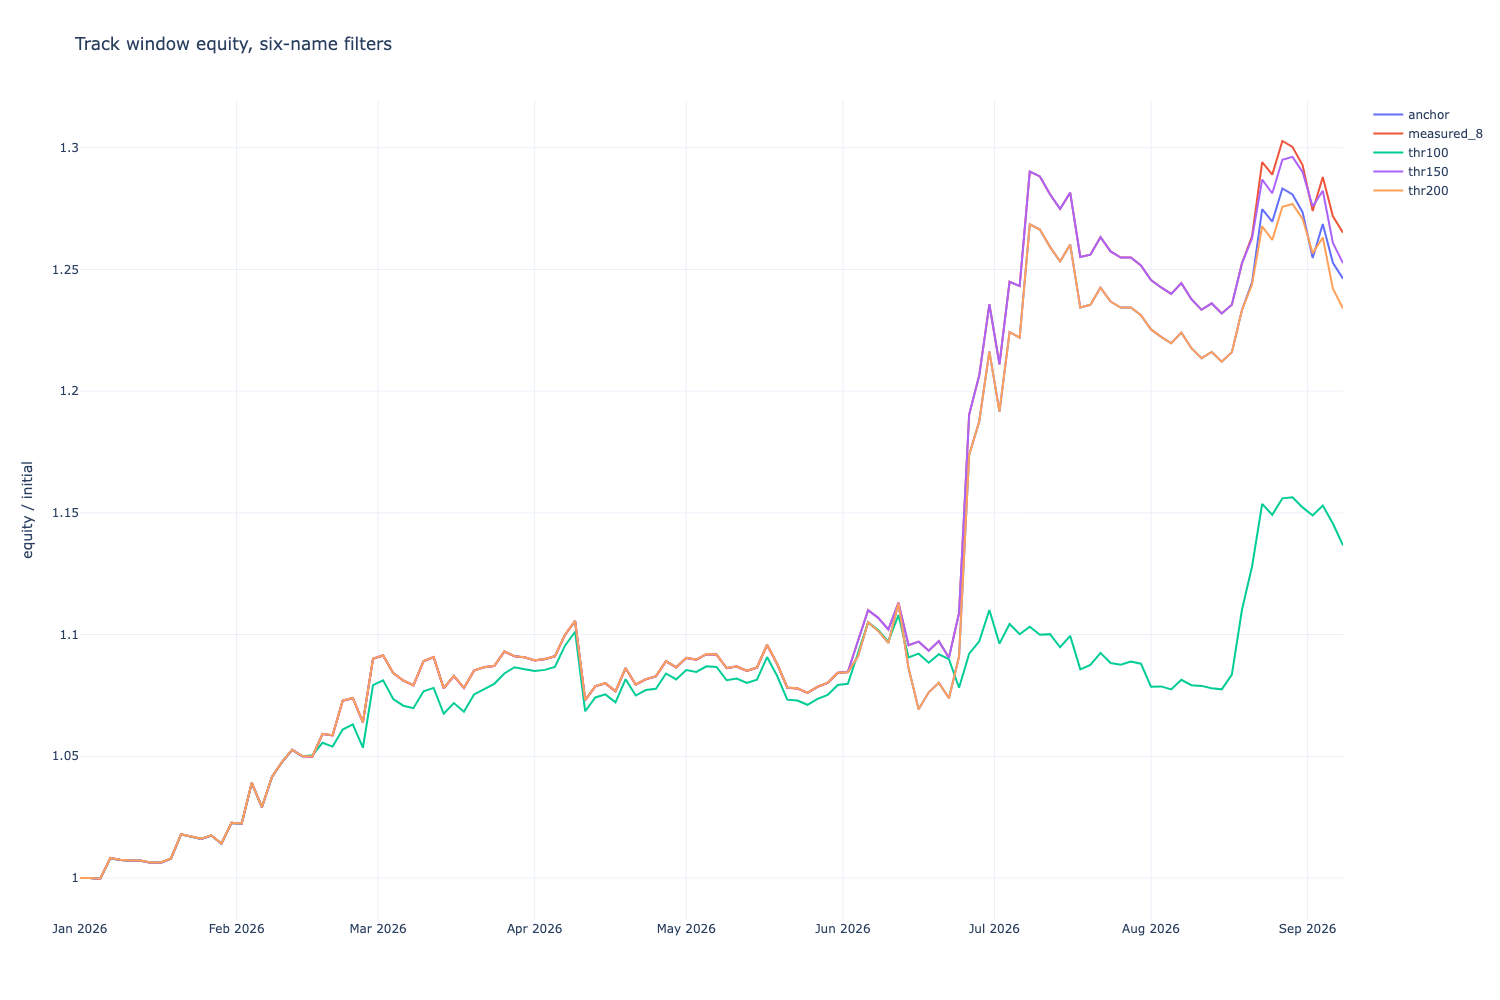

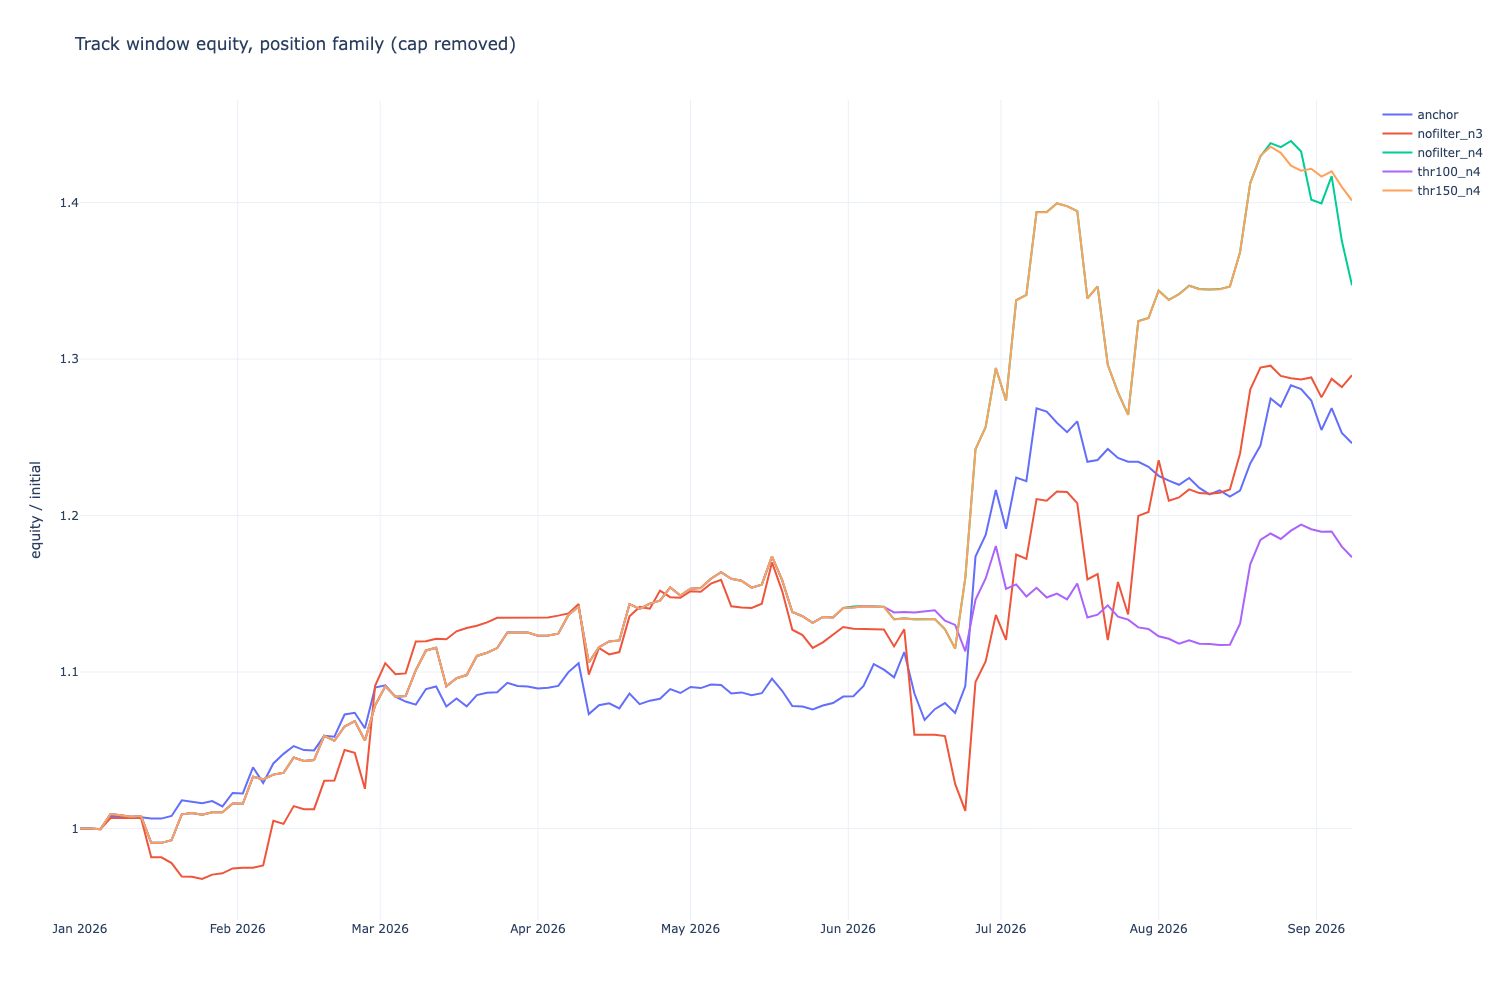

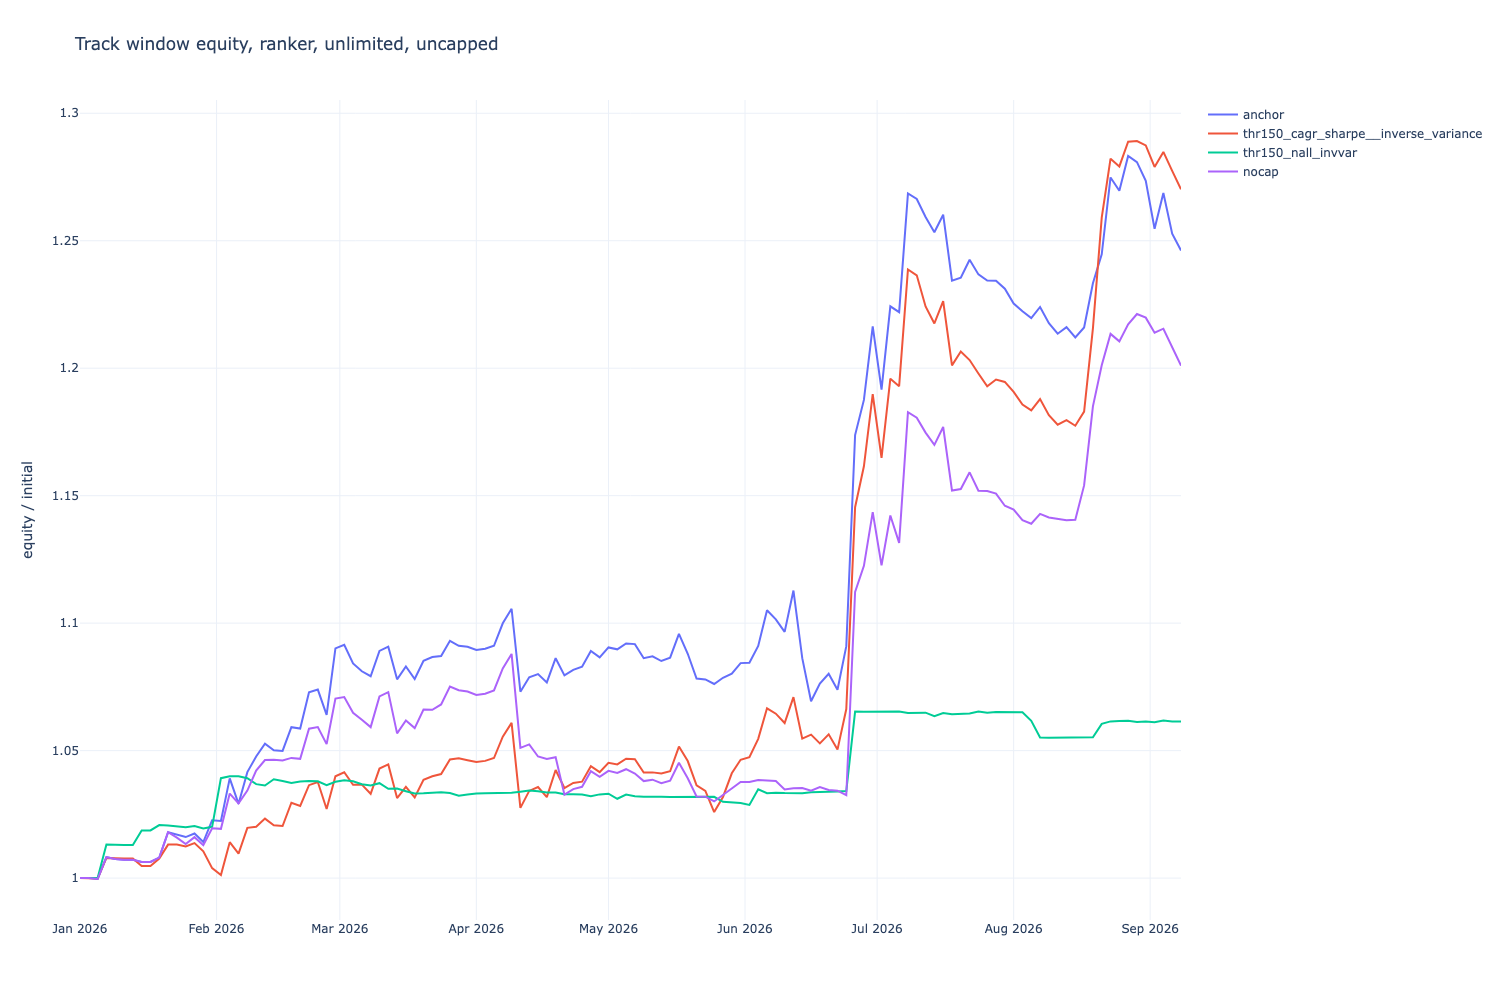

In [19]:
import plotly.graph_objects as go
GROUPS = {"six-name filters": ["anchor", "measured_8", "thr100", "thr150", "thr200"],
          "position family (cap removed)": ["anchor", "nofilter_n3", "nofilter_n4", "thr100_n4", "thr150_n4"],
          "ranker, unlimited, uncapped": ["anchor", "thr150_cagr_sharpe__inverse_variance", "thr150_nall_invvar", "nocap"]}


def equity_figure(title, labels):
    fig = go.Figure()
    for label in labels:
        eq = run_by_label[label]["equity"]
        fig.add_trace(go.Scatter(x=eq.index, y=eq / eq.iloc[0], mode="lines", name=label))
    fig.update_layout(title=title, height=440, template="plotly_white", yaxis_title="equity / initial")
    return fig


for title, labels in GROUPS.items():
    equity_figure(f"Track window equity, {title}", labels).show()


### 2b. Risk panel

What the operator is worried about, per lead: drawdown depth, ulcer, the worst cycles, time
under water, held-book own volatility (post-break, gate 3's statistic), concentration, luck.


In [20]:
risk = pd.DataFrame([risk_row(l) for l in LEAD_LABELS]).set_index("label")
display(risk.round(4))


,cagr,cycle_sharpe,cycle_vol,max_dd,ulcer,worst_cycle,worst5_cycles_sum,share_of_cycles_under_water,longest_under_water_days,kurtosis,held_vol_post,mean_largest_weight,mean_holdings,top_vault_pnl_share,luck_ratio,top5_gross_share,mean_invested
label,,,,,,,,,,,,,,,,,
anchor,0.3790,2.1598,0.1543,-0.0445,0.0180,-0.0294,-0.1098,0.8016,62,14.5826,0.0184,0.3316,6.0000,0.4192,0.1459,0.6083,0.9720
measured_8,0.4097,2.3738,0.1494,-0.0452,0.0171,-0.0294,-0.1003,0.7937,56,14.6115,0.0180,0.3313,6.0000,0.4171,0.2038,0.5989,0.9716
thr100,0.2056,1.9632,0.0977,-0.0297,0.0143,-0.0297,-0.0810,0.7857,56,3.6768,0.0117,0.3289,6.0000,0.2304,0.1934,0.5255,0.9778
thr150,0.3893,2.2938,0.1481,-0.0452,0.0172,-0.0294,-0.1024,0.7937,56,15.2006,0.0175,0.3307,6.0000,0.4348,0.1717,0.6232,0.9734
thr200,0.3592,2.0819,0.1530,-0.0445,0.0180,-0.0294,-0.1109,0.8016,62,15.1638,0.0179,0.3311,6.0000,0.4376,0.1090,0.6335,0.9735
nocap,0.3066,1.9296,0.1439,-0.0532,0.0277,-0.0339,-0.1024,0.7698,76,22.8939,0.0131,0.5202,5.6032,0.5086,0.0107,0.6716,0.9778
nofilter_n3,0.4498,1.6944,0.2355,-0.1357,0.0327,-0.0598,-0.2047,0.7063,46,5.9071,0.0282,0.6633,2.9206,0.4677,NaN,0.8419,0.8065
nofilter_n4,0.5452,2.2997,0.1978,-0.0966,0.0246,-0.0400,-0.1597,0.6746,38,5.5404,0.0221,0.6090,3.8571,0.6473,0.1712,0.7858,0.9338
thr100_n4,0.2629,1.9789,0.1217,-0.0536,0.0226,-0.0314,-0.1129,0.7222,50,3.1020,0.0123,0.5893,3.9206,0.2420,0.2371,0.6735,0.9524


### 2c. Positions

Ledger summary for every lead, then the eight largest positions by absolute P&L for the leads a
gate rejected. `pnl_share` is the position's share of the run's NET P&L.


In [21]:
ledgers = pd.DataFrame([ledger_summary(l) for l in LEAD_LABELS]).set_index("label")
display(ledgers.round(4))
LEDGER_DETAIL = ["anchor", "thr150", "thr100", "thr150_n4", "nofilter_n4", "thr150_cagr_sharpe__inverse_variance", "thr150_nall_invvar"]
for label in LEDGER_DETAIL:
    print(f"\n{label}: largest positions")
    display(position_ledger(label).head(8).round(4))


,positions,distinct_vaults,win_rate,median_days_held,net_pnl_usd,top_vault,top_vault_pnl_share_of_positive,top3_vaults_pnl_share_of_positive,largest_loss_usd,largest_loss_vault
label,,,,,,,,,,
anchor,96,33,0.4375,6.0,36745.9143,0x77fe..1a16,0.4192,0.6772,-2073.1058,0x77fe..1a16
measured_8,97,32,0.4330,6.0,39584.9916,0x77fe..1a16,0.4171,0.6593,-1864.1966,0x2431..fb0f
thr100,93,30,0.3763,4.0,20327.9008,0x4dec..27f6,0.2304,0.5287,-1360.4469,0x2431..fb0f
thr150,98,32,0.4184,6.0,37706.0900,0x77fe..1a16,0.4348,0.6900,-1538.2353,0xda51..c167
thr200,98,34,0.4082,6.0,34911.6740,0x77fe..1a16,0.4376,0.7099,-2073.1058,0x77fe..1a16
nocap,96,31,0.4271,6.0,29973.0238,0x77fe..1a16,0.5086,0.7266,-2178.4703,0xda51..c167
nofilter_n3,47,19,0.3830,10.0,43301.0597,0x77fe..1a16,0.4677,0.8189,-8010.2967,0x77fe..1a16
nofilter_n4,51,24,0.4902,10.0,51891.3210,0x77fe..1a16,0.6473,0.8641,-10156.0023,0x9e02..73df
thr100_n4,57,24,0.4211,6.0,25841.2674,0x4dec..27f6,0.2420,0.6018,-2158.2576,0xda51..c167



anchor: largest positions


,position,vault,address,opened,closed,days,pnl_usd,peak_weight,pnl_share
0,66,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-06-20,2026-08-21,62,16891.1770,0.3237,0.4597
1,8,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,2026-01-05,2026-05-21,136,6377.4563,0.3277,0.1736
2,86,0x9e02..73df,0x9e02aca9865e1859bb7865f6f64801e804a173df,2026-08-17,None,22,4682.4955,0.3259,0.1274
3,83,0xda51..c167,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,2026-08-05,None,34,3910.7502,0.3274,0.1064
4,43,0xba93..4550,0xba939edf38c0ae0cc689c98b492e0535f43e4550,2026-04-19,2026-06-14,56,2873.6000,0.3277,0.0782
5,32,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-03-08,2026-06-04,88,2866.4372,0.2288,0.0780
6,21,0x2431..fb0f,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,2026-02-02,2026-02-20,18,2859.1190,0.1664,0.0778
7,56,0x2431..fb0f,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,2026-05-29,2026-08-09,72,2291.8678,0.2513,0.0624



thr150: largest positions


,position,vault,address,opened,closed,days,pnl_usd,peak_weight,pnl_share
0,66,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-06-20,2026-08-21,62,17175.6809,0.3237,0.4555
1,8,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,2026-01-05,2026-05-21,136,6376.6799,0.3277,0.1691
2,86,0x9e02..73df,0x9e02aca9865e1859bb7865f6f64801e804a173df,2026-08-17,None,22,4872.5886,0.3272,0.1292
3,83,0xda51..c167,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,2026-08-05,None,34,3960.3167,0.3267,0.1050
4,43,0xba93..4550,0xba939edf38c0ae0cc689c98b492e0535f43e4550,2026-04-19,2026-06-24,66,3298.3399,0.3279,0.0875
5,32,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-03-08,2026-06-04,88,2969.0753,0.2288,0.0787
6,21,0x2431..fb0f,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,2026-02-02,2026-02-20,18,2859.0184,0.1664,0.0758
7,56,0x2431..fb0f,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,2026-05-29,2026-08-09,72,2526.0360,0.2473,0.0670


...

,position,vault,address,opened,closed,days,pnl_usd,peak_weight,pnl_share
0,32,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-06-20,2026-08-21,62,38428.2872,0.5933,0.7406
1,49,0x9e02..73df,0x9e02aca9865e1859bb7865f6f64801e804a173df,2026-08-31,2026-09-08,8,-10156.0023,0.7809,-0.1957
2,42,0xda51..c167,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,2026-08-05,2026-08-25,20,10063.1177,0.8784,0.1939
3,5,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,2026-01-05,2026-05-21,136,7280.0175,0.6113,0.1403
4,35,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,2026-07-06,2026-07-18,12,-5635.1894,0.4737,-0.1086
5,44,0x9e02..73df,0x9e02aca9865e1859bb7865f6f64801e804a173df,2026-08-17,2026-08-21,4,3408.1740,0.1644,0.0657
6,13,0x2431..fb0f,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,2026-02-02,2026-02-20,18,2932.8170,0.1799,0.0565
7,29,0x2431..fb0f,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f,2026-05-29,2026-07-22,54,2799.5766,0.2611,0.0540



thr150_cagr_sharpe__inverse_variance: largest positions


,position,vault,address,opened,closed,days,pnl_usd,peak_weight,pnl_share
0,60,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-06-20,2026-08-21,62,21607.0033,0.3237,0.5355
1,7,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,2026-01-05,2026-05-21,136,4593.3362,0.3277,0.1138
2,84,0x07fd..689d,0x07fd993f0fa3a185f7207adccd29f7a87404689d,2026-08-17,2026-08-21,4,4303.4559,0.3006,0.1067
3,80,0xda51..c167,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,2026-08-05,None,34,3833.3214,0.3274,0.0950
4,85,0x9e02..73df,0x9e02aca9865e1859bb7865f6f64801e804a173df,2026-08-17,None,22,3509.2492,0.3121,0.0870
5,38,0xba93..4550,0xba939edf38c0ae0cc689c98b492e0535f43e4550,2026-04-17,2026-06-24,68,3164.3248,0.3281,0.0784
6,26,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,2026-03-08,2026-06-04,88,2757.4672,0.2287,0.0683
7,6,0x241b..1a43,0x241ba250828c6a1289330aeec301e7bdcef31a43,2026-01-01,2026-02-02,32,-2632.4008,0.1411,-0.0652



thr150_nall_invvar: largest positions


,position,vault,address,opened,closed,days,pnl_usd,peak_weight,pnl_share
0,65,0xcbbb..fbed,0xcbbb26d5e622fb877e12745921ae8b1f820ffbed,2026-03-12,2026-06-26,106,4655.9287,0.0349,0.5133
1,20,0xdfc2..f303,0xdfc24b077bc1425ad1dea75bcb6f8158e10df303,2026-01-01,None,250,3002.4026,0.4254,0.3310
2,89,0x5669..8892,0x5669371d2244a0b78626fa0ef5aec77eaed18892,2026-07-18,2026-08-07,20,-980.7401,0.0143,-0.1081
3,72,0xfb3b..a47b,0xfb3b7e17100a63bbc86efba54a36a705fe4ba47b,2026-05-31,2026-06-04,4,868.4116,0.0857,0.0957
4,10,0x51b6..30a8,0x51b62b4bf8df6f2795b3da30cb46aa47f9f230a8,2026-01-01,2026-02-06,36,781.2925,0.0526,0.0861
5,5,0x22a6..1e4e,0x22a60014185f1486afb045219f76e4007fb71e4e,2026-01-01,2026-02-06,36,766.0961,0.2233,0.0845
6,77,0xe733..1ab6,0xe733381ee18ffd7172656504a39b7dca5bc51ab6,2026-06-08,2026-08-21,74,710.7043,0.0912,0.0784
7,4,0xcae0..ae69,0xcae0d1558b70b92ee9fd0acb20cb639c8c28ae69,2026-01-01,2026-01-09,8,692.4699,0.0262,0.0763


### 2d. Drawdowns and worst cycles

The three deepest drawdowns per lead, the positions that lost the money inside the deepest one,
and the five worst cycles with the vault that fell most in each.


In [22]:
DRAWDOWN_DETAIL = ["anchor", "thr150", "thr150_n4", "nofilter_n4", "nofilter_n3", "thr150_cagr_sharpe__inverse_variance", "thr150_nall_invvar"]
episode_rows = []
for label in DRAWDOWN_DETAIL:
    episodes = drawdown_episodes(label, top=3)
    for i, row in episodes.iterrows():
        episode_rows.append({"label": label, "rank": i + 1, **row.to_dict()})
episodes_table = pd.DataFrame(episode_rows).set_index(["label", "rank"])
display(episodes_table.round(4))
for label in DRAWDOWN_DETAIL:
    deepest = drawdown_episodes(label, top=1).iloc[0]
    print(f"\n{label}: deepest drawdown {deepest['depth']:.2%} from {deepest['peak']} to {deepest['trough']} - positions that lost most")
    display(episode_attribution(label, deepest["peak"], deepest["trough"], top=5).round(2))
for label in ["thr150_n4", "nofilter_n4", "thr150_nall_invvar"]:
    print(f"\n{label}: worst cycles")
    display(worst_cycles(label, n=5).round(4))


peak      trough   recovered   depth  days_to_trough  days_under_water
label                                rank                                                                              
anchor                               1     2026-07-08  2026-08-15  2026-08-23 -0.0445              38                46
                                     2     2026-06-12  2026-06-16  2026-06-26 -0.0391               4                14
                                     3     2026-04-09  2026-04-11  2026-06-12 -0.0294               2                64
thr150                               1     2026-07-08  2026-08-15  2026-08-27 -0.0452              38                50
                                     2     2026-08-29  2026-09-08        None -0.0337              10                10
                                     3     2026-04-09  2026-04-11  2026-06-06 -0.0294               2                58
thr150_n4                            1     2026-07-12  2026-07-26  2026-08-19 -0.0966              14                38
                                     2     2026-05-17  2026-06-22  2026-06-26 -0.0502              36                40
                                     3     2026-04-09  2026-04-11  2026-04-19 -0.0314               2                10
nofilter_n4                          1     2026-07-12  2026-07-26  2026-08-19 -0.0966              14                38
                                     2     2026-08-27  2026-09-08        None -0.0640              12                12
                                     3     2026-05-17  2026-06-22  2026-06-26 -0.0502              36                40
nofilter_n3                          1     2026-05-17  2026-06-24  2026-07-04 -0.1357              38                48
                                     2     2026-07-12  2026-07-22  2026-08-01 -0.0781              10                20
                                     3     2026-04-09  2026-04-11  2026-04-25 -0.0394               2                16
thr150_cagr_sharpe__inverse_variance 1     2026-07-08  2026-08-15  2026-08-21 -0.0495              38                44
                                     2     2026-04-09  2026-05-25  2026-06-06 -0.0330              46                58
                                     3     2026-06-30  2026-07-02  2026-07-04 -0.0210               2                 4
thr150_nall_invvar                   1     2026-02-04  2026-06-02  2026-06-26 -0.0108             118               142
                                     2     2026-07-24  2026-08-15        None -0.0097              22                46
                                     3     2026-06-26  2026-07-14  2026-07-24 -0.0017              18                28


anchor: deepest drawdown -4.45% from 2026-07-08 to 2026-08-15 - positions that lost most


,vault,address,position,pnl_change_usd
0,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,66,-2275.89
1,0xda51..c167,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,76,-1512.60
2,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,72,-1446.20
3,0x565b..acc4,0x565b1c32936bdaa526947178acc95c5b08cfacc4,67,-1082.59
4,0x07fd..689d,0x07fd993f0fa3a185f7207adccd29f7a87404689d,80,-886.44



thr150: deepest drawdown -4.52% from 2026-07-08 to 2026-08-15 - positions that lost most


,vault,address,position,pnl_change_usd
0,0x77fe..1a16,0x77fee2df7bad4f1db93052fa82bf78eaab771a16,66,-2402.35
1,0xda51..c167,0xda51323fe9800c8365646ad5c7ade0dd17fdc167,76,-1538.24
2,0x4dec..27f6,0x4dec0a851849056e259128464ef28ce78afa27f6,72,-1523.59
3,0x565b..acc4,0x565b1c32936bdaa526947178acc95c5b08cfacc4,67,-1105.21
4,0x07fd..689d,0x07fd993f0fa3a185f7207adccd29f7a87404689d,80,-900.66


...

,cycle_end,cycle_return,worst_vault,worst_vault_pnl_change_usd,positions_down
0,2026-07-18,-0.0400,0x4dec..27f6,-5919.7739,4
1,2026-07-22,-0.0372,0x77fe..1a16,-7683.4519,1
2,2026-04-11,-0.0314,0xd2f0..e9e1,-4870.2255,2
3,2026-03-14,-0.0220,0x4dec..27f6,-3629.2571,3
4,2026-05-21,-0.0176,0x4dec..27f6,-2786.5165,3



nofilter_n4: worst cycles


,cycle_end,cycle_return,worst_vault,worst_vault_pnl_change_usd,positions_down
0,2026-07-18,-0.0400,0x4dec..27f6,-5920.2700,4
1,2026-07-22,-0.0372,0x77fe..1a16,-7684.1642,1
2,2026-04-11,-0.0314,0xd2f0..e9e1,-4870.2255,2
3,2026-09-06,-0.0292,0x9e02..73df,-5413.4885,4
4,2026-03-14,-0.0220,0x4dec..27f6,-3629.2571,3



thr150_nall_invvar: worst cycles


,cycle_end,cycle_return,worst_vault,worst_vault_pnl_change_usd,positions_down
0,2026-08-07,-0.0061,0x5669..8892,-978.4605,6
1,2026-08-05,-0.0032,0x7c8b..ddf5,-478.5437,9
2,2026-02-10,-0.0022,0xba93..4550,-259.9338,10
3,2026-03-12,-0.0021,0xb571..75f8,-287.9269,6
4,2026-05-03,-0.0019,0xdfc2..f303,-293.0226,6


### 2e. Gate 2 - the single-vault mask, read as a vault

First the anchor under its own mask, which the 0.70 bar was set above. Then, for the leads whose
mask retention sat near or below the bar, and the three that passed: the masked vault, its share
of the lead's positive P&L, the same vault's share of the ANCHOR's positive P&L (an inherited
dependence is not the lead's doing), and the recorded retention. Then one new run per marginal
lead: mask the SECOND largest contributor instead, to see whether the dependence is one name or a
thin book.


In [23]:
def vault_pnl_shares(label: str) -> pd.Series:
    ledger = position_ledger(label)
    by_vault = ledger.groupby("address")["pnl_usd"].sum()
    positive = by_vault[by_vault > 0].sum()
    return (by_vault / positive).sort_values(ascending=False) if positive > 0 else by_vault * np.nan


MASK_LEADS = ["thr150_cagr_sharpe__inverse_variance", "thr100", "thr150", "measured_8", "thr200"]
anchor_shares = vault_pnl_shares("anchor")
# The anchor under its own mask, for reference: the bar (0.70) is judged against this.
anchor_lovo = lovo_gate("anchor", verbose=True)
mask_rows = []
for label in MASK_LEADS:
    shares = vault_pnl_shares(label)
    masked = largest_contributing_vault(run_by_label[label]["state"])
    recorded = manifest_37["gates"].get(label, {}).get("mask_retention")
    if label == "measured_8":
        recorded = next(r["retention"] for r in manifest_35["diag_lovo"] if r["label"] == "measured_8")
    mask_rows.append({"label": label, "masked_vault": short(masked), "lead_share_of_positive_pnl": float(shares.get(masked, np.nan)),
                      "anchor_share_of_positive_pnl": float(anchor_shares.get(masked, np.nan)),
                      "anchor_rank_of_this_vault": int(anchor_shares.index.get_loc(masked)) + 1 if masked in anchor_shares.index else None,
                      "second_vault": short(shares.index[1]), "second_share": float(shares.iloc[1]),
                      "recorded_mask_retention": float(recorded) if recorded is not None else np.nan})
mask_table = pd.DataFrame(mask_rows).set_index("label")
display(mask_table.round(4))

# Second-largest contributor masked, for the two marginal leads.
second_mask = []
for label in ["thr150_cagr_sharpe__inverse_variance", "thr100"]:
    shares = vault_pnl_shares(label)
    second = shares.index[1]
    entry = run_by_label[label]
    lovo2 = run_and_record(f"{label}__lovo2", "robustness", masked={second}, **entry["overrides"])
    second_mask.append({"label": label, "masked_second": short(second), "sharpe": float(entry["panel"]["cycle_sharpe"]),
                        "sharpe_masked_second": float(lovo2["panel"]["cycle_sharpe"]),
                        "retention_second": float(lovo2["panel"]["cycle_sharpe"]) / float(entry["panel"]["cycle_sharpe"]),
                        "cagr_masked_second": float(lovo2["panel"]["cagr"])})
display(pd.DataFrame(second_mask).set_index("label").round(4))


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 17:01:20,832 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-18 17:01:20,892 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.631520628998396047592398, executed reserve 6008.532971295332676819573900
  Estimated quantity -3624.10657780110659587080590426921844482421875, executed quantity -3624.10657780110659587080590426921844482421875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

2026-09-18 17:02:20,705 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #480
  Estimated reserve 1614.522509624301196923219991, executed reserve 1576.495927086514260990892146
  Estimated quantity -369.19754302067150319999200291931629180908203125, executed quantity -369.19754302067150319999200291931629180908203125
  Reserve drift 2.355284 %, quantity drift 0.000000 %


2026-09-18 17:02:20,734 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #484
  Estimated reserve 932.4144677052262915637292470, executed reserve 907.9593756914664248489415589
  Estimated quantity -206.419261754972239941707812249660491943359375, executed quantity -206.419261754972239941707812249660491943359375
  Reserve drift 2.622771 %, quantity drift 0.000000 %


2026-09-18 17:02:20,762 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #490
  Estimated reserve 3901.715553616582630136345864, executed reserve 3805.445703543095306515922380
  Estimated quantity -880.3141446161617977850255556404590606689453125, executed quantity -880.3141446161617977850255556404590606689453125
  Reserve drift 2.467372 %, quantity drift 0.000000 %


2026-09-18 17:02:20,848 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Octavious  #503
  Estimated reserve 2517.102323422814010222565095, executed reserve 2490.090363951242356747019104
  Estimated quantity -583.9273517748578115060809068381786346435546875, executed quantity -583.9273517748578115060809068381786346435546875
  Reserve drift 1.073137 %, quantity drift 0.000000 %


,masked_second,sharpe,sharpe_masked_second,retention_second,cagr_masked_second
label,,,,,
thr150_cagr_sharpe__inverse_variance,0x07fd..689d,2.3749,2.1692,0.9134,0.3579
thr100,0xba93..4550,1.9632,0.6411,0.3265,0.0810


### 2f. Gate 6 - the threshold cliff, read as a list of vaults

`thr150` fails the plateau because `thr100` sits 0.33 below it. The vaults in the band are the
names `thr150` held on dates when `thr100`'s filter excluded them. Two attributions: the whole-
window P&L of those names (an association), and the P&L earned only on the cycles in which the
tight run's filter excluded a name the wide run was holding (the disputed dates). Then, for every threshold run: each
time the filter removed a HELD name, the vault's own forward 30-day log return afterwards. A
filter that is doing its job removes names that go on to lose; one that is not forgoes gains.


In [24]:
bands = pd.DataFrame([band_attribution("thr150", "thr100"), band_attribution("thr200", "thr150"), band_attribution("thr150_n4", "thr100_n4")])
print("whole-window P&L of the band addresses (an association: every position of those names, on every date)")
display(bands.drop(columns=["band_addresses"]).set_index(["wide", "tight"]).round(4))
print("band vaults thr150 vs thr100:", ", ".join(short(a) for a in bands.iloc[0]["band_addresses"]))
print("\nP&L earned ONLY on the cycles in which the tight run's filter excluded a name the wide run (or the anchor) held")
bands_aligned = pd.DataFrame([band_attribution_aligned("thr150", "thr100"), band_attribution_aligned("thr200", "thr150"), band_attribution_aligned("thr150_n4", "thr100_n4")])
display(bands_aligned.set_index(["wide", "tight"]).round(4))
ENGINE = "0x77fee2df7bad4f1db93052fa82bf78eaab771a16"
engine_positions = {l: positions_in_address(l, ENGINE) for l in LEAD_LABELS}
print("\nevery position in the engine vault, per lead")
display(pd.DataFrame([{"label": l, "positions": len(v), "spans": "; ".join(f"{r['opened']}..{r['closed'] or 'open'} ({r['pnl_usd']:.0f})" for r in v)} for l, v in engine_positions.items()]).set_index("label"))

exclusion_summary = pd.DataFrame([exclusion_outcome_summary(l) for l in ["thr100", "thr150", "thr200", "thr150_n4", "thr100_n4", "thr150_nall_invvar"]]).set_index("label")
display(exclusion_summary.round(4))
for label in ["thr150", "thr150_nall_invvar"]:
    print(f"\n{label}: every held-name exclusion ({len(held_exclusion_outcomes(label))} rows)")
    display(held_exclusion_outcomes(label).drop(columns=["address"]).round(4))


whole-window P&L of the band addresses (an association: every position of those names, on every date)


,,band_vaults,wide_band_pnl_usd,wide_band_pnl_share_of_net,wide_band_positions,reference_band_pnl_usd,reference_band_pnl_share_of_net,reference_band_positions
wide,tight,,,,,,,
thr150,thr100,8,26975.4438,0.7154,33,24177.6397,0.6580,32
thr200,thr150,2,-15.0144,-0.0004,2,1805.6509,0.0491,3
thr150_n4,thr100_n4,4,41975.9702,0.6996,9,25204.9986,0.6859,15


band vaults thr150 vs thr100: 0x15e5..c129, 0x2431..fb0f, 0x45c4..b81e, 0x4dec..27f6, 0x5669..8892, 0x77fe..1a16, 0xbbf7..2422, 0xce71..5086

P&L earned ONLY on the cycles in which the tight run's filter excluded a name the wide run (or the anchor) held


,,wide_disputed_cycles,wide_disputed_addresses,wide_disputed_pnl_usd,wide_disputed_pnl_share_of_net,reference_disputed_cycles,reference_disputed_addresses,reference_disputed_pnl_usd,reference_disputed_pnl_share_of_net
wide,tight,,,,,,,,
thr150,thr100,51,8,16602.1567,0.4403,64,11,18105.1523,0.4927
thr200,thr150,11,2,-9.8376,-0.0003,20,3,2315.7499,0.0630
thr150_n4,thr100_n4,38,4,32533.2406,0.5422,68,11,12100.1317,0.3293



every position in the engine vault, per lead


...

,held_exclusions,distinct_vaults,measured,mean_forward_log_return,median_forward_log_return,share_negative,share_crash,share_gain_over_10pct
label,,,,,,,,
thr100,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thr150,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thr200,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thr150_n4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thr100_n4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thr150_nall_invvar,1,1.0,1.0,-0.2736,-0.2736,1.0,0.0,0.0



thr150: every held-name exclusion (0 rows)


,decision,vault,vol_at_decision,limit,forward_log_return



thr150_nall_invvar: every held-name exclusion (1 rows)


,decision,vault,vol_at_decision,limit,forward_log_return
0,2026-06-26,0xcbbb..fbed,1.9394,1.5,-0.2736


### 2g. Gate 7 and gate 3 - the unlimited book and the four-name book

The unlimited inverse-variance book earned 9% and turned negative in the late period. The sizing
rule's known bias is towards names whose marks rarely move; the capital-weighted count of moved
marks in the trailing 90 rows, and the share of capital in names with fewer than 30, make that
visible against the anchor. Then the late-period P&L by vault. For the four-name books: how much
of their capital sat in names the anchor also held, so gate 3's higher held-book volatility can
be read as "the same names, bigger" or "different names".


In [25]:
sparse = pd.DataFrame([sparse_capital_share(l) for l in ["anchor", "thr150", "thr150_nall_invvar", "thr150_n4", "nofilter_n4"]]).set_index("label")
display(sparse.round(4))
for label in ["thr150_nall_invvar", "anchor"]:
    print(f"\n{label}: late-period (from {LATE_START.date()}) P&L by vault, largest losers and winners")
    display(regime_pnl_by_vault(label, LATE_START, LATE_END, top=5).round(2))
overlap = pd.DataFrame([book_overlap(l) for l in ["thr150", "measured_8", "nofilter_n4", "thr150_n4", "nofilter_n3", "thr150_nall_invvar"]]).set_index("label")
display(overlap.round(4))


,decisions,weighted_fresh_marks_90,sparse_capital_share,sparse_share_dense,sparse_share_late,sparse_share_sparse
label,,,,,,
anchor,126,47.2543,0.3035,0.0840,0.0000,0.7639
thr150,126,47.2972,0.3035,0.0840,0.0000,0.7639
thr150_nall_invvar,126,24.5005,0.6917,0.6437,0.5626,0.8412
thr150_n4,126,44.1650,0.3457,0.1183,0.0000,0.8470
nofilter_n4,126,45.2674,0.3457,0.1183,0.0000,0.8470



thr150_nall_invvar: late-period (from 2026-07-01) P&L by vault, largest losers and winners


,vault,pnl_change_usd,regime_pnl_total_usd,regime_vaults
0,0x5669..8892,-980.74,-579.93,39
1,0x7c8b..ddf5,-481.87,-579.93,39
2,0xa6a3..5e40,-127.39,-579.93,39
3,0x3b4f..d48d,-84.01,-579.93,39
4,0x3596..edb4,-56.58,-579.93,39
5,0x1313..bd90,67.82,-579.93,39
6,0xdfc2..f303,75.39,-579.93,39
7,0xda51..c167,152.63,-579.93,39
8,0x4b00..bb46,214.56,-579.93,39
9,0xe733..1ab6,724.84,-579.93,39



anchor: late-period (from 2026-07-01) P&L by vault, largest losers and winners


,vault,pnl_change_usd,regime_pnl_total_usd,regime_vaults
0,0x2431..fb0f,-7457.55,4469.61,16
1,0xbbf7..2422,-949.50,4469.61,16
2,0x4dec..27f6,-824.45,4469.61,16
3,0x07fd..689d,-735.21,4469.61,16
4,0xd2f0..e9e1,-245.99,4469.61,16
5,0x45c4..b81e,1408.03,4469.61,16
6,0xcae0..ae69,1820.67,4469.61,16
7,0xda51..c167,2116.32,4469.61,16
8,0x77fe..1a16,3791.41,4469.61,16
9,0x9e02..73df,4682.50,4469.61,16


,decisions,mean_jaccard_vs_reference,capital_share_in_reference_names
label,,,
thr150,126,0.9473,0.9786
measured_8,126,0.9728,0.9864
nofilter_n4,126,0.6429,1.0000
thr150_n4,126,0.6481,1.0000
nofilter_n3,126,0.4868,1.0000
thr150_nall_invvar,126,0.0215,0.0189


### 2h. Were the thresholds and the floor sensibly placed?

From `thr150`'s crash log, every candidate's trailing volatility at every decision: the share of
candidates and the share of the ANCHOR's capital in each volatility band. The threshold family's
step from 1.0 to 1.5 is sensible only if a material share of the anchor's book sits in that band
- otherwise the two runs could not differ by what they did. Then the quality score's population:
how many candidates clear each floor per decision, read offline from the cached indicator at T-1
over the same candidate sets, so the floor family can be checked against the book it will be
applied to before the rescue runs.


In [26]:
BANDS = [(0.0, 0.5), (0.5, 1.0), (1.0, 1.25), (1.25, 1.5), (1.5, 2.0), (2.0, 99.0)]
crash_log_150 = run_by_label["thr150"]["crash_log"]
anchor_held = held_addresses_by_date(run_by_label["anchor"])
band_rows = []
for t, rec in sorted(crash_log_150.items()):
    vols = {a: v for a, v in rec["vol"].items() if np.isfinite(v)}
    held = anchor_held.get(pd.Timestamp(t), {})
    held_total = sum(held.values())
    row = {"decision": pd.Timestamp(t), "candidates": rec["pool_size"], "measured": len(vols)}
    for lo, hi in BANDS:
        in_band = {a for a, v in vols.items() if lo <= v < hi}
        row[f"cand_{lo}-{hi}"] = len(in_band) / max(len(vols), 1)
        row[f"anchor_cap_{lo}-{hi}"] = sum(w for a, w in held.items() if a in in_band) / held_total if held_total > 0 else np.nan
    row["anchor_cap_unmeasured"] = sum(w for a, w in held.items() if a not in vols) / held_total if held_total > 0 else np.nan
    band_rows.append(row)
band_frame = pd.DataFrame(band_rows).set_index("decision")
band_summary = pd.DataFrame({"mean over decisions": band_frame.drop(columns=["candidates", "measured"]).mean(),
                             "post-break mean": band_frame.loc[band_frame.index >= POST_BREAK_START].drop(columns=["candidates", "measured"]).mean()})
display(band_summary.round(4))

# Quality score population, offline at T-1. Two populations, because the floor runs after the
# crash filter: the whole candidate pool (what the anchor floor family sees; the crash log's
# `candidate_addresses` is written BEFORE the filter) and thr150's survivors (what the thr150
# floor family sees; `candidate_addresses` minus `excluded_addresses`).
floor_rows = []
for t, rec in sorted(crash_log_150.items()):
    q = {}
    for addr in rec["candidate_addresses"]:
        pair = PAIR_BY_ADDRESS.get(addr)
        q[addr] = value_at_prior(indicator_series("quality_sharpe", pair), t) if pair is not None else np.nan
    survivors = set(rec["candidate_addresses"]) - set(rec["excluded_addresses"])
    finite = {a: v for a, v in q.items() if np.isfinite(v)}
    finite_surv = {a: v for a, v in finite.items() if a in survivors}
    held = anchor_held.get(pd.Timestamp(t), {})
    row = {"decision": pd.Timestamp(t), "candidates": len(q), "measured": len(finite),
           "thr150_survivors": len(survivors), "thr150_survivors_measured": len(finite_surv),
           "anchor_held_measured": sum(1 for a in held if np.isfinite(q.get(a, np.nan))), "anchor_held": len(held),
           "anchor_held_median_quality": float(np.median([q[a] for a in held if np.isfinite(q.get(a, np.nan))])) if any(np.isfinite(q.get(a, np.nan)) for a in held) else np.nan}
    for f in FLOORS:
        row[f"clear_{ftag(f)}"] = sum(1 for v in finite.values() if v >= f)
        row[f"thr150_survivors_clear_{ftag(f)}"] = sum(1 for v in finite_surv.values() if v >= f)
        row[f"anchor_held_clear_{ftag(f)}"] = sum(1 for a in held if np.isfinite(q.get(a, np.nan)) and q[a] >= f)
    floor_rows.append(row)
floor_frame = pd.DataFrame(floor_rows).set_index("decision")
floor_summary = pd.DataFrame({"min": floor_frame.min(), "p10": floor_frame.quantile(0.1), "median": floor_frame.median(), "mean": floor_frame.mean()})
display(floor_summary.round(3))
print(f"decisions: {len(floor_frame)}; quality measured on a mean {floor_frame['measured'].mean():.1f} of {floor_frame['candidates'].mean():.1f} candidates; "
      f"anchor held names measured {floor_frame['anchor_held_measured'].sum()} of {floor_frame['anchor_held'].sum()} holding-decisions")
print("\nanchor: largest positions with the vault's quality score at the opening decision")
display(ledger_with_quality("anchor", top=8).round(4))


,mean over decisions,post-break mean
cand_0.0-0.5,0.6433,0.6694
anchor_cap_0.0-0.5,0.7677,0.7522
cand_0.5-1.0,0.2201,0.1861
anchor_cap_0.5-1.0,0.1919,0.1856
cand_1.0-1.25,0.0413,0.0479
anchor_cap_1.0-1.25,0.0349,0.0542
cand_1.25-1.5,0.0196,0.0213
anchor_cap_1.25-1.5,0.0013,0.0015
cand_1.5-2.0,0.0378,0.0369
anchor_cap_1.5-2.0,0.0029,0.0045


,min,p10,median,mean
candidates,92.00,106.000,159.00,148.024
measured,40.00,46.500,66.00,69.230
thr150_survivors,85.00,101.000,143.50,135.540
thr150_survivors_measured,36.00,43.000,60.00,62.881
anchor_held_measured,5.00,5.000,6.00,5.825
anchor_held,6.00,6.000,6.00,6.000
anchor_held_median_quality,-0.11,0.647,1.17,1.209
clear_f10,12.00,14.000,18.00,20.413
thr150_survivors_clear_f10,12.00,14.000,18.00,20.278
anchor_held_clear_f10,0.00,1.000,4.00,3.325


decisions: 126; quality measured on a mean 69.2 of 148.0 candidates; anchor held names measured 734 of 756 holding-decisions

anchor: largest positions with the vault's quality score at the opening decision


,position,vault,opened,closed,days,pnl_usd,peak_weight,pnl_share,quality_at_open
0,66,0x77fe..1a16,2026-06-20,2026-08-21,62,16891.1770,0.3237,0.4597,1.1236
1,8,0x4dec..27f6,2026-01-05,2026-05-21,136,6377.4563,0.3277,0.1736,3.0065
2,86,0x9e02..73df,2026-08-17,None,22,4682.4955,0.3259,0.1274,1.7898
3,83,0xda51..c167,2026-08-05,None,34,3910.7502,0.3274,0.1064,1.4351
4,43,0xba93..4550,2026-04-19,2026-06-14,56,2873.6000,0.3277,0.0782,0.7029
5,32,0x77fe..1a16,2026-03-08,2026-06-04,88,2866.4372,0.2288,0.0780,NaN
6,21,0x2431..fb0f,2026-02-02,2026-02-20,18,2859.1190,0.1664,0.0778,2.0865
7,56,0x2431..fb0f,2026-05-29,2026-08-09,72,2291.8678,0.2513,0.0624,0.3464


## Part 3. Were N and the thresholds sensible? New runs

NB37 scored the position family with the cap REMOVED, so its N = 3 neighbour was a 99%-invested
three-name book and the N = 4 plateau was judged against it. Here the family is re-run with the
33% cap kept (N = 3, 4, 5, with and without the 1.5 filter), plus N = 3 and 5 uncapped with the
filter and the uncapped six-name filtered book as the missing neighbours, the unlimited filtered
book with the cap KEPT as the comparator for Part 4's unlimited floor family, and the threshold
family is refined to 1.25 and 1.75 around 1.5. These are checks on
the assumptions the verdicts rested on; a plateau that appears under a finer or a capped family
is reported as such, not as a new verdict on the old runs.


In [27]:
for label in ("thr125", "thr175"):
    run_and_record(label, "threshold", **filter_overrides(THR_FAMILY[label]))
for n in (3, 4, 5):
    run_and_record(f"n{n}cap", "positions_cap", max_assets_in_portfolio=n)
    run_and_record(f"thr150_n{n}cap", "positions_cap", **filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=n))
run_and_record("nofilter_n5", "positions", max_assets_in_portfolio=5, **NOCAP)
run_and_record("thr150_n5", "positions", **filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=5, **NOCAP))
run_and_record("thr150_n3", "positions", **filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=3, **NOCAP))
run_and_record("thr150_nocap", "cap", **filter_overrides(THR_FAMILY["thr150"], **NOCAP))
# The un-floored comparator of the unlimited floor family: unlimited AND the cap kept.
run_and_record("thr150_nallcap", "unlimited", **filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=999))
PART3 = ["anchor", "thr100", "thr125", "thr150", "thr175", "thr200",
         "nofilter_n3", "nofilter_n4", "nofilter_n5", "nocap", "n3cap", "n4cap", "n5cap",
         "thr150_n3", "thr150_n4", "thr150_n5", "thr150_nocap", "thr150_n3cap", "thr150_n4cap", "thr150_n5cap",
         "thr150_nall_invvar", "thr150_nallcap"]
display(summary_table(PART3).round(4))


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 17:02:41,882 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-18 17:02:41,922 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #88
  Estimated reserve 6082.578591984912760922430766, executed reserve 6008.480687427398873801098703
  Estimated quantity -3624.075042264796138624660670757293701171875, executed quantity -3624.075042264796138624660670757293701171875
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 17:07:18,613 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Crypto Tra #164
  Estimated reserve 1827.519786474406825508835321, executed reserve 1802.533085304973325957733678
  Estimated quantity -1446.351655195462399206007830798625946044921875, executed quantity -1446.351655195462399206007830798625946044921875
  Reserve drift 1.367247 %, quantity drift 0.000000 %


,family,cagr,cycle_sharpe,cycle_vol,ulcer,max_dd,mean_invested,luck_ratio,top5_gross_share,sparse_cagr,dense_cagr,late_cagr,final_equity,mean_holdings,mean_largest_weight,distinct_vaults,top_vault_pnl_share,turnover_per_decision,trades,share_of_decisions_changed,crash_survivors_mean,crash_excluded_held_total,qualifying_mean,qualifying_min,decisions_none_qualifying,quality_held_removed_total,sleeve_active_share,sleeve_mean_fill
label,,,,,,,,,,,,,,,,,,,,,,,,,,,,
anchor,anchor,0.3790,2.1598,0.1543,0.0180,-0.0445,0.9720,0.1459,0.6083,0.4335,0.5634,0.2720,186745.9143,6.0000,0.3316,33,0.4192,0.1200,578,0.0000,NaN,0,NaN,NaN,0,0,NaN,NaN
thr100,threshold,0.2056,1.9632,0.0977,0.0143,-0.0297,0.9778,0.1934,0.5255,0.4065,0.0972,0.2142,170327.9008,6.0000,0.3289,30,0.2304,0.1160,537,0.5159,121.7619,0,NaN,NaN,0,0,NaN,NaN
thr125,threshold,0.2337,1.7820,0.1220,0.0206,-0.0492,0.9665,0.0258,0.4957,0.4331,0.2122,0.2305,173034.7870,6.0000,0.3333,33,0.2015,0.1267,575,0.4127,130.8651,0,NaN,NaN,0,0,NaN,NaN
thr150,threshold,0.3893,2.2938,0.1481,0.0172,-0.0452,0.9734,0.1717,0.6232,0.4331,0.6672,0.1985,187706.0900,6.0000,0.3307,32,0.4348,0.1227,573,0.1667,135.5397,0,NaN,NaN,0,0,NaN,NaN
thr175,threshold,0.3893,2.2938,0.1481,0.0172,-0.0452,0.9734,0.1717,0.6232,0.4331,0.6672,0.1985,187706.0900,6.0000,0.3307,32,0.4348,0.1227,573,0.1667,137.4921,0,NaN,NaN,0,0,NaN,NaN
thr200,threshold,0.3592,2.0819,0.1530,0.0180,-0.0445,0.9735,0.1090,0.6335,0.4335,0.5634,0.2064,184911.6740,6.0000,0.3311,34,0.4376,0.1227,573,0.0794,139.8095,0,NaN,NaN,0,0,NaN,NaN
nofilter_n3,positions,0.4498,1.6944,0.2355,0.0327,-0.1357,0.8065,NaN,0.8419,0.6892,0.0068,1.1267,193301.0597,2.9206,0.6633,19,0.4677,0.1237,281,1.0000,NaN,0,NaN,NaN,0,0,NaN,NaN
nofilter_n4,positions,0.5452,2.2997,0.1978,0.0246,-0.0966,0.9338,0.1712,0.7858,0.6313,0.7777,0.3529,201891.3210,3.8571,0.6090,24,0.6473,0.0960,363,1.0000,NaN,0,NaN,NaN,0,0,NaN,NaN
nofilter_n5,positions,0.3547,1.8560,0.1713,0.0352,-0.0767,0.9752,NaN,0.7839,0.3952,0.3252,0.5189,184495.1254,4.7698,0.5721,29,0.7167,0.1215,461,1.0000,NaN,0,NaN,NaN,0,0,NaN,NaN


## Part 4. The rescue: quality floor with a cash sleeve

Four books, each with the floor family: the incumbent (six slots), `thr150` (six slots), the
four-name `thr150` book with the cap kept (four slots), and the unlimited `thr150` book with the
cap kept (no slots and no sleeve: an unlimited-capacity, capped-weight book in which every
qualifying name is a candidate and the sizer decides how many are actually held - `mean_holdings`
is reported beside `qualifying_mean`). The quality/sleeve columns say what the mechanism did:
how many names qualified per decision, how often nothing did, how often the sleeve held cash
and how much.


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 17:07:45,557 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #63
  Estimated reserve 10113.65341713164503755514318, executed reserve 9992.329852999211992494757466
  Estimated quantity -6037.319506821824688813649117946624755859375, executed quantity -6037.319506821824688813649117946624755859375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


2026-09-18 17:07:45,595 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #76
  Estimated reserve 2584.247872521579561076073171, executed reserve 2552.766593765331756474162890
  Estimated quantity -1539.72662682441887227469123899936676025390625, executed quantity -1539.72662682441887227469123899936676025390625
  Reserve drift 1.218199 %, quantity drift 0.000000 %


...

,position,vault,opened,closed,days,pnl_usd,peak_weight,pnl_share,quality_at_open
0,84,0xda51..c167,2026-08-03,None,36,3681.7417,0.3274,7.5750,1.0392
1,97,0x9e02..73df,2026-08-17,None,22,3535.1515,0.3233,7.2734,1.7898
2,99,0x77fe..1a16,2026-08-17,2026-08-21,4,-3004.0358,0.1525,-6.1807,2.1721
3,12,0x2431..fb0f,2026-02-02,2026-02-20,18,2423.4686,0.1621,4.9862,2.0865
4,7,0x4dec..27f6,2026-01-05,2026-05-21,136,-2402.3009,0.3208,-4.9426,3.0065
5,27,0x77fe..1a16,2026-03-18,2026-06-18,92,1877.3755,0.2951,3.8626,2.7102
6,56,0x2431..fb0f,2026-06-30,2026-07-02,2,-1867.7817,0.1550,-3.8429,1.0247
7,68,0xda51..c167,2026-07-16,2026-08-01,16,-1727.0513,0.3254,-3.5533,1.1285



thr150_nallcap_f10: largest positions, with the quality score at the opening decision


,position,vault,opened,closed,days,pnl_usd,peak_weight,pnl_share,quality_at_open
0,3,0xdfc2..f303,2026-01-01,2026-08-01,212,2446.7766,0.3252,0.5218,1.8078
1,1,0xba93..4550,2026-01-01,2026-02-10,40,-1163.5754,0.2902,-0.2482,2.8114
2,23,0x4dec..27f6,2026-02-02,2026-05-17,104,1159.3282,0.0524,0.2473,2.5508
3,71,0x565b..acc4,2026-05-31,2026-06-06,6,-710.0446,0.0783,-0.1514,1.0196
4,2,0xa1b6..4f04,2026-01-01,2026-06-04,154,699.3194,0.1165,0.1492,3.9923
5,8,0x3a67..612a,2026-01-01,2026-05-23,142,682.8061,0.0483,0.1456,1.7183
6,5,0x3b4f..d48d,2026-01-01,2026-06-14,164,647.6919,0.3278,0.1381,1.7364
7,57,0xc22d..fb20,2026-04-15,2026-07-14,90,645.2603,0.0247,0.1376,3.3073



every position in the engine vault, per floor run


,positions,pnl_usd,peak_weight_max,spans
label,,,,
anchor_f10,7,546.494462,0.295091,"2026-03-18..2026-06-18 (1877, w 0.30); 2026-06-20..2026-06-22 (-333, w 0.04); 2026-06-24..2026-07-02 (527, w 0.05); 2026-07-04..2026-07-14 (789, w 0.17); 2026-07-16..2026-07-30 (424, w 0.18); 2026-08-03..2026-08-13 (266, w 0.06); 2026-08-17..2026-08-21 (-3004, w 0.15)"
anchor_f15,2,10385.828490,0.325313,"2026-03-18..2026-06-16 (2047, w 0.33); 2026-06-24..2026-08-21 (8339, w 0.32)"
anchor_f20,7,-7849.524631,0.324249,"2026-01-01..2026-01-07 (-262, w 0.01); 2026-03-18..2026-04-07 (-33, w 0.07); 2026-04-09..2026-04-15 (308, w 0.13); 2026-05-01..2026-05-23 (-2841, w 0.32); 2026-05-27..2026-06-02 (-2908, w 0.32); 2026-06-10..2026-06-14 (-5422, w 0.29); 2026-07-04..2026-08-19 (3307, w 0.32)"
anchor_f25,3,-751.277763,0.323399,"2026-03-18..2026-04-01 (-237, w 0.15); 2026-05-29..2026-05-31 (-2395, w 0.32); 2026-07-08..2026-08-01 (1881, w 0.32)"
anchor_f30,2,-1304.431107,0.299205,"2026-07-10..2026-07-12 (-442, w 0.30); 2026-07-14..2026-07-16 (-862, w 0.16)"
thr150_f10,7,249.875130,0.295091,"2026-03-18..2026-06-18 (1586, w 0.30); 2026-06-20..2026-06-22 (-334, w 0.04); 2026-06-24..2026-07-02 (530, w 0.05); 2026-07-04..2026-07-14 (792, w 0.17); 2026-07-16..2026-07-30 (425, w 0.18); 2026-08-03..2026-08-13 (267, w 0.06); 2026-08-17..2026-08-21 (-3017, w 0.15)"
thr150_f15,2,14222.261252,0.325313,"2026-03-18..2026-06-16 (4125, w 0.33); 2026-06-24..2026-08-21 (10098, w 0.32)"
thr150_f20,7,-7945.995118,0.324249,"2026-01-01..2026-01-07 (-262, w 0.01); 2026-03-18..2026-04-07 (-33, w 0.07); 2026-04-09..2026-04-15 (308, w 0.13); 2026-05-01..2026-05-23 (-2841, w 0.32); 2026-05-27..2026-06-02 (-2937, w 0.32); 2026-06-10..2026-06-14 (-5513, w 0.29); 2026-07-04..2026-08-19 (3331, w 0.32)"
thr150_f25,3,-751.277763,0.323399,"2026-03-18..2026-04-01 (-237, w 0.15); 2026-05-29..2026-05-31 (-2395, w 0.32); 2026-07-08..2026-08-01 (1881, w 0.32)"


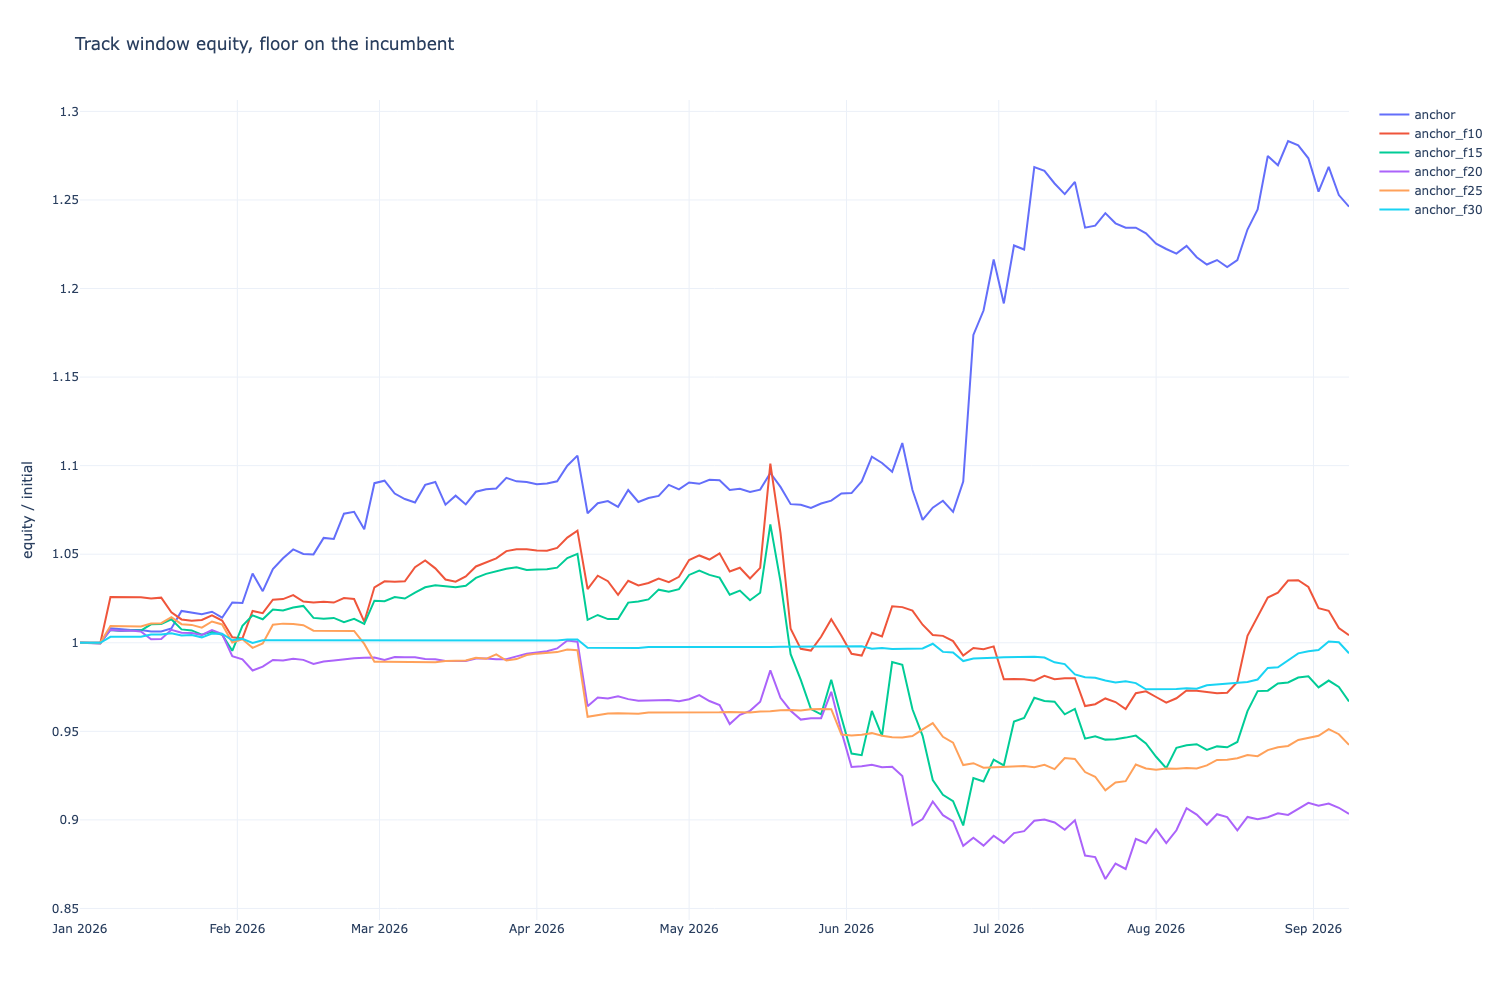

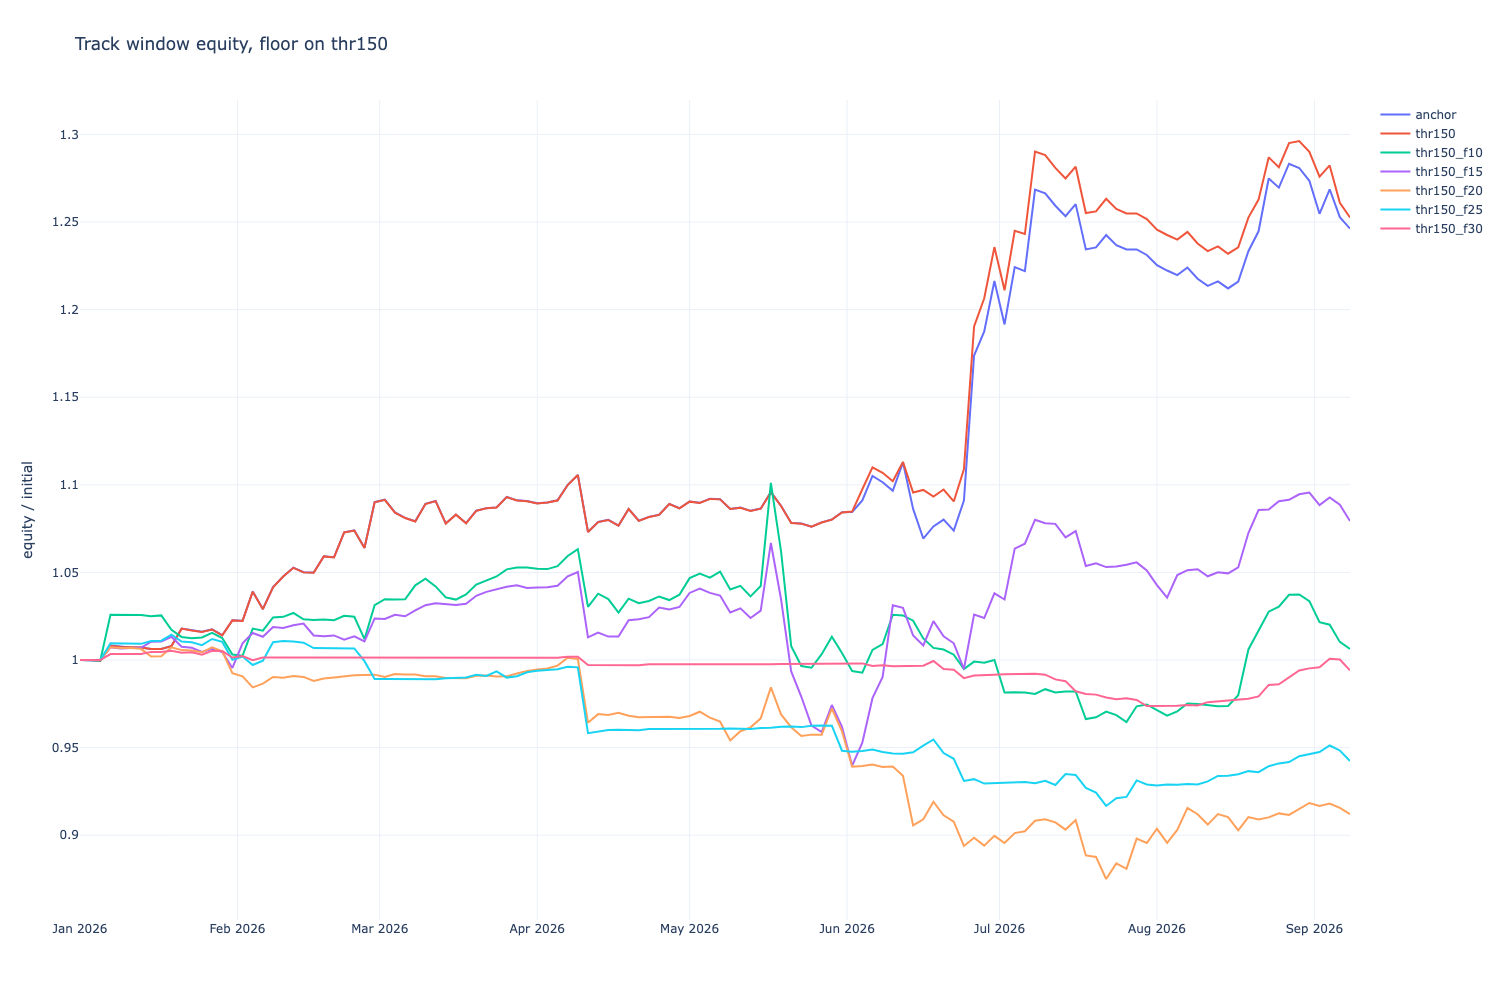

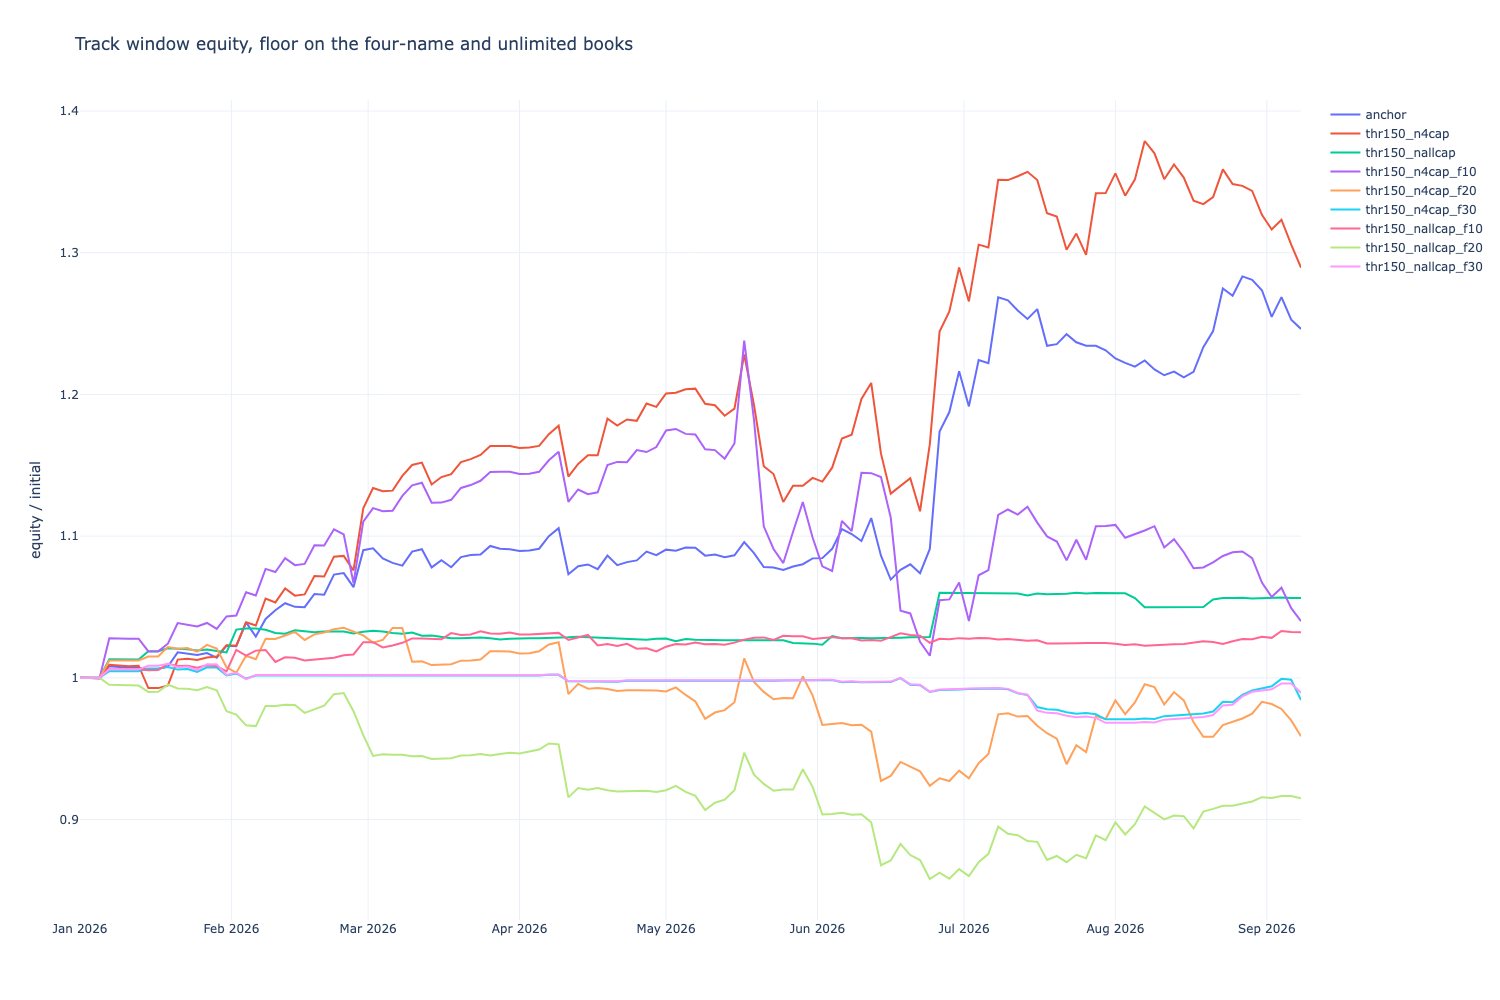

In [28]:
for f in FLOORS:
    run_and_record(f"anchor_{ftag(f)}", "floor_anchor", **floor_overrides(f, N_SLOTS))
    run_and_record(f"thr150_{ftag(f)}", "floor_thr150", **floor_overrides(f, N_SLOTS, **filter_overrides(THR_FAMILY["thr150"])))
for f in FLOORS_SHORT:
    run_and_record(f"thr150_n4cap_{ftag(f)}", "floor_n4", **floor_overrides(f, 4, **filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=4)))
    run_and_record(f"thr150_nallcap_{ftag(f)}", "floor_unlimited", **floor_overrides(f, 0, **filter_overrides(THR_FAMILY["thr150"], max_assets_in_portfolio=999)))
RESCUE = [f"anchor_{ftag(f)}" for f in FLOORS] + [f"thr150_{ftag(f)}" for f in FLOORS] \
         + [f"thr150_n4cap_{ftag(f)}" for f in FLOORS_SHORT] + [f"thr150_nallcap_{ftag(f)}" for f in FLOORS_SHORT]
display(summary_table(["anchor", "thr150", "thr150_n4cap", "thr150_nallcap"] + RESCUE).round(4))
rescue_risk = pd.DataFrame([risk_row(l) for l in ["anchor", "thr150", "thr150_n4cap", "thr150_nallcap"] + RESCUE]).set_index("label")
display(rescue_risk.round(4))
# Independent of the sleeve's own log: realised deployment and the largest realised weight.
sleeve_check = pd.DataFrame([sleeve_realised_check(l) for l in RESCUE]).set_index("label")
display(sleeve_check.round(4))
# The floor runs' logged qualifying counts against an offline reconstruction from the cached
# indicator at T-1. The anchor family's population is the whole pool (cell 44's `clear_*`); a
# thr150 floor run's population is ITS OWN crash log's survivors - the filter's hysteresis reads
# the held set, so a floor run's survivors can differ from thr150's on a few dates.
agreement = []
for f in FLOORS:
    log = run_by_label[f"anchor_{ftag(f)}"]["quality_log"]
    logged = pd.Series({pd.Timestamp(t): r["qualifying"] for t, r in log.items()}).sort_index()
    offline = floor_frame[f"clear_{ftag(f)}"].reindex(logged.index)
    agreement.append({"run": f"anchor_{ftag(f)}", "decisions": len(logged), "mismatches": int((logged != offline).sum()),
                      "max_abs_diff": float((logged - offline).abs().max())})
for f in FLOORS:
    entry = run_by_label[f"thr150_{ftag(f)}"]
    logged = pd.Series({pd.Timestamp(t): r["qualifying"] for t, r in entry["quality_log"].items()}).sort_index()
    offline = {}
    for t, rec in entry["crash_log"].items():
        survivors = set(rec["candidate_addresses"]) - set(rec["excluded_addresses"])
        count = 0
        for addr in survivors:
            pair = PAIR_BY_ADDRESS.get(addr)
            v = value_at_prior(indicator_series("quality_sharpe", pair), t) if pair is not None else np.nan
            count += int(np.isfinite(v) and v >= f)
        offline[pd.Timestamp(t)] = count
    offline = pd.Series(offline).reindex(logged.index)
    agreement.append({"run": f"thr150_{ftag(f)}", "decisions": len(logged), "mismatches": int((logged != offline).sum()),
                      "max_abs_diff": float((logged - offline).abs().max())})
agreement = pd.DataFrame(agreement).set_index("run")
display(agreement)
assert agreement["mismatches"].sum() == 0, "the floor's in-trade qualifying counts do not match the offline reconstruction"
for label in ["anchor_f10", "thr150_nallcap_f10"]:
    print(f"\n{label}: largest positions, with the quality score at the opening decision")
    display(ledger_with_quality(label, top=8).round(4))
# EVERY position of the floor runs in the engine vault, not only the eight largest: the floor
# runs hold it in several short, small positions through the June-August run.
engine_positions.update({l: positions_in_address(l, ENGINE) for l in RESCUE})
print("\nevery position in the engine vault, per floor run")
display(pd.DataFrame([{"label": l, "positions": len(engine_positions[l]), "pnl_usd": sum(r["pnl_usd"] for r in engine_positions[l]),
                       "peak_weight_max": max((r["peak_weight"] for r in engine_positions[l]), default=np.nan),
                       "spans": "; ".join(f"{r['opened']}..{r['closed'] or 'open'} ({r['pnl_usd']:.0f}, w {r['peak_weight']:.2f})" for r in engine_positions[l])}
                      for l in RESCUE]).set_index("label"))
for title, labels in {"floor on the incumbent": ["anchor"] + [f"anchor_{ftag(f)}" for f in FLOORS],
                      "floor on thr150": ["anchor", "thr150"] + [f"thr150_{ftag(f)}" for f in FLOORS],
                      "floor on the four-name and unlimited books": ["anchor", "thr150_n4cap", "thr150_nallcap"] + [f"thr150_n4cap_{ftag(f)}" for f in FLOORS_SHORT] + [f"thr150_nallcap_{ftag(f)}" for f in FLOORS_SHORT]}.items():
    equity_figure(f"Track window equity, {title}", labels).show()


## Part 5. Standing gates for Parts 3 and 4

Gates 1, 7, 3 and 6 for every new run; gate 2 (a full re-simulation) for the three new runs
with the largest Sharpe gap to the anchor among those passing gates 1, 7 and 3. Plateau
neighbours: the threshold family on its refined axis (1.0 / 1.25 / 1.5 / 1.75 / 2.0); the capped
position family on N +/- 1 with six = the anchor (or `thr150`); the uncapped family on N +/- 1
with six = `nocap` (or `thr150_nocap` with the filter); the floor families along the floor axis, the un-floored book as the lowest
floor's outer neighbour. Gate 6 is scored ONLY where both pre-registered neighbours exist: a
family endpoint has one, so its plateau is not run and the row is UNEVALUATED on gate 6 rather
than passed one-sided (`standing_gates_40`). Gates 4 and 8 with their tolerances are diagnostics.


In [29]:
NEIGHBOURS = {}
THR_ORDER = list(THR_FAMILY)
for i, label in enumerate(THR_ORDER):
    NEIGHBOURS[label] = [THR_ORDER[j] for j in (i - 1, i + 1) if 0 <= j < len(THR_ORDER)]
NEIGHBOURS["n3cap"] = ["n4cap"]; NEIGHBOURS["n4cap"] = ["n3cap", "n5cap"]; NEIGHBOURS["n5cap"] = ["n4cap", "anchor"]
NEIGHBOURS["thr150_n3cap"] = ["thr150_n4cap"]; NEIGHBOURS["thr150_n4cap"] = ["thr150_n3cap", "thr150_n5cap"]; NEIGHBOURS["thr150_n5cap"] = ["thr150_n4cap", "thr150"]
NEIGHBOURS["nofilter_n5"] = ["nofilter_n4", "nocap"]; NEIGHBOURS["nofilter_n4"] = ["nofilter_n3", "nofilter_n5"]
NEIGHBOURS["thr150_n5"] = ["thr150_n4", "thr150_nocap"]; NEIGHBOURS["thr150_n4"] = ["thr150_n3", "thr150_n5"]; NEIGHBOURS["thr150_n3"] = ["thr150_n4"]
NEIGHBOURS["thr150_nocap"] = ["thr150_n5"]


def floor_chain(prefix: str, base: str, floors):
    tags = [ftag(f) for f in floors]
    for i, tag in enumerate(tags):
        left = f"{prefix}_{tags[i - 1]}" if i > 0 else base
        right = [f"{prefix}_{tags[i + 1]}"] if i + 1 < len(tags) else []
        NEIGHBOURS[f"{prefix}_{tag}"] = [left] + right


floor_chain("anchor", "anchor", FLOORS)
floor_chain("thr150", "thr150", FLOORS)
floor_chain("thr150_n4cap", "thr150_n4cap", FLOORS_SHORT)
floor_chain("thr150_nallcap", "thr150_nallcap", FLOORS_SHORT)
NEW = [l for l in PART3 + RESCUE if l not in LEADS and l != "anchor"]
NEW = list(dict.fromkeys(NEW))
cheap = pd.DataFrame([standing_gates_40(l, NEIGHBOURS.get(l, [])) for l in NEW]).set_index("label")
CHEAP = ["gate_1_positive", "gate_7_subperiod", "gate_3_held_vol"]
cheap["cheap_pass"] = cheap[CHEAP].all(axis=1)
ranked = cheap[cheap["cheap_pass"]].sort_values("sharpe_gap_to_anchor", ascending=False)
LOVO_LABELS = list(ranked.index[:3])
print(f"leave-one-vault-out for: {LOVO_LABELS}")
gates = pd.DataFrame([standing_gates_40(l, NEIGHBOURS.get(l, []), run_lovo=(l in LOVO_LABELS)) for l in NEW]).set_index("label")
display(gates[["gate_1_positive", "gate_7_subperiod", "gate_3_held_vol", "gate_6_plateau", "plateau_neighbours", "gate_2_mask", "mask_retention",
               "diag_4_luck_within_tolerance", "diag_8_distinct_within_tolerance", "sharpe_gap_to_anchor",
               "failed_standing_gates", "standing_gates_not_run", "verdict"]].round(4))
for label in LOVO_LABELS:
    print(f"  {label}: masked {gates.loc[label, 'masked']}, retention {gates.loc[label, 'mask_retention']:.3f}")

# The old leads' plateaus re-read against the refined / capped neighbours: a check on the
# assumption, reported beside the recorded verdict, not a replacement for it.
replateau = pd.DataFrame([{"label": l, "recorded_verdict": NB37_VERDICTS.get(l), "neighbours_here": ", ".join(NEIGHBOURS[l]),
                           **{k: v for k, v in plateau_gate(l, NEIGHBOURS[l]).items() if k != "detail"}}
                          for l in ["thr150", "nofilter_n4", "thr150_n4"]]).set_index("label")
display(replateau.round(4))


leave-one-vault-out for: ['thr175', 'thr150_n5', 'thr150_nocap']


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 17:14:40,146 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


...

2026-09-18 17:15:34,974 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #540
  Estimated reserve 1364.059938770853461417220774, executed reserve 1349.449699113661843287095729
  Estimated quantity -835.03770542017127809231169521808624267578125, executed quantity -835.03770542017127809231169521808624267578125
  Reserve drift 1.071085 %, quantity drift 0.000000 %


2026-09-18 17:15:35,000 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #543
  Estimated reserve 1198.724923202837077667664680, executed reserve 1185.281733362666205957625141
  Estimated quantity -730.10215779943746383651159703731536865234375, executed quantity -730.10215779943746383651159703731536865234375
  Reserve drift 1.121457 %, quantity drift 0.000000 %


,gate_1_positive,gate_7_subperiod,gate_3_held_vol,gate_6_plateau,plateau_neighbours,gate_2_mask,mask_retention,diag_4_luck_within_tolerance,diag_8_distinct_within_tolerance,sharpe_gap_to_anchor,failed_standing_gates,standing_gates_not_run,verdict
label,,,,,,,,,,,,,
thr125,True,True,True,False,"thr100, thr150",None,NaN,False,True,-0.3778,gate_6_plateau,gate_2_mask,REJECT
thr175,True,True,True,True,"thr150, thr200",True,0.8535,True,True,0.1340,,,NOT CONFIRMED (inside indifference band)
nofilter_n5,True,True,True,False,"nofilter_n4, nocap",None,NaN,False,False,-0.3038,gate_6_plateau,gate_2_mask,REJECT
n3cap,True,False,False,None,"n4cap (endpoint: one neighbour, gate 6 not scored)",None,NaN,False,False,-1.6498,"gate_7_subperiod, gate_3_held_vol","gate_6_plateau, gate_2_mask",REJECT
n4cap,True,True,False,False,"n3cap, n5cap",None,NaN,False,False,0.1052,"gate_3_held_vol, gate_6_plateau",gate_2_mask,REJECT
n5cap,True,False,False,False,"n4cap, anchor",None,NaN,False,False,-0.5985,"gate_7_subperiod, gate_3_held_vol, gate_6_plateau",gate_2_mask,REJECT
thr150_n3,True,True,False,None,"thr150_n4 (endpoint: one neighbour, gate 6 not scored)",None,NaN,False,False,-0.7761,gate_3_held_vol,"gate_6_plateau, gate_2_mask",REJECT
thr150_n5,True,True,True,False,"thr150_n4, thr150_nocap",False,0.4975,False,False,-0.0914,"gate_6_plateau, gate_2_mask",,REJECT
thr150_nocap,True,True,True,None,"thr150_n5 (endpoint: one neighbour, gate 6 not scored)",True,0.7174,False,True,-0.2153,,gate_6_plateau,UNEVALUATED (gate_6_plateau not run)


  thr175: masked 0x77fee2df7bad4f1db93052fa82bf78eaab771a16, retention 0.853
  thr150_n5: masked 0x77fee2df7bad4f1db93052fa82bf78eaab771a16, retention 0.497
  thr150_nocap: masked 0x77fee2df7bad4f1db93052fa82bf78eaab771a16, retention 0.717


,recorded_verdict,neighbours_here,centre,centre_sharpe,passes
label,,,,,
thr150,REJECT,"thr125, thr175",thr150,2.2938,False
nofilter_n4,REJECT,"nofilter_n3, nofilter_n5",nofilter_n4,2.2997,False
thr150_n4,REJECT,"thr150_n3, thr150_n5",thr150_n4,2.6861,False


## Part 6. Windows A and B

The incumbent's docstring window (2026-01-01 to 07-10) and the full data period (2025-08-01 to
09-09) for the anchor, `thr150`, and the two best new runs by track Sharpe gap among those
passing the cheap standing gates. Slim runs; the cost-basis helper is redefined with a relative
tolerance exactly as NB33, NB35 and NB37 did.


In [30]:
import datetime


def get_remaining_cost_basis(position) -> float:
    quantity = 0.0
    cost_basis = 0.0
    for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
        trade_quantity = abs(float(trade.get_position_quantity()))
        if trade.is_buy():
            quantity += trade_quantity
            cost_basis += trade_quantity * float(trade.executed_price)
        elif trade.is_sell():
            assert quantity > 0, f"Cannot sell without a cost basis: {trade}"
            sold_quantity = min(trade_quantity, quantity)
            cost_basis *= (quantity - sold_quantity) / quantity
            quantity -= sold_quantity
    held = float(position.get_quantity())
    assert abs(quantity - held) <= 1e-8 * max(1.0, abs(held)), (
        f"Cost-basis quantity mismatch for {position}: {quantity} vs {position.get_quantity()}")
    return cost_basis


WINDOW_A = ("A: incumbent period", datetime.datetime(2026, 1, 1), datetime.datetime(2026, 7, 10))
WINDOW_B = ("B: full data period", datetime.datetime(2025, 8, 1), datetime.datetime(2026, 9, 9))
BEST_NEW = list(ranked.index[:2])
WINDOW_LABELS = list(dict.fromkeys(["anchor", "thr150"] + BEST_NEW))
print(f"window runs for: {WINDOW_LABELS}")
WINDOW_RESULTS = {}


def run_window(label: str, window) -> dict:
    name, start, end = window
    overrides = dict(run_by_label[label]["overrides"]) if label != "anchor" else {}
    VOL_DROP_LOG.clear(); COMPLEMENT_LOG.clear(); SLEEVE_LOG.clear(); PREFILTER_LOG.clear(); CRASH_LOG.clear(); QUALITY_LOG.clear(); CASH_SLEEVE_LOG.clear()
    state_, equity_, returns_ = run_variant(f"{label} [{name}]", backtest_start=start, backtest_end=end, **overrides)
    rc, _ppy = cycle_returns(equity_)
    row = panel(f"{label} [{name}]", state_, equity_, returns_)
    row["cumulative_return"] = float(equity_.iloc[-1] / equity_.iloc[0] - 1.0)
    row["final_equity"] = float(equity_.iloc[-1])
    row["cycles"] = int(len(rc))
    fills = [r["fill"] for r in CASH_SLEEVE_LOG.values()]
    row["sleeve_mean_fill"] = float(np.mean(fills)) if fills else float("nan")
    qual = [r["qualifying"] for r in QUALITY_LOG.values()]
    row["qualifying_mean"] = float(np.mean(qual)) if qual else float("nan")
    WINDOW_RESULTS[(label, name)] = {"label": label, "window": name, "equity": equity_, "cycle_returns": rc, "panel": row}
    return WINDOW_RESULTS[(label, name)]


for window in (WINDOW_A, WINDOW_B):
    for label in WINDOW_LABELS:
        run_window(label, window)
WINDOW_COLUMNS = ["cumulative_return", "cagr", "cycle_sharpe", "cycle_vol", "ulcer", "max_dd", "mean_invested",
                  "luck_ratio", "top5_gross_share", "cycles", "qualifying_mean", "sleeve_mean_fill"]
window_tables = {}
for window in (WINDOW_A, WINDOW_B):
    name = window[0]
    frame = pd.DataFrame([WINDOW_RESULTS[(l, name)]["panel"] for l in WINDOW_LABELS]).set_index("label")[WINDOW_COLUMNS]
    frame.index = WINDOW_LABELS
    window_tables[name] = frame
    print(f"\n{name}:")
    display(frame.round(4))


window runs for: ['anchor', 'thr150', 'thr175', 'thr150_n5']


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight, fresh_observation_count, btc_beta, btc_beta_r2, ulcer_index_180, downside_deviation_90, positive_window_share, residual_event_concentration, min_window_sortino, residual_cagr_score, gain_to_pain_score, cagr_min_sortino_weight, downside_score, drawdown_recovery_days, tvl_growth, cagr_downside_weight, cagr_positive_window_weight, residual_cagr_sortino_weight, sortino_raw_event, sortino_neff_event, sortino_cross_sectional_prior, sortino_shrunk_score, expanding_cagr_score, evidence_composite, inverse_vol_early, fresh_daily_return, cohort_down_flag, joint_loss_frequency, cagr_sortino_shrunk_weight, fresh_event_concentration, fresh_event_window_span, calm_score, inverse_ulcer_score, inverse_downside_score, residual_event_concentration_positive, quality_shar

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_342p4bc8230f_2021-05-06-2026-09-09_ff_cross_d066428f2


2026-09-18 17:15:57,628 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell Goon Edgin #73
  Estimated reserve 1149.004759247334741937935431, executed reserve 1135.221277962433177067548596
  Estimated quantity -685.895448491890192599385045468807220458984375, executed quantity -685.895448491890192599385045468807220458984375
  Reserve drift 1.199602 %, quantity drift 0.000000 %


...

2026-09-18 17:19:23,013 tradeexecutor.strategy.runner                      WARNING  Trade quantity and reserve match for pre an post-execution for: Sell AceVault H #633
  Estimated reserve 932.8516857926223799130916616, executed reserve 921.3115127672044483724137221
  Estimated quantity -572.02443608161775046028196811676025390625, executed quantity -572.02443608161775046028196811676025390625
  Reserve drift 1.237086 %, quantity drift 0.000000 %



A: incumbent period:


,cumulative_return,cagr,cycle_sharpe,cycle_vol,ulcer,max_dd,mean_invested,luck_ratio,top5_gross_share,cycles,qualifying_mean,sleeve_mean_fill
anchor,0.2685,0.5870,2.8999,0.1639,0.0139,-0.0391,0.9745,0.2070,0.7719,94,NaN,NaN
thr150,0.2903,0.6401,3.2169,0.1578,0.0121,-0.0294,0.9746,0.2649,0.7630,94,NaN,NaN
thr175,0.2903,0.6401,3.2169,0.1578,0.0121,-0.0294,0.9746,0.2649,0.7630,94,NaN,NaN
thr150_n5,0.2566,0.5581,2.5100,0.1833,0.0351,-0.0727,0.9757,0.0120,0.8294,94,NaN,NaN



B: full data period:


,cumulative_return,cagr,cycle_sharpe,cycle_vol,ulcer,max_dd,mean_invested,luck_ratio,top5_gross_share,cycles,qualifying_mean,sleeve_mean_fill
anchor,0.2949,0.2630,1.4694,0.1685,0.0278,-0.0659,0.9633,0.0254,0.5104,202,NaN,NaN
thr150,0.3332,0.2967,1.7465,0.1556,0.0230,-0.0493,0.9640,0.1198,0.5117,202,NaN,NaN
thr175,0.3097,0.2761,1.5585,0.1651,0.0250,-0.0659,0.9650,0.0684,0.5117,202,NaN,NaN
thr150_n5,0.3933,0.3494,1.7632,0.1788,0.0336,-0.0751,0.9663,0.0282,0.6803,202,NaN,NaN


## Part 7. Manifest


In [31]:
ALL = [e["label"] for e in runs if e["label"] != "anchor"]
all_summary = summary_table(["anchor"] + [l for l in ALL if "__lovo" not in l])
manifest = {
    "verdict": "see heading",
    "threshold_family": THR_FAMILY, "floors": list(FLOORS), "floors_short": list(FLOORS_SHORT), "slots": N_SLOTS,
    "leads": {l: {"family": f, "overrides": o} for l, (f, o) in LEADS.items()},
    "reproduction_max_abs_diff": float(worst),
    "provenance": provenance_record(),
    "summary": all_summary.round(10).to_dict(orient="index"),
    "risk": risk.round(10).to_dict(orient="index"),
    "rescue_risk": rescue_risk.round(10).to_dict(orient="index"),
    "ledgers": ledgers.round(10).to_dict(orient="index"),
    "ledger_detail": {l: position_ledger(l).head(8).round(10).to_dict(orient="records") for l in LEDGER_DETAIL},
    "drawdown_episodes": {f"{l}|{r}": {k: (str(v) if not isinstance(v, (int, float)) else v) for k, v in row.items()} for (l, r), row in episodes_table.iterrows()},
    "mask": mask_table.round(10).to_dict(orient="index"),
    "anchor_lovo": {k: v for k, v in anchor_lovo.items()},
    "anchor_quality_at_open": ledger_with_quality("anchor", top=8).round(10).to_dict(orient="records"),
    "floor_ledger_detail": {l: ledger_with_quality(l, top=8).round(10).to_dict(orient="records") for l in ("anchor_f10", "thr150_nallcap_f10")},
    "second_mask": pd.DataFrame(second_mask).set_index("label").round(10).to_dict(orient="index"),
    "bands": bands.drop(columns=["band_addresses"]).round(10).to_dict(orient="records"),
    "bands_aligned": bands_aligned.round(10).to_dict(orient="records"),
    "engine_positions": engine_positions,
    "sleeve_check": sleeve_check.round(10).to_dict(orient="index"),
    "quality_log_agreement": agreement.to_dict(orient="index"),
    "band_addresses_thr150_vs_thr100": bands.iloc[0]["band_addresses"],
    "exclusion_outcomes": exclusion_summary.round(10).to_dict(orient="index"),
    "sparse": sparse.round(10).to_dict(orient="index"),
    "overlap": overlap.round(10).to_dict(orient="index"),
    "band_summary": band_summary.round(10).to_dict(orient="index"),
    "floor_summary": floor_summary.round(10).to_dict(orient="index"),
    "gates": gates.round(10).to_dict(orient="index"),
    "replateau": replateau.round(10).to_dict(orient="index"),
    "lovo_labels": LOVO_LABELS, "best_new": BEST_NEW,
    "windows": {name: frame.round(10).to_dict(orient="index") for name, frame in window_tables.items()},
    "all_runs": {e["label"]: {"family": e["family"],
                              "overrides": {k: (sorted(v) if isinstance(v, (set, frozenset)) else v) for k, v in e["overrides"].items()},
                              "panel": {k: float(e["panel"][k]) for k in ("cagr", "cycle_sharpe", "cycle_vol", "ulcer", "max_dd")}}
                 for e in runs if e["label"] != "anchor"},
}
Path("_build/manifest_40.json").write_text(json.dumps(manifest, indent=1, default=str))
print("wrote _build/manifest_40.json")


wrote _build/manifest_40.json


## Integrity: destroyed and stranded capital

NB80's accounting identity - `equity == initial cash + realised + unrealised` - cannot fail after
trade-executor [#1623](https://github.com/tradingstrategy-ai/trade-executor/pull/1623), because
realised + unrealised now *is* cash-flow profit, which reduces to cash + holdings. It is replaced
here by the check that caught the genuine
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) dust defect.

Equity reconciling against cash plus holdings is still worth asserting - it is cheap and it is the
one identity that was ever load-bearing - but it is reported as a reconciliation, not as a pass mark.


In [32]:
import pandas as pd

def audit_portfolio(portfolio) -> dict:
    """Screen one run for capital that entered a position and did not come back.

    Two failure modes, neither visible to the accounting identity, because the engine values a
    vanished position at zero and equity therefore still reconciles:

    - **destroyed**: funded with real cash, closed returning nothing
    - **stranded**: closed while still holding quantity
    """
    destroyed, stranded, stranded_usd = 0, 0, 0.0
    for position in portfolio.get_all_positions():
        if position.is_open() or position.is_credit_supply():
            continue
        funded = sum(abs(float(t.executed_reserve or 0))
                     for t in position.trades.values() if t.is_buy() and t.is_success())
        returned = sum(abs(float(t.executed_reserve or 0))
                       for t in position.trades.values() if t.is_sell() and t.is_success())
        # $100 funded against $1 returned keeps ordinary engine dust out of the count.
        if funded > 100 and returned < 1.0:
            destroyed += 1
        quantity = float(position.get_quantity() or 0)
        if abs(quantity) > 1e-9:
            stranded += 1
            stranded_usd += quantity * float(position.last_token_price or 0)

    cash = float(portfolio.get_cash())
    holdings = sum(float(p.get_value() or 0) for p in portfolio.open_positions.values())
    equity = float(portfolio.get_total_equity())
    return {
        "destroyed": destroyed,
        "stranded": stranded,
        "stranded USD": stranded_usd,
        "cash + holdings - equity": cash + holdings - equity,
    }


audit = audit_portfolio(state.portfolio)
display(pd.DataFrame([audit]).style.format({
    "stranded USD": "${:,.2f}", "cash + holdings - equity": "${:,.2f}",
}).hide(axis="index").set_caption("Integrity screen"))

if audit["destroyed"] or audit["stranded"]:
    print(f"FAILED: {audit['destroyed']} destroyed, {audit['stranded']} stranded position(s)")
else:
    print("Passed: no destroyed or stranded positions")


destroyed,stranded,stranded USD,cash + holdings - equity
0,0,$0.00,$0.00


Passed: no destroyed or stranded positions


## Redemption-fee audit

Verify every executed vault redemption charged exactly the 10% fee on positive profit plus 10 bps of gross redeemed capital.


In [33]:
def redemption_fee_audit(state_) -> pd.DataFrame:
    """Reconcile executed redemption prices against the configured fee treatment."""
    rows = []
    for position in state_.portfolio.get_all_positions():
        if not position.pair.is_vault():
            continue
        quantity = 0.0
        cost_basis = 0.0
        for trade in sorted(position.get_successful_trades(), key=lambda trade: trade.executed_at):
            trade_quantity = abs(float(trade.get_position_quantity()))
            if trade.is_buy():
                quantity += trade_quantity
                cost_basis += trade_quantity * float(trade.executed_price)
                continue
            if not trade.is_sell():
                continue
            gross_price = float(trade.planned_mid_price)
            gross_proceeds = trade_quantity * gross_price
            released_cost_basis = cost_basis * trade_quantity / quantity
            configured_fee = float(trade.other_data["backtest_vault_redemption_fee"])
            capital_fee = gross_proceeds * Parameters.vault_redemption_capital_fee
            performance_fee = gross_proceeds * configured_fee - capital_fee
            actual_proceeds = trade_quantity * float(trade.executed_price)
            expected_proceeds = gross_proceeds * (1.0 - configured_fee)
            rows.append({
                "Vault": position.pair.base.token_symbol,
                "Redeemed at": trade.executed_at,
                "Gross proceeds": gross_proceeds,
                "Performance fee": performance_fee,
                "Capital fee": capital_fee,
                "Configured redemption fee": configured_fee,
                "Net proceeds": actual_proceeds,
                "Reconciliation error": actual_proceeds - expected_proceeds,
            })
            cost_basis -= released_cost_basis
            quantity -= trade_quantity
    return pd.DataFrame(rows)


redemption_fees = redemption_fee_audit(state)
assert len(redemption_fees), "Expected at least one vault redemption"
max_reconciliation_error = redemption_fees["Reconciliation error"].abs().max()
print(f"Maximum redemption-fee reconciliation error: ${max_reconciliation_error:,.8f}")
assert max_reconciliation_error < 1e-6, "Redemption fees did not reconcile"
display(
    redemption_fees.style.format({
        "Gross proceeds": "${:,.2f}",
        "Performance fee": "${:,.2f}",
        "Capital fee": "${:,.2f}",
        "Configured redemption fee": "{:.4%}",
        "Net proceeds": "${:,.2f}",
        "Reconciliation error": "${:,.8f}",
    }).set_caption("Every vault redemption reconciles to performance fee plus capital fee")
)


Maximum redemption-fee reconciliation error: $0.00000000


,Vault,Redeemed at,Gross proceeds,Performance fee,Capital fee,Configured redemption fee,Net proceeds,Reconciliation error
0,Citadel,2026-08-17 00:00:00,"$1,761.12",$4.93,$1.76,0.3800%,"$1,754.43",$0.00000000
1,Citadel,2026-08-19 00:00:00,"$1,374.58",$9.17,$1.37,0.7670%,"$1,364.04",$-0.00000000
2,Citadel,2026-08-31 00:00:00,$800.64,$5.49,$0.80,0.7863%,$794.35,$0.00000000
3,Citadel,2026-09-02 00:00:00,$900.79,$6.18,$0.90,0.7863%,$893.71,$0.00000000
4,Citadel,2026-09-06 00:00:00,$756.85,$5.13,$0.76,0.7779%,$750.96,$0.00000000
5,AceVault H,2026-08-21 00:00:00,"$4,827.89",$51.30,$4.83,1.1625%,"$4,771.76",$-0.00000000
6,AceVault H,2026-08-27 00:00:00,"$1,081.08",$13.54,$1.08,1.3524%,"$1,066.46",$0.00000000
7,AceVault H,2026-08-31 00:00:00,"$1,238.89",$16.97,$1.24,1.4695%,"$1,220.69",$0.00000000
8,AceVault H,2026-09-02 00:00:00,$873.05,$11.92,$0.87,1.4652%,$860.26,$0.00000000
9,Octavious,2026-09-02 00:00:00,"$1,154.37",$16.66,$1.15,1.5434%,"$1,136.55",$0.00000000
